<h1 style="color: rgb(255,98,0)">OSA Growth Intelligence Model</h1>


OSA Growth Intelligence Modeli, bankanın 2026 yıl sonu hedefi olan 120 Milyar TL bakiye büyüklüğüne ulaşabilmesi için geliştirilmiş bir karar destek sistemidir. Projenin çıkış noktası, Turuncu Hesap faiz kararlarını sezgisel yaklaşımdan çıkarıp veri odaklı bir yapıya taşımaktır. Model, haftalık veya aylık karar döngülerinde yöneticilere "Bu dönem faizi ne yapmalıyız?" sorusuna somut ve sayısal cevaplar sunmayı hedeflemektedir.

Bu notebook, söz konusu sistemin tahmin motorunu barındırmaktadır. Tahmin edilen değişken **Netflow Rate** olup Inflow Rate − Outflow Rate farkından oluşmaktadır. Bir sonraki haftanın net para akışını öngörebilmek, faiz optimizasyonu ve senaryo analizleri için zorunlu ön koşuldur.

<h2 style="color: rgb(255,98,0)">Mevcut Durum ve İş Problemi</h2>

Turuncu Hesap faiz kararları bugüne kadar ağırlıklı olarak sezgisel yaklaşım ve rakip takibi ile alınmıştır. Bu geleneksel yapı, bankanın uzun vadeli hedeflerine ulaşmasında beş kritik risk oluşturmaktadır:

* **Reaktif Karar Alma:** Rakip faiz artırdığında "biz de artıralım" refleksiyle hareket edilmektedir. Banka piyasada oyun kurucu değil takipçi konumuna düşmekte, proaktif bilanço yönetimi yapılamamaktadır.

* **Hedef Belirsizliği:** "120 Milyar TL'ye ulaşmak için bu hafta tam olarak ne yapmalıyız?" sorusunun sayısal bir cevabı bulunmamaktadır. Hedefin ne kadar gerisinde veya önünde olunduğu matematiksel olarak belirsizdir ve yıl sonunda sürprizle karşılaşma riski taşımaktadır.

* **Maliyet Optimizasyonu Eksikliği:** Hedefi tutturacak en düşük (optimal) faiz oranı bilinmediğinden, yönetici emin olmak adına gereksiz yüksek faiz verme eğilimindedir. Örneğin faizi 46 yaparak hedef tutabilecekken 47 verilmesi, yıllık milyonlarca TL fazla maliyet anlamına gelmektedir.

* **Kişi Bağımlılığı:** Mevcut süreçler büyük ölçüde manuel Excel tabloları ve belirli kişilerin uzmanlığına dayanmaktadır. Kurumsal hafıza oluşamamakta, karar verici uzmanın bulunmadığı dönemlerde süreç kalitesi düşmektedir.

* **Senaryo Eksikliği:** "Faizi 50 yaparsak ne olur?" veya "Kur %10 artarsa mevduat nasıl etkilenir?" gibi "Ya böyle olursa?" sorularına mevcut yapıda yanıt verilememektedir.

<h2 style="color: rgb(255,98,0)">Model Mimarisi ve Veri Katmanları</h2>

Model, tahmin üretmek için üç veri katmanından beslenmektedir:

- **Banka İçi (Internal) Veriler:** Ortalama vadeli bakiye, yeni müşteri sayısı (NTB), hesap açılış hacmi, hoşgeldin kampanyası dönüşümü gibi doğrudan bankadan gelen operasyonel metrikler.
- **Banka Dışı (External/Makro) Veriler:** TLREF, TCMB politika faizi, CDS, kur oynaklığı, VIX, tüketim endeksleri ve enflasyon beklentileri gibi piyasa göstergeleri.
- **Çapraz (Interaction) Değişkenler:** İç ve dış verinin birbirine göre anlamlı kombinasyonları — rekabetçi faiz farkı × yeni müşteri, TLREF × kur oynaklığı gibi etkileşim terimleri.

Değişken seçimi (feature selection) rolling yapıya taşınmış olup model her hafta yalnızca o ana kadar gördüğü veriyle çalışmakta, gelecekten bilgi sızması (leakage) engellenmiş durumdadır.

<h2 style="color: rgb(255,98,0)">Kütüphanelerin Kurulumu</h2>

Modelin çalışması için gerekli olan veri işleme, istatistik, makine öğrenmesi ve görselleştirme kütüphaneleri burada yüklenmektedir.

In [1]:
# Jupyter/VSCode çıktı alanındaki kaydırma sınırını kaldır (uzun tablolar kesilmesin)
from IPython.display import display, HTML
display(HTML("<style>div.output_scroll { height: auto !important; max-height: none !important; }</style>"))

# Pandas tablo görüntüleme ayarları (satır, sütun ve genişlik limitleri kaldırılıyor)
import pandas as pd
pd.set_option('display.max_rows', 999)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 999)

# Veri işleme ve sayısal hesaplama
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# İstatistik ve korelasyon testleri
from scipy import stats
from scipy.stats import spearmanr

# Türkiye resmi tatil takvimi (is_gunu_sayisi hesaplamasi icin)
import holidays

# Makine öğrenmesi: model, ölçekleme, değerlendirme metrikleri
from sklearn.linear_model import RidgeCV                        # Çapraz doğrulamalı Ridge regresyon
from sklearn.model_selection import TimeSeriesSplit             # Zaman serisi için sıralı fold bölme
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Değişken ölçeklendirme
from sklearn.feature_selection import VarianceThreshold         # Düşük varyanslı değişken eleme
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score

# Grafik renk paleti
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GRAY_LIGHT = '#cccccc'
GRAY_DARK = '#555555'
CORNFLOWERBLUE = '#6495ED'

# Görsellerin kaydedileceği klasör
IMAGES_DIR = 'images'
os.makedirs(IMAGES_DIR, exist_ok=True)

<h2 style="color: rgb(255,98,0)">Model Mantığı ve Yardımcı Fonksiyonlar</h2>

Bu bölüm modelin değerlendirme ve raporlama altyapısını barındırmaktadır. Standart hata metriklerinin (MAE, RMSE) yanı sıra iki ek katman içerir:

- **G-AUC (Grouped AUC):** Modelin sayısal doğruluğundan bağımsız olarak yön tahminini (yukarı/aşağı) ne kadar tutarlı yaptığını ölçer. Tahminler SIQ (Yarı Çeyreklik Açıklık) bazlı sepetlere bölünerek aykırı değerlerin skoru bozması engellenir.
- **EDoF Tabanlı True Adj. R²:** Ridge regresyonun L2 cezası nedeniyle bazı değişkenler baskılanır. Klasik Adj. R² bunu görmez. SVD ile hesaplanan Efektif Serbestlik Derecesi (EDoF) kullanılarak modelin gerçek ezber riski ölçülür.

Ayrıca grafik fonksiyonları (train -> test kesintisiz çizim, hata dağılımı) ve her metriğin iş birimi karşılığını gösteren raporlama fonksiyonu bu bölümde tanımlıdır.

In [2]:
# Temel Hata Metrikleri
def get_metrics(actual, pred):
    """MAE, Median AE, RMSE, RMdSE ve Bias hesaplar."""
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    if len(actual) != len(pred):
        raise ValueError(f"Boyut uyumsuz: actual={len(actual)}, pred={len(pred)}")
    if not np.isfinite(actual).all() or not np.isfinite(pred).all():
        raise ValueError("actual ve pred sonlu numeric değerler içermeli (NaN/inf bulunamaz)")

    residuals = actual - pred                                # Yönlü hata (pozitif = gerçek daha yüksek)
    abs_errors = np.abs(residuals)                           # Mutlak hata

    mae = np.mean(abs_errors)                                # Ortalama mutlak hata
    median_ae = np.median(abs_errors)                        # Medyan mutlak hata (aykırı değerlere dirençli)
    rmse = np.sqrt(np.mean(residuals**2))                    # Kök ortalama kare hata (residual üzerinden)
    rmdse = np.sqrt(np.median(residuals**2))                 # Kök medyan kare hata (aykırı değerlere dirençli RMSE)
    bias = np.mean(residuals)                                # Sistematik sapma (+ = hafife alıyor, - = abartıyor)

    return {'MAE': mae, 'Median AE': median_ae, 'RMSE': rmse,
            'RMdSE': rmdse, 'Bias': bias}


# Grafik Yardımcıları
def make_seamless(series, last_actual_val, last_actual_idx):
    """
    Train → Test geçişinde çizgi kopmaması için test serisinin başına son gerçek değeri ekler.
    NOT: Sadece görselleştirme amaçlıdır, evaluation dataframe'lerinde kullanılmamalıdır.
    """
    return pd.concat([pd.Series([last_actual_val], index=[last_actual_idx]), series])

def safe_date_map(idx, df_local, date_col='Date'):
    """
    Verilen index df_local içindeyse ilgili tarihi döner,
    dışındaysa son tarihten haftalık ileri gider. Global df'ye bağımlı değildir.
    """
    if not isinstance(idx, (int, np.integer)):
        raise ValueError(f"Index numerik olmalı, gelen: {type(idx)}")
    if not np.issubdtype(df_local.index.dtype, np.integer):
        raise ValueError("df_local.index integer/numeric olmalı")
    if not pd.api.types.is_datetime64_any_dtype(df_local[date_col]):
        raise ValueError(f"{date_col} kolonu datetime tipinde olmalı")
    if idx in df_local.index:
        return df_local.loc[idx, date_col]
    return df_local[date_col].max() + pd.Timedelta(weeks=(idx - df_local.index.max()))


# G-AUC Hesaplama (Yön Tahmini Başarısı)
def assign_siq_buckets(values, num_buckets=8):
    """
    Tahminleri SIQ (Yarı Çeyreklik Açıklık) bazlı ±3 SIQ sınırları içinde
    sepetlere böler. Girdi dataframe'i değiştirmez, bucket serisini döner.
    """
    values = np.asarray(values, dtype=float)                  # Herhangi bir input tipini güvenli diziye çevir
    if not np.isfinite(values).all():
        raise ValueError("assign_siq_buckets finite değerler bekler")
    Q1, Q3 = np.percentile(values, [25, 75])                 # 1. ve 3. çeyreklik
    SIQ = (Q3 - Q1) / 2                                      # Yarı çeyreklik açıklık
    median = np.median(values)
    lower_bound = median - 3 * SIQ                            # Alt sınır
    upper_bound = median + 3 * SIQ                            # Üst sınır

    if lower_bound == upper_bound:                            # Tüm tahminler aynıysa tek sepet
        bins = np.array([float('-inf'), lower_bound, float('inf')])
    else:
        bins = np.linspace(lower_bound, upper_bound, num_buckets + 1)  # Eşit aralıklı sepet sınırları
        bins = np.unique(np.concatenate(([float('-inf')], bins, [float('inf')])))

    bucket_labels = list(range(len(bins) - 1))                # Her sepete sıralı numara ata
    return pd.cut(values, bins=bins, labels=bucket_labels, include_lowest=True)

def calculate_weighted_auc(df, pred_col, target_col, min_bucket_size=5):
    """
    Her sepet içinde lokal ROC-AUC hesaplar, sepet büyüklüğüne göre ağırlıklandırır.
    min_bucket_size'dan küçük sepetler dışlanır.
    """
    auc_scores, weights = [], []
    for bucket, group in df.groupby('bucket', observed=True):
        if len(group) < min_bucket_size:                      # Çok küçük sepetlerde AUC güvenilir değil
            continue
        if len(group[target_col].unique()) > 1:               # Tek sınıflı sepette AUC hesaplanamaz
            auc = roc_auc_score(group[target_col], group[pred_col])
            auc_scores.append(auc)
            weights.append(len(group))

    if len(weights) < 2:                                      # En az 2 geçerli sepet yoksa metrik güvenilir değil
        return np.nan
    return np.average(auc_scores, weights=weights)

def get_gauc_metrics(df, pred_col, target_col):
    """
    G-AUC pipeline: hedefi median bazlı 0/1'e çevirir, tahminleri ölçekler,
    sepetler ve ağırlıklı AUC skorunu üretir.
    """
    df_temp = df[[pred_col, target_col]].dropna().copy()      # NaN temizle, kopya al

    # Her iki kolonu da numeric'e zorla, dönüşemeyenleri NaN yap ve temizle
    df_temp[pred_col] = pd.to_numeric(df_temp[pred_col], errors='coerce')
    df_temp[target_col] = pd.to_numeric(df_temp[target_col], errors='coerce')
    df_temp = df_temp.dropna()

    if not np.isfinite(df_temp[pred_col]).all() or not np.isfinite(df_temp[target_col]).all():
        raise ValueError("pred_col ve target_col sonlu numeric değerler içermeli")
    if len(df_temp) < 10:
        return np.nan, "RED"                                  # Çok küçük örneklemde anlamsız

    target_median = df_temp[target_col].median()
    df_temp['target_binary'] = (df_temp[target_col] >= target_median).astype(int)  # Medyanın üstü=1, altı=0

    scaler = MinMaxScaler()
    df_temp['pred_scaled'] = scaler.fit_transform(df_temp[[pred_col]])  # 0-1 arasına sıkıştır

    # Küçük örneklemde bucket sayısını dinamik olarak azalt
    n = len(df_temp)
    num_buckets = max(3, min(8, n // 5))                      # En az 3, en fazla 8 sepet
    df_temp['bucket'] = assign_siq_buckets(df_temp['pred_scaled'].values, num_buckets)
    gauc = calculate_weighted_auc(df_temp, 'pred_scaled', 'target_binary')

    # nan => RED (yetersiz örneklem veya geçersiz hesaplama nedeniyle, zayıf sinyal değil)
    if np.isnan(gauc):
        return np.nan, "RED"
    status = "RED"                                            # Varsayılan: zayıf
    if gauc > 0.65: status = "GREEN"                          # Güçlü yön tahmini
    elif gauc >= 0.60: status = "YELLOW"                      # Orta seviye
    return gauc, status


# Görselleştirme Fonksiyonları
def _safe_save(fig, filepath):
    """Grafik kaydetme — klasör yoksa oluşturur, hata olursa sessizce geçer."""
    try:
        dirpath = os.path.dirname(filepath)
        if dirpath:                                           # Boş string gelirse makedirs'ı atla
            os.makedirs(dirpath, exist_ok=True)
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
    except Exception as e:
        print(f"Grafik kaydedilemedi: {e}")

def plot_integrated(df_local, pred_train, pred_test, title, filename, split_date,
                    color='#ff7f0e', images_dir=None):
    """
    Gerçek veri, train fit ve test tahmini tek grafikte kesintisiz çizer.
    pred_train ve pred_test pandas Series olmalıdır (index üzerinden tarih eşlemesi yapılır).
    """
    if not isinstance(pred_train, pd.Series) or not isinstance(pred_test, pd.Series):
        raise ValueError("pred_train ve pred_test pandas Series olmalı")
    if len(pred_train) == 0 or len(pred_test) == 0:
        raise ValueError("pred_train ve pred_test boş olamaz")
    for col in ['Date', 'NET']:
        if col not in df_local.columns:
            raise ValueError(f"df_local '{col}' kolonu içermiyor")
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(df_local['Date'], df_local['NET'], label='Gerçekleşen', color='#555555', alpha=0.3, linewidth=3)

    # Train tarafı: index df_local içindeyse doğrudan, değilse safe_date_map ile çiz
    train_in_df = pred_train.index.isin(df_local.index).all()
    if train_in_df:
        ax.plot(df_local.loc[pred_train.index, 'Date'], pred_train, label='Eğitim Tahmini', color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    else:
        train_dates = pred_train.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(train_dates, pred_train, label='Eğitim Tahmini', color=color, linestyle='--', linewidth=1.5, alpha=0.7)

    # Test tarafı: Train → Test geçişinde çizgi kopmasını engelle
    last_act_idx = pred_test.index[0] - 1
    if last_act_idx in df_local.index:
        last_val = df_local.loc[last_act_idx, 'NET']
        seamless_test = make_seamless(pred_test, last_val, last_act_idx)
        plot_dates = seamless_test.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(plot_dates, seamless_test, label='Test Tahmini', color=color, linewidth=3)
    else:
        plot_dates = pred_test.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(plot_dates, pred_test, label='Test Tahmini', color=color, linewidth=3)

    ax.axvline(x=pd.to_datetime(split_date), color='#1f77b4', linestyle=':', alpha=0.7, label='Bölünme Noktası')
    ax.set_title(title, fontsize=16, fontweight='bold', color='#1f77b4')
    ax.legend(); ax.grid(True, alpha=0.1)

    if images_dir:
        _safe_save(fig, os.path.join(images_dir, filename))
    plt.show()
    plt.close(fig)                                            # Bellek sızıntısını engelle

def plot_residuals(actual, predicted, title, dates=None, color='#ff7f0e', images_dir=None):
    """
    Forecasting hata diagnostiği:
    1) Tahmine göre hata saçılımı (heteroscedasticity)
    2) Hata dağılımı histogramı (normallik)
    3) Zamana göre mutlak hata trendi (varsa dates verilmişse)
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if len(actual) != len(predicted):
        raise ValueError(f"Boyut uyumsuz: actual={len(actual)}, predicted={len(predicted)}")
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError("actual ve predicted sonlu numeric değerler içermeli")
    if dates is not None and len(dates) != len(actual):
        raise ValueError(f"dates uzunluğu ({len(dates)}) actual ile eşleşmiyor ({len(actual)})")

    resid = actual - predicted

    n_plots = 3 if dates is not None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 6))

    # Sol: Tahmine göre hata saçılımı (değişen varyans kontrolü)
    axes[0].scatter(predicted, resid, alpha=0.6, color=color, s=40, edgecolors='white', linewidth=0.5)
    axes[0].axhline(0, color='#1f77b4', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('Tahmin Değeri'); axes[0].set_ylabel('Hata')
    axes[0].set_title('Hata Stabilitesi', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.1)

    # Orta: Hata dağılımı (normallik kontrolü)
    axes[1].hist(resid, bins='auto', density=True, alpha=0.7, color=color, edgecolor='white')
    axes[1].set_title('Hata Dağılımı', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.1)

    # Sağ: Zamana göre mutlak hata trendi (forecasting'e özel diagnostik)
    if dates is not None:
        abs_err = np.abs(resid)
        axes[2].plot(dates, abs_err, marker='o', color=color, linewidth=1.5, alpha=0.7, markersize=4)
        axes[2].axhline(np.mean(abs_err), color='gray', linestyle='--', alpha=0.5, label=f'Ort. |Hata|={np.mean(abs_err):.3f}')
        axes[2].set_title('Mutlak Hata Trendi (Zaman)', fontsize=13, fontweight='bold')
        axes[2].legend(); axes[2].grid(True, alpha=0.1)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

    fig.suptitle(f'Diagnostics: {title}', fontsize=16, fontweight='bold', y=1.02)
    fig.tight_layout()

    if images_dir:
        safe_title = title.replace(' ', '_').replace('.', '').lower()
        _safe_save(fig, os.path.join(images_dir, f'resid_{safe_title}.png'))
    plt.show()
    plt.close(fig)


# Model Sağlık Raporu
def print_detailed_stats(model, X_train, y_train, X_test=None, y_test=None, feature_names=None,
                         neg_color='#ff7f0e', pos_color='#1f77b4'):
    """
    Regularized linear model (Ridge, Lasso, ElasticNet) için detaylı sağlık raporu üretir.
    EDoF hesabı Ridge tipi L2 shrinkage varsayar; diğer model tiplerinde yaklaşık sonuç verir.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    if not np.isfinite(X_train).all() or not np.isfinite(y_train).all():
        raise ValueError("X_train ve y_train sonlu numeric değerler içermeli (NaN/inf bulunamaz)")

    if not hasattr(model, 'predict'):
        raise ValueError("Model predict() metodu içermiyor")
    pred_test = None                                          # Başta tanımla, aşağıda koşullu ata
    pred_train = model.predict(X_train)
    m = get_metrics(y_train, pred_train)                      # Eğitim metrikleri (5 adet)
    r2 = r2_score(y_train, pred_train)                        # R² — varyans açıklama oranı
    n, p = X_train.shape                                      # n=gözlem, p=değişken sayısı

    # Klasik Adj. R² — sadece değişken sayısına göre cezalandırır
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan

    # Regularization alpha güvenli okuma (RidgeCV, Ridge, ElasticNet, Lasso uyumlu)
    alpha = getattr(model, 'alpha_', getattr(model, 'alpha', np.nan))

    # EDoF tabanlı True Adj. R² — Ridge L2 cezası varsayımıyla çalışır
    # alpha <= 0 veya NaN ise EDoF hesabı atlanır (OLS'e yakın veya geçersiz)
    edof, eff_adj_r2, true_gap = np.nan, np.nan, np.nan
    if np.isfinite(alpha) and alpha > 0:
        try:
            X_centered = X_train - np.mean(X_train, axis=0)  # Merkezleme (SVD için gerekli)
            _, d, _ = np.linalg.svd(X_centered, full_matrices=False)  # Tekil değerler
            edof = np.sum((d**2) / (d**2 + alpha))            # Efektif serbestlik derecesi
            eff_adj_r2 = 1 - (1 - r2) * (n - 1) / (n - edof - 1) if n > edof + 1 else np.nan
            true_gap = r2 - eff_adj_r2                        # Gerçek ezber farkı
        except Exception:
            pass                                              # SVD başarısızsa nan kalır

    rho, _ = spearmanr(y_train, pred_train)                   # Haftaları düşükten yükseğe sıralama tutarlılığı

    # Test metrikleri (varsa)
    test_metrics = {k: np.nan for k in ['MAE', 'Median AE', 'RMSE', 'RMdSE', 'Bias']}
    test_rho = np.nan
    if X_test is not None and y_test is not None:
        X_test = np.asarray(X_test, dtype=float)
        y_test = np.asarray(y_test, dtype=float)
        if not np.isfinite(X_test).all() or not np.isfinite(y_test).all():
            raise ValueError("X_test ve y_test sonlu numeric değerler içermeli (NaN/inf bulunamaz)")
        pred_test = model.predict(X_test)
        test_metrics = get_metrics(y_test, pred_test)
        if len(y_test) > 2:                                   # Spearman en az 3 gözlem ister
            test_rho, _ = spearmanr(y_test, pred_test)

    # Rapor tablosu
    metrics = {
        'Metrik': ['R²', 'Klasik Adj. R²', 'Klasik Ezber Farkı',
                   'Efektif Değişken Sayısı (EDoF)', 'True Adj. R²', 'Gerçek Ezber Farkı',
                   'Eğitim Spearman', 'Test Spearman (OOS)',
                   'Alpha (Ceza)', 'Gözlem Sayısı (N)', 'Değişken Sayısı (p)',
                   'Eğitim MAE', 'Eğitim Median AE', 'Eğitim RMSE', 'Eğitim RMdSE', 'Eğitim Bias',
                   'Test MAE', 'Test Median AE', 'Test RMSE', 'Test RMdSE', 'Test Bias'],
        'Değer': [r2, adj_r2, r2 - adj_r2,
                  edof, eff_adj_r2, true_gap,
                  rho, test_rho,
                  alpha, n, p,
                  m['MAE'], m['Median AE'], m['RMSE'], m['RMdSE'], m['Bias'],
                  test_metrics['MAE'], test_metrics['Median AE'], test_metrics['RMSE'],
                  test_metrics['RMdSE'], test_metrics['Bias']],
        'İş Anlamı': [
            'Modelin eğitim verisindeki varyansı ne kadar açıklayabildiği.',
            'Klasik istatistik cezası sonrası kalan güvenilir skor.',
            'Klasik yaklaşıma göre modelin ezber yapma riski.',
            'Regularization sonrası aktif kalan efektif model karmaşıklığı (L2 yaklaşımı).',
            'Ridge cezası dahil edilmiş dürüst başarı oranı (L2 yaklaşımı).',
            'Gerçek ezber riski. Düşük fark = sağlam model.',
            'Eğitim — haftaları düşükten yükseğe sıralama tutarlılığı.',
            'Test — haftaları düşükten yükseğe sıralama tutarlılığı (OOS).',
            'Algoritmanın ezberi engellemek için kendi keşfettiği ceza katsayısı.',
            'Eğitim için kullanılan toplam haftalık gözlem sayısı.',
            'Algoritmaya girilen ham değişken sayısı.',
            'Eğitim — ortalama mutlak hata.',
            'Eğitim — medyan mutlak hata (aykırı değerlere dirençli).',
            'Eğitim — büyük hataları cezalandıran kök ortalama hata.',
            'Eğitim — medyan bazlı kök hata (aykırı değerlere dirençli).',
            'Eğitim — sistematik sapma (+ hafife alıyor, - abartıyor).',
            'Test — ortalama mutlak hata (OOS).',
            'Test — medyan mutlak hata (OOS).',
            'Test — kök ortalama hata (OOS).',
            'Test — medyan bazlı kök hata (OOS).',
            'Test — sistematik sapma (OOS).'
        ]
    }

    diagnostic_df = pd.DataFrame(metrics)
    display(diagnostic_df.style
        .set_properties(subset=['İş Anlamı'], **{'text-align': 'left'})
        .set_properties(subset=['Metrik'], **{'text-align': 'center'})
        .set_table_styles([dict(selector='th.col_heading', props=[('text-align', 'center')])]))

    # Coefficient magnitude snapshot (importance sıralaması değil, regularized coefficient snapshot)
    if feature_names is not None:
        if not hasattr(model, 'coef_'):
            raise ValueError("Bu model coef_ attribute içermiyor")
        if len(feature_names) != len(model.coef_):
            raise ValueError(f"Feature sayısı ({len(feature_names)}) ile katsayı sayısı ({len(model.coef_)}) eşleşmiyor")

        coef_df = pd.DataFrame({
            'Değişken': feature_names,
            'Katsayı': model.coef_,
            'Abs': np.abs(model.coef_)
        }).sort_values('Abs', ascending=False)                # Mutlak büyüklüğe göre sırala
        coef_df = coef_df.drop(columns='Abs').reset_index(drop=True)

        display(coef_df.head(20).style
            .bar(subset=['Katsayı'], align='zero', color=[neg_color, pos_color])
            .set_properties(subset=['Değişken'], **{'text-align': 'center'})
            .set_table_styles([dict(selector='th.col_heading', props=[('text-align', 'center')])]))

    # G-AUC: test seti varsa yön tahmini başarısını raporla
    if pred_test is not None and len(y_test) > 1:
        try:
            gauc_df = pd.DataFrame({'NET': y_test, 'PRED': pred_test})
            gauc, status = get_gauc_metrics(gauc_df, 'PRED', 'NET')
            print(f"G-AUC: {gauc:.4f} ({status})")
        except Exception as e:
            print(f"G-AUC hesaplanamadı: {e}")

<h2 style="color: rgb(255,98,0)">Veri Yükleme ve Hazırlık</h2>

Model iki ana veri kaynağını birleştirerek eğitim matrisini oluşturur:

1. **Makro & Piyasa Verileri (`external_dataset.xlsx`):** TLREF, CDS, kur oynaklığı, tüketici güveni gibi dışsal göstergeler.
2. **Banka İç Verileri (`internal_dataset.csv`):** Ortalama vadeli bakiye, yeni müşteri sayısı (NTB), hesap açılış hızı gibi ürüne özel metrikler.

Bu iki katmanın birleşimi, hem piyasa baskısını hem de müşteri davranışındaki ivmeyi aynı anda görebilen bir veri seti üretir.


Eksik hafta: 11.05.2026 – 15.05.2026
   osawelcome               = 40.0      [LEVER, is birimi bos birakti -> onceki hf otomatik]
   osaftp                   = 39.98     [OTOMATIK, manuel override kapali -> onceki hf]
   TLREF                    = 39.99     [LEVER, is birimi bos birakti -> onceki hf otomatik]
   Market_Anomaly           = 0.0       [LEVER, is birimi bos birakti -> onceki hf otomatik]
   maliyet_hosgeldin_orani  = 0.91      [OTOMATIK, manuel override kapali -> onceki hf]
   Türetilen: osawelcomeannual=49.1498, osawelcomeannualwcurrent=43.8813
is_gunu_sayisi recompute  : 15 hafta degistirildi (holiday calendar override)
  04.10.2024: kaynak=3.0 -> hesap=5.0
  01.11.2024: kaynak=5.0 -> hesap=3.5
  03.01.2025: kaynak=5.0 -> hesap=4.0
  04.04.2025: kaynak=5.0 -> hesap=3.0
  25.04.2025: kaynak=5.0 -> hesap=4.0
  02.05.2025: kaynak=5.0 -> hesap=4.0
  23.05.2025: kaynak=5.0 -> hesap=4.0
  06.06.2025: kaynak=5.0 -> hesap=3.5
  13.06.2025: kaynak=5.0 -> hesap=4.0
  18.07.2025: 

,Date,min_tarih,max_tarih,netflow_rate,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,TLREF,Market_Anomaly,maliyet_hosgeldin_orani,Benchmark,Benchmark_All,is_gunu_sayisi,BKM_Giyim_TL,BKM_Saglik_Kozmetik_TL,BKM_Yemek_TL,CDS_5Y,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,Faiz_Spread,Fin_Guven,Fin_Guven_S02,Fin_Guven_S03,Fin_Guven_S04,Fin_Guven_S05,Fin_Guven_S06,Fin_Guven_S07,Fin_Guven_S08,Fin_Guven_S09,Fin_Guven_S10,Fin_Guven_S11,Fin_Guven_S12,Fin_Guven_S13,Fin_Guven_S14,Fin_Guven_S15,Fin_Guven_S16,GSYH_Buyume_Beklenti,GT_En_Yuksek,GT_Mevduat_Faizi,Ihtiyac_Kredi_Faizi,Issizlik,KKO,Lipstick_Ratio,Reel_Giyim,Reel_Kozmetik,Reel_Yemek,Sanayi_Uretim,TCMB_Mevduat_1M,TCMB_Mevduat_3M,TUIK_TUFE_Aylik,TUIK_TUFE_Yillik,Ticari_Kredi,Tuketici_Guven,avg_th_total,avg_vadeli_bakiye,avg_vadeli_tl,avg_vadesiz_bakiye,avg_vdeli_spread,avg_vdesiz_dahil_spread,opening_account,osabook,osabook_basit,toplam_cof_basit,toplam_existing,toplam_ntb
83,08.05.2026,04.05.2026,08.05.2026,-0.900000,40.000000,49.150000,43.881322,39.980000,39.990000,0,0.910000,43.880000,38.940000,5.000000,162754.870000,104001.440000,157957.050000,235.100000,1.450000,23.390000,6.680000,167.300000,165.400000,176.600000,159.800000,166.800000,164.500000,176.900000,159.000000,176.000000,180.500000,173.800000,173.600000,153.200000,154.600000,165.500000,139.600000,3.450000,35.000000,39.000000,61.690000,8.600000,73.800000,0.639000,1417.510000,850.640000,1217.210000,107.870000,46.670000,49.080000,0.000000,27.060000,53.330000,85.500000,57786.360000,52000.690000,52000.690000,5785.670000,-0.450000,3.580000,2077.000000,49.790000,40.430000,36.380000,1670.000000,407.000000
84,15.05.2026,11.05.2026,15.05.2026,nan,40.000000,49.149800,43.881322,39.980000,39.990000,0,0.910000,43.880000,39.050000,5.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan



52 NaN feature için _Onceki_Hafta üretildi + orijinaller drop edildi.

Tahmin Haftası — SONRASI (lag dönüşümünden sonra, NaN'sız hâl) — 1 satır ──


,Date,min_tarih,max_tarih,NET,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,TLREF,Market_Anomaly,maliyet_hosgeldin_orani,Benchmark,Benchmark_All,is_gunu_sayisi,BKM_Giyim_TL_Onceki_Hafta,BKM_Saglik_Kozmetik_TL_Onceki_Hafta,BKM_Yemek_TL_Onceki_Hafta,CDS_5Y_Onceki_Hafta,Cekirdek_Enflasyon_Onceki_Hafta,Enflasyon_Beklenti_12ay_Onceki_Hafta,Faiz_Spread_Onceki_Hafta,Fin_Guven_Onceki_Hafta,Fin_Guven_S02_Onceki_Hafta,Fin_Guven_S03_Onceki_Hafta,Fin_Guven_S04_Onceki_Hafta,Fin_Guven_S05_Onceki_Hafta,Fin_Guven_S06_Onceki_Hafta,Fin_Guven_S07_Onceki_Hafta,Fin_Guven_S08_Onceki_Hafta,Fin_Guven_S09_Onceki_Hafta,Fin_Guven_S10_Onceki_Hafta,Fin_Guven_S11_Onceki_Hafta,Fin_Guven_S12_Onceki_Hafta,Fin_Guven_S13_Onceki_Hafta,Fin_Guven_S14_Onceki_Hafta,Fin_Guven_S15_Onceki_Hafta,Fin_Guven_S16_Onceki_Hafta,GSYH_Buyume_Beklenti_Onceki_Hafta,GT_En_Yuksek_Onceki_Hafta,GT_Mevduat_Faizi_Onceki_Hafta,Ihtiyac_Kredi_Faizi_Onceki_Hafta,Issizlik_Onceki_Hafta,KKO_Onceki_Hafta,Lipstick_Ratio_Onceki_Hafta,Reel_Giyim_Onceki_Hafta,Reel_Kozmetik_Onceki_Hafta,Reel_Yemek_Onceki_Hafta,Sanayi_Uretim_Onceki_Hafta,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M_Onceki_Hafta,TUIK_TUFE_Aylik_Onceki_Hafta,TUIK_TUFE_Yillik_Onceki_Hafta,Ticari_Kredi_Onceki_Hafta,Tuketici_Guven_Onceki_Hafta,avg_th_total_Onceki_Hafta,avg_vadeli_bakiye_Onceki_Hafta,avg_vadeli_tl_Onceki_Hafta,avg_vadesiz_bakiye_Onceki_Hafta,avg_vdeli_spread_Onceki_Hafta,avg_vdesiz_dahil_spread_Onceki_Hafta,opening_account_Onceki_Hafta,osabook_Onceki_Hafta,osabook_basit_Onceki_Hafta,toplam_cof_basit_Onceki_Hafta,toplam_existing_Onceki_Hafta,toplam_ntb_Onceki_Hafta
84,15.05.2026,11.05.2026,15.05.2026,nan,40.000000,49.149800,43.881322,39.980000,39.990000,0,0.910000,43.880000,39.050000,5.000000,162754.870000,104001.440000,157957.050000,235.100000,1.450000,23.390000,6.680000,167.300000,165.400000,176.600000,159.800000,166.800000,164.500000,176.900000,159.000000,176.000000,180.500000,173.800000,173.600000,153.200000,154.600000,165.500000,139.600000,3.450000,35.000000,39.000000,61.690000,8.600000,73.800000,0.639000,1417.510000,850.640000,1217.210000,107.870000,46.670000,49.080000,0.000000,27.060000,53.330000,85.500000,57786.360000,52000.690000,52000.690000,5785.670000,-0.450000,3.580000,2077.000000,49.790000,40.430000,36.380000,1670.000000,407.000000


Bu haftanın feature'ları geçerli. Model eğitildikten sonra tahmin için kullanılacak.
Veri Kaynakları Özeti:
Makro Veri     : 85 hafta (04.10.2024 → 15.05.2026)
İç Veri        : 85 hafta (04.10.2024 → 15.05.2026)
Birleşik Matris: 85 hafta (hedef hizalı)


,Date,min_tarih,max_tarih,NET,Yıl,Hafta,TLREF,AOFM,PP_Getiri,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M_Onceki_Hafta,Benchmark,Benchmark_All,BIST100,Sepet_Kur,Full_Workday,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,Kur_Vol,Gram_Altin_TRY,BIST_Vol,TCMB_Net_Fonlama_TL,USDT_TRY_Hacim,WebTufe_TUFE_Aylik,WebTufe_TUFE_Yillik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,Payday,Emekli_Maas_Donemi,Tax_Season,Ay_Sonu_Haftasi,Bayram_Haftasi,Bayram_Arefesi,Bayram_Sonrasi,Milli_Bayram_Haftasi,Season,Month,YearEnd,Okul_Tatili,Somestr_Tatili,Ara_Tatil,Quarter_End,Ramazan,Black_Friday,Yaz_Turizm,Kis_Turizm,Temetu_Donemi,PPK_Haftasi,PPK_Oncesi,PPK_Sonrasi,Enflasyon_Aciklama_Haftasi,Market_Anomaly,Faiz_Anomaly,Market_Stress,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,BKM_Giyim_TL_Onceki_Hafta,BKM_Saglik_Kozmetik_TL_Onceki_Hafta,BKM_Yemek_TL_Onceki_Hafta,CDS_5Y_Onceki_Hafta,Cekirdek_Enflasyon_Onceki_Hafta,Enflasyon_Beklenti_12ay_Onceki_Hafta,Faiz_Spread_Onceki_Hafta,Fin_Guven_Onceki_Hafta,Fin_Guven_S02_Onceki_Hafta,Fin_Guven_S03_Onceki_Hafta,Fin_Guven_S04_Onceki_Hafta,Fin_Guven_S05_Onceki_Hafta,Fin_Guven_S06_Onceki_Hafta,Fin_Guven_S07_Onceki_Hafta,Fin_Guven_S08_Onceki_Hafta,Fin_Guven_S09_Onceki_Hafta,Fin_Guven_S10_Onceki_Hafta,Fin_Guven_S11_Onceki_Hafta,Fin_Guven_S12_Onceki_Hafta,Fin_Guven_S13_Onceki_Hafta,Fin_Guven_S14_Onceki_Hafta,Fin_Guven_S15_Onceki_Hafta,Fin_Guven_S16_Onceki_Hafta,GSYH_Buyume_Beklenti_Onceki_Hafta,GT_En_Yuksek_Onceki_Hafta,GT_Mevduat_Faizi_Onceki_Hafta,Ihtiyac_Kredi_Faizi_Onceki_Hafta,Issizlik_Onceki_Hafta,KKO_Onceki_Hafta,Lipstick_Ratio_Onceki_Hafta,Reel_Giyim_Onceki_Hafta,Reel_Kozmetik_Onceki_Hafta,Reel_Yemek_Onceki_Hafta,Sanayi_Uretim_Onceki_Hafta,TUIK_TUFE_Aylik_Onceki_Hafta,TUIK_TUFE_Yillik_Onceki_Hafta,Ticari_Kredi_Onceki_Hafta,Tuketici_Guven_Onceki_Hafta,avg_th_total_Onceki_Hafta,avg_vadeli_bakiye_Onceki_Hafta,avg_vadeli_tl_Onceki_Hafta,avg_vadesiz_bakiye_Onceki_Hafta,avg_vdeli_spread_Onceki_Hafta,avg_vdesiz_dahil_spread_Onceki_Hafta,opening_account_Onceki_Hafta,osabook_Onceki_Hafta,osabook_basit_Onceki_Hafta,toplam_cof_basit_Onceki_Hafta,toplam_existing_Onceki_Hafta,toplam_ntb_Onceki_Hafta
0,04.10.2024,30.09.2024,04.10.2024,1.090000,2024,Hafta 1,49.940000,50.000000,0.005344,54.840000,59.500000,53.720000,48.770000,9207.490000,35.900000,1,2650.680000,18.920000,13288.920000,1.110000,34.200000,37.920000,4.530000,31.710000,74.980000,101.630000,0.001210,2914.520000,0.014927,-222873.050000,nan,2.450000,nan,81.080000,82.610000,80.070000,80.210000,79.560000,80.210000,80.050000,21057.170000,1,0,0,1,0,0,0,0,4,10,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0.032900,1.720000,nan,nan,nan,nan,1.010000,1.030000,0.989292,1.020000,0,0,0,0,0,53.000000,69.830000,55.214078,47.280000,0.830000,5.000000,5.010000,3.920000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,11.10.2024,07.10.2024,11.10.2024,1.230000,2024,Hafta 2,49.650000,50.000000,0.005310,54.070000,59.530000,53.430000,48.510000,9009.830000,35.770000,1,2628.800000,21.260000,13016.060000,1.100000,34.250000,37.530000,4.420000,31.010000,78.630000,102.780000,0.000589,2894.630000,0.017494,-322649.580000,nan,2.450000,nan,81.500000,83.040000,80.490000,80.630000,79.980000,80.630000,80.470000,21167.730000,0,0,0,0,0,0,0,0,4,10,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0.205000,1.690000,-2.150000,-0.680000,0.144700,-0.356400,1.010000,1.030000,0.989291,1.020000,0,0,0,0,0,53.000000,69.830000,55.214078,47.210000,0.830000,5.000000,

,Date,min_tarih,max_tarih,NET,Yıl,Hafta,TLREF,AOFM,PP_Getiri,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M_Onceki_Hafta,Benchmark,Benchmark_All,BIST100,Sepet_Kur,Full_Workday,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,Kur_Vol,Gram_Altin_TRY,BIST_Vol,TCMB_Net_Fonlama_TL,USDT_TRY_Hacim,WebTufe_TUFE_Aylik,WebTufe_TUFE_Yillik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,Payday,Emekli_Maas_Donemi,Tax_Season,Ay_Sonu_Haftasi,Bayram_Haftasi,Bayram_Arefesi,Bayram_Sonrasi,Milli_Bayram_Haftasi,Season,Month,YearEnd,Okul_Tatili,Somestr_Tatili,Ara_Tatil,Quarter_End,Ramazan,Black_Friday,Yaz_Turizm,Kis_Turizm,Temetu_Donemi,PPK_Haftasi,PPK_Oncesi,PPK_Sonrasi,Enflasyon_Aciklama_Haftasi,Market_Anomaly,Faiz_Anomaly,Market_Stress,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,BKM_Giyim_TL_Onceki_Hafta,BKM_Saglik_Kozmetik_TL_Onceki_Hafta,BKM_Yemek_TL_Onceki_Hafta,CDS_5Y_Onceki_Hafta,Cekirdek_Enflasyon_Onceki_Hafta,Enflasyon_Beklenti_12ay_Onceki_Hafta,Faiz_Spread_Onceki_Hafta,Fin_Guven_Onceki_Hafta,Fin_Guven_S02_Onceki_Hafta,Fin_Guven_S03_Onceki_Hafta,Fin_Guven_S04_Onceki_Hafta,Fin_Guven_S05_Onceki_Hafta,Fin_Guven_S06_Onceki_Hafta,Fin_Guven_S07_Onceki_Hafta,Fin_Guven_S08_Onceki_Hafta,Fin_Guven_S09_Onceki_Hafta,Fin_Guven_S10_Onceki_Hafta,Fin_Guven_S11_Onceki_Hafta,Fin_Guven_S12_Onceki_Hafta,Fin_Guven_S13_Onceki_Hafta,Fin_Guven_S14_Onceki_Hafta,Fin_Guven_S15_Onceki_Hafta,Fin_Guven_S16_Onceki_Hafta,GSYH_Buyume_Beklenti_Onceki_Hafta,GT_En_Yuksek_Onceki_Hafta,GT_Mevduat_Faizi_Onceki_Hafta,Ihtiyac_Kredi_Faizi_Onceki_Hafta,Issizlik_Onceki_Hafta,KKO_Onceki_Hafta,Lipstick_Ratio_Onceki_Hafta,Reel_Giyim_Onceki_Hafta,Reel_Kozmetik_Onceki_Hafta,Reel_Yemek_Onceki_Hafta,Sanayi_Uretim_Onceki_Hafta,TUIK_TUFE_Aylik_Onceki_Hafta,TUIK_TUFE_Yillik_Onceki_Hafta,Ticari_Kredi_Onceki_Hafta,Tuketici_Guven_Onceki_Hafta,avg_th_total_Onceki_Hafta,avg_vadeli_bakiye_Onceki_Hafta,avg_vadeli_tl_Onceki_Hafta,avg_vadesiz_bakiye_Onceki_Hafta,avg_vdeli_spread_Onceki_Hafta,avg_vdesiz_dahil_spread_Onceki_Hafta,opening_account_Onceki_Hafta,osabook_Onceki_Hafta,osabook_basit_Onceki_Hafta,toplam_cof_basit_Onceki_Hafta,toplam_existing_Onceki_Hafta,toplam_ntb_Onceki_Hafta
80,17.04.2026,13.04.2026,17.04.2026,0.170000,2026,Hafta 15,39.920000,40.000000,0.005059,46.120000,49.020000,44.250000,40.530000,14260.420000,48.700000,1,4802.080000,18.210000,17842.780000,1.180000,44.740000,52.640000,6.060000,78.950000,95.770000,98.170000,0.001725,6907.800000,0.015903,-611918.330000,16449066440815.240234,3.330000,32.960000,133.830000,135.320000,126.640000,126.820000,108.010000,126.850000,122.200000,34943.200000,1,1,1,0,0,0,0,0,2,4,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0.153900,-0.000000,5.890000,2.040000,0.372600,0.831700,1.050000,1.070000,0.947650,1.060000,0,0,0,0,0,40.000000,49.150000,45.035820,39.990000,0.930000,5.000000,2.060000,1.880000,161371.940000,103117.730000,156614.880000,258.900000,3.810000,23.390000,6.130000,167.300000,165.400000,176.600000,159.800000,166.800000,164.500000,176.900000,159.000000,176.000000,180.500000,173.800000,173.600000,153.200000,154.600000,165.500000,139.600000,3.450000,42.000000,44.000000,63.290000,8.600000,73.800000,0.639000,1500.420000,843.430000,1246.930000,107.870000,0.000000,27.060000,53.940000,85.500000,60929.700000,54908.880000,54908.880000,6020.820000,-1.230000,2.800000,1622.000000,50.620000,40.980000,36.930000,1275.000000,347.000000
81,24.04.2026,20.04.2026,24.04.2026,-0.090000,2026,Hafta 16,39.940000,40.000000,0.004154,46.270000,49.090000,44.060000,39.450000,14401.220000,48.650000,0,4732.980000,19.060000,17943.880000,1.170000,44.910000,52.69000

Birleşik Matris Detayları:
Toplam Satır   : 85
Toplam Değişken: 140
Hedef Doluluğu : 84 / 85 dolu gözlem
Başlangıç      : 30.09.2024 – 04.10.2024
Bitiş          : 11.05.2026 – 15.05.2026


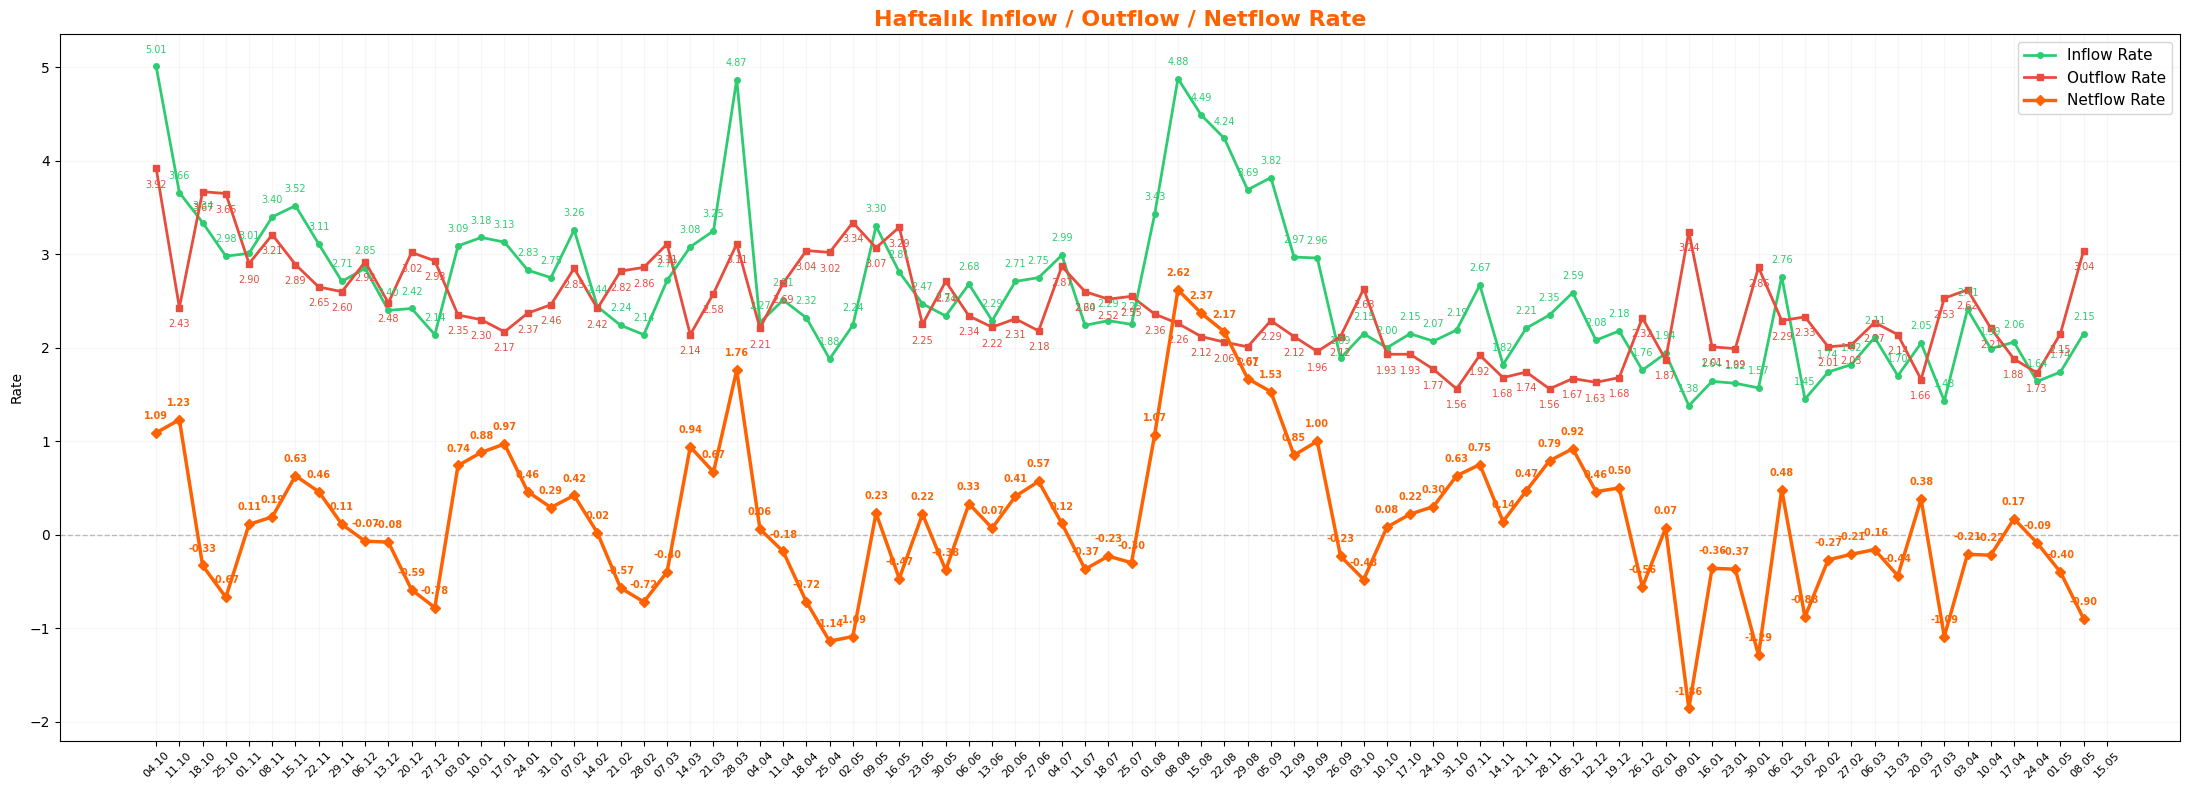

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# PAZARTESİ INPUT — bu haftanın değerleri (input() yerine config dict)
# ────────────────────────────────────────────────────────────────────────────
# İş birimi yalnız 3 KONTROL KALDIRACINI girer (Pazartesi T anı protokolü):
#   - osawelcome        : Welcome promo rate (iş birimi politika kararı)
#   - TLREF             : TCMB referans faiz (T anı seviyesi)
#   - Market_Anomaly    : Piyasa anomali flag'i (0/1)
#
# Değer None bırakılırsa bir önceki haftanın değeri otomatik kullanılır.
#
# Aşağıdaki değişkenler İŞ BİRİMİ KARAR DEĞİŞKENİ DEĞİL → manuel override kapalı:
#   - osaftp                 : Bankanın iç fonlama transfer fiyatı, treasury seti
#   - maliyet_hosgeldin_orani: Portföy karmasından çıkan realizasyon oranı
#   Her ikisi de PORTFOY GERCEKLEŞMESİDİR; iş birimi anlık karar veremez.
#   Otomatik olarak önceki hafta değeri kullanılır (forward-fill).
# ════════════════════════════════════════════════════════════════════════════
WEEKLY_INPUTS = {
    'osawelcome':              None,   # ör. 40.0  ← iş birimi girer
    'TLREF':                   None,   # ör. 45.0  ← iş birimi girer
    'Market_Anomaly':          None,   # ör. 0     ← iş birimi girer
    # 'osaftp':                None,   # KAPALI — treasury kararı, iş birimi giremez
    # 'maliyet_hosgeldin_orani': None,  # KAPALI — realizasyon oranı, iş birimi giremez
}

# 1. Veri Kaynaklarını Yükle
df_macro = pd.read_excel('external_dataset.xlsx', sheet_name='Sheet1', header=2)  # Sheet1 başlığı 2. satırda
df_internal = pd.read_csv('internal_dataset.csv')          # Banka iç verileri
# 1b. Seçici Round — küçük ölçekli feature'larda bilgi kaybını önle
#     Kur_Vol ort.=0.0015, PP Getiri ort.=0.005 gibi sütunlar
#     round(2) ile bilgilerini kaybeder → bu sütunlara round(6).
#     Büyük ölçekli sütunlar (TLREF ~40, VIX ~20 vs.) → round(2).
def _smart_round(frame):
    num_cols = frame.select_dtypes(include='number').columns
    for c in num_cols:
        col_mean = frame[c].abs().mean()
        if pd.isna(col_mean) or col_mean == 0:
            continue
        frame[c] = frame[c].round(2 if col_mean >= 1 else 6)
    return frame

df_macro = _smart_round(df_macro)
df_internal = _smart_round(df_internal)

# 2. Tarih Standardizasyonu
df_macro['Date'] = pd.to_datetime(df_macro['Max_Tarih'], format='mixed', dayfirst=True)
df_internal['Date'] = pd.to_datetime(df_internal['max_tarih'], format='mixed', dayfirst=True)

# 2b. Cuma günü filtresi: max_tarih bugünden büyükse o satırı kaldır
today = pd.Timestamp.today().normalize()
df_internal = df_internal[df_internal['Date'] <= today].reset_index(drop=True)

# 2c. Kapanmamış hafta koruması:
_weekday = today.weekday()
_days_since_fri = (_weekday - 4) % 7
if _days_since_fri == 0:
    _last_closed_friday = today - pd.Timedelta(days=7)
else:
    _last_closed_friday = today - pd.Timedelta(days=_days_since_fri)

_rate_cols = ['netflow_rate', 'total_inflow_rate', 'total_outflow_rate']
_incomplete_mask = df_internal['Date'] > _last_closed_friday
if _incomplete_mask.any():
    df_internal.loc[_incomplete_mask, _rate_cols] = np.nan

_impossible = (
    (df_internal['total_inflow_rate'].fillna(0) == 0) &
    (df_internal['total_outflow_rate'].fillna(0) > 0)
)
if _impossible.any():
    df_internal.loc[_impossible, _rate_cols] = np.nan

# 3. Veri Birleştirme (OUTER)
cols_to_drop_macro = [c for c in ['Max Tarih', 'Min Tarih', 'netflow_rate', 'total_inflow_rate', 'total_outflow_rate'] if c in df_macro.columns]
df = pd.merge(
    df_macro.drop(columns=cols_to_drop_macro),
    df_internal,
    on='Date',
    how='outer'
).sort_values('Date').reset_index(drop=True)

df['min_tarih'] = pd.to_datetime(df['min_tarih'], format='mixed', dayfirst=True, errors='coerce')
df['max_tarih'] = pd.to_datetime(df['max_tarih'], format='mixed', dayfirst=True, errors='coerce')
df['min_tarih'] = df['min_tarih'].fillna(pd.to_datetime(df['Min_Tarih'], format='mixed', dayfirst=True, errors='coerce'))
df['max_tarih'] = df['max_tarih'].fillna(pd.to_datetime(df['Max_Tarih'], format='mixed', dayfirst=True, errors='coerce'))
df = df.drop(columns=['Min_Tarih', 'Max_Tarih'])

# 3b. Eksik feature input — WEEKLY_INPUTS config dict'inden okunur (input() yerine)
# Boş (None) değerler bir önceki haftanın değeriyle doldurulur.
_input_keys = ['osawelcome', 'osaftp', 'TLREF', 'Market_Anomaly', 'maliyet_hosgeldin_orani']
_lever_keys = {'osawelcome', 'TLREF', 'Market_Anomaly'}  # is birimi karar degiskenleri
_auto_keys  = {'osaftp', 'maliyet_hosgeldin_orani'}      # treasury/realizasyon — manuel override kapali

for _i in df.index[df['osawelcome'].isna()]:
    _prev = df.loc[:_i-1].dropna(subset=['osawelcome']).iloc[-1]
    print(f"\nEksik hafta: {pd.to_datetime(df.at[_i,'min_tarih']):%d.%m.%Y} – {pd.to_datetime(df.at[_i,'max_tarih']):%d.%m.%Y}")
    _used = {}
    for _k in _input_keys:
        _v = WEEKLY_INPUTS.get(_k)
        _is_lever = _k in _lever_keys
        if _v is None:
            _v = float(_prev[_k])
            if _is_lever:
                _src = "[LEVER, is birimi bos birakti -> onceki hf otomatik]"
            else:
                _src = "[OTOMATIK, manuel override kapali -> onceki hf]"
        else:
            _v = float(_v)
            _src = "[LEVER, is birimi girisi]" if _is_lever else "[OVERRIDE, dict ile manuel set edilmis]"
        df.at[_i, _k] = _v
        _used[_k] = _v
        print(f"   {_k:<24s} = {_v:<8}  {_src}")
    # Türetilen yıllık getiriler (iş birimi formülü — dokunulmaz):
    #   OSAWelcomeAnnual         = (POWER(1 + rate/36500, 365) - 1) * 100
    #   OSAWelcomeAnnualwCurrent = (POWER(1 + (rate/36500) * maliyet_hosgeldin_orani, 365) - 1) * 100
    _r = df.at[_i, 'osawelcome']
    _h = df.at[_i, 'maliyet_hosgeldin_orani']
    df.at[_i, 'osawelcomeannual']         = ((1 + _r / 36500) ** 365 - 1) * 100
    df.at[_i, 'osawelcomeannualwcurrent'] = ((1 + (_r / 36500) * _h) ** 365 - 1) * 100
    print(f"   Türetilen: osawelcomeannual={df.at[_i,'osawelcomeannual']:.4f}, "
          f"osawelcomeannualwcurrent={df.at[_i,'osawelcomeannualwcurrent']:.4f}")

# osawelcomeannualwcurrent: tüm dataset için yeniden üret — eski değerlerde
# bazı satırlarda maliyet_hosgeldin_orani yerine sabit 0.9 kullanılmıştı.
df['osawelcomeannualwcurrent'] = ((1 + (df['osawelcome'] / 36500) * df['maliyet_hosgeldin_orani']) ** 365 - 1) * 100

# is_gunu_sayisi: NaN satırlarda Pzt-Cum aralığı − TR resmi tatilleri.
_yrs = range(int(df['min_tarih'].dt.year.min()), int(df['max_tarih'].dt.year.max()) + 1)
_tr_full = holidays.country_holidays('TR', years=_yrs, categories=('public',))
_tr_half = holidays.country_holidays('TR', years=_yrs, categories=('half_day',))
def _count_workdays(_min_d, _max_d):
    _c = 0.0
    for d in pd.bdate_range(_min_d, _max_d):
        _dt = d.date()
        if _dt in _tr_full:    continue
        elif _dt in _tr_half:  _c += 0.5
        else:                  _c += 1.0
    return _c
_isg_old = df['is_gunu_sayisi'].copy() if 'is_gunu_sayisi' in df.columns else None
df['is_gunu_sayisi'] = df.apply(
    lambda r: _count_workdays(r['min_tarih'], r['max_tarih']), axis=1
)

if _isg_old is not None:
    _diff_mask = (_isg_old != df['is_gunu_sayisi']) & _isg_old.notna()
    if _diff_mask.any():
        _n_changed = int(_diff_mask.sum())
        print(f"is_gunu_sayisi recompute  : {_n_changed} hafta degistirildi (holiday calendar override)")
        for _idx in df.index[_diff_mask]:
            _tarih = df.loc[_idx, 'Date'].strftime('%d.%m.%Y') if 'Date' in df.columns and pd.notna(df.loc[_idx, 'Date']) else f'row {_idx}'
            print(f"  {_tarih}: kaynak={_isg_old.loc[_idx]:.1f} -> hesap={df.loc[_idx, 'is_gunu_sayisi']:.1f}")

# TCMB Onceki_Hafta: NaN olan satırlarda bu haftanın TCMB_Mevduat değerini bir önceki haftadan al
for _src_col, _dst_col in [('TCMB_Mevduat_1M', 'TCMB_Mevduat_1M_Onceki_Hafta'),
                           ('TCMB_Mevduat_3M', 'TCMB_Mevduat_3M_Onceki_Hafta')]:
    if _src_col in df.columns and _dst_col in df.columns:
        df[_dst_col] = df[_dst_col].fillna(df[_src_col].shift(1))

# === Lag dönüşümü için hedef kolon listesi ===
_protected = {
    'NET', 'netflow_rate', 'total_inflow_rate', 'total_outflow_rate',
    'Date', 'min_tarih', 'max_tarih',
    'osawelcome', 'osaftp', 'TLREF', 'Market_Anomaly', 'maliyet_hosgeldin_orani',
    'osawelcomeannual', 'osawelcomeannualwcurrent', 'is_gunu_sayisi',
}
_predict_idx = df.index[df['netflow_rate'].isna()]
_nan_cols = []
if len(_predict_idx) > 0:
    _last_p = df.loc[_predict_idx[-1]]
    _nan_cols = sorted([c for c in df.columns
                        if c not in _protected
                        and not c.endswith('_Onceki_Hafta')
                        and pd.api.types.is_numeric_dtype(df[c])
                        and pd.isna(_last_p[c])])

# === ÖNCESİ: predict satırı + bir önceki referans satırı ===
_base_show_pre = ['Date', 'min_tarih', 'max_tarih', 'netflow_rate',
                  'osawelcome', 'osawelcomeannual', 'osawelcomeannualwcurrent',
                  'osaftp', 'TLREF', 'Market_Anomaly', 'maliyet_hosgeldin_orani',
                  'Benchmark', 'Benchmark_All', 'is_gunu_sayisi']
if len(_predict_idx) > 0:
    _show_idx = []
    for _pi in _predict_idx.tolist():
        if _pi - 1 >= 0 and (_pi - 1) not in _show_idx:
            _show_idx.append(_pi - 1)
        _show_idx.append(_pi)
    _predict_before = df.loc[_show_idx].copy()
    print(f"\nTahmin Haftası — ÖNCESİ (lag dönüşümünden önce, NaN'lı hâl) — alt satır predict, üst satır referans")
    _pred_show_b = [c for c in _base_show_pre + _nan_cols if c in _predict_before.columns]
    display(_predict_before[_pred_show_b].style.format({
        'Date': lambda x: x.strftime('%d.%m.%Y') if pd.notna(x) else '',
        'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y') if pd.notna(x) else '',
        'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y') if pd.notna(x) else ''
    }))

# === Lag dönüşümü: NaN orijinaller → _Onceki_Hafta + orijinalleri drop ===
for _c in _nan_cols:
    _new_col = f'{_c}_Onceki_Hafta'
    if _new_col not in df.columns:
        df[_new_col] = df[_c].shift(1)
    df = df.drop(columns=[_c])
if _nan_cols:
    print(f"\n{len(_nan_cols)} NaN feature için _Onceki_Hafta üretildi + orijinaller drop edildi.")

# Hedef değişkeni standart isme çevir
df = df.rename(columns={'netflow_rate': 'NET'})

# Kolon sıralaması: tarih ve hedef önce
cols_front = ['Date', 'min_tarih', 'max_tarih', 'NET']
other_cols = [c for c in df.columns if c not in cols_front]
df = df[cols_front + other_cols]

# Tahmin Haftası referansı (OUTER merge SONRASI)
_predict_mask = df['NET'].isna()
df_predict = df[_predict_mask].copy()
df = df.reset_index(drop=True)

if len(df_predict) > 0:
    print(f"\nTahmin Haftası — SONRASI (lag dönüşümünden sonra, NaN'sız hâl) — {len(df_predict)} satır ──")
    _base_show = ['Date', 'min_tarih', 'max_tarih', 'NET',
                  'osawelcome', 'osawelcomeannual', 'osawelcomeannualwcurrent',
                  'osaftp', 'TLREF', 'Market_Anomaly',
                  'maliyet_hosgeldin_orani', 'Benchmark', 'Benchmark_All',
                  'is_gunu_sayisi']
    _lag_cols = [f'{c}_Onceki_Hafta' for c in _nan_cols]
    _pred_show = [c for c in _base_show + _lag_cols if c in df_predict.columns]
    _pred_show = [c for c in _pred_show if c in df_predict.columns]
    display(df_predict[_pred_show].style.format({
        'Date': lambda x: x.strftime('%d.%m.%Y') if pd.notna(x) else '',
        'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y') if pd.notna(x) else '',
        'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y') if pd.notna(x) else ''
    }))
    print("Bu haftanın feature'ları geçerli. Model eğitildikten sonra tahmin için kullanılacak.")
else:
    print("\nTüm haftalar kapanmış — tahmin bekleyen satır yok.")

# Kaynak Özeti
print(f"Veri Kaynakları Özeti:")
print(f"Makro Veri     : {len(df_macro)} hafta ({df_macro['Date'].min().strftime('%d.%m.%Y')} → {df_macro['Date'].max().strftime('%d.%m.%Y')})")
print(f"İç Veri        : {len(df_internal)} hafta ({df_internal['Date'].min().strftime('%d.%m.%Y')} → {df_internal['Date'].max().strftime('%d.%m.%Y')})")
print(f"Birleşik Matris: {len(df)} hafta (hedef hizalı)")

# 4. İlk ve Son Satırlar
display(df.head(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))
display(df.tail(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# 5. Birleşik Matris Detayları
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
print(f"Birleşik Matris Detayları:")
print(f"Toplam Satır   : {len(df)}")
print(f"Toplam Değişken: {len(df.columns)}")
print(f"Hedef Doluluğu : {df['NET'].notna().sum()} / {len(df)} dolu gözlem")
print(f"Başlangıç      : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"Bitiş          : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

# 6. Inflow / Outflow / Netflow Tek Grafik
fig, ax = plt.subplots(figsize=(22, 8))

dates = df['Date']

if 'total_inflow_rate' in df.columns:
    ax.plot(dates, df['total_inflow_rate'], color='#2ecc71', linewidth=2, marker='o', markersize=4, label='Inflow Rate')
    for x, y in zip(dates, df['total_inflow_rate']):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=7, color='#2ecc71', ha='center')

if 'total_outflow_rate' in df.columns:
    ax.plot(dates, df['total_outflow_rate'], color='#e74c3c', linewidth=2, marker='s', markersize=4, label='Outflow Rate')
    for x, y in zip(dates, df['total_outflow_rate']):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, -14), fontsize=7, color='#e74c3c', ha='center')

ax.plot(dates, df['NET'], color='#ff6200', linewidth=2.5, marker='D', markersize=5, label='Netflow Rate', zorder=5)
for x, y in zip(dates, df['NET']):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=7, color='#ff6200', ha='center', fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Haftalık Inflow / Outflow / Netflow Rate', fontsize=16, fontweight='bold', color='#ff6200')
ax.set_ylabel('Rate')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.1)
plt.xticks(dates, [d.strftime('%d.%m') for d in dates], rotation=45, fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)


<h2 style="color: rgb(255,98,0)">Outlier Audit</h2>

Netflow Rate bir fark serisi olduğu için (Inflow − Outflow) küçük değişimler bile büyük sıçramalar yaratabilir. 
Aşağıda en uç haftalar tek tek inceleniyor: bu haftalar veri hatası mı, yoksa açıklanabilir iş olayları mı?

Amaç silmek değil, anlamak. Eğer spike'lar kampanya/faiz şoku/çeyrek sonu gibi gerçek olaylara denk geliyorsa modelde kalmalı.

**Ek Analiz — Bileşen Ayrıştırması:**
Her outlier haftada NET sıçramasının kaynağını (Inflow mu, Outflow mu, ikisi birden mi?) tespit etmek ve değerlerin "absürt" mü yoksa açıklanabilir mi olduğunu sayısal olarak doğrulamak için ek diagnostik katmanlar eklendi.

NET Dağılım Özeti:
Ortalama : +0.16
Medyan   : +0.11
Std      : 0.80
Min      : -1.86
Max      : +2.62
IQR Band : [-1.80, +2.02]
IQR Dışı : 4 hafta
Z > 2.0  : 4 hafta

En Yüksek 5 Netflow Haftası:


,Date,min_tarih,max_tarih,NET,z_score,total_inflow_rate,total_outflow_rate,Payday,YearEnd,Ramazan,PPK_Haftasi,Market_Anomaly
44,08.08.2025,04.08.2025,08.08.2025,+2.62,3.06,4.88,2.26,0,0,0,0,0
45,15.08.2025,11.08.2025,15.08.2025,+2.37,2.75,4.49,2.12,1,0,0,0,0
46,22.08.2025,18.08.2025,22.08.2025,+2.17,2.50,4.24,2.06,0,0,0,0,0
25,28.03.2025,24.03.2025,28.03.2025,+1.76,1.99,4.87,3.11,0,0,1,0,1
47,29.08.2025,25.08.2025,29.08.2025,+1.67,1.88,3.69,2.01,1,0,0,0,0



En Düşük 5 Netflow Haftası:


,Date,min_tarih,max_tarih,NET,z_score,total_inflow_rate,total_outflow_rate,Payday,YearEnd,Ramazan,PPK_Haftasi,Market_Anomaly
66,09.01.2026,05.01.2026,09.01.2026,-1.86,2.52,1.38,3.24,0,0,0,0,0
69,30.01.2026,26.01.2026,30.01.2026,-1.29,1.81,1.57,2.86,1,0,0,0,0
29,25.04.2025,21.04.2025,25.04.2025,-1.14,1.62,1.88,3.02,0,0,0,0,1
30,02.05.2025,28.04.2025,02.05.2025,-1.09,1.56,2.24,3.34,1,0,0,0,0
77,27.03.2026,23.03.2026,27.03.2026,-1.09,1.56,1.43,2.53,0,0,0,0,0



Bileşen Ayrıştırması (kanal bazinda dagilim referansi):
Inflow  ort: 2.59  std: 0.79
Outflow ort: 2.43  std: 0.52



,Date,min_tarih,max_tarih,NET,total_inflow_rate,inflow_z,inflow_pctl,total_outflow_rate,outflow_z,outflow_pctl,dominant_driver,absurdity,model_risk
44,08.08.2025,04.08.2025,08.08.2025,+2.62,4.88,+2.91,99%,2.26,-0.33,42%,Inflow Kaynakli,Tek Kanal Anomali,Kabul — Etkinlik Aciklamali
45,15.08.2025,11.08.2025,15.08.2025,+2.37,4.49,+2.42,96%,2.12,-0.60,29%,Inflow Kaynakli,Tek Kanal Anomali,Kabul — Etkinlik Aciklamali
46,22.08.2025,18.08.2025,22.08.2025,+2.17,4.24,+2.10,95%,2.06,-0.71,26%,Inflow Kaynakli,Tek Kanal Anomali,Kabul — Etkinlik Aciklamali
25,28.03.2025,24.03.2025,28.03.2025,+1.76,4.87,+2.90,98%,3.11,+1.30,91%,Inflow Kaynakli,Coskulu Hafta,Kabul — Absurt Ama Etkinlik Var
0,04.10.2024,30.09.2024,04.10.2024,+1.09,5.01,+3.08,100%,3.92,+2.86,100%,Ikisi Birden,Coskulu Hafta,Kabul — Absurt Ama Etkinlik Var
31,09.05.2025,05.05.2025,09.05.2025,+0.23,3.30,+0.90,86%,3.07,+1.23,89%,Outflow Kaynakli,Coskulu Hafta,Kabul — Absurt Ama Etkinlik Var
5,08.11.2024,04.11.2024,08.11.2024,+0.19,3.40,+1.03,88%,3.21,+1.50,93%,Outflow Kaynakli,Coskulu Hafta,Kabul — Absurt Ama Etkinlik Var
58,14.11.2025,10.11.2025,14.11.2025,+0.14,1.82,-0.98,15%,1.68,-1.44,8%,Outflow Kaynakli,Donmus Hafta,Kabul — Absurt Ama Etkinlik Var
81,24.04.2026,20.04.2026,24.04.2026,-0.09,1.64,-1.21,8%,1.73,-1.35,10%,Outflow Kaynakli,Donmus Hafta,Kabul — Absurt Ama Etkinlik Var
2,18.10.2024,14.10.2024,18.10.2024,-0.33,3.34,+0.95,87%,3.67,+2.38,99%,Outflow Kaynakli,Coskulu Hafta,Kabul — Absurt Ama Etkinlik Var


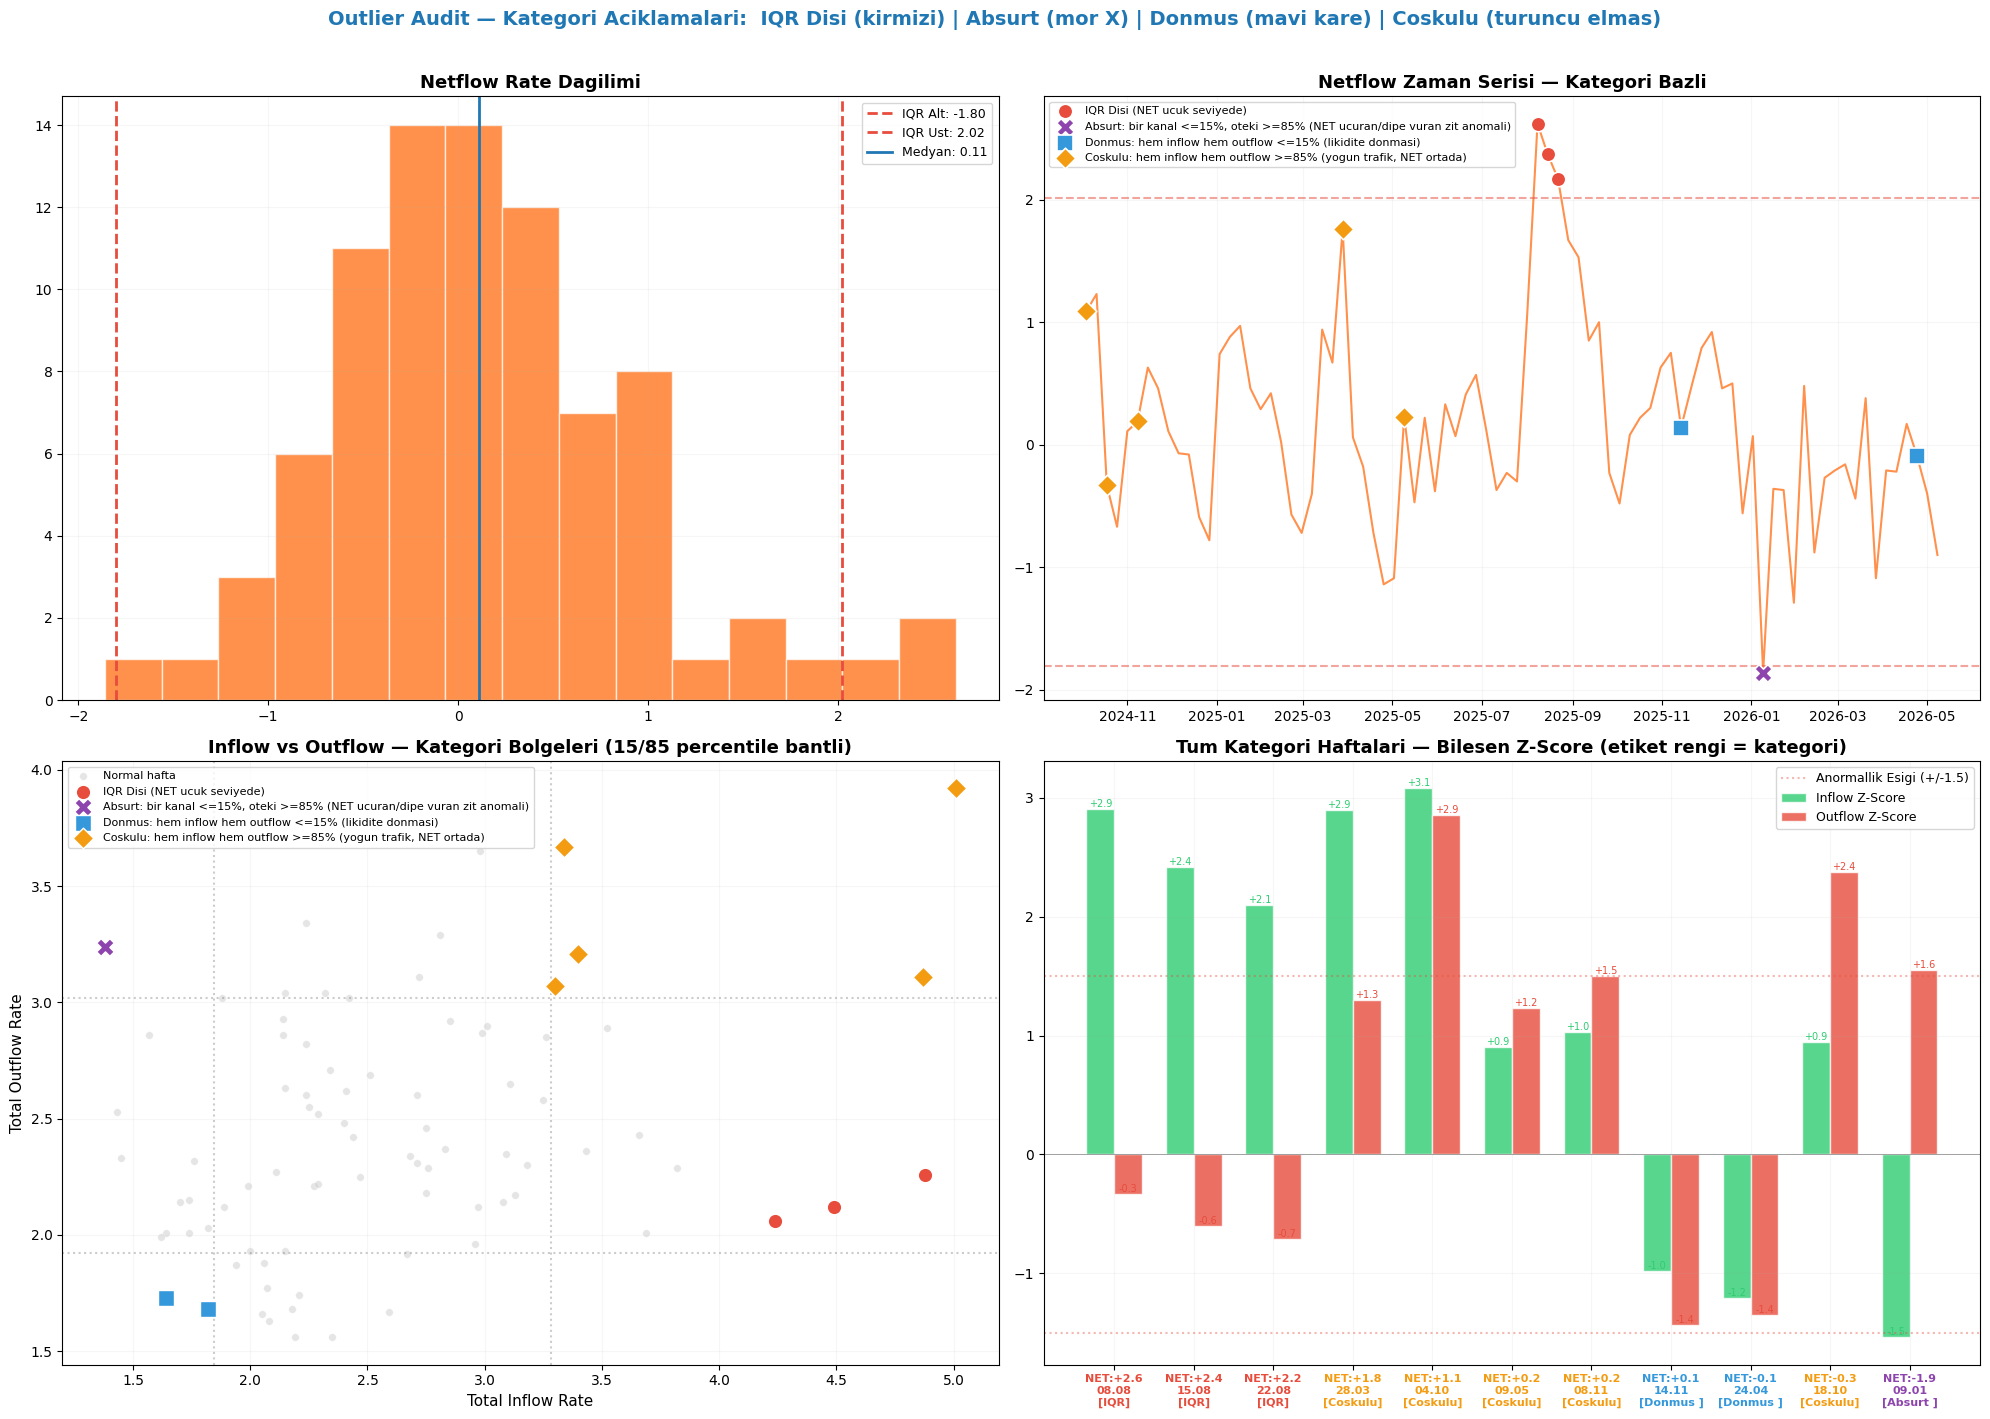


Kategori Tanimlari:
IQR Disi      : O hafta NET, normal haftalardan cok daha buyuk veya cok daha kucuk.
                (NET dagiliminin %25-%75 araligindan 1.5*IQR uzakta — istatistiksel uc deger)
Absurt        : Bir kanal cok dusuk, digeri cok yuksek (NET'i sert biçimde sifirdan uzaklastiran zit hareket).
                Ornek: Inflow %1, Outflow %94 -> NET cok negatif. Genelde yil sonu/maas cikis hangoveri.
Donmus Hafta  : Hem para girisi hem para cikisi cok dusuk -> hesaplara dokunulmamis.
                (Likidite donmasi. Ornek: bayram tatili, herkes hareketsiz)
Coskulu Hafta : Hem para girisi hem para cikisi cok yuksek -> yogun para trafigi var.
                (NET ortada bile olabilir cunku iki kanal birbirini dengeleyebilir.)

Outlier Sayim Ozeti (85 haftalik dataset):
IQR disi hafta :   4  (NET dagiliminin uclarinda)
Absurt anomali :   1  (zit kanal hareketi — NET'i ucuran/dipe vuran)
Donmus hafta   :   2  (her iki kanal cok dusuk)
Coskulu hafta  :   5  (her iki kanal cok y

In [4]:
# BOLUM 1: NET Outlier Tespiti (IQR ve Z-Score)
Q1, Q3 = df['NET'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
z_scores = np.abs((df['NET'] - df['NET'].mean()) / df['NET'].std())

df['is_outlier_iqr'] = (df['NET'] < lower) | (df['NET'] > upper)
df['z_score'] = z_scores.round(2)

print(f"NET Dağılım Özeti:")
print(f"Ortalama : {df['NET'].mean():+.2f}")
print(f"Medyan   : {df['NET'].median():+.2f}")
print(f"Std      : {df['NET'].std():.2f}")
print(f"Min      : {df['NET'].min():+.2f}")
print(f"Max      : {df['NET'].max():+.2f}")
print(f"IQR Band : [{lower:+.2f}, {upper:+.2f}]")
print(f"IQR Dışı : {df['is_outlier_iqr'].sum()} hafta")
print(f"Z > 2.0  : {(z_scores > 2).sum()} hafta\n")

audit_cols = ['Date', 'min_tarih', 'max_tarih', 'NET', 'z_score']
for col in ['total_inflow_rate', 'total_outflow_rate', 'toplam_ntb', 'opening_account', 'avg_vadeli_bakiye',
            'Payday', 'YearEnd', 'Ramazan', 'PPK_Haftasi', 'Market_Anomaly']:
    if col in df.columns:
        audit_cols.append(col)

top5 = df.nlargest(5, 'NET')[audit_cols]
bot5 = df.nsmallest(5, 'NET')[audit_cols]

_topbot_fmt = {
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'NET': '{:+.2f}',
    'z_score': '{:.2f}',
    'total_inflow_rate': '{:.2f}',
    'total_outflow_rate': '{:.2f}',
    'toplam_ntb': '{:,.0f}',
    'opening_account': '{:,.0f}',
    'avg_vadeli_bakiye': '{:,.0f}',
    'Payday': '{:.0f}', 'YearEnd': '{:.0f}', 'Ramazan': '{:.0f}',
    'PPK_Haftasi': '{:.0f}', 'Market_Anomaly': '{:.0f}',
}
print("En Yüksek 5 Netflow Haftası:")
display(top5.style.format({k: v for k, v in _topbot_fmt.items() if k in top5.columns}))

print("\nEn Düşük 5 Netflow Haftası:")
display(bot5.style.format({k: v for k, v in _topbot_fmt.items() if k in bot5.columns}))

# BOLUM 2: Bilesen Ayristirmasi — Kaynak Tespiti (Inflow mu, Outflow mu?)
inflow_mean, inflow_std = df['total_inflow_rate'].mean(), df['total_inflow_rate'].std()
outflow_mean, outflow_std = df['total_outflow_rate'].mean(), df['total_outflow_rate'].std()

df['inflow_z'] = ((df['total_inflow_rate'] - inflow_mean) / inflow_std).round(2)
df['outflow_z'] = ((df['total_outflow_rate'] - outflow_mean) / outflow_std).round(2)

df['inflow_pctl'] = df['total_inflow_rate'].rank(pct=True).round(2)
df['outflow_pctl'] = df['total_outflow_rate'].rank(pct=True).round(2)

def dominant_driver(row):
    inf_z = abs(row['inflow_z'])
    out_z = abs(row['outflow_z'])
    if inf_z > 1.5 and out_z > 1.5:
        return 'Ikisi Birden'
    elif inf_z > out_z:
        return 'Inflow Kaynakli'
    else:
        return 'Outflow Kaynakli'

df['dominant_driver'] = df.apply(dominant_driver, axis=1)

# Absurdity esikleri: %15 / %85 (82 ornekli sette %10 cok dar — orta-yogunluk
# anomalileri kaciyor). Eklenen kategoriler:
#   - 'Donmus Hafta'   : ikisi de <=%15 (likidite donmasi — para hareketi durmus)
#   - 'Coskulu Hafta'  : ikisi de >=%85 (yogun trafik, hem giren hem cikan cok)
#   - 'Absurt'         : bir kanal <=%15 + diger kanal >=%85 (NET'i ucuran/dipe vuran zit anomali)
def absurdity_check(row):
    inf_p, out_p = row['inflow_pctl'], row['outflow_pctl']
    if (inf_p <= 0.15 and out_p >= 0.85) or (inf_p >= 0.85 and out_p <= 0.15):
        return 'Absurt (Iki Yonlu Anomali)'
    if inf_p <= 0.15 and out_p <= 0.15:
        return 'Donmus Hafta'
    if inf_p >= 0.85 and out_p >= 0.85:
        return 'Coskulu Hafta'
    if inf_p <= 0.15 or inf_p >= 0.85 or out_p <= 0.15 or out_p >= 0.85:
        return 'Tek Kanal Anomali'
    return 'Normal Bant Ici'

df['absurdity'] = df.apply(absurdity_check, axis=1)

# Gecikmeli etkinlik flag'leri — KNOWN_AT_T takvim setiyle hizali
event_flags = [
    'Payday', 'YearEnd', 'Ramazan', 'PPK_Haftasi', 'Market_Anomaly',
    'Bayram_Haftasi', 'Bayram_Arefesi', 'Bayram_Sonrasi',
    'Quarter_End', 'Tax_Season', 'Black_Friday',
    'Faiz_Anomaly', 'Market_Stress',
    'Yaz_Turizm', 'Kis_Turizm',
    'Emekli_Maas_Donemi', 'Enflasyon_Aciklama_Haftasi',
    'PPK_Oncesi', 'PPK_Sonrasi',
]
event_flags = [f for f in event_flags if f in df.columns]
for flag in event_flags:
    df[f'{flag}_lag1'] = df[flag].shift(1).fillna(0).astype(int)

def model_risk(row):
    is_outlier = row['is_outlier_iqr']
    absurd_label = row['absurdity']
    absurd = absurd_label in ('Absurt (Iki Yonlu Anomali)', 'Donmus Hafta', 'Coskulu Hafta')

    has_event = any(row.get(f, 0) for f in event_flags)
    has_lagged_event = any(row.get(f'{f}_lag1', 0) for f in event_flags)
    has_any_event = has_event or has_lagged_event

    if not is_outlier and not absurd:
        return 'Normal'
    if absurd and not has_any_event:
        return 'DIKKAT — Absurt + Aciklama Yok'
    if absurd and has_lagged_event and not has_event:
        return 'Kabul — Gecikmeli Etkinlik (Hangover)'
    if absurd and has_event:
        return 'Kabul — Absurt Ama Etkinlik Var'
    if has_event:
        return 'Kabul — Etkinlik Aciklamali'
    if has_lagged_event:
        return 'Kabul — Gecikmeli Etkinlik'
    return 'Kabul — Organik Trend'

df['model_risk'] = df.apply(model_risk, axis=1)

# Outlier Haftalarin Ayristirma Tablosu
decomp_cols = ['Date', 'min_tarih', 'max_tarih', 'NET',
               'total_inflow_rate', 'inflow_z', 'inflow_pctl',
               'total_outflow_rate', 'outflow_z', 'outflow_pctl',
               'dominant_driver', 'absurdity', 'model_risk']

_absurd_categories = ('Absurt (Iki Yonlu Anomali)', 'Donmus Hafta', 'Coskulu Hafta')
_risk_mask = df['is_outlier_iqr'] | df['absurdity'].isin(_absurd_categories)
outlier_decomp = df[_risk_mask].sort_values('NET', ascending=False)[decomp_cols]

print(f"\nBileşen Ayrıştırması (kanal bazinda dagilim referansi):")
print(f"Inflow  ort: {inflow_mean:.2f}  std: {inflow_std:.2f}")
print(f"Outflow ort: {outflow_mean:.2f}  std: {outflow_std:.2f}")
print()

if len(outlier_decomp) > 0:
    display(outlier_decomp.style.format({
        'Date': lambda x: x.strftime('%d.%m.%Y'),
        'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
        'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
        'NET': '{:+.2f}',
        'total_inflow_rate': '{:.2f}',
        'total_outflow_rate': '{:.2f}',
        'inflow_z': '{:+.2f}', 'outflow_z': '{:+.2f}',
        'inflow_pctl': '{:.0%}', 'outflow_pctl': '{:.0%}'
    }).map(lambda v: 'background-color: #ffe0e0; color: #000' if v == 'DIKKAT — Absurt + Aciklama Yok'
           else ('background-color: #e0ffe0; color: #000' if 'Kabul' in str(v) else ''),
           subset=['model_risk']))
else:
    print("IQR dışı outlier hafta bulunmadı.")

# ── Kategori-Renk-Marker Esleme (4 panelde tutarli kullanilir) ──
CAT_STYLE = {
    'IQR Disi':           {'color': '#e74c3c', 'marker': 'o', 'size': 110, 'label': 'IQR Disi (NET ucuk seviyede)'},
    'Absurt (Iki Yonlu Anomali)': {'color': '#8e44ad', 'marker': 'X', 'size': 160, 'label': 'Absurt: bir kanal <=15%, oteki >=85% (NET ucuran/dipe vuran zit anomali)'},
    'Donmus Hafta':       {'color': '#3498db', 'marker': 's', 'size': 130, 'label': 'Donmus: hem inflow hem outflow <=15% (likidite donmasi)'},
    'Coskulu Hafta':      {'color': '#f39c12', 'marker': 'D', 'size': 110, 'label': 'Coskulu: hem inflow hem outflow >=85% (yogun trafik, NET ortada)'},
}

# BOLUM 3: Gorsellestirme (4 Panel — kategori bazli isaretleme)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel 1: NET Histogram + IQR sinirlari
axes[0, 0].hist(df['NET'], bins=15, alpha=0.7, color='#ff6200', edgecolor='white')
axes[0, 0].axvline(lower, color='#e74c3c', linestyle='--', linewidth=2, label=f'IQR Alt: {lower:.2f}')
axes[0, 0].axvline(upper, color='#e74c3c', linestyle='--', linewidth=2, label=f'IQR Ust: {upper:.2f}')
axes[0, 0].axvline(df['NET'].median(), color='#1f77b4', linestyle='-', linewidth=2, label=f'Medyan: {df["NET"].median():.2f}')
axes[0, 0].set_title('Netflow Rate Dagilimi', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.1)

# Panel 2: Zaman serisi + 4 kategori (IQR / Absurt / Donmus / Coskulu)
axes[0, 1].plot(df['Date'], df['NET'], color='#ff6200', linewidth=1.5, alpha=0.7)
axes[0, 1].axhline(upper, color='#e74c3c', linestyle='--', alpha=0.5)
axes[0, 1].axhline(lower, color='#e74c3c', linestyle='--', alpha=0.5)

# Once IQR disi (en altta), sonra absurd kategoriler ustte
_iqr_only = df['is_outlier_iqr'] & ~df['absurdity'].isin(_absurd_categories)
if _iqr_only.any():
    s = CAT_STYLE['IQR Disi']
    axes[0, 1].scatter(df.loc[_iqr_only, 'Date'], df.loc[_iqr_only, 'NET'],
                       c=s['color'], marker=s['marker'], s=s['size'], zorder=4,
                       edgecolors='white', linewidth=1.2, label=s['label'])
for cat in ('Absurt (Iki Yonlu Anomali)', 'Donmus Hafta', 'Coskulu Hafta'):
    mask = df['absurdity'] == cat
    if mask.any():
        s = CAT_STYLE[cat]
        axes[0, 1].scatter(df.loc[mask, 'Date'], df.loc[mask, 'NET'],
                           c=s['color'], marker=s['marker'], s=s['size'], zorder=5,
                           edgecolors='white', linewidth=1.2, label=s['label'])
axes[0, 1].set_title('Netflow Zaman Serisi — Kategori Bazli', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=8, loc='best')
axes[0, 1].grid(True, alpha=0.1)

# Panel 3: Inflow vs Outflow Scatter (kategori bazli)
# Once normal noktalar gri arka plan
_normal_mask = ~df['is_outlier_iqr'] & ~df['absurdity'].isin(_absurd_categories)
axes[1, 0].scatter(df.loc[_normal_mask, 'total_inflow_rate'],
                   df.loc[_normal_mask, 'total_outflow_rate'],
                   c='#cccccc', s=30, alpha=0.5, edgecolors='white', linewidth=0.5, zorder=2,
                   label='Normal hafta')
# IQR disi (absurd degil)
if _iqr_only.any():
    s = CAT_STYLE['IQR Disi']
    axes[1, 0].scatter(df.loc[_iqr_only, 'total_inflow_rate'],
                       df.loc[_iqr_only, 'total_outflow_rate'],
                       c=s['color'], marker=s['marker'], s=s['size'], zorder=4,
                       edgecolors='white', linewidth=1.0, label=s['label'])
# Absurd kategoriler
for cat in ('Absurt (Iki Yonlu Anomali)', 'Donmus Hafta', 'Coskulu Hafta'):
    mask = df['absurdity'] == cat
    if mask.any():
        s = CAT_STYLE[cat]
        axes[1, 0].scatter(df.loc[mask, 'total_inflow_rate'],
                           df.loc[mask, 'total_outflow_rate'],
                           c=s['color'], marker=s['marker'], s=s['size'], zorder=5,
                           edgecolors='white', linewidth=1.0, label=s['label'])
# Bant cizgileri (15/85 percentile)
inflow_p15, inflow_p85 = df['total_inflow_rate'].quantile([0.15, 0.85])
outflow_p15, outflow_p85 = df['total_outflow_rate'].quantile([0.15, 0.85])
axes[1, 0].axvline(inflow_p15, color='gray', linestyle=':', alpha=0.4)
axes[1, 0].axvline(inflow_p85, color='gray', linestyle=':', alpha=0.4)
axes[1, 0].axhline(outflow_p15, color='gray', linestyle=':', alpha=0.4)
axes[1, 0].axhline(outflow_p85, color='gray', linestyle=':', alpha=0.4)
axes[1, 0].set_xlabel('Total Inflow Rate', fontsize=11)
axes[1, 0].set_ylabel('Total Outflow Rate', fontsize=11)
axes[1, 0].set_title('Inflow vs Outflow — Kategori Bolgeleri (15/85 percentile bantli)', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=8, loc='best')
axes[1, 0].grid(True, alpha=0.1)

# Panel 4: TUM kategori haftalarinin Z-Score karsilastirmasi
_panel_mask = df['is_outlier_iqr'] | df['absurdity'].isin(_absurd_categories)
panel_df = df[_panel_mask].sort_values('NET', ascending=False).copy()
if len(panel_df) > 0:
    x_pos = np.arange(len(panel_df))
    width = 0.35
    bars1 = axes[1, 1].bar(x_pos - width/2, panel_df['inflow_z'], width,
                           label='Inflow Z-Score', color='#2ecc71', alpha=0.8, edgecolor='white')
    bars2 = axes[1, 1].bar(x_pos + width/2, panel_df['outflow_z'], width,
                           label='Outflow Z-Score', color='#e74c3c', alpha=0.8, edgecolor='white')
    # Etiketleri kategori ile renklendir
    def _cat_color(row):
        if row['absurdity'] in CAT_STYLE:
            return CAT_STYLE[row['absurdity']]['color']
        if row['is_outlier_iqr']:
            return CAT_STYLE['IQR Disi']['color']
        return '#555555'
    label_colors = [_cat_color(r) for _, r in panel_df.iterrows()]
    axes[1, 1].set_xticks(x_pos)
    labels = [f'NET:{r["NET"]:+.1f}\n{r["Date"].strftime("%d.%m")}\n[{r["absurdity"][:7] if r["absurdity"] in CAT_STYLE else "IQR"}]'
              for _, r in panel_df.iterrows()]
    axes[1, 1].set_xticklabels(labels, fontsize=8)
    for tick, c in zip(axes[1, 1].get_xticklabels(), label_colors):
        tick.set_color(c)
        tick.set_fontweight('bold')
    axes[1, 1].axhline(0, color='gray', linestyle='-', linewidth=0.5)
    axes[1, 1].axhline(1.5, color='#e74c3c', linestyle=':', alpha=0.4, label='Anormallik Esigi (+/-1.5)')
    axes[1, 1].axhline(-1.5, color='#e74c3c', linestyle=':', alpha=0.4)
    for bar in bars1:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{bar.get_height():+.1f}', ha='center', va='bottom', fontsize=7, color='#2ecc71')
    for bar in bars2:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{bar.get_height():+.1f}', ha='center', va='bottom', fontsize=7, color='#e74c3c')
axes[1, 1].set_title('Tum Kategori Haftalari — Bilesen Z-Score (etiket rengi = kategori)', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.1)

fig.suptitle('Outlier Audit — Kategori Aciklamalari:  IQR Disi (kirmizi) | Absurt (mor X) | Donmus (mavi kare) | Coskulu (turuncu elmas)',
             fontsize=14, fontweight='bold', color='#1f77b4', y=1.01)
fig.tight_layout()
plt.show()
plt.close(fig)

# BOLUM 4: Sonuc Ozeti
n_outlier = int(df['is_outlier_iqr'].sum())
n_absurd = int((df['absurdity'] == 'Absurt (Iki Yonlu Anomali)').sum())
n_donmus = int((df['absurdity'] == 'Donmus Hafta').sum())
n_coskulu = int((df['absurdity'] == 'Coskulu Hafta').sum())
n_risky = int((df['model_risk'] == 'DIKKAT — Absurt + Aciklama Yok').sum())

absurd_weeks = df[df['absurdity'].isin(_absurd_categories)][
    ['Date', 'NET', 'total_inflow_rate', 'inflow_pctl',
     'total_outflow_rate', 'outflow_pctl', 'absurdity', 'model_risk']
].copy()

print(f"\nKategori Tanimlari:")
print(f"IQR Disi      : O hafta NET, normal haftalardan cok daha buyuk veya cok daha kucuk.")
print(f"                (NET dagiliminin %25-%75 araligindan 1.5*IQR uzakta — istatistiksel uc deger)")
print(f"Absurt        : Bir kanal cok dusuk, digeri cok yuksek (NET'i sert biçimde sifirdan uzaklastiran zit hareket).")
print(f"                Ornek: Inflow %1, Outflow %94 -> NET cok negatif. Genelde yil sonu/maas cikis hangoveri.")
print(f"Donmus Hafta  : Hem para girisi hem para cikisi cok dusuk -> hesaplara dokunulmamis.")
print(f"                (Likidite donmasi. Ornek: bayram tatili, herkes hareketsiz)")
print(f"Coskulu Hafta : Hem para girisi hem para cikisi cok yuksek -> yogun para trafigi var.")
print(f"                (NET ortada bile olabilir cunku iki kanal birbirini dengeleyebilir.)")
print()
print(f"Outlier Sayim Ozeti ({len(df)} haftalik dataset):")
print(f"IQR disi hafta : {n_outlier:>3d}  (NET dagiliminin uclarinda)")
print(f"Absurt anomali : {n_absurd:>3d}  (zit kanal hareketi — NET'i ucuran/dipe vuran)")
print(f"Donmus hafta   : {n_donmus:>3d}  (her iki kanal cok dusuk)")
print(f"Coskulu hafta  : {n_coskulu:>3d}  (her iki kanal cok yuksek)")
print(f"Aciklanamayan  : {n_risky:>3d}  (etkinlik flag'i ile aciklanamayan kategori-haftasi)")

if len(absurd_weeks) > 0:
    print(f"\nAbsurd Kategori Haftalari (kategori karari Inflow/Outflow percentile'larina gore verilir):")
    print(f"Esik kurali: <=15% 'cok dusuk',  >=85% 'cok yuksek' bu durumlar NET'i normalden cok uzaklastirir.\n")
    print(f"{'Tarih':<11}  {'NET':>6}   {'Inflow':>6} {'pct':>5}   {'Outflow':>7} {'pct':>5}   {'Kategori':<28}  Aciklama")
    print(f"  {'-'*11}  {'-'*6}   {'-'*6} {'-'*5}   {'-'*7} {'-'*5}   {'-'*28}  {'-'*40}")
    _cat_order = {'Absurt (Iki Yonlu Anomali)': 0, 'Donmus Hafta': 1, 'Coskulu Hafta': 2}
    _absurd_sorted = absurd_weeks.assign(_ord=absurd_weeks['absurdity'].map(_cat_order)).sort_values(['_ord', 'Date'])
    for _, r in _absurd_sorted.iterrows():
        print(f"  {r['Date'].strftime('%d.%m.%Y')}  {r['NET']:+6.2f}   "
              f"{r['total_inflow_rate']:>6.2f} {r['inflow_pctl']*100:>4.0f}%   "
              f"{r['total_outflow_rate']:>7.2f} {r['outflow_pctl']*100:>4.0f}%   "
              f"{r['absurdity']:<28}  {r['model_risk']}")

print()
if n_risky == 0:
    print(f"KARAR: Modele alinabilir. {len(absurd_weeks)} absurd-kategori hafta etkinlik/hangover ile aciklaniyor.") if len(absurd_weeks) > 0 else print("KARAR: Modele alinabilir. Hicbir absurd kategori hafta yok.")
else:
    print(f"UYARI: {n_risky} hafta etkinlik flag'i ile aciklanamiyor — veri kalitesi kontrol edilmeli.")

# Temizlik: gecici kolonlari kaldir
lag_cols = [f'{f}_lag1' for f in event_flags if f'{f}_lag1' in df.columns]
df = df.drop(columns=['is_outlier_iqr', 'z_score', 'inflow_z', 'outflow_z',
                       'inflow_pctl', 'outflow_pctl', 'dominant_driver',
                       'absurdity', 'model_risk'] + lag_cols)


<h2 style="color: rgb(255,98,0)">Türetilmiş Değişkenler (Feature Engineering)</h2>

Bu adımda faiz dönüşümleri ve taktik spread hesaplamaları yapılarak ürünün piyasa benchmark'larına göre 
göreli çekiciliği ölçülür.

In [5]:
# TCMB 1M & 3M: İş birimi isteği doğrultusunda tablo bazında güncelleme
# Kaynak: İş biriminin paylaştığı haftalık TCMB faiz tablosu (Book1.xlsx)
#
# YAKLAŞIM (revize): Tablodaki değer X tarihinin T-anı TCMB değeridir.
#   1) LEVEL kolonlarını (TCMB_Mevduat_1M, TCMB_Mevduat_3M) X tarihine yaz
#      (yoksa yarat, varsa override et — single source of truth)
#   2) _Onceki_Hafta kolonlarını LEVEL.shift(1) ile yeniden hesapla
#      (downstream FE _Onceki_Hafta'yı kullanır, level'i de momentum baz olarak)
#   3) Bu sayede tüm derivasyonlar (delta1, roll4_mean, roll4_std, w/1month, vs.)
#      otomatik güncel TCMB değerlerini kullanır

import pandas as pd
import numpy as np

tcmb_update = pd.DataFrame({
    "Date": pd.to_datetime([
        "2024-10-04", "2024-10-11", "2024-10-18", "2024-10-25",
        "2024-11-01", "2024-11-08", "2024-11-15", "2024-11-22",
        "2024-11-29", "2024-12-06", "2024-12-13", "2024-12-20",
        "2024-12-27", "2025-01-03", "2025-01-10", "2025-01-17",
        "2025-01-24", "2025-01-31", "2025-02-07", "2025-02-14",
        "2025-02-21", "2025-02-28", "2025-03-07", "2025-03-14",
        "2025-03-21", "2025-03-28", "2025-04-04", "2025-04-11",
        "2025-04-18", "2025-04-25", "2025-05-02", "2025-05-09",
        "2025-05-16", "2025-05-23", "2025-05-30", "2025-06-06",
        "2025-06-13", "2025-06-20", "2025-06-27", "2025-07-04",
        "2025-07-11", "2025-07-18", "2025-07-25", "2025-08-01",
        "2025-08-08", "2025-08-15",
    ]),
    "TCMB 1M": [
        54.07, 54.18, 53.81, 53.78,
        53.43, 53.23, 53.24, 53.31,
        53.36, 53.44, 53.87, 53.84,
        53.49, 52.83, 52.46, 52.25,
        51.41, 50.70, 49.79, 49.46,
        49.00, 48.81, 47.44, 47.11,
        47.10, 49.11, 49.24, 49.80,
        51.17, 52.18, 53.94, 54.52,
        55.13, 55.32, 55.50, 55.47,
        55.58, 55.63, 55.62, 55.66,
        55.02, 54.51, 52.59, 52.00,
        51.50, 51.31,
    ],
    "TCMB 3M": [
        59.53, 59.24, 59.07, 59.20,
        58.77, 58.78, 58.90, 59.22,
        58.99, 59.26, 58.98, 59.26,
        58.80, 56.91, 55.43, 54.98,
        53.80, 52.53, 52.45, 52.33,
        52.36, 52.20, 51.73, 50.07,
        50.15, 54.01, 53.81, 54.41,
        55.44, 56.55, 57.82, 58.12,
        58.69, 58.93, 59.10, 59.41,
        58.44, 58.48, 57.73, 58.07,
        57.43, 56.59, 55.23, 52.79,
        52.34, 51.92,
    ],
})

# Rename to LEVEL column names (X tarihindeki TCMB değeri)
upd_levels = tcmb_update.rename(columns={
    "TCMB 1M": "TCMB_Mevduat_1M",
    "TCMB 3M": "TCMB_Mevduat_3M",
})

# Level kolonlari yoksa yarat (onceki cell'de drop edilmis olabilir)
# Mevcut _Onceki_Hafta'dan un-lag ile geri donder (basitce shift(-1))
for col in ("TCMB_Mevduat_1M", "TCMB_Mevduat_3M"):
    if col not in df.columns:
        if f"{col}_Onceki_Hafta" in df.columns:
            df[col] = df[f"{col}_Onceki_Hafta"].shift(-1)
        else:
            df[col] = np.nan

# SEED: Tablonun ilk tarihi 2024-10-04, dolayisiyla 2024-10-04'un _Onceki_Hafta'si
# normalde 2024-09-27 LEVEL'inden gelir. Bu tarih df'te ya yok ya da NaN.
# Manuel olarak 2024-09-27 LEVEL'ini set ediyoruz → shift(1) ile 2024-10-04 _Onceki_Hafta dolu gelsin.
_seed_date = pd.Timestamp("2024-09-27")
_seed_values = {"TCMB_Mevduat_1M": 54.03, "TCMB_Mevduat_3M": 59.05}

# Level update (X tarihine direkt yaz, +7 shift YOK) — seed dahil
df_date_idx = df.set_index("Date")
upd_idx     = upd_levels.set_index("Date")
common_dates = upd_idx.index.intersection(df_date_idx.index)
n_matched    = len(common_dates)

df_date_idx.loc[common_dates, "TCMB_Mevduat_1M"] = upd_idx.loc[common_dates, "TCMB_Mevduat_1M"].values
df_date_idx.loc[common_dates, "TCMB_Mevduat_3M"] = upd_idx.loc[common_dates, "TCMB_Mevduat_3M"].values

# Seed: 2024-09-27 LEVEL (bu tarih df'te varsa)
_seed_in_df = _seed_date in df_date_idx.index
if _seed_in_df:
    df_date_idx.loc[_seed_date, "TCMB_Mevduat_1M"] = _seed_values["TCMB_Mevduat_1M"]
    df_date_idx.loc[_seed_date, "TCMB_Mevduat_3M"] = _seed_values["TCMB_Mevduat_3M"]

df = df_date_idx.reset_index()

# _Onceki_Hafta'yi LEVEL'den yeniden hesapla — single source of truth
df["TCMB_Mevduat_1M_Onceki_Hafta"] = df["TCMB_Mevduat_1M"].shift(1)
df["TCMB_Mevduat_3M_Onceki_Hafta"] = df["TCMB_Mevduat_3M"].shift(1)

# Fallback: 2024-09-27 df'te yoksa, 2024-10-04'un _Onceki_Hafta'sini direkt set et
if not _seed_in_df:
    _first_table_date = pd.Timestamp("2024-10-04")
    _mask = df["Date"] == _first_table_date
    if _mask.any():
        df.loc[_mask, "TCMB_Mevduat_1M_Onceki_Hafta"] = _seed_values["TCMB_Mevduat_1M"]
        df.loc[_mask, "TCMB_Mevduat_3M_Onceki_Hafta"] = _seed_values["TCMB_Mevduat_3M"]
        print(f"  Seed fallback: 2024-09-27 df'te yok → 2024-10-04 _Onceki_Hafta direkt set edildi")
    else:
        print(f"  UYARI: ne 2024-09-27 ne 2024-10-04 df'te yok — seed atlandi")
else:
    print(f"  Seed: 2024-09-27 LEVEL = (1M={_seed_values['TCMB_Mevduat_1M']}, 3M={_seed_values['TCMB_Mevduat_3M']}) → 2024-10-04 _Onceki_Hafta otomatik dolacak")

print(f"TCMB level + _Onceki_Hafta yeniden hesaplandi: {n_matched} / {len(tcmb_update)} satir eslesti")
print(f"Kaynak tarih araligi (tablo): {tcmb_update['Date'].min():%d.%m.%Y} -> {tcmb_update['Date'].max():%d.%m.%Y}")
print()

# Dogrulama: guncellenen tarih + level + _Onceki_Hafta yan yana
check = df.loc[df["Date"].isin(upd_levels["Date"]),
               ["Date", "TCMB_Mevduat_1M", "TCMB_Mevduat_1M_Onceki_Hafta",
                "TCMB_Mevduat_3M", "TCMB_Mevduat_3M_Onceki_Hafta"]]
print("Ilk 5 satir (X tarihinde level guncel, X+1 hf'de _Onceki_Hafta=X level):")
display(check.head(5))
print("Son 5 satir:")
display(check.tail(5))


  Seed fallback: 2024-09-27 df'te yok → 2024-10-04 _Onceki_Hafta direkt set edildi
TCMB level + _Onceki_Hafta yeniden hesaplandi: 46 / 46 satir eslesti
Kaynak tarih araligi (tablo): 04.10.2024 -> 15.08.2025

Ilk 5 satir (X tarihinde level guncel, X+1 hf'de _Onceki_Hafta=X level):


,Date,TCMB_Mevduat_1M,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M,TCMB_Mevduat_3M_Onceki_Hafta
0,2024-10-04,54.07,54.03,59.53,59.05
1,2024-10-11,54.18,54.07,59.24,59.53
2,2024-10-18,53.81,54.18,59.07,59.24
3,2024-10-25,53.78,53.81,59.20,59.07
4,2024-11-01,53.43,53.78,58.77,59.20


Son 5 satir:


,Date,TCMB_Mevduat_1M,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M,TCMB_Mevduat_3M_Onceki_Hafta
41,2025-07-18,54.51,55.02,56.59,57.43
42,2025-07-25,52.59,54.51,55.23,56.59
43,2025-08-01,52.00,52.59,52.79,55.23
44,2025-08-08,51.50,52.00,52.34,52.79
45,2025-08-15,51.31,51.50,51.92,52.34


In [6]:
# Bileşik / Basit faiz dönüşümleri (İş birimi Excel formülleri — formüller dokunulmaz)
# Lag dönüşümü sonrası TCMB / osabook orijinalleri drop edildi → sadece *_Onceki_Hafta var.
# T ve T-1 zaman ekseni karıştırılmaz: T-blokta türetilen tüm değerler T anı,
# T-1 blokta hepsi geçen haftanın snapshot'ı (isim suffix'i _Onceki_Hafta).

# ──────────────────────────────────────────────────────────────────────
# T anı (cari hafta) — input ile dolu kolonlardan türetilen
# ──────────────────────────────────────────────────────────────────────
# TLREF: basit yıllık (%) → bileşik yıllık
df["TLREF_Bilesik"] = ((1 + df["TLREF"] / 100 / 365) ** 365 - 1) * 100

# Spread'ler — ürün faizinin TLREF/Benchmark'a göre T anı konumu
df["w/TLREF"]            = df["osawelcomeannual"]         - df["TLREF_Bilesik"]
df["w/TLREF(deltas)"]    = df["osawelcomeannualwcurrent"] - df["TLREF_Bilesik"]
df["osawelcome-benchmark"] = df["osawelcome"] - df["Benchmark"]

# ──────────────────────────────────────────────────────────────────────
# T-1 anı (geçen hafta snapshot) — _Onceki_Hafta kolonlarından türetilen
# ──────────────────────────────────────────────────────────────────────
# Önce T-anı türevlerinin T-1 versiyonlarını shift ile üret
df["TLREF_Onceki_Hafta"]                     = df["TLREF"].shift(1)
df["TLREF_Bilesik_Onceki_Hafta"]             = df["TLREF_Bilesik"].shift(1)
df["osawelcomeannual_Onceki_Hafta"]         = df["osawelcomeannual"].shift(1)
df["osawelcomeannualwcurrent_Onceki_Hafta"] = df["osawelcomeannualwcurrent"].shift(1)

# TCMB 1M (T-1): bileşik yıllık → eşdeğer basit yıllık (günlük × 365)
df["TCMB_1M_Basit_Onceki_Hafta"] = ((1 + df["TCMB_Mevduat_1M_Onceki_Hafta"] / 100) ** (1/365) - 1) * 365 * 100

# TCMB 3M (T-1): bileşik yıllık → eşdeğer basit yıllık (aylık × 12)
df["TCMB_3M_Basit_Onceki_Hafta"] = ((1 + df["TCMB_Mevduat_3M_Onceki_Hafta"] / 100) ** (1/12) - 1) * 12 * 100

# EXP(CBavg-TLREF) (T-1): Excel formülü, hepsi geçen haftanın değeri
df["EXP(CBavg-TLREF)_Onceki_Hafta"] = np.exp(df["TCMB_3M_Basit_Onceki_Hafta"] - df["TLREF_Onceki_Hafta"])

# Welcome vs TCMB spread'leri (T-1 vs T-1)
df["w/1month_Onceki_Hafta"]         = df["osawelcomeannual_Onceki_Hafta"]         - df["TCMB_Mevduat_1M_Onceki_Hafta"]
df["w/3month_Onceki_Hafta"]         = df["osawelcomeannual_Onceki_Hafta"]         - df["TCMB_Mevduat_3M_Onceki_Hafta"]
df["w/1month(deltas)_Onceki_Hafta"] = df["osawelcomeannualwcurrent_Onceki_Hafta"] - df["TCMB_Mevduat_1M_Onceki_Hafta"]
df["w/3month(deltas)_Onceki_Hafta"] = df["osawelcomeannualwcurrent_Onceki_Hafta"] - df["TCMB_Mevduat_3M_Onceki_Hafta"]

# TCMB basit faiz vs TLREF spread'leri (T-1 vs T-1)
df["<1month-TLREF_Onceki_Hafta"] = df["TCMB_1M_Basit_Onceki_Hafta"] - df["TLREF_Onceki_Hafta"]
df["<3month-TLREF_Onceki_Hafta"] = df["TCMB_3M_Basit_Onceki_Hafta"] - df["TLREF_Onceki_Hafta"]

# ──────────────────────────────────────────────────────────────────────
# Display
# ──────────────────────────────────────────────────────────────────────
print("Tüm Değişkenler — İlk 5:")
display(_smart_round(df.head(5).copy()).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))
print("Tüm Değişkenler — Son 5:")
display(_smart_round(df.tail(5).copy()).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# Faiz & spread özet tablosu — T ve T-1 grupları ayrı
faiz_cols = [
    'Date', 'min_tarih', 'max_tarih', 'NET',
    # T anı
    'osawelcome', 'osawelcomeannual', 'osawelcomeannualwcurrent',
    'TLREF', 'TLREF_Bilesik',
    'osawelcome-benchmark', 'Benchmark',
    'w/TLREF', 'w/TLREF(deltas)',
    'total_inflow_rate', 'total_outflow_rate',
    # T-1 anı
    'TLREF_Onceki_Hafta', 'TLREF_Bilesik_Onceki_Hafta',
    'osawelcomeannual_Onceki_Hafta', 'osawelcomeannualwcurrent_Onceki_Hafta',
    'osabook_Onceki_Hafta', 'osabook_basit_Onceki_Hafta',
    'TCMB_Mevduat_1M_Onceki_Hafta', 'TCMB_Mevduat_3M_Onceki_Hafta',
    'TCMB_1M_Basit_Onceki_Hafta', 'TCMB_3M_Basit_Onceki_Hafta',
    'EXP(CBavg-TLREF)_Onceki_Hafta',
    'w/1month_Onceki_Hafta', 'w/3month_Onceki_Hafta',
    'w/1month(deltas)_Onceki_Hafta', 'w/3month(deltas)_Onceki_Hafta',
    '<1month-TLREF_Onceki_Hafta', '<3month-TLREF_Onceki_Hafta',
]
seen = set()
faiz_cols_unique = []
for c in faiz_cols:
    if c in df.columns and c not in seen:
        faiz_cols_unique.append(c)
        seen.add(c)
faiz_cols = faiz_cols_unique
_fmt = {
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
}
_props = {'font-size': '10px'}
print("Faiz & Spread — İlk 5:")
display(_smart_round(df[faiz_cols].head(5).copy()).style.format(_fmt).set_properties(**_props))
print("Faiz & Spread — Son 5:")
display(_smart_round(df[faiz_cols].tail(5).copy()).style.format(_fmt).set_properties(**_props))

def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')

# Matris Detayları
print(f"Matris Detayları:")
print(f"Toplam Satır   : {len(df)}")
print(f"Toplam Değişken: {len(df.columns)}")
print(f"Başlangıç      : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"Bitiş          : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")
print(f"Hedef Doluluğu : {df['NET'].notna().sum()} / {len(df)} dolu gözlem")


Tüm Değişkenler — İlk 5:


,Date,min_tarih,max_tarih,NET,Yıl,Hafta,TLREF,AOFM,PP_Getiri,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M_Onceki_Hafta,Benchmark,Benchmark_All,BIST100,Sepet_Kur,Full_Workday,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,Kur_Vol,Gram_Altin_TRY,BIST_Vol,TCMB_Net_Fonlama_TL,USDT_TRY_Hacim,WebTufe_TUFE_Aylik,WebTufe_TUFE_Yillik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,Payday,Emekli_Maas_Donemi,Tax_Season,Ay_Sonu_Haftasi,Bayram_Haftasi,Bayram_Arefesi,Bayram_Sonrasi,Milli_Bayram_Haftasi,Season,Month,YearEnd,Okul_Tatili,Somestr_Tatili,Ara_Tatil,Quarter_End,Ramazan,Black_Friday,Yaz_Turizm,Kis_Turizm,Temetu_Donemi,PPK_Haftasi,PPK_Oncesi,PPK_Sonrasi,Enflasyon_Aciklama_Haftasi,Market_Anomaly,Faiz_Anomaly,Market_Stress,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,BKM_Giyim_TL_Onceki_Hafta,BKM_Saglik_Kozmetik_TL_Onceki_Hafta,BKM_Yemek_TL_Onceki_Hafta,CDS_5Y_Onceki_Hafta,Cekirdek_Enflasyon_Onceki_Hafta,Enflasyon_Beklenti_12ay_Onceki_Hafta,Faiz_Spread_Onceki_Hafta,Fin_Guven_Onceki_Hafta,Fin_Guven_S02_Onceki_Hafta,Fin_Guven_S03_Onceki_Hafta,Fin_Guven_S04_Onceki_Hafta,Fin_Guven_S05_Onceki_Hafta,Fin_Guven_S06_Onceki_Hafta,Fin_Guven_S07_Onceki_Hafta,Fin_Guven_S08_Onceki_Hafta,Fin_Guven_S09_Onceki_Hafta,Fin_Guven_S10_Onceki_Hafta,Fin_Guven_S11_Onceki_Hafta,Fin_Guven_S12_Onceki_Hafta,Fin_Guven_S13_Onceki_Hafta,Fin_Guven_S14_Onceki_Hafta,Fin_Guven_S15_Onceki_Hafta,Fin_Guven_S16_Onceki_Hafta,GSYH_Buyume_Beklenti_Onceki_Hafta,GT_En_Yuksek_Onceki_Hafta,GT_Mevduat_Faizi_Onceki_Hafta,Ihtiyac_Kredi_Faizi_Onceki_Hafta,Issizlik_Onceki_Hafta,KKO_Onceki_Hafta,Lipstick_Ratio_Onceki_Hafta,Reel_Giyim_Onceki_Hafta,Reel_Kozmetik_Onceki_Hafta,Reel_Yemek_Onceki_Hafta,Sanayi_Uretim_Onceki_Hafta,TUIK_TUFE_Aylik_Onceki_Hafta,TUIK_TUFE_Yillik_Onceki_Hafta,Ticari_Kredi_Onceki_Hafta,Tuketici_Guven_Onceki_Hafta,avg_th_total_Onceki_Hafta,avg_vadeli_bakiye_Onceki_Hafta,avg_vadeli_tl_Onceki_Hafta,avg_vadesiz_bakiye_Onceki_Hafta,avg_vdeli_spread_Onceki_Hafta,avg_vdesiz_dahil_spread_Onceki_Hafta,opening_account_Onceki_Hafta,osabook_Onceki_Hafta,osabook_basit_Onceki_Hafta,toplam_cof_basit_Onceki_Hafta,toplam_existing_Onceki_Hafta,toplam_ntb_Onceki_Hafta,TCMB_Mevduat_1M,TCMB_Mevduat_3M,TLREF_Bilesik,w/TLREF,w/TLREF(deltas),osawelcome-benchmark,TLREF_Onceki_Hafta,TLREF_Bilesik_Onceki_Hafta,osawelcomeannual_Onceki_Hafta,osawelcomeannualwcurrent_Onceki_Hafta,TCMB_1M_Basit_Onceki_Hafta,TCMB_3M_Basit_Onceki_Hafta,EXP(CBavg-TLREF)_Onceki_Hafta,w/1month_Onceki_Hafta,w/3month_Onceki_Hafta,w/1month(deltas)_Onceki_Hafta,w/3month(deltas)_Onceki_Hafta,<1month-TLREF_Onceki_Hafta,<3month-TLREF_Onceki_Hafta
0,04.10.2024,30.09.2024,04.10.2024,1.090000,2024,Hafta 1,49.940000,50.000000,0.005344,54.030000,59.050000,53.720000,48.770000,9207.490000,35.900000,1,2650.680000,18.920000,13288.920000,1.110000,34.200000,37.920000,4.530000,31.710000,74.980000,101.630000,0.001210,2914.520000,0.014927,-222873.050000,nan,2.450000,nan,81.080000,82.610000,80.070000,80.210000,79.560000,80.210000,80.050000,21057.170000,1,0,0,1,0,0,0,0,4,10,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0.032900,1.720000,nan,nan,nan,nan,1.010000,1.030000,0.989292,1.020000,0,0,0,0,0,53.000000,69.830000,55.210000,47.280000,0.830000,5.000000,5.010000,3.920000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,54.070000,59.530000,64.720000,5.110000,-9.500000,-0.720000,nan,nan,nan,nan,43.220000,47.310000,nan,nan,nan,nan,nan,nan,nan
1,11.10.2024,07.10.2024,11.10.2024,1.230000

Tüm Değişkenler — Son 5:


,Date,min_tarih,max_tarih,NET,Yıl,Hafta,TLREF,AOFM,PP_Getiri,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M_Onceki_Hafta,Benchmark,Benchmark_All,BIST100,Sepet_Kur,Full_Workday,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,Kur_Vol,Gram_Altin_TRY,BIST_Vol,TCMB_Net_Fonlama_TL,USDT_TRY_Hacim,WebTufe_TUFE_Aylik,WebTufe_TUFE_Yillik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,Payday,Emekli_Maas_Donemi,Tax_Season,Ay_Sonu_Haftasi,Bayram_Haftasi,Bayram_Arefesi,Bayram_Sonrasi,Milli_Bayram_Haftasi,Season,Month,YearEnd,Okul_Tatili,Somestr_Tatili,Ara_Tatil,Quarter_End,Ramazan,Black_Friday,Yaz_Turizm,Kis_Turizm,Temetu_Donemi,PPK_Haftasi,PPK_Oncesi,PPK_Sonrasi,Enflasyon_Aciklama_Haftasi,Market_Anomaly,Faiz_Anomaly,Market_Stress,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,BKM_Giyim_TL_Onceki_Hafta,BKM_Saglik_Kozmetik_TL_Onceki_Hafta,BKM_Yemek_TL_Onceki_Hafta,CDS_5Y_Onceki_Hafta,Cekirdek_Enflasyon_Onceki_Hafta,Enflasyon_Beklenti_12ay_Onceki_Hafta,Faiz_Spread_Onceki_Hafta,Fin_Guven_Onceki_Hafta,Fin_Guven_S02_Onceki_Hafta,Fin_Guven_S03_Onceki_Hafta,Fin_Guven_S04_Onceki_Hafta,Fin_Guven_S05_Onceki_Hafta,Fin_Guven_S06_Onceki_Hafta,Fin_Guven_S07_Onceki_Hafta,Fin_Guven_S08_Onceki_Hafta,Fin_Guven_S09_Onceki_Hafta,Fin_Guven_S10_Onceki_Hafta,Fin_Guven_S11_Onceki_Hafta,Fin_Guven_S12_Onceki_Hafta,Fin_Guven_S13_Onceki_Hafta,Fin_Guven_S14_Onceki_Hafta,Fin_Guven_S15_Onceki_Hafta,Fin_Guven_S16_Onceki_Hafta,GSYH_Buyume_Beklenti_Onceki_Hafta,GT_En_Yuksek_Onceki_Hafta,GT_Mevduat_Faizi_Onceki_Hafta,Ihtiyac_Kredi_Faizi_Onceki_Hafta,Issizlik_Onceki_Hafta,KKO_Onceki_Hafta,Lipstick_Ratio_Onceki_Hafta,Reel_Giyim_Onceki_Hafta,Reel_Kozmetik_Onceki_Hafta,Reel_Yemek_Onceki_Hafta,Sanayi_Uretim_Onceki_Hafta,TUIK_TUFE_Aylik_Onceki_Hafta,TUIK_TUFE_Yillik_Onceki_Hafta,Ticari_Kredi_Onceki_Hafta,Tuketici_Guven_Onceki_Hafta,avg_th_total_Onceki_Hafta,avg_vadeli_bakiye_Onceki_Hafta,avg_vadeli_tl_Onceki_Hafta,avg_vadesiz_bakiye_Onceki_Hafta,avg_vdeli_spread_Onceki_Hafta,avg_vdesiz_dahil_spread_Onceki_Hafta,opening_account_Onceki_Hafta,osabook_Onceki_Hafta,osabook_basit_Onceki_Hafta,toplam_cof_basit_Onceki_Hafta,toplam_existing_Onceki_Hafta,toplam_ntb_Onceki_Hafta,TCMB_Mevduat_1M,TCMB_Mevduat_3M,TLREF_Bilesik,w/TLREF,w/TLREF(deltas),osawelcome-benchmark,TLREF_Onceki_Hafta,TLREF_Bilesik_Onceki_Hafta,osawelcomeannual_Onceki_Hafta,osawelcomeannualwcurrent_Onceki_Hafta,TCMB_1M_Basit_Onceki_Hafta,TCMB_3M_Basit_Onceki_Hafta,EXP(CBavg-TLREF)_Onceki_Hafta,w/1month_Onceki_Hafta,w/3month_Onceki_Hafta,w/1month(deltas)_Onceki_Hafta,w/3month(deltas)_Onceki_Hafta,<1month-TLREF_Onceki_Hafta,<3month-TLREF_Onceki_Hafta
80,17.04.2026,13.04.2026,17.04.2026,0.170000,2026,Hafta 15,39.920000,40.000000,0.005059,46.120000,49.020000,44.250000,40.530000,14260.420000,48.700000,1,4802.080000,18.210000,17842.780000,1.180000,44.740000,52.640000,6.060000,78.950000,95.770000,98.170000,0.001725,6907.800000,0.015903,-611918.330000,16449066440815.240234,3.330000,32.960000,133.830000,135.320000,126.640000,126.820000,108.010000,126.850000,122.200000,34943.200000,1,1,1,0,0,0,0,0,2,4,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0.153900,-0.000000,5.890000,2.040000,0.372600,0.831700,1.050000,1.070000,0.947650,1.060000,0,0,0,0,0,40.000000,49.150000,45.040000,39.990000,0.930000,5.000000,2.060000,1.880000,161371.940000,103117.730000,156614.880000,258.900000,3.810000,23.390000,6.130000,167.300000,165.400000,176.600000,159.800000,166.800000,164.500000,176.900000,159.000000,176.000000,180.500000,173.800000,173.600000,153.200000,154.600000,165.500000,139.600000,3.450000,42.000000,44.000000,63.290000,8.600000,73.80000

Faiz & Spread — İlk 5:


,Date,min_tarih,max_tarih,NET,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,TLREF,TLREF_Bilesik,osawelcome-benchmark,Benchmark,w/TLREF,w/TLREF(deltas),total_inflow_rate,total_outflow_rate,TLREF_Onceki_Hafta,TLREF_Bilesik_Onceki_Hafta,osawelcomeannual_Onceki_Hafta,osawelcomeannualwcurrent_Onceki_Hafta,osabook_Onceki_Hafta,osabook_basit_Onceki_Hafta,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M_Onceki_Hafta,TCMB_1M_Basit_Onceki_Hafta,TCMB_3M_Basit_Onceki_Hafta,EXP(CBavg-TLREF)_Onceki_Hafta,w/1month_Onceki_Hafta,w/3month_Onceki_Hafta,w/1month(deltas)_Onceki_Hafta,w/3month(deltas)_Onceki_Hafta,<1month-TLREF_Onceki_Hafta,<3month-TLREF_Onceki_Hafta
0,04.10.2024,30.09.2024,04.10.2024,1.090000,53.000000,69.830000,55.210000,49.940000,64.720000,-0.720000,53.720000,5.110000,-9.500000,5.010000,3.920000,nan,nan,nan,nan,nan,nan,54.030000,59.050000,43.220000,47.310000,nan,nan,nan,nan,nan,nan,nan
1,11.10.2024,07.10.2024,11.10.2024,1.230000,53.000000,69.830000,55.210000,49.650000,64.240000,-0.430000,53.430000,5.590000,-9.030000,3.660000,2.430000,49.940000,64.720000,69.830000,55.210000,61.620000,48.040000,54.070000,59.530000,43.250000,47.630000,0.098967,15.760000,10.300000,1.144078,-4.320000,-6.690000,-2.310000
2,18.10.2024,14.10.2024,18.10.2024,-0.330000,53.000000,69.830000,53.580000,48.680000,62.660000,0.540000,52.460000,7.170000,-9.080000,3.340000,3.670000,49.650000,64.240000,69.830000,55.210000,62.080000,48.330000,54.180000,59.240000,43.320000,47.440000,0.109468,15.650000,10.590000,1.034078,-4.030000,-6.330000,-2.210000
3,25.10.2024,21.10.2024,25.10.2024,-0.670000,52.000000,68.140000,53.140000,49.020000,63.210000,-0.800000,52.800000,4.930000,-10.080000,2.980000,3.650000,48.680000,62.660000,69.830000,53.580000,59.720000,46.850000,53.810000,59.070000,43.080000,47.330000,0.258424,16.020000,10.760000,-0.230566,-5.490000,-5.600000,-1.350000
4,01.11.2024,28.10.2024,01.11.2024,0.110000,52.000000,68.140000,53.140000,48.820000,62.880000,-0.600000,52.600000,5.260000,-9.750000,3.010000,2.900000,49.020000,63.210000,68.140000,53.140000,59.230000,46.550000,53.780000,59.200000,43.060000,47.410000,0.200240,14.360000,8.940000,-0.644781,-6.060000,-5.960000,-1.610000


Faiz & Spread — Son 5:


,Date,min_tarih,max_tarih,NET,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,TLREF,TLREF_Bilesik,osawelcome-benchmark,Benchmark,w/TLREF,w/TLREF(deltas),total_inflow_rate,total_outflow_rate,TLREF_Onceki_Hafta,TLREF_Bilesik_Onceki_Hafta,osawelcomeannual_Onceki_Hafta,osawelcomeannualwcurrent_Onceki_Hafta,osabook_Onceki_Hafta,osabook_basit_Onceki_Hafta,TCMB_Mevduat_1M_Onceki_Hafta,TCMB_Mevduat_3M_Onceki_Hafta,TCMB_1M_Basit_Onceki_Hafta,TCMB_3M_Basit_Onceki_Hafta,EXP(CBavg-TLREF)_Onceki_Hafta,w/1month_Onceki_Hafta,w/3month_Onceki_Hafta,w/1month(deltas)_Onceki_Hafta,w/3month(deltas)_Onceki_Hafta,<1month-TLREF_Onceki_Hafta,<3month-TLREF_Onceki_Hafta
80,17.04.2026,13.04.2026,17.04.2026,0.170000,40.000000,49.150000,45.040000,39.920000,49.030000,-4.250000,44.250000,0.119342,-3.990000,2.060000,1.880000,39.990000,49.130000,49.150000,44.460000,50.620000,40.980000,46.120000,49.020000,37.950000,40.560000,1.770000,3.030000,0.130000,-1.660000,-4.560000,-2.040000,0.571482
81,24.04.2026,20.04.2026,24.04.2026,-0.090000,40.000000,49.150000,45.040000,39.940000,49.060000,-4.060000,44.060000,0.089566,-4.020000,1.640000,1.730000,39.920000,49.030000,49.150000,45.040000,50.930000,41.190000,46.270000,49.090000,38.050000,40.610000,1.990000,2.880000,0.060000,-1.230000,-4.050000,-1.870000,0.690033
82,01.05.2026,27.04.2026,01.05.2026,-0.400000,40.000000,49.150000,44.460000,39.980000,49.120000,-3.970000,43.970000,0.029995,-4.660000,1.740000,2.150000,39.940000,49.060000,49.150000,45.040000,51.130000,41.320000,46.330000,48.640000,38.090000,40.300000,1.430000,2.820000,0.510000,-1.290000,-3.600000,-1.850000,0.357555
83,08.05.2026,04.05.2026,08.05.2026,-0.900000,40.000000,49.150000,43.880000,39.990000,49.130000,-3.880000,43.880000,0.015098,-5.250000,2.150000,3.040000,39.980000,49.120000,49.150000,44.460000,50.750000,41.070000,46.670000,49.080000,38.320000,40.600000,1.860000,2.480000,0.070000,-2.210000,-4.620000,-1.660000,0.623098
84,15.05.2026,11.05.2026,15.05.2026,nan,40.000000,49.150000,43.880000,39.990000,49.130000,-3.880000,43.880000,0.014898,-5.250000,nan,nan,39.990000,49.130000,49.150000,43.880000,49.790000,40.430000,46.670000,49.080000,38.320000,40.600000,1.850000,2.480000,0.070000,-2.790000,-5.200000,-1.670000,0.613098


Matris Detayları:
Toplam Satır   : 85
Toplam Değişken: 159
Başlangıç      : 30.09.2024 – 04.10.2024
Bitiş          : 11.05.2026 – 15.05.2026
Hedef Doluluğu : 84 / 85 dolu gözlem


<h2 style="color: rgb(255,98,0)">Eksik Veri Yönetimi (NaN)</h2>

Zaman serisi yapısına uygun şekilde **yalnız NaN imputation** yapılır — bu hücre sonunda tüm ham feature'lar NaN-clean olur. Türetilmiş feature'lar (Reel_Faiz, osawelcome-benchmark vs.) **bir sonraki hücrede** clean inputs üzerinden hesaplanır.

**Strateji:**
- **Aylık makro lag'leri**: ffill+bfill (KKO, Tuketici_Guven, Sanayi_Uretim, WebTufe ailesi vs.)
- **Benchmark**: TLREF + medyan spread ile doldurulur (`spread = median(Benchmark − TLREF)`)
- **Benchmark_All**: Benchmark × ortalama oran ile doldurulur
- **Volatilite kolonları** (Kur_Vol, BIST_Vol): interpolate + bfill
- **WebTufe/TUIK Yıllık**: rolling-52w bileşik enflasyon + 12-ay projeksiyon fallback
- **USDT_TRY_Hacim**: `k × Kur_Vol × USD_TRY` çift-değişkenli orantı (k = train mean)
- **TCMB ailesi**: TLREF'e doğrusal regresyon (`a × TLREF + b`); delta'lar = 0 (politika değişimi yok)
- **Lag NaN'lar (satır 0)**: `shift(1)` artefaktı satırı düşürülür (bfill yanlış varsayım olurdu)

**Hijyen çıktısı:** dolu kolon × NaN haftası, haftalık süreklilik kontrolü, gün farkı düzensizlik denetimi.

<b>Önemli güncelleme</b>: <code>_fit_df</code> şu anda <b>yalnız ilk 72 hafta (train-only)</b> ile fit ediliyor. Medyan/spread/regresyon parametreleri val ve test bilgisinden bağımsız öğrenilir → istatistiksel sızıntı sıfır.

In [7]:
# ════════════════════════════════════════════════════════════════════
# FIT WINDOW — parametrik fit'ler (medyan, regresyon, oran) sadece
# train only (ilk 72 hafta) uzerinden ogrenilir. Test bolgesi (kalan
# haftalar) hicbir fit'e dahil edilmez — test feature degerleri yalniz
# ogrenilen parametrelerle TRANSFORM edilir.
# Train sabit ilk 72, val sabit sonraki 8 (Cell 25 (split) ile tutarli).
# Row 0 shift(1) artefakti asagida dropna ile dusecek -- pre-drop'ta
# first 81 row fit_df'e karsilik gelir (1 lag dropped + 72 train).
# ════════════════════════════════════════════════════════════════════
N_TRAIN = 72   # ilk 72 hafta — sabit train (Cell 25 (split) ile tutarli)
N_VAL   = 8    # sonraki 8 hafta — sabit val (NaN imputation fit'inde train ile birlikte kullanilabilir)
# Pre-drop fit slice = first (N_TRAIN + N_VAL + 1) row (1 lag artefakti + 72 train)
# Test slice ASLA fit'e dahil edilmez.

# ── Aylık makro göstergeleri ffill (lag versiyonlar üzerinden) ──
# Cell 6 lag dönüşümünden sonra orijinaller drop edildi, *_Onceki_Hafta var.
# Lag versiyonlarındaki başlangıç NaN'larını yalnız geçmişe bakarak (ffill)
# dolduruyoruz. bfill kullanılmaz — gelecekten geçmişe değer kopyalamak
# leakage potansiyeli taşır; satır 0 NaN'ı aşağıdaki dropna ile düşer.
macro_lag_cols = [
    'KKO_Onceki_Hafta', 'Tuketici_Guven_Onceki_Hafta', 'Sanayi_Uretim_Onceki_Hafta',
    'Ihtiyac_Kredi_Faizi_Onceki_Hafta', 'Fin_Guven_Onceki_Hafta',
    'Cekirdek_Enflasyon_Onceki_Hafta', 'Enflasyon_Beklenti_12ay_Onceki_Hafta',
    'GSYH_Buyume_Beklenti_Onceki_Hafta', 'Issizlik_Onceki_Hafta',
    'WebTufe_TUFE_Aylik_Onceki_Hafta',
    'WebTufe_Gida_Endeks_Onceki_Hafta', 'WebTufe_Enerji_Endeks_Onceki_Hafta',
    'WebTufe_Ulastirma_Endeks_Onceki_Hafta', 'WebTufe_Hizmet_Endeks_Onceki_Hafta',
    'WebTufe_Giyim_Endeks_Onceki_Hafta', 'WebTufe_Endeks_Onceki_Hafta',
    'WebTufe_KisiselBakim_Endeks_Onceki_Hafta', 'WebTufe_Aclik_Siniri_Onceki_Hafta',
    'BKM_Giyim_TL_Onceki_Hafta', 'BKM_Yemek_TL_Onceki_Hafta',
    'BKM_Saglik_Kozmetik_TL_Onceki_Hafta',
]
macro_lag_cols = [c for c in macro_lag_cols if c in df.columns]
if macro_lag_cols:
    df[macro_lag_cols] = df[macro_lag_cols].ffill()

# Fit snapshot — parametrik fit'ler icin (post-ffill, pre-imputation state).
# Pre-drop ilk (N_TRAIN + N_VAL + 1) = 81 row = 1 lag artefakti + 72 train + 8 val.
# Test bolgesi (kalan haftalar) ASLA bu slice'a dahil edilmez.
# Train-only fit: val ve test asla NaN imputation param fit'ine girmez
# (Onceden: train+val=80hf, simdi: train=72hf — istatistiksel dogruluk)
_fit_df = df.iloc[:N_TRAIN + 1].copy()
# Eski isim _train_df ile geriye uyumluluk (alt bloklar bunu kullaniyor):
_train_df = _fit_df

# ── Benchmark: boş haftaları TLREF + medyan spread ile doldur ──
spread = 0.0
if 'Benchmark' in df.columns:
    # Train-only: spread medyan train only (ilk 72 hafta) uzerinden — test ASLA dahil
    _mask_bm_train = _train_df['Benchmark'].notna()
    if _mask_bm_train.any():
        spread = (_train_df.loc[_mask_bm_train, 'Benchmark'] - _train_df.loc[_mask_bm_train, 'TLREF']).median()
        _n_bm_missing = int(df['Benchmark'].isna().sum())
        df['Benchmark'] = df['Benchmark'].fillna(df['TLREF'] + spread)
        if _n_bm_missing > 0:
            print(f"Benchmark Imputation : {_n_bm_missing} satır TLREF + train+val medyan spread ile dolduruldu (spread={spread:.4f})")

# ── Benchmark_All: Benchmark ile arasındaki oran üzerinden doldur ──
if 'Benchmark_All' in df.columns and 'Benchmark' in df.columns:
    # Fit window: ratio mean train only (ilk 72 hafta) — test ASLA dahil
    _mask_both_train = _train_df['Benchmark_All'].notna() & _train_df['Benchmark'].notna()
    if _mask_both_train.sum() >= 2:
        avg_ratio = (_train_df.loc[_mask_both_train, 'Benchmark_All'] / _train_df.loc[_mask_both_train, 'Benchmark']).mean()
        _n_ba_missing = int(df['Benchmark_All'].isna().sum())
        df['Benchmark_All'] = df['Benchmark_All'].fillna(df['Benchmark'] * avg_ratio)
        if _n_ba_missing > 0:
            print(f"Benchmark_All Oran : {avg_ratio:.4f}  ({_mask_both_train.sum()} train+val gözleminden, {_n_ba_missing} satır dolduruldu)")

# ── Kur_Vol / BIST_Vol (lag): ortadaki NaN'lar → interpolasyon ──
for _vol_col in ['Kur_Vol_Onceki_Hafta', 'BIST_Vol_Onceki_Hafta', 'Kur_Vol', 'BIST_Vol']:
    if _vol_col in df.columns and df[_vol_col].isna().any():
        df[_vol_col] = df[_vol_col].ffill()

# ══════════════════════════════════════════════════════════════════════
# IKTISADI MANTIKLA NAN DOLDURMA
# ══════════════════════════════════════════════════════════════════════

# [A] WebTufe_TUFE_Yillik (lag): rolling 52w bileşik + bileşik projeksiyon fallback
_w_yil = 'WebTufe_TUFE_Yillik_Onceki_Hafta'
_w_ay  = 'WebTufe_TUFE_Aylik_Onceki_Hafta'
if _w_yil in df.columns and _w_ay in df.columns:
    _aylik = df[_w_ay] / 100.0
    _roll_factor = (1 + _aylik).rolling(window=52, min_periods=52).apply(lambda x: x.prod(), raw=True)
    _yillik_rolling = (_roll_factor - 1) * 100
    _yillik_proj    = ((1 + _aylik) ** 12 - 1) * 100
    _filled = df[_w_yil].fillna(_yillik_rolling).fillna(_yillik_proj)
    _n_filled = int(df[_w_yil].isna().sum() - _filled.isna().sum())
    df[_w_yil] = _filled
    if _n_filled > 0:
        print(f"{_w_yil:<40s} : {_n_filled} satır rolling-52w bileşik + projeksiyon ile dolduruldu")

# [B] TUIK_TUFE_Yillik (lag): TUIK_Aylik (lag) varsa onunla; yoksa WebTufe_Aylik (lag)
_t_yil = 'TUIK_TUFE_Yillik_Onceki_Hafta'
if _t_yil in df.columns:
    _src_aylik_col = 'TUIK_TUFE_Aylik_Onceki_Hafta' if 'TUIK_TUFE_Aylik_Onceki_Hafta' in df.columns else _w_ay
    if _src_aylik_col in df.columns:
        _aylik = df[_src_aylik_col] / 100.0
        _roll_factor = (1 + _aylik).rolling(window=52, min_periods=52).apply(lambda x: x.prod(), raw=True)
        _yillik_rolling = (_roll_factor - 1) * 100
        _yillik_proj    = ((1 + _aylik) ** 12 - 1) * 100
        _filled = df[_t_yil].fillna(_yillik_rolling).fillna(_yillik_proj)
        _n_filled = int(df[_t_yil].isna().sum() - _filled.isna().sum())
        df[_t_yil] = _filled
        if _n_filled > 0:
            print(f"{_t_yil:<40s} : {_n_filled} satır rolling-52w bileşik (kaynak: {_src_aylik_col}) ile dolduruldu")

# [C] USDT_TRY_Hacim (lag) ~ Kur_Vol × USD_TRY çift-değişkenli orantı.
_usdt = 'USDT_TRY_Hacim_Onceki_Hafta'
_kvol = 'Kur_Vol_Onceki_Hafta' if 'Kur_Vol_Onceki_Hafta' in df.columns else 'Kur_Vol'
_usdtry = 'USD_TRY_Onceki_Hafta' if 'USD_TRY_Onceki_Hafta' in df.columns else 'USD_TRY'
if all(c in df.columns for c in [_usdt, _kvol, _usdtry]):
    # Fit window: k katsayisi train only (ilk 72 hafta) — test ASLA dahil
    _mask_train = _train_df[_usdt].notna() & _train_df[_kvol].notna() & _train_df[_usdtry].notna()
    if _mask_train.sum() >= 5:
        _proxy = _train_df.loc[_mask_train, _kvol] * _train_df.loc[_mask_train, _usdtry]
        _k = (_train_df.loc[_mask_train, _usdt] / _proxy.replace(0, np.nan)).mean()
        _imputed = df[_kvol] * df[_usdtry] * _k
        _n_missing = int(df[_usdt].isna().sum())
        if _n_missing > 0:
            df[_usdt] = df[_usdt].fillna(_imputed)
            print(f"{_usdt:<40s} : {_n_missing} satır k×Kur_Vol×USD_TRY orantisi (train+val k={_k:.4g}) ile dolduruldu")

# [D] Getiri kolonları: pct_change satır 0'da NaN üretir (T-1 yok). Satır 0
#     drop edildiği için ekstra imputation gerekmez. Eğer ortada NaN kalmışsa,
#     matematiksel olarak: getiri = (X_t / X_{t-1}) - 1 → X_t ve X_{t-1}'in
#     dolu olduğu satırlardan yeniden hesaplanabilir. Burada zaten ortada
#     NaN beklenmiyor.

# [E] TCMB ailesi (cell 11'de türetildi): NaN kalan satırlarda TLREF regresyonu
_tcmb_level_cols = [
    'TCMB_Mevduat_1M_Onceki_Hafta', 'TCMB_Mevduat_3M_Onceki_Hafta',
    'TCMB_1M_Basit', 'TCMB_3M_Basit',
    'EXP(CBavg-TLREF)', 'w/1month', 'w/3month',
    '<1month-TLREF', '<3month-TLREF',
]
_tcmb_delta_cols = ['w/1month(deltas)', 'w/3month(deltas)']

if 'TLREF' in df.columns:
    for _col in _tcmb_level_cols:
        if _col not in df.columns or not df[_col].isna().any():
            continue
        # Fit window: polyfit train only (ilk 72 hafta) — test ASLA dahil
        _mask_train = _train_df[_col].notna() & _train_df['TLREF'].notna()
        if _mask_train.sum() < 5:
            continue
        _x = _train_df.loc[_mask_train, 'TLREF'].values
        _y = _train_df.loc[_mask_train, _col].values
        _a, _b = np.polyfit(_x, _y, 1)
        _imputed = _a * df['TLREF'] + _b
        _n = int(df[_col].isna().sum())
        df[_col] = df[_col].fillna(_imputed)
        print(f"{_col:<40s} : {_n} satır TLREF train+val regresyonu (a={_a:.4f}, b={_b:.4f}) ile dolduruldu")

for _col in _tcmb_delta_cols:
    if _col in df.columns and df[_col].isna().any():
        _n = int(df[_col].isna().sum())
        df[_col] = df[_col].fillna(0)
        print(f"{_col:<40s} : {_n} satır 0 (delta = politika değişimi yok) ile dolduruldu")

# ══════════════════════════════════════════════════════════════════════
# KALAN NAN'LARI TEMİZLE (lag satır 0 + orijinal tarihsel boşluklar)
# ══════════════════════════════════════════════════════════════════════

# [G] Satır 0 drop: shift(1) ile lag kolonları satır 0'da kaçınılmaz NaN üretir
#     (satır -1 datasette yok). bfill matematiksel olarak yanlış bir varsayım
#     (satır 1'in değeri satır 0'ın geçen haftası DEĞİL). Satır 0'ı düşürmek
#     iktisadi anlamda doğru — modelin başlangıç noktasını bir hafta öteleriz.
_n_before = len(df)
df = df.dropna(subset=[c for c in df.columns if c.endswith('_Onceki_Hafta')], how='any').reset_index(drop=True)
_n_dropped = _n_before - len(df)
if _n_dropped > 0:
    print(f"\nSatır 0 drop         : {_n_dropped} satır düşürüldü (lag NaN'lar — shift(1) artefaktı)")

# [H] Orijinal _Yillik kolonlardaki tarihsel NaN'lar (drop edilmedi çünkü
#     predict satırında doluydu). Kaynak aylik kolonu için fallback chain:
#     orijinal → lag versiyonu → cross-source (TUIK→WebTufe). _aylik içinde
#     ffill+bfill ile boşluklar matematiksel projeksiyon öncesi temizlenir.
for _orig_yil in ['WebTufe_TUFE_Yillik', 'TUIK_TUFE_Yillik']:
    if _orig_yil not in df.columns or not df[_orig_yil].isna().any():
        continue
    _base = _orig_yil.replace('_Yillik', '_Aylik')
    _candidates = [_base, _base + '_Onceki_Hafta',
                   'WebTufe_TUFE_Aylik', 'WebTufe_TUFE_Aylik_Onceki_Hafta']
    _orig_ay = next((c for c in _candidates if c in df.columns and df[c].notna().any()), None)
    if _orig_ay is None:
        continue
    _aylik = df[_orig_ay].ffill() / 100.0
    _roll_factor = (1 + _aylik).rolling(window=52, min_periods=52).apply(lambda x: x.prod(), raw=True)
    _yillik_rolling = (_roll_factor - 1) * 100
    _yillik_proj    = ((1 + _aylik) ** 12 - 1) * 100
    _filled = df[_orig_yil].fillna(_yillik_rolling).fillna(_yillik_proj)
    _n_filled = int(df[_orig_yil].isna().sum() - _filled.isna().sum())
    df[_orig_yil] = _filled
    if _n_filled > 0:
        print(f"{_orig_yil:<40s} : {_n_filled} satır rolling-52w bileşik (kaynak: {_orig_ay}) ile dolduruldu")

# USDT_TRY_Hacim orijinal: Kur_Vol × USD_TRY orantısı (lag/orijinal hangisi dolu ise)
if 'USDT_TRY_Hacim' in df.columns and df['USDT_TRY_Hacim'].isna().any():
    _kvol_o   = 'Kur_Vol' if 'Kur_Vol' in df.columns else 'Kur_Vol_Onceki_Hafta'
    _usdtry_o = 'USD_TRY' if 'USD_TRY' in df.columns else 'USD_TRY_Onceki_Hafta'
    if _kvol_o in df.columns and _usdtry_o in df.columns:
        # Fit window: k katsayisi post-drop train+val (ilk 80 row) — test ASLA dahil
        # (df burada zaten dropna sonrasi, train+val = ilk N_TRAIN+N_VAL row)
        _train_post = df.iloc[:N_TRAIN]  # train only (72)
        _mask_train = _train_post['USDT_TRY_Hacim'].notna() & _train_post[_kvol_o].notna() & _train_post[_usdtry_o].notna()
        if _mask_train.sum() >= 5:
            _proxy = _train_post.loc[_mask_train, _kvol_o] * _train_post.loc[_mask_train, _usdtry_o]
            _k = (_train_post.loc[_mask_train, 'USDT_TRY_Hacim'] / _proxy.replace(0, np.nan)).mean()
            _imputed = df[_kvol_o] * df[_usdtry_o] * _k
            _n_missing = int(df['USDT_TRY_Hacim'].isna().sum())
            df['USDT_TRY_Hacim'] = df['USDT_TRY_Hacim'].fillna(_imputed)
            print(f"USDT_TRY_Hacim                           : {_n_missing} satır k×Kur_Vol×USD_TRY (train+val k={_k:.4g}) ile dolduruldu")

# Getiri orijinal: pct_change kaynaklı satır 0 NaN'ı, drop ile gider — ek imputation yok

# ── Eksik Veri Yönetimi Özeti ──
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
nan_count = df.isna().sum().sum()
nan_cols  = df.columns[df.isna().any()].tolist()
print(f"\nEksik Veri Yönetimi Özeti:")
print(f"Benchmark Spread : {spread:.4f}")
print(f"Toplam Satır     : {len(df)}")
print(f"Toplam Değişken  : {len(df.columns)}")
print(f"Kalan NaN        : {nan_count}  ({len(nan_cols)} kolonda)")
print(f"Başlangıç        : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"Bitiş            : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

if nan_cols:
    print(f"\nNaN Detay (kolon bazında):")
    for c in nan_cols:
        n = df[c].isna().sum()
        first_nan = df.index[df[c].isna()][0]
        print(f"  {c:<48s}  {n:3d} NaN  (ilk NaN: satır {first_nan})")

# NaN satır yoğunlaşma kontrolü
nan_per_row = df.isna().sum(axis=1)
nan_rows = nan_per_row[nan_per_row > 0]
if len(nan_rows) > 0:
    max_nan_row = nan_rows.index.max()
    print(f"\nNaN Satır Dağılımı:")
    for r in nan_rows.index:
        tarih = df.loc[r, 'Date'].strftime('%d.%m.%Y') if pd.notna(df.loc[r, 'Date']) else '—'
        print(f"  Satır {r} ({tarih}): {nan_rows[r]:3.0f} NaN kolon")

# Haftalık Süreklilik Kontrolü
diff_series = df['Date'].diff().dt.days
diffs = diff_series.dropna()
gaps = df[diff_series > 8]
if len(gaps) == 0:
    print(f"\nSüreklilik       : Boşluk yok — her hafta mevcut (tüm farklar {int(diffs.min())} gün)")
else:
    print(f"\n{len(gaps)} haftalık boşluk tespit edildi:")
    for idx in gaps.index:
        prev = df.loc[idx-1, 'Date'].strftime('%d.%m.%Y')
        curr = df.loc[idx, 'Date'].strftime('%d.%m.%Y')
        print(f"    {prev} → {curr} ({int(diff_series.loc[idx])} gün)")

print("\nGün Sayısı Kontrol:")
check_df = pd.DataFrame({
    'Önceki Tarih': df['Date'].shift(1).dt.strftime('%d.%m.%Y'),
    'Mevcut Tarih': df['Date'].dt.strftime('%d.%m.%Y'),
    'Gün Farkı'    : diff_series
}).dropna()
irregular = check_df[check_df['Gün Farkı'] != 7]
if len(irregular) > 0:
    print(f"{len(irregular)} düzensiz aralık tespit edildi:")
    display(irregular.style.format({'Gün Farkı': '{:.0f}'}))
else:
    print("Tüm aralıklar 7 gün — düzensizlik yok.")


TUIK_TUFE_Yillik_Onceki_Hafta            : 65 satır rolling-52w bileşik (kaynak: TUIK_TUFE_Aylik_Onceki_Hafta) ile dolduruldu

Satır 0 drop         : 1 satır düşürüldü (lag NaN'lar — shift(1) artefaktı)
WebTufe_TUFE_Yillik                      : 64 satır rolling-52w bileşik (kaynak: WebTufe_TUFE_Aylik) ile dolduruldu
USDT_TRY_Hacim                           : 28 satır k×Kur_Vol×USD_TRY (train+val k=5.13e+14) ile dolduruldu

Eksik Veri Yönetimi Özeti:
Benchmark Spread : 3.7800
Toplam Satır     : 84
Toplam Değişken  : 159
Kalan NaN        : 5  (5 kolonda)
Başlangıç        : 07.10.2024 – 11.10.2024
Bitiş            : 11.05.2026 – 15.05.2026

NaN Detay (kolon bazında):
  NET                                                 1 NaN  (ilk NaN: satır 83)
  total_inflow_rate                                   1 NaN  (ilk NaN: satır 83)
  total_outflow_rate                                  1 NaN  (ilk NaN: satır 83)
  TCMB_Mevduat_1M                                     1 NaN  (ilk NaN: satır 83)
  

<h2 style="color: rgb(255,98,0)">Feature × Train/Val/Test Sağlık Denetimi</h2>

NaN imputation **yapıldıktan sonra** her feature'ın train (ilk 72 hafta), val (sonraki 8 hafta) ve test (geri kalan haftalar) dilimlerinde nasıl davrandığını gösteren denetimdir. Amaç: imputation tüm boşlukları kapattıktan sonra bile bir feature train'de val/test'i temsil etmiyorsa (sabit, range dışı, beklenmedik kalıntı NaN) modellemeden önce farkına varmak ve gerekirse drop etmek.

**Üretilen tablo kolonları:**

- **Train NaN / Val NaN / Test NaN** — segment bazında kalıntı eksik hücre (imputation sonrası 0 olmalı; predict satırı hedef kolonlarında NaN olabilir, feature'larda olmamalı)
- **Train inf / Val inf / Test inf** — ±inf hücre (bölme/üs operasyonları; modelleme öncesi split hücresi bunları NaN→medyan ile temizler)
- **Train std / Val std / Test std** — varyans (0 ise constant, feature bilgi taşımıyor)
- **OOR Val / OOR Test** — train min/max bandının dışında kalan değer sayısı (out-of-range, ekstrapolasyon riski)
- **Durum** — sorun kategorisi:
  - `OK` — temiz, train val/test'i temsil ediyor
  - `IMPUTE (kalıntı NaN)` — imputation sonrası beklenmedik NaN; Cell 13 dolduramamış, manuel inceleme gerek
  - `RISK (val/test NaN, train temiz)` — yalnız val/test'te NaN, train öğrenemez → drop adayı
  - `RISK (train constant, val/test variable)` — train'de tek değer, val/test değişken → feature train'de bilgi taşımıyor, drop adayı
  - `RISK (OOR ≥ %25)` — val/test değerlerinin %25'ten fazlası train bandı dışında, ekstrapolasyon ağır → drop adayı
  - `WARN (inf var)` — split hücresinde NaN→medyan ile dönüştürülecek ama kaynağı kontrol etmekte fayda var

Predict satırı (NET=NaN, açık hafta) test diliminin parçasıdır. Feature kolonları Cell 13'te `_Onceki_Hafta` üzerinden zaten dolu olmalı; eğer feature kolonunda predict satırında NaN kaldıysa "RISK" değil "IMPUTE (kalıntı NaN)" sayılır ve `Predict satırı NaN` kolonu işaretler.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# FEATURE × TRAIN/VAL/TEST SAĞLIK DENETİMİ
# ────────────────────────────────────────────────────────────────────────────
# Bu hücre Cell 13 NaN imputation'dan SONRA çalışır. Amaç: imputation tüm
# boşlukları kapattıktan sonra bile train/val/test dilimlerinde feature
# davranışını denetlemek (kalıntı NaN, inf, constant, OOR ekstrapolasyon)
# ve drop adaylarını raporlamak. Hiçbir değer değiştirilmez — sadece audit.
# Sıralama: train = ilk 72 hafta, val = sonraki 8 hafta, test = geri kalan.
# ════════════════════════════════════════════════════════════════════════════
TRAIN_SIZE_AUDIT = 72   # ilk 72 hafta — sabit train (Cell 13/Cell 25 (split) ile tutarli)
VAL_SIZE_AUDIT   = 8    # sonraki 8 hafta — sabit val
# Test = kalan (df büyüdükçe büyür)
_n = len(df)
_train_end = TRAIN_SIZE_AUDIT
_val_end   = TRAIN_SIZE_AUDIT + VAL_SIZE_AUDIT
assert _n >= _val_end + 1, f"Yetersiz veri: {_n} < {_val_end+1}"

_meta_excl = {'Date', 'min_tarih', 'max_tarih', 'NET', 'netflow_rate',
              'total_inflow_rate', 'total_outflow_rate',
              'Yıl', 'Hafta', 'Min_Tarih', 'Max_Tarih'}
_audit_feats = [c for c in df.columns
                if c not in _meta_excl
                and pd.api.types.is_numeric_dtype(df[c])]

_rows = []
for _c in _audit_feats:
    _s = df[_c]
    _tr = _s.iloc[:_train_end]
    _va = _s.iloc[_train_end:_val_end]
    _te = _s.iloc[_val_end:]

    _tr_nan = int(_tr.isna().sum())
    _va_nan = int(_va.isna().sum())
    _te_nan = int(_te.isna().sum())

    _tr_inf = int(np.isinf(_tr.astype(float)).sum())
    _va_inf = int(np.isinf(_va.astype(float)).sum())
    _te_inf = int(np.isinf(_te.astype(float)).sum())

    _tr_std = float(_tr.std(skipna=True))
    _va_std = float(_va.std(skipna=True))
    _te_std = float(_te.std(skipna=True))

    # Train bandı min/max — OOR (out-of-range) val/test sayısı
    _tr_min = float(_tr.min(skipna=True)) if _tr.notna().any() else np.nan
    _tr_max = float(_tr.max(skipna=True)) if _tr.notna().any() else np.nan
    if np.isfinite(_tr_min) and np.isfinite(_tr_max):
        _oor_va = int(((_va < _tr_min) | (_va > _tr_max)).sum())
        _oor_te = int(((_te < _tr_min) | (_te > _tr_max)).sum())
    else:
        _oor_va = _oor_te = 0

    # Predict satırı (test'in son satırı) feature'da NaN ise — kalıntı NaN
    # imputation sonrasi predict satirinin feature'lari _Onceki_Hafta uzerinden
    # zaten dolu olmali; burada NaN bulunmasi beklenmedik.
    _predict_in_test_nan = 0
    if df['NET'].isna().iloc[-1] and len(_te) > 0:
        if pd.isna(_s.iloc[-1]):
            _predict_in_test_nan = 1

    # Durum kararı (öncelik sırasıyla — imputation sonrası audit)
    _te_nan_effective = _te_nan - _predict_in_test_nan
    if _tr_inf + _va_inf + _te_inf > 0:
        _durum = 'WARN (inf var)'
    elif _tr_nan == 0 and (_va_nan > 0 or _te_nan_effective > 0):
        _durum = 'RISK (val/test NaN, train temiz)'
    elif _tr_std == 0 and (_va_std > 0 or _te_std > 0):
        _durum = 'RISK (train constant, val/test variable)'
    elif (_oor_va + _oor_te) / max(len(_va) + len(_te), 1) >= 0.25:
        _durum = 'RISK (OOR >= %25)'
    elif _tr_nan + _va_nan + _te_nan > 0:
        _durum = 'IMPUTE (kalıntı NaN)'   # imputation sonrasi olmamali
    else:
        _durum = 'OK'

    _rows.append({
        'Feature': _c,
        'Train NaN': _tr_nan, 'Val NaN': _va_nan, 'Test NaN': _te_nan,
        'Train inf': _tr_inf, 'Val inf': _va_inf, 'Test inf': _te_inf,
        'Train std': _tr_std, 'Val std': _va_std, 'Test std': _te_std,
        'OOR Val': _oor_va, 'OOR Test': _oor_te,
        'Predict satırı NaN': _predict_in_test_nan,
        'Durum': _durum,
    })

_audit_df = pd.DataFrame(_rows)

# Durum öncelik sırası — RISK'leri üste topla
_durum_order = {
    'RISK (val/test NaN, train temiz)':         0,
    'RISK (train constant, val/test variable)': 1,
    'RISK (OOR >= %25)':                        2,
    'WARN (inf var)':                           3,
    'IMPUTE (kalıntı NaN)':                     4,
    'OK':                                       5,
}
_audit_df['_sort'] = _audit_df['Durum'].map(_durum_order)
_audit_df = _audit_df.sort_values(['_sort', 'Feature']).drop(columns='_sort').reset_index(drop=True)

# Özet
_summary = _audit_df['Durum'].value_counts().to_dict()
print(f"Feature Sağlık Denetimi (post-imputation) — N={_n} hafta (train={_train_end}, val={_val_end - _train_end}, test={_n - _val_end})")
print(f"Toplam feature: {len(_audit_df)}")
for _k in _durum_order:
    _v = _summary.get(_k, 0)
    if _v > 0:
        print(f"  {_k:<48s} : {_v:>3d}")
print()

def _color_durum(v):
    if v.startswith('RISK'):   return 'background-color: #ffd9d9; color: #000; font-weight: bold'
    if v.startswith('WARN'):   return 'background-color: #ffefcc; color: #000'
    if v.startswith('IMPUTE'): return 'background-color: #d9ecff; color: #000'
    return 'background-color: #e0f5e0; color: #000'

# Drop adayları — sadece RISK kategorisindekiler
_drop_aday = _audit_df[_audit_df['Durum'].str.startswith('RISK')].copy()
if len(_drop_aday) > 0:
    print(f"DROP ADAYLARI ({len(_drop_aday)} feature) — train'de val/test'i temsil etmeyen kolonlar:")
    for _, _r in _drop_aday.iterrows():
        print(f"  {_r['Feature']:<48s} | {_r['Durum']}")
    print()
else:
    print("Drop adayı yok — tüm feature'lar train'de val/test'i temsil ediyor.")
    print()

# Tüm tablo
_fmt = {
    'Train std': '{:.4g}', 'Val std': '{:.4g}', 'Test std': '{:.4g}',
}
display(_audit_df.style
        .map(_color_durum, subset=['Durum'])
        .format(_fmt)
        .set_properties(**{'font-size': '11px', 'text-align': 'center'})
        .set_table_styles([
            dict(selector='th', props=[('font-size', '11px'), ('text-align', 'center')]),
            dict(selector='th.col_heading', props=[('background-color', '#1f77b4'), ('color', 'white')]),
        ]))


Feature Sağlık Denetimi (post-imputation) — N=84 hafta (train=72, val=8, test=4)
Toplam feature: 151
  RISK (OOR >= %25)                                :  38
  IMPUTE (kalıntı NaN)                             :   2
  OK                                               : 111

DROP ADAYLARI (38 feature) — train'de val/test'i temsil etmeyen kolonlar:
  Altin_USD                                        | RISK (OOR >= %25)
  BIST100                                          | RISK (OOR >= %25)
  BKM_Giyim_TL_Onceki_Hafta                        | RISK (OOR >= %25)
  BKM_Saglik_Kozmetik_TL_Onceki_Hafta              | RISK (OOR >= %25)
  BKM_Yemek_TL_Onceki_Hafta                        | RISK (OOR >= %25)
  Bakir                                            | RISK (OOR >= %25)
  Benchmark                                        | RISK (OOR >= %25)
  Benchmark_All                                    | RISK (OOR >= %25)
  Brent                                            | RISK (OOR >= %25)
  EUR_TRY     

,Feature,Train NaN,Val NaN,Test NaN,Train inf,Val inf,Test inf,Train std,Val std,Test std,OOR Val,OOR Test,Predict satırı NaN,Durum
0,Altin_USD,0,0,0,0,0,0,693.3,269.5,58.79,3,0,0,RISK (OOR >= %25)
1,BIST100,0,0,0,0,0,0,1196,510.9,346.8,1,4,0,RISK (OOR >= %25)
2,BKM_Giyim_TL_Onceki_Hafta,0,0,0,0,0,0,1.544e+04,3205,897.1,1,3,0,RISK (OOR >= %25)
3,BKM_Saglik_Kozmetik_TL_Onceki_Hafta,0,0,0,0,0,0,1.165e+04,2048,573.3,8,4,0,RISK (OOR >= %25)
4,BKM_Yemek_TL_Onceki_Hafta,0,0,0,0,0,0,2.215e+04,3111,870.7,6,4,0,RISK (OOR >= %25)
5,Bakir,0,0,0,0,0,0,0.5325,0.2039,0.2223,1,3,0,RISK (OOR >= %25)
6,Benchmark,0,0,0,0,0,0,3.353,1.14,0.08617,5,0,0,RISK (OOR >= %25)
7,Benchmark_All,0,0,0,0,0,0,3.044,1.114,0.3082,5,0,0,RISK (OOR >= %25)
8,Brent,0,0,0,0,0,0,5.024,13.03,4.426,7,4,0,RISK (OOR >= %25)
9,EUR_TRY,0,0,0,0,0,0,5.398,0.5463,0.2844,1,4,0,RISK (OOR >= %25)


<h2 style="color: rgb(255,98,0)">Trend Stasyonerleştirme — OOR Feature Düzeltmesi</h2>

Cell 15 audit'inde **38 feature `RISK (OOR ≥ %25)`** olarak işaretlendi: train (ilk 72 hafta) bandının dışına %25+ değer val/test'te taşıyor. Türkiye'nin yüksek enflasyon + faiz rejim değişikliği ortamında bu beklenen bir durum — nominal seviyeler ileri haftalarda doğal olarak kayıyor. Çözüm seviyeyi atmak değil, **seviyeyi stasyoner (zaman-bağımsız) türevle değiştirmek**.

Bu hücre orijinal seviyeleri **df'te bırakır** (Cell 19 FE bazılarını building block olarak kullanıyor) ve **yanlarına stasyoner sibling'ler ekler**. Drop kararı Cell 23 (feature selection) aşamasında verilir — orijinal seviyeler modele girmez, stasyoner türevleri girer.

**Dönüşüm reçetesi — kategori bazında:**

| Kategori | Feature sayısı | Dönüşüm | Çıktı suffix | Neden zamanla bozulmaz |
|---|---|---|---|---|
| FX / Emtia / Borsa ham seviyeleri | 8 | `rolling z52` | `_z52` | "Son 1 yıla göre kaç sigma" — band ±3 etrafında |
| CPI endeksleri (WebTufe_*) | 7 | `YoY` (52w pct) | `_yoy` | Yıllık enflasyon %30-80 bandı, monoton trend yok |
| BKM nominal TL harcamalar | 3 | `_reel` (CPI'ya böl) + `_yoy` | `_reel`, `_yoy` | Enflasyon şişmesi nötralize, gerçek satın alma gücü |
| Faiz seviyeleri (Benchmark, osabook, osawelcomeannual…) | 10 | `rolling z52` | `_z52` | TCMB rejim shift'leri 52w pencerede sıfırlanır |
| Difüzyon güven endeksleri (0-100) | 3 | `dev50` (X − 50) | `_dev50` | Zaten 50-anchored, sapma değeri stasyoner |
| Spread/kompozit/anomali | 7 | `rolling z52` | `_z52` | Formül relative ama rejim shift'i için ek normalizasyon |

**Yardımcı fonksiyonlar:**

- **`_z52(s)`** = `(s − rolling(52).mean()) / rolling(52).std()` — pencere 52 hafta, min_periods=12, NaN→0. İlk 12 hafta için 0 (yetersiz geçmiş).
- **`_yoy(s)`** = `(s / s.shift(52)) − 1` — 52 hafta önceki değere göre yüzde değişim. İlk 52 hafta için 0.

**Sonuç:** yaklaşık 40+ yeni `_z52` / `_yoy` / `_reel` / `_dev50` feature df'e eklenir. Cell 19 FE bu yeni türevlere de erişebilir (zaten bir kısmı bu konvansiyona uygun). Feature selection aşamasında orijinal level'lar exclude_cols listesine alınır, stasyoner sibling'ler modele girer. Bu sayede df 2 yıl sonra büyüdüğünde de OOR sayısı sabit kalır.

**Önemli not:** orijinal seviye feature'lar **silinmedi**. Sebep: Cell 19 FE'si bazılarını building block olarak kullanıyor (`Brent` → `brent_delta`, `osabook_basit_Onceki_Hafta` → `welcome_book_gap_Mixed` vs.). Silersek FE break olur. Onun yerine "level'ı sakla, türev üzerinden çalış" stratejisi izleniyor.

<b>Önemli</b>: Bu hücre level feature'ları (<code>Benchmark</code>, <code>Benchmark_All</code>, <code>maliyet_hosgeldin_orani</code>, <code>TLREF_Bilesik</code>, <code>osabook_basit_Onceki_Hafta</code>, <code>osawelcome</code>) drop etmeden ÖNCE <code>_RAW_SNAPSHOT_FOR_FORECAST</code> globaline kaydeder. Bu snapshot Step 5/7 what-if sweep'lerinde raw değerlere erişmek için kritik (drop sonrası bu kolonlar df'te yok).

In [9]:
# ════════════════════════════════════════════════════════════════════
# TREND STASYONERLEŞTIRME + LEVEL DROP + OOR RESOLUTION
# ────────────────────────────────────────────────────────────────────
# 4 asama:
#   1. Stasyoner sibling'ler (_z52, _yoy, _reel)
#   2. Cell 19'un drop edilen level'a bagimli turevlerini burada uret
#      (brent_delta, bkm_toplam, welcome_book_gap_Mixed, cost_weighted_balance)
#   3. 38 OOR level feature'i drop et
#   4. Sibling/pre-FE sonrasi hala OOR olan 11 feature:
#      - 9 non-critical → drop (modelin seciminden cikar)
#      - 2 critical (Cell 19 deps)  → rolling pct_rank ile IN-PLACE replace
#        (bounded [0,1], OOR matematiksel olarak imkansiz, kolon isim degismez)
#   CLIP YOK — val/test'te ekstrem deger gelirse rank max=1.0 ya da min=0
#   olur, ama model train'de [0,1] gormus, asla extrapolation yapmaz.
# ════════════════════════════════════════════════════════════════════

def _z52(s, w=52, mp=12):
    mu = s.rolling(w, min_periods=mp).mean()
    sd = s.rolling(w, min_periods=mp).std().replace(0, np.nan)
    return ((s - mu) / sd).replace([np.inf, -np.inf], np.nan).fillna(0)

def _yoy(s, periods=52):
    return ((s / s.shift(periods).replace(0, np.nan)) - 1).replace([np.inf, -np.inf], np.nan).fillna(0)

def _pctrank52(s, w=52, mp=12):
    """Rolling 52w percentile rank — 'son 52 haftaya gore yuzdelik konum [0,1]'."""
    return s.rolling(w, min_periods=mp).rank(pct=True).fillna(0.5)

_added = []

# ── 1) Stasyoner sibling'ler ──
# FX / Emtia / Borsa (8) → z52
for c in ['USD_TRY', 'EUR_TRY', 'Sepet_Kur', 'Altin_USD', 'Gram_Altin_TRY',
          'Brent', 'Bakir', 'BIST100']:
    if c in df.columns:
        df[f'{c}_z52'] = _z52(df[c]); _added.append(f'{c}_z52')
# CPI endeks (7) → yoy
for c in ['WebTufe_Endeks', 'WebTufe_Gida_Endeks', 'WebTufe_Hizmet_Endeks',
          'WebTufe_Enerji_Endeks', 'WebTufe_Ulastirma_Endeks',
          'WebTufe_KisiselBakim_Endeks', 'WebTufe_Aclik_Siniri']:
    if c in df.columns:
        df[f'{c}_yoy'] = _yoy(df[c]); _added.append(f'{c}_yoy')
# BKM TL (3) → reel + yoy
_bkm_cpi = {
    'BKM_Giyim_TL_Onceki_Hafta':           'WebTufe_Giyim_Endeks_Onceki_Hafta',
    'BKM_Yemek_TL_Onceki_Hafta':           'WebTufe_Gida_Endeks_Onceki_Hafta',
    'BKM_Saglik_Kozmetik_TL_Onceki_Hafta': 'WebTufe_KisiselBakim_Endeks_Onceki_Hafta',
}
for nom, cpi in _bkm_cpi.items():
    if nom in df.columns:
        if cpi in df.columns:
            df[f'{nom}_reel'] = (df[nom] / df[cpi].replace(0, np.nan)) \
                .replace([np.inf, -np.inf], np.nan).fillna(0)
            _added.append(f'{nom}_reel')
        df[f'{nom}_yoy'] = _yoy(df[nom]); _added.append(f'{nom}_yoy')
# Faiz (10) → z52
for c in ['Benchmark', 'Benchmark_All',
          'osawelcomeannual_Onceki_Hafta', 'osawelcomeannualwcurrent_Onceki_Hafta',
          'osabook_Onceki_Hafta', 'osabook_basit_Onceki_Hafta',
          'toplam_cof_basit_Onceki_Hafta',
          'w/1month_Onceki_Hafta', 'w/3month_Onceki_Hafta',
          'GT_En_Yuksek_Onceki_Hafta']:
    if c in df.columns:
        df[f'{c}_z52'] = _z52(df[c]); _added.append(f'{c}_z52')
# Difuzyon guven (3) → z52 (dev50 yerine — regime shift'e dayanikli)
for c in ['Tuketici_Guven_Onceki_Hafta', 'Fin_Guven_S04_Onceki_Hafta',
          'Fin_Guven_S08_Onceki_Hafta']:
    if c in df.columns:
        df[f'{c}_z52'] = _z52(df[c]); _added.append(f'{c}_z52')
# Spread / kompozit (7) → z52
for c in ['Enerji_Spread', 'Gida_Spread', 'Zorunlu_Harcama_Baskisi',
          'osawelcome-benchmark', 'Reel_Giyim_Onceki_Hafta',
          'TUIK_TUFE_Aylik_Onceki_Hafta', 'maliyet_hosgeldin_orani']:
    if c in df.columns:
        df[f'{c}_z52'] = _z52(df[c]); _added.append(f'{c}_z52')

# ── 2) Cell 19 deps: drop oncesi level'lardan turetimleri urat ──
_pre_fe = []

if 'Brent' in df.columns:
    df['brent_delta'] = df['Brent'].pct_change().fillna(0)
    _pre_fe.append('brent_delta')

_bkm_cols = [c for c in ['BKM_Giyim_TL_Onceki_Hafta',
                         'BKM_Yemek_TL_Onceki_Hafta',
                         'BKM_Saglik_Kozmetik_TL_Onceki_Hafta'] if c in df.columns]
if len(_bkm_cols) >= 2:
    df['bkm_toplam_harcama_Onceki_Hafta'] = df[_bkm_cols].sum(axis=1)
    _pre_fe.append('bkm_toplam_harcama_Onceki_Hafta')
    if 'avg_vadesiz_bakiye_Onceki_Hafta' in df.columns:
        df['harcama_tehdidi_vadesiz_Onceki_Hafta'] = (
            df['bkm_toplam_harcama_Onceki_Hafta']
            / df['avg_vadesiz_bakiye_Onceki_Hafta'].replace(0, np.nan)
        ).replace([np.inf, -np.inf], np.nan).fillna(0)
        _pre_fe.append('harcama_tehdidi_vadesiz_Onceki_Hafta')

if 'osabook_basit_Onceki_Hafta' in df.columns and 'osawelcome' in df.columns:
    df['welcome_book_gap_Mixed'] = df['osawelcome'] - df['osabook_basit_Onceki_Hafta']
    _pre_fe.append('welcome_book_gap_Mixed')

if all(c in df.columns for c in ['avg_vadeli_bakiye_Onceki_Hafta',
                                  'toplam_cof_basit_Onceki_Hafta']):
    df['cost_weighted_balance_Onceki_Hafta'] = (
        df['avg_vadeli_bakiye_Onceki_Hafta'] * df['toplam_cof_basit_Onceki_Hafta']
    )
    _pre_fe.append('cost_weighted_balance_Onceki_Hafta')

# ── 3) 38 OOR level feature'i drop et ──
_to_drop = [
    # FX / Emtia / Borsa (8)
    'USD_TRY', 'EUR_TRY', 'Sepet_Kur', 'Altin_USD', 'Gram_Altin_TRY',
    'Brent', 'Bakir', 'BIST100',
    # CPI endeks (7)
    'WebTufe_Endeks', 'WebTufe_Gida_Endeks', 'WebTufe_Hizmet_Endeks',
    'WebTufe_Enerji_Endeks', 'WebTufe_Ulastirma_Endeks',
    'WebTufe_KisiselBakim_Endeks', 'WebTufe_Aclik_Siniri',
    # BKM TL (3)
    'BKM_Giyim_TL_Onceki_Hafta', 'BKM_Yemek_TL_Onceki_Hafta',
    'BKM_Saglik_Kozmetik_TL_Onceki_Hafta',
    # Faiz (10)
    'Benchmark', 'Benchmark_All',
    'osawelcomeannual_Onceki_Hafta', 'osawelcomeannualwcurrent_Onceki_Hafta',
    'osabook_Onceki_Hafta', 'osabook_basit_Onceki_Hafta',
    'toplam_cof_basit_Onceki_Hafta',
    'w/1month_Onceki_Hafta', 'w/3month_Onceki_Hafta',
    'GT_En_Yuksek_Onceki_Hafta',
    # Difuzyon guven (3)
    'Tuketici_Guven_Onceki_Hafta', 'Fin_Guven_S04_Onceki_Hafta',
    'Fin_Guven_S08_Onceki_Hafta',
    # Spread / kompozit (7)
    'Enerji_Spread', 'Gida_Spread', 'Zorunlu_Harcama_Baskisi',
    'osawelcome-benchmark', 'Reel_Giyim_Onceki_Hafta',
    'TUIK_TUFE_Aylik_Onceki_Hafta', 'maliyet_hosgeldin_orani',
]
# Step 5 forecast sensitivity icin raw snapshot (drop'tan ONCE)
_RAW_SNAPSHOT_FOR_FORECAST = {}
for _snap_col in ('osawelcome', 'Benchmark', 'Benchmark_All', 'maliyet_hosgeldin_orani',
                  'TLREF_Bilesik', 'osabook_basit_Onceki_Hafta'):
    if _snap_col in df.columns:
        _RAW_SNAPSHOT_FOR_FORECAST[_snap_col] = df[_snap_col].copy()

_dropped = [c for c in _to_drop if c in df.columns]
df = df.drop(columns=_dropped)

# ── 4) Sibling/pre-FE sonrasi OOR resolution ──
# 9 non-critical drop: bu kolonlarin Cell 19'da bagimlisi yok, modelin seciminden cikariyoruz
_oor_drop = [
    'Brent_z52', 'brent_delta',                                  # FX volatilite — drop (USD_TRY_z52 yeterli)
    'Enerji_Spread_z52',                                          # spread drift — drop (Gida_Spread_z52 var)
    'Fin_Guven_S04_Onceki_Hafta_z52',                            # guven regime shift — drop
    'Fin_Guven_S08_Onceki_Hafta_z52',                            # guven regime shift — drop
    'Reel_Giyim_Onceki_Hafta_z52',                               # reel hesabi enflasyon agir — drop
    'Tuketici_Guven_Onceki_Hafta_z52',                           # guven regime shift — drop
    'WebTufe_Ulastirma_Endeks_yoy',                              # ulastirma yillik enflasyon spike — drop
    'bkm_toplam_harcama_Onceki_Hafta',                           # nominal TL drift — drop (harcama_tehdidi korunur)
]
_oor_dropped = [c for c in _oor_drop if c in df.columns]
df = df.drop(columns=_oor_dropped)

# 2 critical pct_rank IN-PLACE: Cell 19 bu kolonlari kullaniyor, isim korunur
# pct_rank: rolling 52w icinde yuzdelik siralama, sonuc [0,1] BOUNDED, OOR imkansiz
_pctrank_replace = [
    'osawelcome-benchmark_z52',     # Cell 19'da 14 lever multiplier referansi
    'welcome_book_gap_Mixed',       # Cell 19 welcome_book_gap_delta_Mixed.diff() bunu kullanir
]
_pctranked = []
for c in _pctrank_replace:
    if c in df.columns:
        df[c] = _pctrank52(df[c])
        _pctranked.append(c)

# ── Ozet ──
print(f"Trend Stasyonerlestirme:")
print(f"  Stasyoner sibling eklendi    : {len(_added):>3d}")
print(f"  Cell 19 deps pre-computed    : {len(_pre_fe):>3d}")
print(f"  OOR level dropped (step 3)   : {len(_dropped):>3d}")
print(f"  OOR sibling dropped          : {len(_oor_dropped):>3d}")
print(f"  pct_rank replace IN-PLACE    : {len(_pctranked):>3d}")
print(f"  Net feature degisimi         : {len(_added) + len(_pre_fe) - len(_dropped) - len(_oor_dropped):+d}")
print(f"  Toplam feature               : {len(df.columns)}")
print()
print("OOR sibling drop detayi:")
print(f"  Dropped ({len(_oor_dropped)}):")
for c in _oor_dropped:
    print(f"    - {c}")
print(f"  Pct_rank replaced ({len(_pctranked)}):")
for c in _pctranked:
    print(f"    ~ {c}  (kolon ismi korundu, degerler [0,1] arasinda)")


Trend Stasyonerlestirme:
  Stasyoner sibling eklendi    :  38
  Cell 19 deps pre-computed    :   5
  OOR level dropped (step 3)   :  38
  OOR sibling dropped          :   9
  pct_rank replace IN-PLACE    :   2
  Net feature degisimi         : -4
  Toplam feature               : 155

OOR sibling drop detayi:
  Dropped (9):
    - Brent_z52
    - brent_delta
    - Enerji_Spread_z52
    - Fin_Guven_S04_Onceki_Hafta_z52
    - Fin_Guven_S08_Onceki_Hafta_z52
    - Reel_Giyim_Onceki_Hafta_z52
    - Tuketici_Guven_Onceki_Hafta_z52
    - WebTufe_Ulastirma_Endeks_yoy
    - bkm_toplam_harcama_Onceki_Hafta
  Pct_rank replaced (2):
    ~ osawelcome-benchmark_z52  (kolon ismi korundu, degerler [0,1] arasinda)
    ~ welcome_book_gap_Mixed  (kolon ismi korundu, degerler [0,1] arasinda)


<h2 style="color: rgb(255,98,0)">Feature Sağlık Denetimi — Post-Fix Doğrulama</h2>

Cell 17 stasyonerleştirme + level drop sonrası matrisi tekrar denetler. **Beklenen:** Cell 15'te işaretlenen 38 OOR feature drop edildiği için tabloda görünmez; stasyoner sibling'ler (`_z52`, `_yoy`, `_reel`, `_dev50`) train bandı içinde kalır.

**Dikkat — Cell 17 pre-FE compute katmanı:**
`brent_delta`, `bkm_toplam_harcama_Onceki_Hafta`, `harcama_tehdidi_vadesiz_Onceki_Hafta`, `welcome_book_gap_Mixed`, `cost_weighted_balance_Onceki_Hafta` feature'ları Cell 17'de **level değerlerinden** türetildi (FE'nin bunlara ihtiyacı vardı). Bu beş feature **drift edebilir**:

- `brent_delta` (pct_change) — stasyoner, OOR çıkmamalı
- `bkm_toplam_harcama_Onceki_Hafta` (nominal TL toplamı) — enflasyonla şişer, OOR muhtemel
- `harcama_tehdidi_vadesiz_Onceki_Hafta` (nominal/nominal oranı) — pay/payda aynı şişme, OOR az muhtemel
- `welcome_book_gap_Mixed` (level diff) — TCMB rejim shift'ine duyarlı, OOR muhtemel
- `cost_weighted_balance_Onceki_Hafta` (level çarpımı) — enflasyon+faiz birleşik drift, OOR muhtemel

Bu feature'lar post-fix audit'te RISK çıkarsa **ikinci bir stasyoner katman** (örn. `_z52`) ekleyip yine drop edebilirsin. Cell 19 (FE) için ön-hesaplandıkları gerekçesi geçerli olmaktan çıkar — Cell 19 zaten dropuna karşı `if X in df.columns` guard'ı ile korumalı, yeniden hesaplama yapmaz.

**Beklenen output:**
- `RISK (OOR ≥ %25)`: 0 veya 1-3 (yukarıdaki pre-FE level türevleri)
- `OK`: ~150+
- Toplam feature: ~190 (Cell 15'te 149 idi, +40 sibling −38 drop +5 pre-FE = ~156, FE öncesi)


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# POST-FIX FEATURE SAĞLIK DENETİMİ
# ────────────────────────────────────────────────────────────────────────────
# Cell 17 stasyonerleştirme + level drop sonrasi durum. Mantik Cell 15 ile
# birebir ayni; sadece baglam degisik (post-fix). 38 OOR seviye drop edildigi
# icin tabloda gorunmemeli. Pre-FE compute turevleri (level diff/sum) drift
# edebilir — onlari tespit etmek bu hucrenin esas amaci.
# ════════════════════════════════════════════════════════════════════════════
TRAIN_SIZE_AUDIT2 = 72
VAL_SIZE_AUDIT2   = 8
_n = len(df)
_train_end = TRAIN_SIZE_AUDIT2
_val_end   = TRAIN_SIZE_AUDIT2 + VAL_SIZE_AUDIT2
assert _n >= _val_end + 1, f"Yetersiz veri: {_n} < {_val_end+1}"

_meta_excl = {'Date', 'min_tarih', 'max_tarih', 'NET', 'netflow_rate',
              'total_inflow_rate', 'total_outflow_rate',
              'Yıl', 'Hafta', 'Min_Tarih', 'Max_Tarih'}
_audit_feats = [c for c in df.columns
                if c not in _meta_excl
                and pd.api.types.is_numeric_dtype(df[c])]

_rows = []
for _c in _audit_feats:
    _s = df[_c]
    _tr = _s.iloc[:_train_end]
    _va = _s.iloc[_train_end:_val_end]
    _te = _s.iloc[_val_end:]

    _tr_nan = int(_tr.isna().sum())
    _va_nan = int(_va.isna().sum())
    _te_nan = int(_te.isna().sum())

    _tr_inf = int(np.isinf(_tr.astype(float)).sum())
    _va_inf = int(np.isinf(_va.astype(float)).sum())
    _te_inf = int(np.isinf(_te.astype(float)).sum())

    _tr_std = float(_tr.std(skipna=True))
    _va_std = float(_va.std(skipna=True))
    _te_std = float(_te.std(skipna=True))

    _tr_min = float(_tr.min(skipna=True)) if _tr.notna().any() else np.nan
    _tr_max = float(_tr.max(skipna=True)) if _tr.notna().any() else np.nan
    if np.isfinite(_tr_min) and np.isfinite(_tr_max):
        _oor_va = int(((_va < _tr_min) | (_va > _tr_max)).sum())
        _oor_te = int(((_te < _tr_min) | (_te > _tr_max)).sum())
    else:
        _oor_va = _oor_te = 0

    _predict_in_test_nan = 0
    if df['NET'].isna().iloc[-1] and len(_te) > 0:
        if pd.isna(_s.iloc[-1]):
            _predict_in_test_nan = 1

    _te_nan_effective = _te_nan - _predict_in_test_nan
    if _tr_inf + _va_inf + _te_inf > 0:
        _durum = 'WARN (inf var)'
    elif _tr_nan == 0 and (_va_nan > 0 or _te_nan_effective > 0):
        _durum = 'RISK (val/test NaN, train temiz)'
    elif _tr_std == 0 and (_va_std > 0 or _te_std > 0):
        _durum = 'RISK (train constant, val/test variable)'
    elif (_oor_va + _oor_te) / max(len(_va) + len(_te), 1) >= 0.25:
        _durum = 'RISK (OOR >= %25)'
    elif _tr_nan + _va_nan + _te_nan > 0:
        _durum = 'IMPUTE (kalıntı NaN)'
    else:
        _durum = 'OK'

    _rows.append({
        'Feature': _c,
        'Train NaN': _tr_nan, 'Val NaN': _va_nan, 'Test NaN': _te_nan,
        'Train inf': _tr_inf, 'Val inf': _va_inf, 'Test inf': _te_inf,
        'Train std': _tr_std, 'Val std': _va_std, 'Test std': _te_std,
        'OOR Val': _oor_va, 'OOR Test': _oor_te,
        'Predict satırı NaN': _predict_in_test_nan,
        'Durum': _durum,
    })

_audit_df = pd.DataFrame(_rows)
_durum_order = {
    'RISK (val/test NaN, train temiz)':         0,
    'RISK (train constant, val/test variable)': 1,
    'RISK (OOR >= %25)':                        2,
    'WARN (inf var)':                           3,
    'IMPUTE (kalıntı NaN)':                     4,
    'OK':                                       5,
}
_audit_df['_sort'] = _audit_df['Durum'].map(_durum_order)
_audit_df = _audit_df.sort_values(['_sort', 'Feature']).drop(columns='_sort').reset_index(drop=True)

_summary = _audit_df['Durum'].value_counts().to_dict()
print(f"Post-Fix Sağlık Denetimi (Cell 17 sonrası) — N={_n} hafta (train={_train_end}, val={_val_end - _train_end}, test={_n - _val_end})")
print(f"Toplam feature: {len(_audit_df)}")
for _k in _durum_order:
    _v = _summary.get(_k, 0)
    if _v > 0:
        print(f"  {_k:<48s} : {_v:>3d}")
print()

# Cell 15'teki 38 OOR drop edilmis olmali
_dropped_check = ['Altin_USD', 'BIST100', 'BKM_Giyim_TL_Onceki_Hafta', 'Bakir',
                  'Benchmark', 'Benchmark_All', 'Brent', 'EUR_TRY',
                  'osawelcome-benchmark', 'USD_TRY', 'maliyet_hosgeldin_orani']
_still_present = [c for c in _dropped_check if c in df.columns]
if _still_present:
    print(f"UYARI: Şu feature'lar hala df'te: {_still_present}")
else:
    print("Cell 17 drop dogrulandi — 38 OOR level df'ten temizlendi.")
print()

def _color_durum(v):
    if v.startswith('RISK'):   return 'background-color: #ffd9d9; color: #000; font-weight: bold'
    if v.startswith('WARN'):   return 'background-color: #ffefcc; color: #000'
    if v.startswith('IMPUTE'): return 'background-color: #d9ecff; color: #000'
    return 'background-color: #e0f5e0; color: #000'

# Kalan RISK varsa raporla — pre-FE compute turevleri drift etmis olabilir
_drop_aday = _audit_df[_audit_df['Durum'].str.startswith('RISK')].copy()
if len(_drop_aday) > 0:
    print(f"KALAN RISK ({len(_drop_aday)} feature) — pre-FE compute türevleri drift etmiş olabilir:")
    for _, _r in _drop_aday.iterrows():
        print(f"  {_r['Feature']:<48s} | {_r['Durum']}")
    print()
    print("Cözüm: bu feature'lar için Cell 17 sonuna z52 sibling ekle ve onları da drop et.")
    print()
else:
    print("HİÇ RISK YOK — tüm feature'lar train'de val/test'i temsil ediyor.")
    print()

_fmt = {'Train std': '{:.4g}', 'Val std': '{:.4g}', 'Test std': '{:.4g}'}
display(_audit_df.style
        .map(_color_durum, subset=['Durum'])
        .format(_fmt)
        .set_properties(**{'font-size': '11px', 'text-align': 'center'})
        .set_table_styles([
            dict(selector='th', props=[('font-size', '11px'), ('text-align', 'center')]),
            dict(selector='th.col_heading', props=[('background-color', '#1f77b4'), ('color', 'white')]),
        ]))


Post-Fix Sağlık Denetimi (Cell 17 sonrası) — N=84 hafta (train=72, val=8, test=4)
Toplam feature: 147
  IMPUTE (kalıntı NaN)                             :   2
  OK                                               : 145

Cell 17 drop dogrulandi — 38 OOR level df'ten temizlendi.

HİÇ RISK YOK — tüm feature'lar train'de val/test'i temsil ediyor.



,Feature,Train NaN,Val NaN,Test NaN,Train inf,Val inf,Test inf,Train std,Val std,Test std,OOR Val,OOR Test,Predict satırı NaN,Durum
0,TCMB_Mevduat_1M,0,0,1,0,0,0,3.757,1.182,0.1963,1,0,1,IMPUTE (kalıntı NaN)
1,TCMB_Mevduat_3M,0,0,1,0,0,0,4.891,1.986,0.254,0,0,1,IMPUTE (kalıntı NaN)
2,<1month-TLREF_Onceki_Hafta,0,0,0,0,0,0,2.229,0.9849,0.1146,0,0,0,OK
3,<3month-TLREF_Onceki_Hafta,0,0,0,0,0,0,1.241,1.337,0.1463,0,0,0,OK
4,AOFM,0,0,0,0,0,0,4.31,1.056,0,0,0,0,OK
5,Altin_Getiri,0,0,0,0,0,0,2.348,4.53,1.888,2,0,0,OK
6,Altin_Rush,0,0,0,0,0,0,0.2012,0.4629,0,0,0,0,OK
7,Altin_USD_z52,0,0,0,0,0,0,0.8723,0.5293,0.104,0,0,0,OK
8,Ara_Tatil,0,0,0,0,0,0,0.256,0.4629,0,0,0,0,OK
9,Ay_Sonu_Haftasi,0,0,0,0,0,0,0.4747,0.5175,0.5774,0,0,0,OK


<h2 style="color: rgb(255,98,0)">Türetilmiş Featurelar + Etkileşim Değişkenleri (T × T-1)</h2>

Cell 13 NaN imputation'ı ve **Cell 17 trend stasyonerleştirme + level drop** tamamlandıktan sonra bu hücrede **clean + stasyoner inputs üzerinden timing-bilinçli feature engineering** yapılır. Cell 17 sonrası df'te:

- Trend taşıyan 38 OOR seviye **drop edildi** (USD_TRY, Brent, WebTufe_Endeks ailesi, BKM_*_TL, Benchmark, osabook_basit, vs.)
- Yerlerine stasyoner sibling'ler eklendi: `_z52` (rolling z-score), `_yoy` (yıllık değişim), `_reel` (CPI'ya bölünmüş)
- 2 kritik feature (`osawelcome-benchmark_z52`, `welcome_book_gap_Mixed`) **`rolling pct_rank` ile [0,1] bounded** — kolon isimleri korundu, Cell 21 referansları çalışıyor

**Üç katman:**

**1) İlk türevler** (clean inputs üzerinden):
- `Reel_Faiz` = TLREF (T) − bileşik yıllığa çevrilmiş aylık enflasyon (T-1); + lag1/lag2/roll3
- `osawelcome-benchmark` Cell 11'de hesaplandı, Cell 17'de pct_rank versiyonu olarak `osawelcome-benchmark_z52` adıyla korundu (level drop edildi). Bu hücredeki tüm rekabet etkileşimleri `_z52` üzerinden çalışır.

**2) Momentum türevleri** (T-1 base'lerden): `_delta1_Onceki_Hafta`, `_roll4_mean_Onceki_Hafta`, `_roll4_std_Onceki_Hafta`. T-anı seviye (TLREF, osawelcome, osaftp) için aynı türevler suffix'siz. Drop edilen base'ler (`Tuketici_Guven_Onceki_Hafta`, vs.) listeden çıkarıldı.

**3) Etkileşim/kompozit feature'lar** — timing isimden okunur:

- **Orijinal isim** → T anı (ör. `osawelcome`, `ftp_vs_tlref`)
- **`_Onceki_Hafta` suffix** → T-1 snapshot (ör. `toplam_ntb_Onceki_Hafta`)
- **`_Mixed` suffix** → T × T-1 çapraz (ör. `competitive_x_ntb_Mixed`, `kur_x_vadeli_Mixed`)
- **`_z52` / `_yoy` / `_reel` suffix** → Cell 17 stasyoner sibling, level drop edilmiş

Türetilen blok grupları: rekabet (welcome−benchmark_z52 × hacim), maliyet spread × stres, takvim × NTB, binary × lever interactions, hangover'lar (`post_*`), otoregressif NET sinyalleri, carry trade / reel faiz kompozitleri.

**Not:** Drop edilen level'lara (`Brent`, `osabook_basit_Onceki_Hafta`, vs.) referans veren bloklar `if X in df.columns:` guard'ıyla korumalı, sessizce skip eder. Cell 17 ön-hesaplı `welcome_book_gap_Mixed`, `cost_weighted_balance_Onceki_Hafta`, `harcama_tehdidi_vadesiz_Onceki_Hafta` değerleri burada üzerine yazılmaz (guard yapısı sayesinde).


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# NOWCAST ZAMANLAMA KATMANI + STASYONER POST-INPUT (cell 6/13/17 ile uyumlu)
# ────────────────────────────────────────────────────────────────────────────
# Cell 6: outer merge + lag dönüşümü.
# Cell 13: NaN imputation (train+val ile fit, test'e dokunmaz).
# Cell 17: trend stasyonerleştirme → 38 OOR level drop edildi, yerine
#          _z52/_yoy/_reel sibling'ler. 2 kritik (osawelcome-benchmark_z52,
#          welcome_book_gap_Mixed) rolling pct_rank ile [0,1] bounded.
#
# Bu hucrede EKSTRA shift YAPILMAZ. Feature engineering:
#   - T anı kolonları: orijinal isim (osawelcome, TLREF, Reel_Faiz, ...)
#   - T-1 anı kolonları: *_Onceki_Hafta suffix'li
#   - Stasyoner: *_z52 / *_yoy / *_reel (Cell 17 cikti)
#   - Mixed: T x T-1 carpim/fark, suffix _Mixed
#
# Drop edilen level'lara (Brent, osabook_basit_Onceki_Hafta, BKM_*_TL, vs.)
# referans veren bloklar `if X in df.columns:` guard ile korumali, sessizce
# skip eder. Cell 17 on-hesapli welcome_book_gap_Mixed, cost_weighted_balance,
# harcama_tehdidi_vadesiz uzerine yazilmaz.
# ════════════════════════════════════════════════════════════════════════════

import numpy as np

# Bu hücre girişinde mevcut kolon set'ini sakla — global fillna yerine
# sadece bu hücrede türetilen kolonlara semantik fill uygulayacağız.
_cols_before_fe = set(df.columns)

# ── Yardımcı: bir kolonun base + lag versiyonu (varsa onu, yoksa orijinali al) ──
def _lag_or_orig(name):
    """T-1 isteyen feature için: önce *_Onceki_Hafta, yoksa orijinal."""
    lag = f"{name}_Onceki_Hafta"
    if lag in df.columns:
        return df[lag]
    if name in df.columns:
        return df[name]
    return None

def _t_known(name):
    """T anı için orijinal isimle; yoksa None."""
    return df[name] if name in df.columns else None

def _safe_div(num, den):
    return num / den.replace(0, np.nan)

# ════════════════════════════════════════════════════════════════════════════
# CELL 13'TEN GELEN TEMIZ HAM FEATURE'LARDAN ILK TURETMELER
# ────────────────────────────────────────────────────────────────────────────
# Reel_Faiz (T anı TLREF − T-1 enflasyon projeksiyonu) ve osawelcome-benchmark
# (T anı welcome − Benchmark). Cell 13 sonrasi tum girdiler NaN-clean oldugu icin
# bu turevler dogrudan hesaplanabilir; downstream interaction'lar ihtiyac duyar.
# ════════════════════════════════════════════════════════════════════════════

# Reel_Faiz: TLREF (T) − bileşik yıllığa çevrilmiş aylık enflasyon (T-1)
if 'WebTufe_TUFE_Aylik_Onceki_Hafta' in df.columns and 'TLREF' in df.columns:
    df['Reel_Faiz'] = (
        df['TLREF'] - (((1 + df['WebTufe_TUFE_Aylik_Onceki_Hafta'] / 100) ** 12 - 1) * 100)
    ).round(4)
    df['Reel_Faiz_lag1']  = df['Reel_Faiz'].shift(1)  # row 0 NaN -> Cell 25 (split) train-median yakalar
    df['Reel_Faiz_lag2']  = df['Reel_Faiz'].shift(2)  # row 0-1 NaN -> Cell 25 (split) train-median yakalar
    df['Reel_Faiz_roll3'] = df['Reel_Faiz'].rolling(3, min_periods=1).mean()

# osawelcome-benchmark: T anı rekabet sinyali — Cell 11'de hesaplandı, Cell 17'de
# stasyoner sibling (osawelcome-benchmark_z52) eklendi ve level drop edildi.
# Bu hücrede yeniden hesaplanmaz; downstream osawelcome-benchmark_z52 kullanır.

# ── Momentum: kritik T-1 base'ler için lag/delta/roll4 türevleri ──
# Cell 6'da zaten _Onceki_Hafta yaratıldı; burada onların değişim sinyalleri.
_momentum_t1_bases = [
    'VIX', 'CDS_5Y', 'BIST100', 'XBANK', 'BIST_Vol',
    'AOFM', 'TCMB_Mevduat_1M', 'TCMB_Mevduat_3M',
    'TCMB_Net_Fonlama_TL', 'Ihtiyac_Kredi_Faizi',
    'WebTufe_TUFE_Aylik', 'Cekirdek_Enflasyon', 'Enflasyon_Beklenti_12ay',
    'KKO', 'Fin_Guven', 'Sanayi_Uretim', 'Issizlik',  # Tuketici_Guven_Onceki_Hafta Cell 17'de drop
    'avg_vadeli_bakiye', 'avg_vadesiz_bakiye',
    'toplam_ntb', 'opening_account',
    'total_inflow_rate', 'total_outflow_rate',
]
for _base in _momentum_t1_bases:
    _lag = f"{_base}_Onceki_Hafta"
    if _lag not in df.columns:
        continue
    if f"{_base}_delta1_Onceki_Hafta" not in df.columns:
        df[f"{_base}_delta1_Onceki_Hafta"] = df[_lag].diff().fillna(0)
    if f"{_base}_roll4_mean_Onceki_Hafta" not in df.columns:
        df[f"{_base}_roll4_mean_Onceki_Hafta"] = df[_lag].rolling(4, min_periods=1).mean()
    if f"{_base}_roll4_std_Onceki_Hafta" not in df.columns:
        df[f"{_base}_roll4_std_Onceki_Hafta"] = df[_lag].rolling(4, min_periods=1).std().fillna(0)

# ── T anı kolonlarının momentum'u (TLREF, osawelcome, osaftp) ──
for _base in ['TLREF', 'osawelcome', 'osaftp']:
    if _base not in df.columns:
        continue
    if f"{_base}_delta1" not in df.columns:
        df[f"{_base}_delta1"] = df[_base].diff().fillna(0)
    if f"{_base}_roll4_mean" not in df.columns:
        df[f"{_base}_roll4_mean"] = df[_base].rolling(4, min_periods=1).mean()
    if f"{_base}_roll4_std" not in df.columns:
        df[f"{_base}_roll4_std"] = df[_base].rolling(4, min_periods=1).std().fillna(0)

# NOT: Burada global fillna(0) YOK — momentum türevlerinin NaN'ı zaten satır-bazlı
# semantik 0 (diff/std/pct_change ilk satır) olarak yukarıda dolduruldu.
# Diğer kolonların NaN'ı varsa Cell 25 (split) train-median ile yakalanacak.

# ════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — timing taglı (her grup ayrı blok, isim suffix'i ile)
# ════════════════════════════════════════════════════════════════════════════

# ── T × T-1 ETKİLEŞİMLERİ (Mixed) — T-bilinen lever × T-1 portföy/durum ──

# Rekabetçi Faiz × Hacim
if all(c in df.columns for c in ['osawelcome-benchmark_z52', 'toplam_ntb_Onceki_Hafta']):
    df['competitive_x_ntb_Mixed']     = df['osawelcome-benchmark_z52'] * df['toplam_ntb_Onceki_Hafta']
if all(c in df.columns for c in ['osawelcome-benchmark_z52', 'opening_account_Onceki_Hafta']):
    df['competitive_x_opening_Mixed'] = df['osawelcome-benchmark_z52'] * df['opening_account_Onceki_Hafta']

# Maliyet Spread'i × Piyasa Stresi (T-1 × T-1 → T-1)
if all(c in df.columns for c in ['avg_vdeli_spread_Onceki_Hafta', 'VIX_Onceki_Hafta']):
    df['vdeli_spread_x_vix_Onceki_Hafta']  = df['avg_vdeli_spread_Onceki_Hafta'] * df['VIX_Onceki_Hafta']
if all(c in df.columns for c in ['avg_vdesiz_dahil_spread_Onceki_Hafta', 'CDS_5Y_Onceki_Hafta']):
    df['vdesiz_spread_x_cds_Onceki_Hafta'] = df['avg_vdesiz_dahil_spread_Onceki_Hafta'] * df['CDS_5Y_Onceki_Hafta']

# Bakiye İvmesi × Faiz Ortamı (T-1 × T-1)
if all(c in df.columns for c in ['avg_vadeli_bakiye_Onceki_Hafta', 'Reel_Faiz']):
    # Reel_Faiz cell 13'te TLREF (T) − WebTufe (T-1) ile mixed
    df['vadeli_x_reel_faiz_Mixed'] = df['avg_vadeli_bakiye_Onceki_Hafta'] * df['Reel_Faiz']

# Müşteri Davranış Oranları (T-1 / T-1)
if all(c in df.columns for c in ['toplam_ntb_Onceki_Hafta', 'opening_account_Onceki_Hafta']):
    df['ntb_ratio_Onceki_Hafta'] = _safe_div(df['toplam_ntb_Onceki_Hafta'], df['opening_account_Onceki_Hafta']).replace([np.inf, -np.inf], np.nan)

# Çapraz Alan Oranları (T / T)
if 'TLREF_Bilesik' in df.columns:
    df['welcome_tlref_ratio'] = _safe_div(df['osawelcome'], df['TLREF_Bilesik']).replace([np.inf, -np.inf], np.nan)

# FTP Kârlılık vs Piyasa (T)
df['ftp_vs_tlref'] = df['osaftp'] - df['TLREF']

# Kur Stresi × Bakiye (T × T-1 → mixed)
if all(c in df.columns for c in ['Kur_Degisim', 'avg_vadeli_bakiye_Onceki_Hafta']):
    df['kur_x_vadeli_Mixed'] = df['Kur_Degisim'] * df['avg_vadeli_bakiye_Onceki_Hafta']

# Günlük müşteri edinim hızı kaldirildi: bilgi zaten ayri feature'larda mevcut
# (toplam_ntb_Onceki_Hafta + toplam_existing_Onceki_Hafta + is_gunu_sayisi).
# shift(1) row 0 NaN urettiginden train-median fill gerektiriyordu — drop ile temizledik.

# ── Akış Sinyalleri (T-1 base, ekstra lag/roll türevleri) ──
if 'total_inflow_rate_Onceki_Hafta' in df.columns:
    df['inflow_lag2_Onceki_Hafta']  = df['total_inflow_rate_Onceki_Hafta'].shift(1).fillna(0).round(2)
    df['inflow_roll3_Onceki_Hafta'] = df['total_inflow_rate_Onceki_Hafta'].rolling(3).mean().fillna(0).round(2)
if 'total_outflow_rate_Onceki_Hafta' in df.columns:
    df['outflow_lag2_Onceki_Hafta']  = df['total_outflow_rate_Onceki_Hafta'].shift(1).fillna(0).round(2)
    df['outflow_roll3_Onceki_Hafta'] = df['total_outflow_rate_Onceki_Hafta'].rolling(3).mean().fillna(0).round(2)

# ── İç İvme (T) ──
df['welcome_delta'] = df['osawelcome'].diff().fillna(0)
if 'avg_vadeli_bakiye_Onceki_Hafta' in df.columns:
    df['vadeli_bakiye_delta_Onceki_Hafta'] = df['avg_vadeli_bakiye_Onceki_Hafta'].pct_change().fillna(0)
if 'toplam_ntb_Onceki_Hafta' in df.columns:
    df['ntb_delta_Onceki_Hafta'] = df['toplam_ntb_Onceki_Hafta'].diff().fillna(0)

# Fiyatlama agresifliği (T × T-1 → mixed)
if 'osabook_basit_Onceki_Hafta' in df.columns:
    df['welcome_book_gap_Mixed'] = df['osawelcome'] - df['osabook_basit_Onceki_Hafta']

# Maliyet Ağırlıklı Bakiye (T-1 × T-1)
if all(c in df.columns for c in ['avg_vadeli_bakiye_Onceki_Hafta', 'toplam_cof_basit_Onceki_Hafta']):
    df['cost_weighted_balance_Onceki_Hafta'] = df['avg_vadeli_bakiye_Onceki_Hafta'] * df['toplam_cof_basit_Onceki_Hafta']

# Makro Stres × Bakiye (T × T-1 → mixed)
if all(c in df.columns for c in ['Kur_Vol', 'avg_vadesiz_bakiye_Onceki_Hafta']):
    df['kur_vol_x_vadesiz_Mixed'] = df['Kur_Vol'] * df['avg_vadesiz_bakiye_Onceki_Hafta']

# Kredi-Mevduat Makası (T-1 − T → mixed)
if 'Ihtiyac_Kredi_Faizi_Onceki_Hafta' in df.columns and 'osawelcomeannual' in df.columns:
    df['kredi_mevduat_makasi_Mixed'] = df['Ihtiyac_Kredi_Faizi_Onceki_Hafta'] - df['osawelcomeannual']

# Takvim × NTB (T × T-1 → mixed)
if 'toplam_ntb_Onceki_Hafta' in df.columns:
    df['ntb_x_yearend_Mixed']    = df['toplam_ntb_Onceki_Hafta'] * df['YearEnd']
    df['ntb_x_payday_Mixed']     = df['toplam_ntb_Onceki_Hafta'] * df['Payday']

# Bileşik Takvim Basıncı (T)
all_calendar_flags = [
    'Payday', 'YearEnd', 'PPK_Haftasi', 'Ramazan',
    'Bayram_Haftasi', 'Quarter_End', 'Tax_Season', 'Temetu_Donemi',
    'Full_Workday', 'Black_Friday',
    'Okul_Tatili', 'Somestr_Tatili', 'Ara_Tatil',
    'Yaz_Turizm', 'Kis_Turizm',
    'Ay_Sonu_Haftasi', 'Enflasyon_Aciklama_Haftasi',
    'PPK_Oncesi', 'PPK_Sonrasi',
    'Bayram_Arefesi', 'Bayram_Sonrasi', 'Milli_Bayram_Haftasi',
    'Emekli_Maas_Donemi',
]
all_calendar_flags = [c for c in all_calendar_flags if c in df.columns]
df['calendar_pressure_score'] = df[all_calendar_flags].sum(axis=1)
df['is_event_week'] = (df['calendar_pressure_score'] > 0).astype(int)

# Etkinlik × NTB (T × T-1 → mixed)
if 'toplam_ntb_Onceki_Hafta' in df.columns:
    df['event_week_x_ntb_Mixed'] = df['is_event_week'] * df['toplam_ntb_Onceki_Hafta']

# Payday × Reel Faiz (T × mixed → mixed)
if 'Reel_Faiz' in df.columns:
    df['payday_x_reel_faiz_Mixed'] = df['Payday'] * df['Reel_Faiz']

# Kredi Faizi × NTB (T-1 × T-1)
if all(c in df.columns for c in ['Ihtiyac_Kredi_Faizi_Onceki_Hafta', 'toplam_ntb_Onceki_Hafta']):
    df['kredi_faiz_x_ntb_Onceki_Hafta'] = df['Ihtiyac_Kredi_Faizi_Onceki_Hafta'] * df['toplam_ntb_Onceki_Hafta']

# BKM toplam harcama / vadesiz tehdidi (T-1)
_bkm_cols = [c for c in ['BKM_Giyim_TL_Onceki_Hafta', 'BKM_Yemek_TL_Onceki_Hafta', 'BKM_Saglik_Kozmetik_TL_Onceki_Hafta']
             if c in df.columns]
if len(_bkm_cols) >= 2:
    df['bkm_toplam_harcama_Onceki_Hafta'] = df[_bkm_cols].sum(axis=1)
    if 'avg_vadesiz_bakiye_Onceki_Hafta' in df.columns:
        df['harcama_tehdidi_vadesiz_Onceki_Hafta'] = _safe_div(
            df['bkm_toplam_harcama_Onceki_Hafta'], df['avg_vadesiz_bakiye_Onceki_Hafta']
        ).replace([np.inf, -np.inf], np.nan)

# Sistemik Likidite (T-1 − T → mixed)
if 'AOFM_Onceki_Hafta' in df.columns:
    df['aofm_tlref_makasi_Mixed'] = df['AOFM_Onceki_Hafta'] - df['TLREF']

# ── BINARY × LEVER ETKİLEŞİMLERİ ──
def _safe_mul(a, b, suffix=''):
    if a in df.columns and b in df.columns:
        df[f'{a}_x_{b}{suffix}'] = df[a] * df[b]

# [1] Market_Anomaly × T-anı lever'ları
for f in ['TLREF_delta1', 'osawelcome-benchmark_z52', 'w/TLREF', 'TLREF_roll4_std',
          'welcome_delta', 'ftp_vs_tlref', 'osawelcome', 'Benchmark_z52']:
    _safe_mul('Market_Anomaly', f)

# [2] Payday × T-anı
for f in ['osawelcome-benchmark_z52', 'welcome_delta', 'TLREF_delta1']:
    _safe_mul('Payday', f)

# [3] PPK_Haftasi × T-anı
for f in ['TLREF_delta1', 'osawelcome-benchmark_z52', 'welcome_delta', 'w/TLREF', 'ftp_vs_tlref']:
    _safe_mul('PPK_Haftasi', f)

# [4] Tax_Season × T-anı
for f in ['osawelcome-benchmark_z52', 'welcome_delta']:
    _safe_mul('Tax_Season', f)

# [5] Bayram_Haftasi × T-anı
for f in ['calendar_pressure_score', 'osawelcome-benchmark_z52', 'Payday']:
    _safe_mul('Bayram_Haftasi', f)

# [6] Ramazan × mixed (T × T-1 NTB)
for f in ['osawelcome-benchmark_z52', 'Payday']:
    _safe_mul('Ramazan', f)
if 'toplam_ntb_Onceki_Hafta' in df.columns:
    df['Ramazan_x_toplam_ntb_Mixed'] = df['Ramazan'] * df['toplam_ntb_Onceki_Hafta']

# [7] YearEnd × T-anı
for f in ['osawelcome-benchmark_z52', 'welcome_delta', 'TLREF_delta1']:
    _safe_mul('YearEnd', f)

# ── Hangover (T-1 takvim flag'i, T-bilinen kalır) ──
df['post_yearend_hangover']   = df['YearEnd'].shift(1).fillna(0)
df['post_payday_hangover']    = df['Payday'].shift(1).fillna(0)
df['post_ramazan_hangover']   = df['Ramazan'].shift(1).fillna(0)
for col_name in ['Bayram_Haftasi', 'Quarter_End', 'Tax_Season', 'Black_Friday', 'Okul_Tatili', 'Temetu_Donemi']:
    if col_name in df.columns:
        df[f'post_{col_name.lower()}_hangover'] = df[col_name].shift(1).fillna(0)

for ho in ['post_yearend_hangover', 'post_quarter_end_hangover', 'post_okul_tatili_hangover', 'post_black_friday_hangover']:
    for f in ['osawelcome-benchmark_z52', 'welcome_delta']:
        _safe_mul(ho, f)

# ── Dinamik İş Sinyalleri ──
if 'TCMB_Mevduat_1M_Onceki_Hafta' in df.columns:
    df['tcmb_1m_delta_Onceki_Hafta'] = df['TCMB_Mevduat_1M_Onceki_Hafta'].diff().fillna(0)
if 'avg_vadesiz_bakiye_Onceki_Hafta' in df.columns:
    df['vadesiz_bakiye_delta_Onceki_Hafta'] = df['avg_vadesiz_bakiye_Onceki_Hafta'].pct_change().fillna(0)
if all(c in df.columns for c in ['vadeli_bakiye_delta_Onceki_Hafta', 'vadesiz_bakiye_delta_Onceki_Hafta']):
    df['ic_gecis_hareketi_Onceki_Hafta'] = df['vadeli_bakiye_delta_Onceki_Hafta'] - df['vadesiz_bakiye_delta_Onceki_Hafta']

if 'Ihtiyac_Kredi_Faizi_Onceki_Hafta' in df.columns:
    df['kredi_faiz_soku_Onceki_Hafta'] = df['Ihtiyac_Kredi_Faizi_Onceki_Hafta'].diff().fillna(0)

if all(c in df.columns for c in ['avg_vadeli_bakiye_Onceki_Hafta', 'opening_account_Onceki_Hafta']):
    df['ticket_size_bakiye_Onceki_Hafta'] = _safe_div(
        df['avg_vadeli_bakiye_Onceki_Hafta'], df['opening_account_Onceki_Hafta']
    ).replace([np.inf, -np.inf], np.nan)

# Carry trade — TLREF_Bilesik (T) − annualized Kur_Degisim_roll3 (T)
_kur_w = df['Kur_Degisim_roll3'] if 'Kur_Degisim_roll3' in df.columns else df.get('Kur_Degisim')
if _kur_w is not None and 'TLREF_Bilesik' in df.columns:
    df['carry_trade_cazibesi'] = df['TLREF_Bilesik'] - ((1 + _kur_w / 100) ** 52 - 1) * 100

# ── GT_Mevduat (T) ──
if 'GT_Mevduat_Faizi' in df.columns:
    df['gt_mevduat_lag1']       = df['GT_Mevduat_Faizi'].shift(1).fillna(0)
    df['gt_mevduat_delta']      = df['GT_Mevduat_Faizi'].diff().fillna(0)
    df['gt_mevduat_x_welcome']  = df['GT_Mevduat_Faizi'] * df['osawelcome']
if 'GT_En_Yuksek' in df.columns:
    df['gt_en_yuksek_lag1'] = df['GT_En_Yuksek'].shift(1).fillna(0)

# ── XBANK / DXY momentum (T) ── (Brent Cell 17'de drop, brent_delta da drop)
for _base in ['XBANK', 'DXY']:
    if _base in df.columns:
        df[f'{_base.lower()}_delta'] = df[_base].pct_change().fillna(0)

# ── Etkileşim featureları ──
if 'Fin_Guven_Onceki_Hafta' in df.columns and 'toplam_ntb_Onceki_Hafta' in df.columns:
    df['fin_guven_x_ntb_Onceki_Hafta']    = df['Fin_Guven_Onceki_Hafta'] * df['toplam_ntb_Onceki_Hafta']
if 'Fin_Guven_Onceki_Hafta' in df.columns and 'avg_vadeli_bakiye_Onceki_Hafta' in df.columns:
    df['fin_guven_x_vadeli_Onceki_Hafta'] = df['Fin_Guven_Onceki_Hafta'] * df['avg_vadeli_bakiye_Onceki_Hafta']
if 'Faiz_Spread_Onceki_Hafta' in df.columns and 'avg_vadeli_bakiye_Onceki_Hafta' in df.columns:
    df['faiz_spread_x_vadeli_Onceki_Hafta'] = df['Faiz_Spread_Onceki_Hafta'] * df['avg_vadeli_bakiye_Onceki_Hafta']
if 'xbank_delta' in df.columns and 'avg_vadesiz_bakiye_Onceki_Hafta' in df.columns:
    df['xbank_x_vadesiz_Mixed'] = df['xbank_delta'] * df['avg_vadesiz_bakiye_Onceki_Hafta']
# brent_x_kur kaldirildi: brent_delta Cell 17'de drop edildi (USD_TRY_z52 FX baskisini yakaliyor)

df['welcome_vol_3w'] = df['osawelcome'].rolling(3, min_periods=1).std().fillna(0)
if all(c in df.columns for c in ['inflow_roll3_Onceki_Hafta', 'outflow_roll3_Onceki_Hafta']):
    df['flow_momentum_gap_Onceki_Hafta'] = df['inflow_roll3_Onceki_Hafta'] - df['outflow_roll3_Onceki_Hafta']

# ── Otoregresif Sinyaller (NET — target lag, T-1) ──
df['NET_lag1']  = df['NET'].shift(1).fillna(0)
df['NET_lag2']  = df['NET'].shift(2).fillna(0)
df['NET_roll3'] = df['NET'].shift(1).rolling(3, min_periods=1).mean().fillna(0).round(2)
df['netflow_hiz_ivmesi'] = df['NET_lag1'] - df['NET_lag2']

# Marj Sıkışması (T)
df['ftp_delta']      = df['osaftp'].diff().fillna(0)
df['margin_squeeze'] = df['ftp_delta'] - df['welcome_delta']

# ── Faiz Eğrisi & Reel Getiri (T-1) ──
if all(c in df.columns for c in ['TCMB_Mevduat_3M_Onceki_Hafta', 'TCMB_Mevduat_1M_Onceki_Hafta']):
    df['yield_curve_slope_Onceki_Hafta'] = df['TCMB_Mevduat_3M_Onceki_Hafta'] - df['TCMB_Mevduat_1M_Onceki_Hafta']
if 'Enflasyon_Beklenti_12ay_Onceki_Hafta' in df.columns and 'osawelcomeannual' in df.columns:
    df['reel_welcome_Mixed'] = df['osawelcomeannual'] - df['Enflasyon_Beklenti_12ay_Onceki_Hafta']
if 'Reel_Faiz' in df.columns:
    df['reel_faiz_momentum'] = df['Reel_Faiz'].diff().fillna(0)

# ── Likidite Yapısı (T-1) ──
if all(c in df.columns for c in ['avg_vadesiz_bakiye_Onceki_Hafta', 'avg_th_total_Onceki_Hafta']):
    df['vadesiz_orani_Onceki_Hafta'] = _safe_div(
        df['avg_vadesiz_bakiye_Onceki_Hafta'], df['avg_th_total_Onceki_Hafta']
    ).replace([np.inf, -np.inf], np.nan)

# ── Alternatif Yatırım Rekabeti (T) ──
if 'Altin_Getiri' in df.columns and 'osawelcomeannual' in df.columns:
    df['altin_vs_welcome'] = ((1 + df['Altin_Getiri']/100) ** 52 - 1) * 100 - df['osawelcomeannual']
if 'BIST100_Getiri' in df.columns and 'osawelcomeannual' in df.columns:
    df['bist_vs_welcome']  = ((1 + df['BIST100_Getiri']/100) ** 52 - 1) * 100 - df['osawelcomeannual']
df['kur_degisim_x_welcome'] = df['Kur_Degisim'] * df['osawelcome']

# ── Momentum & Volatilite ──
df['net_volatilite_4w']      = df['NET'].shift(1).rolling(4, min_periods=1).std().fillna(0)
if 'welcome_book_gap_Mixed' in df.columns:
    df['welcome_book_gap_delta_Mixed'] = df['welcome_book_gap_Mixed'].diff().fillna(0)
if 'ftp_vs_tlref' in df.columns:
    df['ftp_trend_3w']       = df['ftp_vs_tlref'].rolling(3).mean().fillna(0)
if 'CDS_5Y_Onceki_Hafta' in df.columns:
    df['cds_momentum_Onceki_Hafta'] = df['CDS_5Y_Onceki_Hafta'].diff().fillna(0)

# ── 5. NET-PREDICTIVE Yeni Feature'lar ──
if 'WebTufe_TUFE_Aylik_Onceki_Hafta' in df.columns and 'Enflasyon_Beklenti_12ay_Onceki_Hafta' in df.columns:
    _expected_monthly = ((1 + df['Enflasyon_Beklenti_12ay_Onceki_Hafta']/100) ** (1/12) - 1) * 100
    df['inflation_surprise_Onceki_Hafta'] = df['WebTufe_TUFE_Aylik_Onceki_Hafta'] - _expected_monthly

df['welcome_pct_rank_4w'] = df['osawelcome'].rolling(4, min_periods=1).rank(pct=True)

if 'total_inflow_rate_Onceki_Hafta' in df.columns:
    df['cumulative_inflow_4w_Onceki_Hafta']  = df['total_inflow_rate_Onceki_Hafta'].rolling(4, min_periods=1).sum()
if 'total_outflow_rate_Onceki_Hafta' in df.columns:
    df['cumulative_outflow_4w_Onceki_Hafta'] = df['total_outflow_rate_Onceki_Hafta'].rolling(4, min_periods=1).sum()

if 'toplam_ntb_Onceki_Hafta' in df.columns and 'toplam_existing_Onceki_Hafta' in df.columns:
    _total_acq = df['toplam_ntb_Onceki_Hafta'] + df['toplam_existing_Onceki_Hafta']
    df['new_customer_share_Onceki_Hafta'] = _safe_div(df['toplam_ntb_Onceki_Hafta'], _total_acq).replace([np.inf, -np.inf], np.nan)

_changed = df['osawelcome'].diff().fillna(0).ne(0).astype(int)
df['weeks_since_welcome_change'] = _changed.groupby(_changed.cumsum()).cumcount()

if 'total_inflow_rate_Onceki_Hafta' in df.columns and 'total_outflow_rate_Onceki_Hafta' in df.columns:
    df['inflow_outflow_ratio_Onceki_Hafta'] = _safe_div(
        df['total_inflow_rate_Onceki_Hafta'], df['total_outflow_rate_Onceki_Hafta']
    ).replace([np.inf, -np.inf], np.nan)

if 'TLREF_Bilesik' in df.columns and 'WebTufe_TUFE_Yillik' in df.columns:
    df['real_carry_Mixed'] = df['TLREF_Bilesik'] - df['WebTufe_TUFE_Yillik']

df['welcome_acceleration'] = df['welcome_delta'].diff().fillna(0)

if 'toplam_ntb_Onceki_Hafta' in df.columns:
    df['ntb_roll4_mean_Onceki_Hafta']  = df['toplam_ntb_Onceki_Hafta'].rolling(4, min_periods=1).mean()
    df['ntb_momentum_4w_Onceki_Hafta'] = df['toplam_ntb_Onceki_Hafta'] - df['ntb_roll4_mean_Onceki_Hafta']

if 'osawelcome-benchmark_z52' in df.columns:
    df['welcome_benchmark_roll4'] = df['osawelcome-benchmark_z52'].rolling(4, min_periods=1).mean()

# ──────────────────────────────────────────────────────────────────────────
# Bu hücrede türetilen kolonlardaki ±inf'leri NaN'a çevir (bölme/üs operasyonları
# bazı edge case'lerde inf üretebilir). NaN'lar Cell 25 (split) train-median ile temizlenir.
# Global fillna(0) YAPILMAZ — gerçek veri NaN'ı sessizce 0'a düşmesin.
# ──────────────────────────────────────────────────────────────────────────
_fe_new_cols = [c for c in df.columns if c not in _cols_before_fe]
df[_fe_new_cols] = df[_fe_new_cols].replace([np.inf, -np.inf], np.nan)

# ════════════════════════════════════════════════════════════════════════════
# ÖZET — kolon sayıları
# ════════════════════════════════════════════════════════════════════════════
_meta_cols = {'Date', 'min_tarih', 'max_tarih', 'NET', 'Yıl', 'Hafta'}
_t1_cols    = sorted([c for c in df.columns if c.endswith('_Onceki_Hafta')])
_mixed_cols = sorted([c for c in df.columns if c.endswith('_Mixed')])
_t_cols     = sorted([c for c in df.columns if c not in _meta_cols
                      and not c.endswith('_Onceki_Hafta') and not c.endswith('_Mixed')])

_remaining_nan = int(df.isna().sum().sum())

def _print_cols(items, ncols=3, width=44):
    for i in range(0, len(items), ncols):
        row = items[i:i+ncols]
        print("    " + "".join(f"{c:<{width}}" for c in row))

print("="*108)
print(f" MATRIS         : {df.shape[0]} hafta x {df.shape[1]} kolon  |  "
      f"Tarih: {df['Date'].min().strftime('%d.%m.%Y')} -> {df['Date'].max().strftime('%d.%m.%Y')}")
print(f" HEDEF (NET)    : {df['NET'].notna().sum()} dolu / {len(df)} satir  |  "
      f"NaN: {'TEMIZ' if _remaining_nan == 0 else f'{_remaining_nan} hucre'}")
print(f" TOPLAM FEATURE : {len(df.columns) - len(_meta_cols)}  ({len(_t_cols)} T + {len(_t1_cols)} T-1 + {len(_mixed_cols)} mixed)")
print("="*108)
print()

print(f"[1] T anı featureları  ({len(_t_cols)} adet)")
print("    NE          : Pzt T sabahi elimizdeki ham + saf T-T turevler.")
_print_cols(_t_cols)
print()

print(f"[2] T-1 snapshot featureları  ({len(_t1_cols)} adet)")
print("    NE          : Gecen Cuma kapanisinda kesinlesen ham + saf T-1 T-1 turevler.")
_print_cols(_t1_cols)
print()

print(f"[3] T x T-1 etkileşim featureları  ({len(_mixed_cols)} adet)")
print("    NE          : T-bilinen lever/sok ile T-1 portfoy/durum carpimi/farki.")
_print_cols(_mixed_cols)
print()
print("="*108)


 MATRIS         : 84 hafta x 308 kolon  |  Tarih: 11.10.2024 -> 15.05.2026
 HEDEF (NET)    : 83 dolu / 84 satir  |  NaN: 5 hucre
 TOPLAM FEATURE : 302  (174 T + 112 T-1 + 16 mixed)

[1] T anı featureları  (174 adet)
    NE          : Pzt T sabahi elimizdeki ham + saf T-T turevler.
    AOFM                                        Altin_Getiri                                Altin_Rush                                  
    Altin_USD_z52                               Ara_Tatil                                   Ay_Sonu_Haftasi                             
    BIST100_Getiri                              BIST100_z52                                 BIST_Vol                                    
    BKM_Giyim_TL_Onceki_Hafta_yoy               BKM_Saglik_Kozmetik_TL_Onceki_Hafta_yoy     BKM_Yemek_TL_Onceki_Hafta_yoy               
    Bakir_z52                                   Bayram_Arefesi                              Bayram_Haftasi                              
    Bayram_Haftasi_x_Payday      

<h2 style="color: rgb(255,98,0)">Hijyen Audit — Cell 13 + Cell 21 (FE) Sonrası NaN/Fill Tespiti</h2>

Cell 13 (NaN imputation) ve Cell 15 (feature engineering) sonrası matrisin hijyen durumunu denetler. Üç katman kontrol:

1. **NaN audit**: kalan NaN'ları kolon ve satır bazında listele. Kolon başında lag artefaktı (semantik) mı, yoksa beklenmedik tarihsel boşluk mu ayırt et.
2. **±inf audit**: bölme/üs operasyonları kalıntısı varsa yakala.
3. **Lazy-fill suspect detection**: %80+ değeri 0 olan continuous kolonları, %50+ değeri tek bir noktada yığılmış kolonları (median/mode fill işareti) raporla. Binary feature'lar (zaten 0/1 doğal yığılma) ve semantik 0 kolonları (delta, std, hangover) listede gösterilir ama "kabul edilebilir" olarak işaretlenir.

**Hedef:** bu raporu okuyunca "hangi kolon nereden NaN aldı, neden o değerle dolduruldu" sorusu tek bakışta yanıtlanır.

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# HIJYEN AUDIT — Cell 13 + Cell 21 (FE) sonrası NaN/fill durum raporu
# ────────────────────────────────────────────────────────────────────────────
# Üç katman:
#   [A] NaN audit       — kalan NaN'lar (kolon + satır bazlı)
#   [B] ±inf audit      — bölme/üs operasyonları kalıntısı
#   [C] Lazy-fill audit — %80+ tek değer (0 dominant) ve %50+ tek nokta yığılma
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

_meta = {'Date', 'min_tarih', 'max_tarih', 'NET', 'Yıl', 'Hafta', 'Yil'}
_audit_cols = [c for c in df.columns if c not in _meta]

print("="*100)
print(" HIJYEN AUDIT — Cell 13 + Cell 21 (FE) sonrasi durum")
print("="*100)
print(f" Matris: {df.shape[0]} satir x {len(_audit_cols)} feature kolonu")
print()

# ─── [A] NaN audit ───────────────────────────────────────────────────────
print("="*100)
print(" [A] NaN AUDIT")
print("="*100)
_nan_per_col = df[_audit_cols].isna().sum()
_nan_cols = _nan_per_col[_nan_per_col > 0].sort_values(ascending=False)
_total_nan = int(_nan_per_col.sum())

if _total_nan == 0:
    print("  Sonuc: TEMIZ — hicbir kolon NaN icermez. Cell 25 (split) train-median fill devreye girmez.")
else:
    print(f"  {len(_nan_cols)} kolonda toplam {_total_nan} NaN hucre tespit edildi.")
    print(f"  Beklenen: Reel_Faiz_lag1 (1 NaN), Reel_Faiz_lag2 (2 NaN) -- shift artefaktlari.")
    print(f"  Bunlar Cell 25 (split) train-median ile dolacak (leakage-free).\n")
    print(f"  {'Kolon':<48} {'NaN':>5} {'Aciklama':<35}")
    print(f"  {'-'*48} {'-'*5} {'-'*35}")
    for _col, _n in _nan_cols.items():
        if _col.startswith('Reel_Faiz_lag'):
            _aciklama = "shift artefakti (semantik)"
        elif _col.endswith('_Onceki_Hafta') and _n == 1:
            _aciklama = "row 0 lag (zaten dropna sonrasi)"
        elif _n <= 3:
            _aciklama = "shift/diff kaynakli erken NaN"
        else:
            _aciklama = "DIKKAT — beklenmedik NaN orunti"
        print(f"  {_col:<48} {_n:>5} {_aciklama:<35}")
print()

# ─── [B] ±inf audit ──────────────────────────────────────────────────────
print("="*100)
print(" [B] inf AUDIT")
print("="*100)
_numeric_cols = df[_audit_cols].select_dtypes(include=[np.number]).columns.tolist()
_inf_per_col = df[_numeric_cols].apply(lambda s: int(np.isinf(s).sum()))
_inf_cols = _inf_per_col[_inf_per_col > 0]
if len(_inf_cols) == 0:
    print("  Sonuc: TEMIZ — ±inf yok (Cell 21 (FE) sonu replace([inf,-inf], NaN) basarili).")
else:
    print(f"  HATA: {len(_inf_cols)} kolonda inf var (Cell 21 (FE) sonundaki replace baslamis olmali):")
    for _col, _n in _inf_cols.items():
        print(f"    {_col:<48} {_n:>5} inf hucre")
print()

# ─── [C] Lazy-fill suspect detection ─────────────────────────────────────
print("="*100)
print(" [C] LAZY-FILL SUSPECT — %80+ tek deger / %50+ tek nokta yigilma")
print("="*100)

# Binary kolonlar (0/1 ya da -1/0/1) — zaten dogal yigilma
def _is_binary(s):
    uniq = set(s.dropna().unique())
    return uniq.issubset({-1.0, 0.0, 1.0}) and len(uniq) <= 3

_binary_cols = [c for c in _numeric_cols if _is_binary(df[c])]

# Semantik 0 kolon pattern'leri (delta/std/momentum/hangover/shift) — kabul edilebilir
_semantic_zero_patterns = ['_delta', '_std', 'momentum', 'hangover', '_lag', 'pct_rank',
                           'acceleration', 'roll4_std', 'hiz_ivmesi', 'margin_squeeze']

def _is_semantic_zero(col):
    return any(p in col for p in _semantic_zero_patterns)

_zero_dominant = []   # %80+ degeri 0
_value_dominant = []  # %50+ degeri tek bir continuous noktada (binary degil)

for _col in _numeric_cols:
    _s = df[_col].dropna()
    if len(_s) == 0:
        continue
    _vc = _s.value_counts()
    if len(_vc) == 0:
        continue
    _top_val = _vc.index[0]
    _top_pct = 100.0 * _vc.iloc[0] / len(_s)

    if _col in _binary_cols:
        continue  # binary'leri atla

    if _top_val == 0 and _top_pct >= 80:
        _zero_dominant.append((_col, _top_pct, _vc.iloc[0], len(_s)))
    elif _top_pct >= 50 and _top_val != 0:
        _value_dominant.append((_col, _top_val, _top_pct, _vc.iloc[0], len(_s)))

# Zero dominant raporu
print(f"\n  [C1] Zero-dominant kolonlar (%80+ degeri 0): {len(_zero_dominant)}")
if _zero_dominant:
    print(f"  {'Kolon':<48} {'%0':>6} {'count':>10} {'Degerlendirme':<30}")
    print(f"  {'-'*48} {'-'*6} {'-'*10} {'-'*30}")
    for _col, _pct, _cnt, _n in sorted(_zero_dominant, key=lambda x: -x[1]):
        if _is_semantic_zero(_col):
            _verdict = "OK (semantik 0: delta/std/lag)"
        elif '_Mixed' in _col or '_x_' in _col:
            _verdict = "OK (interaction, sticky lever)"
        else:
            _verdict = "DIKKAT — sebebi kontrol et"
        print(f"  {_col:<48} {_pct:>5.1f}% {_cnt:>4}/{_n:<5} {_verdict:<30}")

# Value dominant raporu
print(f"\n  [C2] Value-dominant continuous kolonlar (%50+ tek nokta, binary degil): {len(_value_dominant)}")
if _value_dominant:
    print(f"  {'Kolon':<48} {'Deger':>10} {'%':>6} {'count':>10} {'Degerlendirme':<25}")
    print(f"  {'-'*48} {'-'*10} {'-'*6} {'-'*10} {'-'*25}")
    for _col, _val, _pct, _cnt, _n in sorted(_value_dominant, key=lambda x: -x[2]):
        _val_str = f"{_val:.4g}" if isinstance(_val, (int, float, np.floating)) else str(_val)
        if _is_semantic_zero(_col):
            _verdict = "OK (semantik nokta)"
        elif _col == 'is_event_week':
            _verdict = "OK (binary derivative)"
        else:
            _verdict = "DIKKAT — fill kontrol et"
        print(f"  {_col:<48} {_val_str:>10} {_pct:>5.1f}% {_cnt:>4}/{_n:<5} {_verdict:<25}")

print()
print("="*100)
print(" OZET")
print("="*100)
_status_nan = "TEMIZ" if _total_nan == 0 else f"{_total_nan} NaN (Cell 25 (split) dolduracak)"
_status_inf = "TEMIZ" if len(_inf_cols) == 0 else f"HATA {len(_inf_cols)} kolon"
_status_zero = "OK" if all((_is_semantic_zero(c) or '_Mixed' in c or '_x_' in c) for c, _, _, _ in _zero_dominant) else "DIKKAT"
_status_val = "OK" if all((_is_semantic_zero(c) or c == 'is_event_week') for c, _, _, _, _ in _value_dominant) else "DIKKAT"
print(f"  NaN durumu      : {_status_nan}")
print(f"  inf durumu      : {_status_inf}")
print(f"  Zero-dominant   : {_status_zero} ({len(_zero_dominant)} kolon)")
print(f"  Value-dominant  : {_status_val} ({len(_value_dominant)} kolon)")
print("="*100)


 HIJYEN AUDIT — Cell 13 + Cell 21 (FE) sonrasi durum
 Matris: 84 satir x 302 feature kolonu

 [A] NaN AUDIT
  4 kolonda toplam 4 NaN hucre tespit edildi.
  Beklenen: Reel_Faiz_lag1 (1 NaN), Reel_Faiz_lag2 (2 NaN) -- shift artefaktlari.
  Bunlar Cell 25 (split) train-median ile dolacak (leakage-free).

  Kolon                                              NaN Aciklama                           
  ------------------------------------------------ ----- -----------------------------------
  total_inflow_rate                                    1 shift/diff kaynakli erken NaN      
  total_outflow_rate                                   1 shift/diff kaynakli erken NaN      
  TCMB_Mevduat_1M                                      1 shift/diff kaynakli erken NaN      
  TCMB_Mevduat_3M                                      1 shift/diff kaynakli erken NaN      

 [B] inf AUDIT
  Sonuc: TEMIZ — ±inf yok (Cell 21 (FE) sonu replace([inf,-inf], NaN) basarili).

 [C] LAZY-FILL SUSPECT — %80+ tek deger /

<h2 style="color: rgb(255,98,0)">Feature Drift Analizi — PSI (Population Stability Index)</h2>

Cell 17 stasyonerleştirmesi feature'ları **train min/max bandı** dışına çıkmaktan korudu, ama band içinde **dağılım kayması** olabilir: bir feature train'de uniform, val'de bimodal olabilir; ya da train'de %20 değer "0" iken val'de %50 "0" olabilir. Bu tip kayma OOR raporunda görünmez ama model genelleştirmesini bozar.

**PSI (Population Stability Index)** iki dağılımın benzerliğini ölçer:

$$\text{PSI} = \sum_{i=1}^{n} (q_i - p_i) \cdot \ln\left(\frac{q_i}{p_i}\right)$$

Burada $p_i$ = train'in $i$. bin'indeki yüzde, $q_i$ = val'in aynı bin'indeki yüzde.

**Küçük örneklem uyarlamaları (bu dataset için kritik):**

- **Adaptive bin sayısı**: pencere boyutuna göre `max(2, min(10, n//2))` — val=8 → 4 bin, test=3 → 2 bin
- **Laplace smoothing (α=1)**: boş bin'ler `epsilon=1e-4` yerine `(0+1)/(n+k)` ile pürüzsüz doldurulur. Klasik epsilon küçük örneklemde yapay olarak şişen PSI üretir (örn. tüm bin'ler boş + 1 dolu → PSI=16 yapay sonuç).
- **Karar yalnız val'dan**: test n=3 PSI için istatistiksel olarak anlamsız (n≥30 standart), bilgi amaçlı raporlanır ama drop kararına girmez.

**Eşik politikası — Org standardı: PSI 0.10 cut-off:**

| PSI | Kategori | Aksiyon |
|---|---|---|
| **< 0.10** | STABLE | Modele dahil |
| **0.10 — 0.25** | MINOR (drop) | Org standardına göre drop — kredi risk modellerinde küçük drift bile drop edilir |
| **≥ 0.25** | MAJOR (drop) | Ciddi drift, kesin drop |

**0.10 cut-off neden:** Org bankacılık pratiğinde (FICO-style kredi risk, Basel-uyumlu PD/LGD modelleri) Sidney Tay (2002) tier sisteminin **"no significant change"** sınırı = 0.10 olarak alınır. 0.10 üstü her şey drop. Bu agresif ama:

- Regulatory model'de küçük drift bile uyarı verir
- Drift'i baştan engellemek, modelin sonra "drift-aware" hale getirilmesinden ucuzdur
- Küçük örneklemde (n=8 val) bile org standardına sadık kalmak, ileride büyük dataset'e geçince eşik tutarlılığı sağlar

**Alternatif (daha lenient) eşikler — bilgi amaçlı:**

| Eşik | Drop / Kalan (mevcut data) | Kim kullanır |
|---|---|---|
| **0.10** (mevcut) | ~201 / ~97 | Kredi risk, regulatory model |
| 0.25 | ~171 / ~127 | ML genel, marketing model |
| 0.50 | ~137 / ~161 | Küçük örneklem tampon (akademik öneri) |

**Çıktı:** sıralı tablo (val PSI en yüksek üstte), kategori sayıları, **drop adayları listesi (tümü)**, `_psi_drop_features` global. Cell 27 (split) bu listeyi otomatik exclude eder — modele girmez.


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# PSI DRIFT ANALİZİ — Train vs Val (robust, kucuk ornek icin Laplace smoothed)
# ────────────────────────────────────────────────────────────────────────────
# Sample size constraints:
#   Train = 72 hafta (referans, yeterli)
#   Val   =  8 hafta (drift kontrolu — adaptive 4 bin)
#   Test  =  3 hafta (PSI icin cok kucuk, info icin hesaplanir ama drop kararinda kullanilmaz)
# Endustri standardi: PSI guvenilirligi icin n>=30 onerilir. Val=8 bile sinirda,
# bu yuzden Laplace smoothing (alpha=1) + adaptive bin + esik 0.50 kullaniliyor.
# Esik 0.10 (org standardi — kredi risk modelleri pratigi):
#   < 0.10 STABLE (dahil) | 0.10-0.25 MINOR drop | >= 0.25 MAJOR drop
# Sidney Tay 2002 'no significant change' esigi tek drop cut-off olarak kullanilir.
# ════════════════════════════════════════════════════════════════════════════

# Cell 27 ile tutarli: predict satirini cikar
_predict_mask_psi = df['NET'].isna()
_df_psi = df[~_predict_mask_psi].reset_index(drop=True)

TRAIN_SIZE_PSI = 72
VAL_SIZE_PSI   = 8
N_PSI = len(_df_psi)
assert N_PSI >= TRAIN_SIZE_PSI + VAL_SIZE_PSI + 1, \
    f"Yetersiz veri: {N_PSI} < {TRAIN_SIZE_PSI + VAL_SIZE_PSI + 1}"

_train_psi = _df_psi.iloc[:TRAIN_SIZE_PSI]
_val_psi   = _df_psi.iloc[TRAIN_SIZE_PSI:TRAIN_SIZE_PSI + VAL_SIZE_PSI]
_test_psi  = _df_psi.iloc[TRAIN_SIZE_PSI + VAL_SIZE_PSI:]

_meta_excl_psi = {'Date', 'min_tarih', 'max_tarih', 'NET', 'netflow_rate',
                  'total_inflow_rate', 'total_outflow_rate',
                  'Yıl', 'Hafta', 'Min_Tarih', 'Max_Tarih'}
_psi_feats = [c for c in _df_psi.columns
              if c not in _meta_excl_psi
              and pd.api.types.is_numeric_dtype(_df_psi[c])]

def _psi(train_arr, other_arr, alpha=1.0):
    """
    Robust PSI:
      - Adaptive bin count: max(2, min(10, n_other // 2))
        Boylece val=8 → 4 bin, test=3 → 2 bin
      - Laplace smoothing (alpha=1): bos bin'ler epsilon yerine pürüzsüz doldurulur
      - Constant feature → 0
    """
    train_arr = np.asarray(train_arr, dtype=float)
    other_arr = np.asarray(other_arr, dtype=float)
    train_arr = train_arr[np.isfinite(train_arr)]
    other_arr = other_arr[np.isfinite(other_arr)]
    if len(train_arr) < 10 or len(other_arr) < 2:
        return np.nan
    if train_arr.std() == 0:
        return 0.0
    # Adaptive bin
    n_bins = max(2, min(10, len(other_arr) // 2))
    breakpoints = np.unique(np.quantile(train_arr, np.linspace(0, 1, n_bins + 1)))
    if len(breakpoints) < 2:
        return 0.0
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    train_counts, _ = np.histogram(train_arr, bins=breakpoints)
    other_counts, _ = np.histogram(other_arr, bins=breakpoints)
    n_b = len(train_counts)
    # Laplace smoothing — bos bin'ler 0 yerine alpha/total ile dolar
    train_pct = (train_counts + alpha) / (train_counts.sum() + alpha * n_b)
    other_pct = (other_counts + alpha) / (other_counts.sum() + alpha * n_b)
    return float(np.sum((other_pct - train_pct) * np.log(other_pct / train_pct)))

# Hesaplama — VAL drop kararinda baz, TEST sadece bilgi
_psi_rows = []
for _c in _psi_feats:
    _pv = _psi(_train_psi[_c].values, _val_psi[_c].values)
    _pt = _psi(_train_psi[_c].values, _test_psi[_c].values)
    # Drop karari SADECE val PSI'a gore (test n=3 cok kucuk)
    _decision_psi = _pv if np.isfinite(_pv) else 0.0
    if _decision_psi < 0.10:
        _status = 'STABLE'
    elif _decision_psi < 0.25:
        _status = 'MINOR (drop)'
    else:
        _status = 'MAJOR (drop)'
    _psi_rows.append({
        'Feature': _c,
        'PSI Val': _pv, 'PSI Test (info)': _pt,
        'Drop Karari (val)': _decision_psi,
        'Status': _status,
    })

psi_df = pd.DataFrame(_psi_rows).sort_values('Drop Karari (val)', ascending=False).reset_index(drop=True)

# KORUMA — pipeline boyunca asla elenmemesi gereken aileler (osawelcome/tlref/maliyet)
PSI_PROTECTED_TOKENS = ('osawelcome', 'tlref', 'maliyet')
def _is_psi_protected(name):
    nl = name.lower()
    return any(tok in nl for tok in PSI_PROTECTED_TOKENS)

# Drop adaylari — val PSI >= 0.10 AMA protected feature'lar listenin disinda kalir
_all_drop = psi_df.loc[psi_df['Status'].isin(['MINOR (drop)', 'MAJOR (drop)']), 'Feature'].tolist()
_psi_drop_features = [f for f in _all_drop if not _is_psi_protected(f)]
_psi_saved_protected = [f for f in _all_drop if _is_psi_protected(f)]
if _psi_saved_protected:
    print(f"PSI KORUMA: {len(_psi_saved_protected)} protected feature drop'tan kurtarildi (osawelcome/tlref/maliyet):")
    for f in _psi_saved_protected:
        _row = psi_df[psi_df['Feature'] == f].iloc[0]
        print(f"  + {f:<48s}  val_PSI={_row['PSI Val']:.3f}  [{_row['Status']}]")
    print()

# Ozet
_summary = psi_df['Status'].value_counts().to_dict()
print(f"PSI Drift Analizi (robust, Laplace smoothed) — N={N_PSI} hafta")
print(f"  Train={TRAIN_SIZE_PSI}, Val={VAL_SIZE_PSI} (4 bin), Test={N_PSI - TRAIN_SIZE_PSI - VAL_SIZE_PSI} (2 bin, info-only)")
print(f"Toplam feature: {len(psi_df)}")
for _k in ['MAJOR (drop)', 'MINOR (drop)', 'STABLE']:
    _v = _summary.get(_k, 0)
    if _v > 0:
        print(f"  {_k:<22s} : {_v:>3d}")
print()
print(f"Esik politikasi (org standardi: 0.10 cut-off):")
print(f"  < 0.10 → STABLE   (modele dahil)")
print(f"  0.10 - 0.25 → MINOR (drop)  ← org pratigi, kucuk drift bile drop")
print(f"  >= 0.25 → MAJOR (drop)      ← buyuk drift, kesin drop")
print(f"  Karar SADECE val PSI'a gore (test n=3 cok kucuk, info-only)")
print()

if _psi_drop_features:
    print(f"DROP ADAYLARI (Val PSI >= 0.10): {len(_psi_drop_features)} feature")
    for _, _r in psi_df[psi_df['Status'].isin(['MINOR (drop)', 'MAJOR (drop)'])].iterrows():
        print(f"  {_r['Feature']:<48s} | val={_r['PSI Val']:.3f}  test={_r['PSI Test (info)']:.3f}")
else:
    print("HİÇ DRIFT YOK — tüm feature'lar val PSI < 0.10")
print()

def _color_psi(v):
    if 'MAJOR' in v:  return 'background-color: #ffd9d9; color: #000; font-weight: bold'
    if 'MINOR' in v:  return 'background-color: #ffefcc; color: #000; font-weight: bold'
    return 'background-color: #e0f5e0; color: #000'

display(psi_df.style
    .map(_color_psi, subset=['Status'])
    .format({'PSI Val': '{:.4f}', 'PSI Test (info)': '{:.4f}', 'Drop Karari (val)': '{:.4f}'})
    .set_properties(**{'font-size': '11px', 'text-align': 'center'})
    .set_table_styles([
        dict(selector='th', props=[('font-size', '11px'), ('text-align', 'center')]),
        dict(selector='th.col_heading', props=[('background-color', '#1f77b4'), ('color', 'white')]),
    ]))


PSI KORUMA: 24 protected feature drop'tan kurtarildi (osawelcome/tlref/maliyet):
  + osawelcomeannual                                  val_PSI=1.175  [MAJOR (drop)]
  + osawelcome                                        val_PSI=1.175  [MAJOR (drop)]
  + osawelcome_roll4_mean                             val_PSI=1.166  [MAJOR (drop)]
  + osawelcomeannualwcurrent_Onceki_Hafta_z52         val_PSI=1.161  [MAJOR (drop)]
  + osawelcomeannualwcurrent                          val_PSI=1.100  [MAJOR (drop)]
  + w/TLREF(deltas)                                   val_PSI=1.099  [MAJOR (drop)]
  + TLREF_Bilesik                                     val_PSI=1.099  [MAJOR (drop)]
  + TLREF_Bilesik_Onceki_Hafta                        val_PSI=1.099  [MAJOR (drop)]
  + TLREF_Onceki_Hafta                                val_PSI=1.099  [MAJOR (drop)]
  + TLREF_roll4_mean                                  val_PSI=1.099  [MAJOR (drop)]
  + TLREF                                             val_PSI=1.099  [MAJOR (dr

,Feature,PSI Val,PSI Test (info),Drop Karari (val),Status
0,WebTufe_Gida_Endeks_yoy,2.0970,0.0000,2.0970,MAJOR (drop)
1,WebTufe_Hizmet_Endeks_yoy,2.0970,0.0000,2.0970,MAJOR (drop)
2,WebTufe_Enerji_Endeks_yoy,2.0970,0.0000,2.0970,MAJOR (drop)
3,WebTufe_Aclik_Siniri_yoy,2.0970,0.0000,2.0970,MAJOR (drop)
4,BKM_Giyim_TL_Onceki_Hafta_yoy,2.0970,0.0000,2.0970,MAJOR (drop)
5,WebTufe_Endeks_yoy,1.3305,0.0000,1.3305,MAJOR (drop)
6,reel_welcome_Mixed,1.3166,0.4159,1.3166,MAJOR (drop)
7,KKO_Onceki_Hafta,1.2369,0.5274,1.2369,MAJOR (drop)
8,Fin_Guven_S09_Onceki_Hafta,1.2369,0.3817,1.2369,MAJOR (drop)
9,osawelcomeannual,1.1753,0.4516,1.1753,MAJOR (drop)


<h2 style="color: rgb(255,98,0)">Feature Selection — Step 0: Train / Val / Test Split</h2>

Feature selection ve hijyen kararlarının verilebilmesi için **önce** veri kronolojik olarak üçe bölünür. Tüm istatistikler (medyan, varyans, korelasyon, sign-stability, korelasyon drop'u, scaler fit) yalnızca **train** üzerinden hesaplanır; val ve test feature kararlarına asla katkı vermez.

**Bölünme (kronolojik):**

| Bölüm | Hafta sayısı | Değişken | Rolü |
|---|---|---|---|
| **Train** | ilk 72 hafta (sabit) | `X_train` / `y_train` | Hijyen medyanları, Variance Threshold, Step 2 korelasyon, Step 3 stepwise + sign-stability, scaler fit, model fit + TSCV selection signal |
| **Val** | sonraki 8 hafta (sabit) | `X_val` / `y_val` | Tablolarda raporlama (Step 3'te selection'a girmez — TSCV-wMAE selection signal). Step 4 winner-static kıyas + bootstrap CI için kullanılır |
| **Test** | geri kalan tüm haftalar | `X_test` / `y_test` | **DOKUNULMAZ** — Step 4'te nihai unbiased eval (3 hafta veya daha fazla, veri büyüdükçe artar) |
| **Predict** | NET=NaN haftaları | `X_predict` | Forecast satırı (kapanmamış hafta). Step 4 [B]'de model tarafından tahmin edilir — train medyanları + scaling pipeline uygulanır |

**Neden train sabit 72, val sabit 8?** Veri ileriki haftalarda büyüse (84 → 90 → 100) train + val hep aynı büyüklükte kalır; karşılaştırılabilir raporlar üretilir. Test büyür (yeni hafta her geldikçe +1), zamanla daha güvenilir bir hold-out olur.

**Leakage koruması:** `total_inflow_rate` ve `total_outflow_rate` kolonları matematiksel olarak NET bileşenleridir (NET = Inflow − Outflow). Cell 15'te `shift(1)` ile T-1'e çekilmiş olsalar bile `NET_lag1` ile birebir doğrusal ilişkidedirler; model bu üçünü aynı anda görürse tahmini bir denklem çözümüne indirger. Bu yüzden feature matrisi inşa edilmeden önce kalıcı olarak düşürülürler.

**inf/NaN hijyeni:** `pct_change`, rolling, bölme operasyonları engineered kolonlarda `±inf` üretebilir. Bunlar önce `NaN`'a çevrilir; sonra yalnız **train medyanı** hesaplanır ve aynı medyan dictionary'si hem test hem validation'a uygulanır. Böylece test/val istatistiği train kararlarına sızmaz.

<b>X_predict propagation</b>: NET=NaN olan forecast satırı (kapanmamış hafta) <code>X_predict</code> olarak ayrı saklanır. Train medianları X_predict'e de uygulanır. Parquet'a yazılmaz — yalnız in-memory feature selection + Step 4 forecast inference için kullanılır. Pipeline'in sonraki adımları (variance threshold, scaler, correlation drop, sign-stability) X_predict'i de aynı kolon eleme dizisine tabi tutar (kolon uyumu korunur).

In [14]:
# Modelleme matrisinin kopyasi (df'i bozmadan calismak icin)
df_model = df.copy()

# 0. Matematiksel sizinti kolonlarini modelleme matrisinden kalici olarak dusur
# NET = Inflow - Outflow. Model bu ikisini gorurse tahmin yerine basit bir denklem cozer;
# cell 21'deki (FE) T-1 shift'e ragmen NET_lag1 ile mukemmel dogrusal iliski korunur.
df_model = df_model.drop(columns=['total_inflow_rate', 'total_outflow_rate'], errors='ignore')

# ═══════════════════════════════════════════════════════════════════════════
# PREDICT ROW DROP — NET=NaN (kapanmamis hafta) test setine giderse unbiased
# eval bozulur. Modelleme/eval'e girmesin diye burada drop edilir.
# Ayri predict.parquet uretilmiyor — inference akisi notebook disinda.
# ═══════════════════════════════════════════════════════════════════════════
_predict_mask = df_model['NET'].isna()
_n_predict = int(_predict_mask.sum())
# Predict rows (NET=NaN) — modele girmez, ama Step 4 forecast icin SAKLANIR
_df_predict_raw = df_model[_predict_mask].reset_index(drop=True).copy() if _n_predict > 0 else None
df_model = df_model[~_predict_mask].reset_index(drop=True)
if _n_predict > 0:
    print(f"Predict satiri saklandi: {_n_predict} satir (NET=NaN, Step 4'te forecast)")
print(f"Modelleme matrisi (kapali haftalar): {len(df_model)} satir")
print()

# 1. Feature Selection icin X / y ayrimi
# exclude_cols: tarih kolonlari + hedef. Modelde yer almayacak kolonlar.
exclude_cols_global = ['Date', 'min_tarih', 'max_tarih', 'NET',
                       'Yıl', 'Hafta', 'Min_Tarih', 'Max_Tarih']

# PSI drift drop adaylarini exclude'a ekle (Cell 25 PSI cell'inden gelir)
if '_psi_drop_features' in globals() and _psi_drop_features:
    exclude_cols_global = list(set(exclude_cols_global) | set(_psi_drop_features))
    print(f"PSI drift exclude: {len(_psi_drop_features)} feature drop edildi (PSI >= 0.10)")

feature_cols = [c for c in df_model.columns
                if c not in exclude_cols_global
                and pd.api.types.is_numeric_dtype(df_model[c])]

X_all = df_model[feature_cols].copy()
y_all = df_model['NET'].copy()

# inf/-inf -> NaN (leakage'siz, sadece tip dusurme)
X_all = X_all.replace([np.inf, -np.inf], np.nan)

# ═══════════════════════════════════════════════════════════════════════════
# 3-WAY SPLIT — Kronolojik:
#   Train : ilk 72 hafta            (model fit / parametre öğrenme)
#   Val   : sonraki 8 hafta         (hyperparam / model seçim kararı)
#   Test  : geri kalan tüm haftalar (nihai unbiased eval — model görmeyecek)
# TRAIN ve VAL sabit; df buyudukce TEST buyur (her hafta yeni kapali hafta gelir).
# Tüm feature/hijyen kararları yalnızca train üzerinde verilir.
# ═══════════════════════════════════════════════════════════════════════════
TRAIN_SIZE = 72
VAL_SIZE   = 8
assert len(X_all) >= TRAIN_SIZE + VAL_SIZE + 1, \
    f"Yetersiz veri: toplam {len(X_all)} kapali hafta var, en az {TRAIN_SIZE + VAL_SIZE + 1} gerekli."

_train_end = TRAIN_SIZE
_val_end   = TRAIN_SIZE + VAL_SIZE

X_train = X_all.iloc[:_train_end].copy()
y_train = y_all.iloc[:_train_end].copy()
X_val   = X_all.iloc[_train_end:_val_end].copy()
y_val   = y_all.iloc[_train_end:_val_end].copy()
X_test  = X_all.iloc[_val_end:].copy()
y_test  = y_all.iloc[_val_end:].copy()

# X_predict — NET=NaN forecast rows (varsa). Step 4 forecast'inda kullanilir.
if _df_predict_raw is not None and len(_df_predict_raw) > 0:
    X_predict = _df_predict_raw[feature_cols].copy().reset_index(drop=True)
    X_predict = X_predict.replace([np.inf, -np.inf], np.nan)
    _predict_dates = _df_predict_raw['Date'].reset_index(drop=True) if 'Date' in _df_predict_raw.columns else None
else:
    X_predict = pd.DataFrame(columns=feature_cols)
    _predict_dates = None

N_TRAIN = len(X_train)
N_VAL   = len(X_val)
N_TEST  = len(X_test)
N_PREDICT = len(X_predict)
N_TOTAL = N_TRAIN + N_VAL + N_TEST

# Sayisal hijyen — YALNIZ TRAIN medyani; ayni medyan val + test'e uygulanir.
_inf_or_nan_cols = X_train.columns[X_train.isna().any()].tolist()
_train_medians = {}
if _inf_or_nan_cols:
    _pct_hijyen = 100.0 * len(_inf_or_nan_cols) / len(feature_cols) if feature_cols else 0.0
    print(f"Hijyen (train N={N_TRAIN}): {len(_inf_or_nan_cols)}/{len(feature_cols)} ({_pct_hijyen:.1f}%) kolonda inf/NaN tespit edildi -> train medyani ile doldurulacak")
    for _col in _inf_or_nan_cols:
        _med = X_train[_col].median()
        if pd.isna(_med):
            _med = 0.0
        _train_medians[_col] = _med
        X_train[_col] = X_train[_col].fillna(_med)
    print(f"  Doldurulan kolonlar: {_inf_or_nan_cols[:8]}{'...' if len(_inf_or_nan_cols) > 8 else ''}\n")

# Train medyanlarini val + test + predict'e uygula.
for _frame in (X_val, X_test, X_predict):
    if _frame is None or len(_frame) == 0:
        continue
    for _col in _frame.columns:
        if _frame[_col].isna().any():
            _med = _train_medians.get(_col, X_train[_col].median())
            if pd.isna(_med):
                _med = 0.0
            _frame[_col] = _frame[_col].fillna(_med)

print(f"Train - Val - Test Olusturma (kronolojik, predict satiri drop edilmis):")
print(f"Toplam : {N_TOTAL:>3} hafta  (100.0%)")
print(f"Train  : {N_TRAIN:>3} hafta  ({100.0 * N_TRAIN/N_TOTAL:5.1f}%)")
print(f"Val    : {N_VAL:>3} hafta  ({100.0 * N_VAL/N_TOTAL:5.1f}%)")
print(f"Test   : {N_TEST:>3} hafta  ({100.0 * N_TEST/N_TOTAL:5.1f}%)  [her hafta +1 buyur]")

print(f"\nFeature matrisleri:")
print(f"X_train  : {X_train.shape}")
print(f"X_val    : {X_val.shape}")
print(f"X_test   : {X_test.shape}")
print(f"X_predict: {X_predict.shape}  (NET=NaN — Step 4 forecast icin)")

# ═══════════════════════════════════════════════════════════════════════════
# PARQUET EXPORT — train/val/test
# Her dosya = Date + features + NET (target). Predict.parquet uretilmez.
# ═══════════════════════════════════════════════════════════════════════════
from pathlib import Path

SPLITS_DIR = Path('data/splits')
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

_date_all = df_model['Date'].reset_index(drop=True) if 'Date' in df_model.columns else None

def _build_split(_X, _y, _start, _end, name):
    """Date + X (features) + NET (target) birlestirilip parquet'e yazilir."""
    _out = _X.copy()
    if _date_all is not None:
        _out.insert(0, 'Date', _date_all.iloc[_start:_end].values)
    _out['NET'] = _y.values
    _path = SPLITS_DIR / f'{name}.parquet'
    _out.to_parquet(_path, engine='pyarrow', index=False, compression='snappy')
    return _path, _out.shape

_paths = []
_paths.append(_build_split(X_train, y_train, 0,           _train_end, 'train'))
_paths.append(_build_split(X_val,   y_val,   _train_end,  _val_end,   'val'))
_paths.append(_build_split(X_test,  y_test,  _val_end,    N_TOTAL,    'test'))

print(f"\nParquet export ({SPLITS_DIR}/):")
for _p, _shape in _paths:
    _size_kb = _p.stat().st_size / 1024
    print(f"  {_p.name:<14} : {_shape[0]:>3} hafta x {_shape[1]:>3} kolon  ({_size_kb:6.1f} KB)")


Predict satiri saklandi: 1 satir (NET=NaN, Step 4'te forecast)
Modelleme matrisi (kapali haftalar): 83 satir

PSI drift exclude: 179 feature drop edildi (PSI >= 0.10)
Train - Val - Test Olusturma (kronolojik, predict satiri drop edilmis):
Toplam :  83 hafta  (100.0%)
Train  :  72 hafta  ( 86.7%)
Val    :   8 hafta  (  9.6%)
Test   :   3 hafta  (  3.6%)  [her hafta +1 buyur]

Feature matrisleri:
X_train  : (72, 121)
X_val    : (8, 121)
X_test   : (3, 121)
X_predict: (1, 121)  (NET=NaN — Step 4 forecast icin)

Parquet export (data/splits/):
  train.parquet  :  72 hafta x 123 kolon  ( 104.1 KB)
  val.parquet    :   8 hafta x 123 kolon  (  84.4 KB)
  test.parquet   :   3 hafta x 123 kolon  (  82.9 KB)


<h2 style="color: rgb(255,98,0)">Feature Selection — Step 1: Variance Threshold</h2>

PSI drift drop sonrası ilk eleme adımı **sıfıra yakın varyanslı** feature'ları atmaktır — haftadan haftaya pratik olarak hiç değişmeyen kolonlar hiçbir haftayı diğerinden ayırt edemez; yalnızca model karmaşıklığını artırır ve Ridge'in regularization payını gereksiz böler.

**Yöntem:** `VarianceThreshold(threshold=0.0)` (sklearn default) — yalnız **tam sabit** (std=0) kolonları düşürür. Quasi-constant filter (threshold > 0) bilinçli olarak kullanılmaz çünkü memory'deki kontrol lever'ları (`Market_Anomaly` var≈0.04, `CDS_Spike` var≈0.04, `Faiz_Anomaly` vb.) yapısal olarak seyrek ama kritik bilgi taşır — bunları kaybetmek pipeline mantığını çökertir. Scaling **bu adımdan sonra** Hybrid Scaler cell'inde yapılır; bu yüzden burada `StandardScaler` ön-ölçeklemesi gereksiz (default threshold ölçekten bağımsız zaten sabitleri yakalar). `vt` **yalnızca train** üzerinde fit edilir; aynı `kept_vt` listesi val ve test'e uygulanır.

**Çıktı raporu:**
- Eleme öncesi / sonrası feature sayısı ve oranı (PSI sonrası 97'ye göre %)
- Düşürülen her kolon için train değer dağılımı: dominant değer, count/N, oran, unique sayısı. Böylece "neden bu kolon sabit?" sorusu tek bakışta yanıtlanır.

<b>X_predict</b>: Bu hücrede de aynı `kept_vt` filtresi uygulanır → forecast satırı feature space'i X_train ile uyumlu kalır.

In [15]:
# Snapshot — VT sonrasi dusurulen kolonlarin TRAIN deger dagilimini raporlayabilmek icin.
X_pre_vt = X_train.copy()

# Variance Threshold (yalniz tam sabit kolonlari dusur) — YALNIZ TRAIN.
# sklearn default threshold=0.0. Quasi-constant filter (>0) bilinçli olarak kullanilmaz:
# memory'deki kontrol lever'lari (Market_Anomaly var=0.04, CDS_Spike, Faiz_Anomaly vb.)
# yapisal olarak seyrek ama kritik bilgi tasir; bunlari dusurmek pipeline'i bozar.
# Scaling Hybrid Scaler cell'inde yapilir; burada StandardScaler on-olceklemesi gereksiz.
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train)

kept_vt = X_train.columns[vt.get_support()].tolist()
dropped_vt = [c for c in X_train.columns if c not in kept_vt]

# Train / val / test'ten ayni kolonlari dusur.
X_train = X_train[kept_vt]
X_val   = X_val[kept_vt]
X_test  = X_test[kept_vt]
if len(X_predict) > 0:
    X_predict = X_predict[kept_vt]

# Ozet — her zaman BASLANGIC feature sayisina gore oranli rapor.
_n_before = len(feature_cols)
_n_after  = len(kept_vt)
_n_drop   = len(dropped_vt)
_pct_kept = 100.0 * _n_after / _n_before if _n_before else 0.0
_pct_drop = 100.0 * _n_drop  / _n_before if _n_before else 0.0

print(f"Variance Threshold sonrası sadece tam sabit (std=0) featurelar düsürüldü:\n")
print(f"Eleme oncesi  : {_n_before:>3} feature (100.0% | {_n_before}/{_n_before})")
print(f"Eleme sonrasi : {_n_after:>3} feature ({_pct_kept:.2f}% | {_n_after}/{_n_before})")
print(f"Dusurulen     : {_n_drop:>3} feature ( {_pct_drop:.2f}% |   {_n_drop}/{_n_before})")

if dropped_vt:
    # Dusurulen her kolonun TRAIN'deki deger dagilimi — neden sabit oldugunu gosterir.
    # Format:  feature_name : value=X  count/N  (yuzde%)  unique=k
    print(f"\nDusurulen feature'lar ve train deger dagilimlari (N={N_TRAIN}):\n")
    _name_w = max((len(c) for c in dropped_vt), default=0)
    for _col in dropped_vt:
        _series = X_pre_vt[_col]
        _n      = len(_series)
        _uniq   = _series.nunique(dropna=False)
        _vc     = _series.value_counts(dropna=False).sort_values(ascending=False)
        _val, _cnt = _vc.index[0], int(_vc.iloc[0])
        _pct    = 100.0 * _cnt / _n if _n else 0.0
        _val_str = (f"{_val:.4g}"
                    if isinstance(_val, (int, float, np.floating, np.integer)) and not pd.isna(_val)
                    else str(_val))
        _extra = f"[+{_uniq - 1} essiz deger]" if _uniq > 1 else ""
        print(f"{_col:<{_name_w}} : value={_val_str:<2} {_cnt}/{_n} ({_pct:5.1f}%) unique={_uniq}{_extra}")
else:
    print(f"\nDusurulen kolonlar (0/{_n_before} = 0.0%): Yok")

print(f"\nKalan feature'lar (eleme sonrasi {_n_after}/{_n_before} = {_pct_kept:.2f}%):")
print(f"X_train : {X_train.shape}, X_val : {X_val.shape}, X_test : {X_test.shape}")


Variance Threshold sonrası sadece tam sabit (std=0) featurelar düsürüldü:

Eleme oncesi  : 121 feature (100.0% | 121/121)
Eleme sonrasi : 118 feature (97.52% | 118/121)
Dusurulen     :   3 feature ( 2.48% |   3/121)

Dusurulen feature'lar ve train deger dagilimlari (N=72):

is_event_week                              : value=1  72/72 (100.0%) unique=1
Market_Anomaly_x_welcome_delta             : value=0  72/72 (100.0%) unique=1
post_black_friday_hangover_x_welcome_delta : value=0  72/72 (100.0%) unique=1

Kalan feature'lar (eleme sonrasi 118/121 = 97.52%):
X_train : (72, 118), X_val : (8, 118), X_test : (3, 118)


<h2 style="color: rgb(255,98,0)">Feature Standardization (Erken Scaling — Hybrid Scaler)</h2>

<h3>Neden scaling gerekli?</h3>

<p>Step 2 korelasyon, Step 3 sign-stability/Lasso/stepwise <b>tüm feature'ları aynı ölçek varsayar</b>. Eğer <code>osawelcomeannual</code> (~40-50 aralığı) ile <code>Payday</code> (0/1) yan yana çıkarsa:</p>
<ul>
<li>Ridge regularization büyük ölçekli feature'ı orantısız cezalandırır</li>
<li>Coefficient karşılaştırması yanıltıcı olur (osawelcome coef=0.01 vs Payday coef=2.5 — kim daha önemli belli değil)</li>
<li>Korelasyon hesabı ölçek-bağımsız ama feature selection adımları (Lasso, stepwise) ölçeğe duyarlı</li>
</ul>

<p>Bu yüzden hijyenden sonra, feature elemelerine girmeden ÖNCE tüm continuous feature'lar tek bir ortak ölçeğe çekilir.</p>

<h3>Neden tek bir scaler değil de Hybrid?</h3>

<p>Feature'larımız üç farklı karakter taşıyor — tek scaler hepsine uymuyor:</p>

<table>
<tr><th>Feature Tipi</th><th>Örnek</th><th>Sorun</th><th>Çözüm</th></tr>
<tr><td><b>Binary</b> (0/1, -1/0/1)</td><td><code>Payday</code>, <code>Black_Friday</code>, <code>Bayram_Haftasi</code></td><td>Zaten doğru ölçekte. StandardScaler uygulanırsa <code>(0 − mean) / std</code> ile semantik bozulur — "etkinlik var mı?" sorusu sayısal noise'a dönüşür.</td><td><b>Dokunma</b> — 0/1 olarak kalır</td></tr>
<tr><td><b>Continuous + outlier'lı</b> (çoğu makro veri)</td><td><code>osawelcome</code>, <code>TLREF</code>, <code>USD_TRY</code>, <code>Brent</code>, <code>Reel_Faiz</code></td><td>StandardScaler mean+std kullanır. Bankacılık verisi rejim shift'lerle dolu (TLREF 49 → 53, USD spike, vs.). Tek bir spike mean'i + std'yi büyük ölçüde kaydırır → normal haftalar 0'a sıkışır, bilgi kaybolur.</td><td><b>RobustScaler</b>: <code>(x − median) / IQR</code> — outlier'lara dirençli, normal haftaları korur</td></tr>
<tr><td><b>Sparse continuous</b> (IQR=0, std>0)</td><td><code>Market_Anomaly_x_osawelcome</code>, <code>PPK_Haftasi_x_TLREF_delta1</code> (calendar flag × continuous interaction)</td><td>Çoğu hafta sıfır (flag=0), bir kaç hafta sıfır olmayan. <b>IQR=0</b> → RobustScaler bölme hatası verir. Ama std>0 (nadir deviasyon var).</td><td><b>StandardScaler fallback</b>: <code>(x − mean) / std</code> — IQR-bağımsız, sticky feature'lar için işliyor</td></tr>
<tr><td><b>Sabit</b> (std=0)</td><td>Bilgi taşımayan kolonlar (nadir bug feature'ları)</td><td>Hiç değişmiyor — model bunu kullanamaz</td><td><b>Drop</b></td></tr>
</table>

<h3>Neden RobustScaler primary, StandardScaler fallback?</h3>

<p><b>Tek satır cevap</b>: Bankacılık verisi rejim shift'leriyle dolu, StandardScaler bunlarda kırılır.</p>

<p><b>Detaylı:</b> Diyelim <code>USD_TRY</code> 72 hafta boyunca [30, 35] aralığında, sonra 1 hafta 50'ye spike yapıyor.</p>
<ul>
<li><b>StandardScaler</b>: mean ≈ 32.5, std ≈ 2.5 (spike etkisi). Spike scaled değer = (50 − 32.5) / 2.5 = <b>+7</b>. Ama normal haftaların scaled değerleri (30 − 32.5)/2.5 = -1, (35 − 32.5)/2.5 = +1 → normal range [-1, +1]. Spike 7 katı büyüklük → model spike'a aşırı duyarlı hale gelir.</li>
<li><b>RobustScaler</b>: median ≈ 32.5, IQR ≈ 3. Spike scaled = (50 − 32.5)/3 = <b>+5.8</b>. Normal range [-0.8, +0.8]. Spike yine büyük ama orantı korunur, normal hafta sinyalleri ezilmez.</li>
</ul>

<p>Sonra ek olarak <code>|scaled| > 5</code> olan değerler <b>±5'e clip</b> edilir (Winsorization — Tukey/Hampel standardı). Bu, model'i tek katastrofik haftadan korur.</p>

<h3>Heavy-tail Koruma — Signed-log Pre-transform</h3>

<p>Bazı feature'larda spike'lar o kadar dramatik ki RobustScaler bile yetmez. Örnek: <code>welcome_book_gap</code> normal 0-2 aralığında ama bir hafta 50. Ölçü:</p>
<ul>
<li>Eğer <code>max|x| / std > 10</code> <b>VEYA</b> <code>max|x| / IQR > 20</code> → outlier-dominant feature</li>
<li>Önce <code>sign(x) · log(1 + |x|)</code> uygulanır (sıralama korunur, magnitude sıkıştırılır)</li>
<li>Sonra RobustScaler/StandardScaler uygulanır</li>
</ul>

<p>Bu sayede Aug 2025 spike, Jan 2026 dip gibi tek-hafta matematik kırıklıkları yumuşatılır.</p>

<h3>FIT POLICY — Train-only fit, üçüne transform</h3>

<p>Tüm scaling parametreleri yalnız <code>X_train</code> üzerinde hesaplanır:</p>
<ul>
<li>median, IQR, mean, std değerleri</li>
<li>Signed-log eşik tespiti (max|x|/std oranı)</li>
<li>std=0 drop kararı</li>
</ul>

<p>Fit edilen <code>_rs</code> (RobustScaler) ve <code>_ss</code> (StandardScaler) instance'ları sırayla <code>X_val</code>, <code>X_test</code>, ve <code>X_predict</code>'e <b>transform</b> olarak uygulanır. Fit'e val/test/predict <b>asla katılmaz</b> → leakage-free.</p>

<h3>Ölçekleme Notu — Walk-forward modlar için</h3>

<p>Step 3'teki walk-forward modlarında (sliding/expanding) her fold için Ridge yeniden fit edilir. Ridge coefficient'ları zaten ölçeği içselleştirir (regularization farklı ölçekli feature'lara orantılı). Bu cell'deki RobustScaler scaling adımları (Step 2 korelasyon, Step 3 stepwise) <b>için</b> adil bir taban sağlar.</p>

<h3>X_predict Scaling Pipeline</h3>

<p>Forecast satırı (NET=NaN) de aynı pipeline'dan geçer: log1p (gerekirse) + RobustScaler + StandardScaler fallback + clip. Tüm fit train-only — X_predict yalnız transform alır. Step 5/7 what-if sweep'leri için cell sonunda <code>_apply_scaling_to_holdout(X_h)</code> helper'ı tanımlanır (raw row → fully scaled row tek seferde).</p>

<h3>Çıktı</h3>

<ul>
<li>Kategori sayıları (binary, robust, std-fallback, drop)</li>
<li>Her kategori için örnek feature'lar + ham → scaled değer karşılaştırması</li>
<li>Endüstri standardı sağlık kontrolleri: NaN/Inf/clip yoğunluğu, Z-outlier oranı</li>
<li><code>_apply_scaling_to_holdout(X_h)</code> helper (Step 5/7 için)</li>
</ul>


In [16]:
# Early feature standardization — Hybrid Scaler (Binary-aware + RobustScaler + StandardScaler fallback)
# Amac: Step 2/3 scaled feature'larla calissin, ama nadir aktif binary'ler ve
# sticky continuous'lar yanlis elenmesin (Market_Anomaly, welcome_delta vs.).
#
# STRATEJI:
#   1. BINARY (0/1 ya da -1/0/1) -> dokunma (zaten dogru olcekte)
#   2. CONTINUOUS, IQR>0          -> RobustScaler (median + IQR, outlier-direncli)
#   3. CONTINUOUS, IQR=0, std>0   -> StandardScaler fallback (nadir deviasyonlu sticky feature)
#   4. CONTINUOUS, std=0          -> dusur (gercek sabit, bilgi yok)
#   * Heavy-tail koruma: signed-log (max/std>10 veya max/IQR>20)
#   * Outlier guard: Winsorization clip ±5sigma (Tukey/Hampel standart kurali)
#
# FIT POLICY: yalniz X_train uzerinde fit edilir (NaN imputation pattern'i ile tutarli).
# Aynı _rs / _ss scaler'lar X_val ve X_test'e transform olarak uygulanir.
# Walk-forward modlarda per-fold fit zaten ölçeği içselleştirir; bu cell yalnız feature selection tabani.

from sklearn.preprocessing import RobustScaler, StandardScaler

# Adim 0: Feature tiplerini sinifla (X_train uzerinden)
def _is_binary(s):
    """0/1 veya -1/0/1 degerli mi?"""
    uniq = set(s.dropna().unique())
    return uniq.issubset({-1.0, 0.0, 1.0}) and len(uniq) >= 2

_binary_cols     = [c for c in X_train.columns if _is_binary(X_train[c])]
_continuous_cols = [c for c in X_train.columns if c not in _binary_cols]

# Snapshot 0: raw istatistikler (her donusumden once, ornek printler icin) — train uzerinden
_initial_stats = X_train.describe()

# Adim 1: Continuous'larda gercek sabit (std=0 trainde) olanlari dusur — uc set'ten de
_std_zero = [c for c in _continuous_cols if X_train[c].std() == 0]
if _std_zero:
    X_train = X_train.drop(columns=_std_zero)
    X_val   = X_val.drop(columns=_std_zero)
    X_test  = X_test.drop(columns=_std_zero)
    if len(X_predict) > 0:
        X_predict = X_predict.drop(columns=_std_zero)
    _continuous_cols = [c for c in _continuous_cols if c not in _std_zero]

# Adim 2: Continuous'lari IQR>0 vs IQR=0 ayir (train uzerinden)
_iqr_cont = X_train[_continuous_cols].quantile(0.75) - X_train[_continuous_cols].quantile(0.25)
_robust_cols = _iqr_cont[_iqr_cont > 0].index.tolist()
_std_fallback_cols = _iqr_cont[_iqr_cont == 0].index.tolist()

# Adim 3: Signed-log for outlier-dominant continuous (scaling oncesi)
# Esik: max(|x|)/std > 10  VEYA  max(|x|)/IQR > 20  — TRAIN uzerinden karar
# Karar verildikten sonra ayni feature'a uc set'te de signed-log uygulanir
_log_applied = []
for f in _robust_cols + _std_fallback_cols:
    s = float(X_train[f].std())
    iqr_f = float(X_train[f].quantile(0.75) - X_train[f].quantile(0.25))
    max_abs = float(X_train[f].abs().max())
    if s > 0 and ((max_abs / s) > 10 or (iqr_f > 0 and (max_abs / iqr_f) > 20)):
        X_train[f] = np.sign(X_train[f]) * np.log1p(X_train[f].abs())
        X_val[f]   = np.sign(X_val[f])   * np.log1p(X_val[f].abs())
        X_test[f]  = np.sign(X_test[f])  * np.log1p(X_test[f].abs())
        if len(X_predict) > 0 and f in X_predict.columns:
            X_predict[f] = np.sign(X_predict[f]) * np.log1p(X_predict[f].abs())
        _log_applied.append(f)

# Signed-log sonrasi train'den IQR yeniden hesapla
_iqr_cont = X_train[_continuous_cols].quantile(0.75) - X_train[_continuous_cols].quantile(0.25)
_robust_cols = _iqr_cont[_iqr_cont > 0].index.tolist()
_std_fallback_cols = _iqr_cont[_iqr_cont == 0].index.tolist()

# Snapshot 1: signed-log sonrasi train istatistikleri
_post_log_stats = X_train.describe()

# Adim 4: RobustScaler — IQR>0 olanlar (fit train, transform train+val+test)
if _robust_cols:
    _rs = RobustScaler()
    _rs.fit(X_train[_robust_cols])
    X_train[_robust_cols] = _rs.transform(X_train[_robust_cols])
    X_val[_robust_cols]   = _rs.transform(X_val[_robust_cols])
    X_test[_robust_cols]  = _rs.transform(X_test[_robust_cols])
    if len(X_predict) > 0:
        _rc_in_pred = [c for c in _robust_cols if c in X_predict.columns]
        if _rc_in_pred:
            X_predict[_rc_in_pred] = _rs.transform(X_predict[_rc_in_pred])

# Adim 5: StandardScaler fallback — IQR=0 ama std>0 olanlar (fit train, transform all)
if _std_fallback_cols:
    _ss = StandardScaler()
    _ss.fit(X_train[_std_fallback_cols])
    X_train[_std_fallback_cols] = _ss.transform(X_train[_std_fallback_cols])
    X_val[_std_fallback_cols]   = _ss.transform(X_val[_std_fallback_cols])
    X_test[_std_fallback_cols]  = _ss.transform(X_test[_std_fallback_cols])
    if len(X_predict) > 0:
        _sf_in_pred = [c for c in _std_fallback_cols if c in X_predict.columns]
        if _sf_in_pred:
            X_predict[_sf_in_pred] = _ss.transform(X_predict[_sf_in_pred])

# Adim 6: Binary'lere dokunma

# Adim 7: WINSORIZATION CLIP — ±5sigma, her uc sete
CLIP_LIMIT = 5.0
_pre_clip_max = float(pd.concat([X_train, X_val, X_test], axis=0).abs().max().max())
X_train = X_train.clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT)
X_val   = X_val.clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT)
X_test  = X_test.clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT)
if len(X_predict) > 0:
    X_predict = X_predict.clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT)
_post_clip_max = float(pd.concat([X_train, X_val, X_test], axis=0).abs().max().max())
_clipped_cols = X_train.columns[
    (pd.concat([X_train, X_val, X_test], axis=0).abs() == CLIP_LIMIT).any(axis=0)
].tolist()
_n_clipped = len(_clipped_cols)
if _pre_clip_max > CLIP_LIMIT:
    print(f"WINSORIZATION CLIP uygulandi (limit=±{CLIP_LIMIT})")
    print(f"Pre-clip max |value|  : {_pre_clip_max:.2f}")
    print(f"Post-clip max |value| : {_post_clip_max:.2f}")
    print(f"Clip'e takilan kolon  : {_n_clipped}")

# Adim 8: Numerik guvenlik (her uc sete)
X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_val   = X_val.replace([np.inf, -np.inf], 0).fillna(0)
X_test  = X_test.replace([np.inf, -np.inf], 0).fillna(0)
if len(X_predict) > 0:
    X_predict = X_predict.replace([np.inf, -np.inf], 0).fillna(0)

def _print_cols(items, indent="    ", max_total_width=120):
    if not items:
        return
    items = list(items)
    name_w = max(len(c) for c in items) + 2
    ncols = max(1, max_total_width // name_w)
    line_w = name_w * ncols + 1
    bar = indent + "+" + "-" * (line_w - 2) + "+"
    print(bar)
    for i in range(0, len(items), ncols):
        row = items[i:i+ncols]
        cells = "".join(f" {c:<{name_w-1}}" for c in row)
        if len(row) < ncols:
            cells += " " * (name_w * (ncols - len(row)))
        print(indent + "|" + cells + "|")
    print(bar)

print();print("="*80); print(" EARLY FEATURE STANDARDIZATION (Hybrid Scaler — train-only fit, transform all)"); print("="*80)
print(f"Matris: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

# ─── NEDEN HYBRID? Tek başına StandardScaler neden yetmez ───────────────
print()
print("NEDEN HYBRID? (Tek başına StandardScaler neden yetersiz)")
print("-" * 80)
print("StandardScaler -> (x - mean) / std formülü tek tip uygular. Bu pipeline için 3 sorun:")
print()
print("  [a] BINARY feature'lar (0/1 calendar flag'leri):")
print("      StdScaler 0/1 -> (0 - 0.05)/0.22 ≈ -0.23 ve (1 - 0.05)/0.22 ≈ +4.3 gibi yorum")
print("      kaybeden değerlere çevirir. 'Event yok / Event var' semantiği kaybolur,")
print("      Ridge/Lasso katsayısı yanlış ağırlık çıkarır. Çözüm: BINARY'ye dokunma.")
print()
print("  [b] OUTLIER-DOMINANT continuous (örn. NET, USDT_TRY_Hacim):")
print("      Tek extreme hafta std'yi şişirir → (x-mean)/std bölme sonrası diğer haftalar")
print("      0'a sıkışır, model 'tek hafta + sıfırlar' görür. RobustScaler median+IQR")
print("      kullanır, outlier'a duyarsız; küçük örneklemde rejim-stabil sonuç verir.")
print()
print("  [c] STICKY feature'lar (IQR=0 ama std>0, örn. Market_Anomaly_x_*):")
print("      Çoğu hafta sabit, nadir hafta tetiklenir. RobustScaler IQR=0'a bölme yapamaz")
print("      → NaN/Inf üretir. Bu özel grupta StandardScaler fallback devreye girer,")
print("      mean/std nadir tetik haftalarındaki sinyali korur.")
print()
print("HYBRID = doğru aracı doğru gruba: binary→raw, IQR>0→Robust, IQR=0→StdScaler fallback.")
print("StandardScaler-only seçilseydi: binary semantiği bozulur, outlier'lar etkili")
print("feature'ları sıfırlar, sticky'ler StandardScaler'ı zorlamaz ama binary kaybı kritik.")
print("-" * 80)

def _ex(lst):
    return sorted(lst)[0] if lst else None

n_hafta = X_train.shape[0]

# [1] Binary
print(f"\n[1] Binary (0/1)             : {len(_binary_cols):3d} feature  -> dokunulmadi")
ex = _ex(_binary_cols)
if ex is not None:
    n_one = int((X_train[ex] == 1).sum())
    n_zero = int((X_train[ex] == 0).sum())
    print(f"    ORNEK '{ex}': train={n_hafta}, =1:{n_one}, =0:{n_zero}")

# [2] RobustScaler
print(f"\n[2] Continuous + RobustScaler: {len(_robust_cols):3d} feature  -> median=0, IQR=1 (train fit)")
ex = _ex(_robust_cols)
if ex is not None and ex in _initial_stats.columns:
    rs = _initial_stats[ex]
    fmin, fmax = float(X_train[ex].min()), float(X_train[ex].max())
    fmed = float(X_train[ex].median())
    fiqr = float(X_train[ex].quantile(0.75) - X_train[ex].quantile(0.25))
    note = " (signed-log uygulandiktan SONRA)" if ex in _log_applied else ""
    print(f"    ORNEK '{ex}'")
    print(f"      RAW train -> min={rs['min']:+.3f}, median={rs['50%']:+.3f}, max={rs['max']:+.3f}")
    print(f"      SCALED train{note} -> min={fmin:+.3f}, median={fmed:+.3f}, max={fmax:+.3f}, IQR={fiqr:.3f}")

# [3] StdScaler fallback
print(f"\n[3] Continuous + StdScaler   : {len(_std_fallback_cols):3d} feature  -> mean=0, std=1 (train fit)")
ex = _ex(_std_fallback_cols)
if ex is not None and ex in _initial_stats.columns:
    rs = _initial_stats[ex]
    fmean = float(X_train[ex].mean())
    fstd  = float(X_train[ex].std())
    print(f"    ORNEK '{ex}'")
    print(f"      RAW train -> Q25={rs['25%']:.3f}, Q75={rs['75%']:.3f} (IQR=0), std={rs['std']:.4f}")
    print(f"      SCALED train -> mean={fmean:+.3f}, std={fstd:.3f}")

# [4] std_zero drop
print(f"\n[4] Drop (std=0 train)       : {len(_std_zero):3d} feature  -> bilgi tasimadigi icin dusuruldu")

# [*] Signed-log
print(f"\n[*] Signed-log on uygulama   : {len(_log_applied):3d} feature  -> outlier-dominant continuous")
ex = _ex(_log_applied)
if ex is not None and ex in _initial_stats.columns:
    rs = _initial_stats[ex]
    ps = _post_log_stats[ex] if ex in _post_log_stats.columns else None
    print(f"    ORNEK '{ex}'")
    print(f"      RAW train       -> min={rs['min']:+.2f}, max={rs['max']:+.2f}, std={rs['std']:.2f}")
    if ps is not None:
        print(f"      SIGNED-LOG sonra -> min={ps['min']:+.2f}, max={ps['max']:+.2f}, std={ps['std']:.2f}")

if _binary_cols:
    print(f"\n[1] Binary korundu ({len(_binary_cols)}):")
    _print_cols(sorted(_binary_cols))

if _robust_cols:
    print(f"\n[2] RobustScaler uygulanan ({len(_robust_cols)}):")
    _print_cols(sorted(_robust_cols))

if _std_fallback_cols:
    print(f"\n[3] StandardScaler fallback ({len(_std_fallback_cols)}):")
    _print_cols(sorted(_std_fallback_cols))

if _std_zero:
    print(f"\n[4] DUSURULEN sabitler ({len(_std_zero)}):")
    _print_cols(sorted(_std_zero))

if _log_applied:
    print(f"\n[*] Signed-log uygulanan ({len(_log_applied)}):")
    _print_cols(sorted(_log_applied))

print("\nScaling kontrol (endustri standardi):")
_cont_after = _robust_cols + _std_fallback_cols

# [A] Hard veri butunlugu — train+val+test toplu
X_all_scaled = pd.concat([X_train, X_val, X_test], axis=0)
n_nan = int(X_all_scaled.isna().sum().sum())
n_inf = int(np.isinf(X_all_scaled.values).sum())
max_abs = float(X_all_scaled.abs().max().max())
print("  [A] Veri butunlugu (must-pass):")
print(f"    [{'OK' if n_nan == 0 else 'FAIL'}] NaN hucre sayisi   : {n_nan}")
print(f"    [{'OK' if n_inf == 0 else 'FAIL'}] Inf hucre sayisi   : {n_inf}")
print(f"    [{'OK' if max_abs <= CLIP_LIMIT + 1e-6 else 'FAIL'}] max |value| <= {CLIP_LIMIT}  : {max_abs:.3f}")

# [B] Scaler invariant — TRAIN uzerinden (fit edilen set)
if _robust_cols:
    rmed = X_train[_robust_cols].median().abs().max()
    riqr = X_train[_robust_cols].quantile(0.75) - X_train[_robust_cols].quantile(0.25)
    print(f"  [B] RobustScaler invariant ({len(_robust_cols)} kolon, train):")
    print(f"      max |median| = {rmed:.4f}   (ideal=0)")
    print(f"      IQR araligi  = [{riqr.min():.3f}, {riqr.max():.3f}]   (ideal=1)")

if _std_fallback_cols:
    smean = X_train[_std_fallback_cols].mean().abs().max()
    sstd  = X_train[_std_fallback_cols].std()
    print(f"  [B] StandardScaler invariant ({len(_std_fallback_cols)} kolon, train):")
    print(f"      max |mean| = {smean:.4f}   (ideal=0)")
    print(f"      std araligi = [{sstd.min():.3f}, {sstd.max():.3f}]   (ideal=1)")

# [C] Z-outlier yogunlugu (train+val+test)
if _cont_after:
    vals = X_all_scaled[_cont_after].values
    n_total = vals.size
    pct_z3 = 100 * (np.abs(vals) > 3).sum() / n_total
    pct_z5 = 100 * (np.abs(vals) > 5).sum() / n_total
    print("  [C] Z-outlier yogunlugu (normal dagilim beklentisi):")
    print(f"      |z| > 3 hucre : {pct_z3:.3f}%   (normal beklenti: 0.270%)")
    print(f"      |z| > 5 hucre : {pct_z5:.3f}%   (clip ile {CLIP_LIMIT}'e kesildi)")

# [D] Clip'e takilan kolonlar
if _clipped_cols:
    print(f"\n  [D] Clip'e takilan {len(_clipped_cols)} kolon (5sigma asti):")
    _clip_sticky = [c for c in _clipped_cols if c in _std_fallback_cols]
    _clip_robust = [c for c in _clipped_cols if c in _robust_cols]
    _clip_binary = [c for c in _clipped_cols if c in _binary_cols]
    print(f"      Sticky lever (StdScaler fallback): {len(_clip_sticky):3d}")
    print(f"      Makro continuous (RobustScaler)  : {len(_clip_robust):3d}")
    print(f"      Binary (clip'e takilmamali)      : {len(_clip_binary):3d}")
    if _clip_robust:
        print(f"      [Makro continuous clip listesi]:")
        _print_cols(sorted(_clip_robust))

# [E] Seyrek binary
if _binary_cols:
    _rare_bin = {c: int(X_train[c].sum()) for c in _binary_cols}
    _rare_bin = {c: n for c, n in _rare_bin.items() if 0 < n <= max(3, int(0.1 * n_hafta))}
    if _rare_bin:
        print(f"\n  [E] Seyrek binary ({len(_rare_bin)} kolon, <=%10 aktif, train uzerinde):")
        for c, n in sorted(_rare_bin.items(), key=lambda x: x[1]):
            print(f"      - {c:<45s} {n}/{n_hafta} hafta aktif ({100*n/n_hafta:.1f}%)")

# ═══════════════════════════════════════════════════════════════════════════
# HOLDOUT REPLAY — ayni scaling recipe'i raw holdout'a uygula (downstream icin)
# ═══════════════════════════════════════════════════════════════════════════
def _apply_scaling_to_holdout(X_h):
    """Dev'de fit edilen scaling state'ini raw holdout uzerinde tekrar uygular."""
    X_h = X_h.copy()
    for f in _log_applied:
        if f in X_h.columns:
            X_h[f] = np.sign(X_h[f]) * np.log1p(X_h[f].abs())
    if _robust_cols:
        cols = [c for c in _robust_cols if c in X_h.columns]
        if cols:
            X_h[cols] = _rs.transform(X_h[cols])
    if _std_fallback_cols:
        cols = [c for c in _std_fallback_cols if c in X_h.columns]
        if cols:
            X_h[cols] = _ss.transform(X_h[cols])
    X_h = X_h.clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT)
    X_h = X_h.replace([np.inf, -np.inf], 0).fillna(0)
    return X_h


WINSORIZATION CLIP uygulandi (limit=±5.0)
Pre-clip max |value|  : 13.90
Post-clip max |value| : 5.00
Clip'e takilan kolon  : 21

 EARLY FEATURE STANDARDIZATION (Hybrid Scaler — train-only fit, transform all)
Matris: train=(72, 118), val=(8, 118), test=(3, 118)

NEDEN HYBRID? (Tek başına StandardScaler neden yetersiz)
--------------------------------------------------------------------------------
StandardScaler -> (x - mean) / std formülü tek tip uygular. Bu pipeline için 3 sorun:

  [a] BINARY feature'lar (0/1 calendar flag'leri):
      StdScaler 0/1 -> (0 - 0.05)/0.22 ≈ -0.23 ve (1 - 0.05)/0.22 ≈ +4.3 gibi yorum
      kaybeden değerlere çevirir. 'Event yok / Event var' semantiği kaybolur,
      Ridge/Lasso katsayısı yanlış ağırlık çıkarır. Çözüm: BINARY'ye dokunma.

  [b] OUTLIER-DOMINANT continuous (örn. NET, USDT_TRY_Hacim):
      Tek extreme hafta std'yi şişirir → (x-mean)/std bölme sonrası diğer haftalar
      0'a sıkışır, model 'tek hafta + sıfırlar' görür. RobustScaler median+I

<h2 style="color: rgb(255,98,0)">Feature Selection — Step 2: Hedef-Bilgili Korelasyon Elemesi</h2>

<h3>Amaç</h3>

<p>İki feature aynı bilgiyi taşıyorsa (yüksek korelasyon) sadece birini tutmak gerekir. Yoksa:</p>
<ul>
<li>Ridge regularization payı boşa bölünür (her ikisine az ceza)</li>
<li>Coefficient'lar değişken olur (hangisine ağırlık veriliyor belli olmaz)</li>
<li>Multikolineerlik VIF değerini şişirir, yorumlama kırılır</li>
</ul>

<h3>İki Farklı Korelasyon — Neden ve Nerede?</h3>

<p>Bu cell'de <b>Pearson ve Spearman birlikte kullanılır</b>, çünkü iki farklı soruya cevap arıyoruz:</p>

<table>
<tr><th>Hangi soru?</th><th>Kullanılan metrik</th><th>Niye?</th></tr>
<tr><td><b>Feature A ve Feature B aynı bilgi mi?</b><br>(multikolineerlik)</td><td><code>Pearson</code> (default <code>X_train.corr()</code>)</td><td>Ridge ve Lasso <b>doğrusal</b> modeller — multikolineerliği doğrusal anlamda görür. İki feature lineer olarak ne kadar benziyorsa o kadar dert. Pearson tam buna duyarlıdır.</td></tr>
<tr><td><b>Feature X, NET'i ne kadar açıklıyor?</b><br>(target ilişki gücü)</td><td><code>Spearman</code> (sıralama bazlı)</td><td>NET netflow rate'i <b>aykırı haftalar barındırır</b> (büyük spike/dip'ler). Pearson outlier'lara duyarlı — bir spike yüksek korelasyon çıkartabilir, normal haftalar gözden kaçar. Spearman sıralama bazlı olduğu için aykırılığa dayanıklı, <b>monotonik ilişkileri</b> doğru yakalar.</td></tr>
</table>

<h3>Neden Threshold 0.80, klasik 0.95 değil?</h3>

<table>
<tr><th>Threshold</th><th>Anlamı</th><th>Bizim için?</th></tr>
<tr><td><b>0.95</b> (klasik)</td><td>"Neredeyse aynı feature" — sadece kopya/duplikat ayıklar</td><td>n=72 küçük örneklemde yetersiz. r=0.85 olan iki feature bile coefficient'ları kararsız yapar.</td></tr>
<tr><td><b>0.80</b> (bizim seçimimiz)</td><td>"Güçlü korelasyon" — birbirine yakın bilgi taşıyan feature'ları temizler</td><td>n=72 + p=80+ feature havuzu için doğru denge. Korelasyon r=0.80 demek varyansın %64'ü ortak demek — bilgi yeterince çakışıyor, biri yeterli.</td></tr>
<tr><td><b>0.70</b> (daha sıkı)</td><td>Çok agresif — gerçekten farklı sinyaller atılır</td><td>Aşırı eleme — pipeline'ı dar bırakır, faydalı feature kaybı.</td></tr>
</table>

<p><b>Neden küçük n'de sıkı threshold daha kritik?</b> Klasik istatistik kuralı: n arttıkça multikolineerlik etkisi azalır (büyük örnek farklılıkları net görür). Bizde n=72 zaten dar — yüksek korelasyon kalırsa Ridge bu az veride coefficient'ları sallayarak öğrenmeye çalışır → sign-stability bozulur, stepwise tutarsız seçimler yapar.</p>

<p><b>Pratik gözlem</b>: 0.80'le yapılan elemede tipik olarak 15-25 feature düşer. 0.95 olsaydı 3-5 feature düşerdi → pratik fark yoktu. 0.80 anlamlı sayıda gereksiz feature temizliyor.</p>

<h3>Veri Penceresi — Leakage Koruması</h3>

<p>Hesaplamalar iki farklı pencerede yapılır:</p>
<ul>
<li><b>Pearson feature-feature</b> (multikolineerlik): <code>full X_train (72 hf)</code> — label yok, leakage problemi yok</li>
<li><b>Spearman NET-feature</b> (target_corr) + <b>3-aile şampiyonu seçimi</b>: <code>ilk 52 hafta</code> sadece — son 20 hafta downstream sign-stability/stepwise için saklı (label sızıntısını minimize etmek için)</li>
</ul>

<h3>3-Aile Şampiyonu Koruması</h3>

<p><code>tlref</code>, <code>welcome</code>, <code>anomaly</code> token'larını içeren her aileden NET-Spearman'ı en yüksek <b>1 feature</b> seçilir → <code>MUST_KEEP</code>. Bu şampiyonlar asla elenmez. Diğer aile üyeleri normal feature gibi davranır (elenebilir).</p>

<p>Bu sayede:</p>
<ul>
<li>3 kritik iş birimi kaldıraç ailesi her zaman temsil edilir (en güçlü temsilciyle)</li>
<li>Aile içi çoklu üye gereksizse temizlenir (1 şampiyon yeterli)</li>
<li>Pazartesi operasyon protokolüyle uyumlu: model her zaman osawelcome × TLREF × Market_Anomaly bilgisini kullanır</li>
</ul>

<h3>Karar Kuralı (her yüksek-corr çift için)</h3>

<ol>
<li>Çiftin iki tarafı da şampiyon mu? → İkisini de tut (farklı ailelerden gelmiş)</li>
<li>Tek taraf şampiyon mu? → Şampiyonu tut, diğerini düşür</li>
<li>Hiçbiri şampiyon değil mi? → NET-Spearman'ı yüksek olan kalır, düşük olan düşer</li>
</ol>

<h3>Veri Setine Uygulama</h3>

<p>Drop kararı <b>tüm splitlere</b> uygulanır: X_train, X_val, X_test, X_predict. Hepsi aynı feature space'ini paylaşır — downstream tutarlılık şart.</p>


In [17]:
# Step 2: Hedef-bilgili korelasyon elemesi (siki esik, sampiyon-tabanli koruma)
# Mantik:
#   1) Her korumali aileden (tlref/welcome/anomaly — 3 aile) NET ile en yuksek
#      Spearman korelasyonu olan TEK feature'i "sampiyon" sec -> MUST_KEEP.
#   2) Sonra normal korelasyon elemesi calistir: |r|>CORR_THRESH ciftler icin
#      NET-corr yuksek olan kalir, dusuk olan elenir.
#   3) MUST_KEEP icindeki sampiyonlar asla elenmez. Aile UYELERI (sampiyon olmayan)
#      normal feature gibi davranir; onlar elenebilir.
#   4) Drop her uc sete uygulanir (X_train + X_val + X_test) — column tutarlilik.
# Bu sekilde:
#   - 3 aile yine garanti edilir (her aileden 1 sampiyon)
#   - Aile uyesi diye gereksiz yere yararli non-aile feature'lar olmez
#   - Multikolineerlik 0.80 esigi ile sikica temizlenir
CORR_THRESH = 0.80

# LEAKAGE FIX: target_corr ve sampiyon secimi sadece ILK TRAIN_SIZE haftada
# (downstream sign-stability/Lasso icin son 20 hafta sakli). Pair correlation
# full train uzerinde (X_train<->X_train), label sizmasi yok.
_TRAIN_SIZE_FOR_SEL = 52
_X_init = X_train.iloc[:_TRAIN_SIZE_FOR_SEL]
_y_init = y_train.iloc[:_TRAIN_SIZE_FOR_SEL]

corr_matrix  = X_train.corr().abs()                                    # Feature-feature: full train OK (label yok)
target_corr  = _X_init.corrwith(_y_init, method='spearman').abs()       # Spearman: SADECE ilk 52 hafta
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# --- Adim 1: Aile sampiyonlarini sec (her aileden NET-corr en yuksek 1 feature) ---
PROT_TOKENS = ('tlref', 'welcome', 'anomaly')  # bütün pipeline ortak koruma seti (3 aile)
def _family_of(name):
    nl = name.lower()
    for tok in PROT_TOKENS:
        if tok in nl: return tok
    return None

must_keep    = set()
champions    = {}
for tok in PROT_TOKENS:
    members = [c for c in X_train.columns if tok in c.lower()]
    if members:
        champ = max(members, key=lambda c: target_corr.get(c, 0))
        must_keep.add(champ)
        champions[tok] = (champ, float(target_corr.get(champ, 0)))

print("[Aile sampiyonlari — her aileden NET-corr en yuksek 1 feature MUST_KEEP]")
for tok, (champ, sc) in champions.items():
    print(f"  {tok:10s} -> {champ:50s}  (NET-corr={sc:.3f})")
print(f"  Toplam MUST_KEEP: {len(must_keep)}\n")

# --- Adim 2: Normal korelasyon elemesi (sampiyonlar dokunulmaz) ---
to_drop      = set()
drop_reasons = []

# Pair'leri once topla, sira tutarli olsun
pairs = []
for col in upper.columns:
    for idx_f in upper.index:
        v = upper.loc[idx_f, col]
        if pd.notna(v) and v > CORR_THRESH:
            pairs.append((idx_f, col, float(v)))

for a, b, r in pairs:
    if a in to_drop or b in to_drop:
        continue
    a_must = a in must_keep
    b_must = b in must_keep
    # Iki sampiyon ayni anda yuksek korelasyonlu olabilir (farkli ailelerden) -> ikisini de tut
    if a_must and b_must:
        continue
    # Tek taraf sampiyon -> diger tarafi dusur (sampiyon korunmali)
    if a_must:
        to_drop.add(b)
        drop_reasons.append(f"{b} dropped (corr={r:.3f}; aile sampiyonu {a} korunuyor)")
        continue
    if b_must:
        to_drop.add(a)
        drop_reasons.append(f"{a} dropped (corr={r:.3f}; aile sampiyonu {b} korunuyor)")
        continue
    # Hicbiri sampiyon degil -> NET-corr yuksek olan kalir
    ca = float(target_corr.get(a, 0))
    cb = float(target_corr.get(b, 0))
    if ca >= cb:
        to_drop.add(b)
        drop_reasons.append(f"{b} dropped (corr={r:.3f} with {a}, NET_corr: {cb:.3f} vs {ca:.3f})")
    else:
        to_drop.add(a)
        drop_reasons.append(f"{a} dropped (corr={r:.3f} with {b}, NET_corr: {ca:.3f} vs {cb:.3f})")

print(f"Before                       : {X_train.shape[1]} feature")
print(f"Yuksek-corr cift sayisi      : {len(pairs)}")
print(f"Dusurulen feature sayisi     : {len(to_drop)}")
print()
for r in sorted(drop_reasons):
    print(f"  {r}")

# Drop UC SETE birden uygula (X_train, X_val, X_test) — column tutarliligi sart
_drop_list = list(to_drop)
X_train = X_train.drop(columns=_drop_list)
X_val   = X_val.drop(columns=_drop_list)
X_test  = X_test.drop(columns=_drop_list)
if len(X_predict) > 0:
    X_predict = X_predict.drop(columns=_drop_list, errors='ignore')

# --- Adim 3: Aile garantisi sanity-check ---
print()
print("[Aile garantisi sonrasi feature havuzu]")
for tok in PROT_TOKENS:
    rem = [c for c in X_train.columns if tok in c.lower()]
    print(f"  {tok:10s}: {len(rem):2d} feature kaldi  (sampiyon: {champions.get(tok, ('-',0))[0]})")

print(f"\nAfter                        : {X_train.shape[1]} feature")
print(f"Feature matrix train         : {X_train.shape}")
print(f"Feature matrix val           : {X_val.shape}")
print(f"Feature matrix test          : {X_test.shape}")


[Aile sampiyonlari — her aileden NET-corr en yuksek 1 feature MUST_KEEP]
  tlref      -> w/TLREF                                             (NET-corr=0.531)
  welcome    -> welcome_tlref_ratio                                 (NET-corr=0.483)
  anomaly    -> Market_Anomaly_x_Benchmark_z52                      (NET-corr=0.213)
  Toplam MUST_KEEP: 3

Before                       : 118 feature
Yuksek-corr cift sayisi      : 112
Dusurulen feature sayisi     : 39

  <1month-TLREF_Onceki_Hafta dropped (corr=0.856; aile sampiyonu welcome_tlref_ratio korunuyor)
  <3month-TLREF_Onceki_Hafta dropped (corr=0.952 with <1month-TLREF_Onceki_Hafta, NET_corr: 0.230 vs 0.308)
  BKM_Yemek_TL_Onceki_Hafta_yoy dropped (corr=0.976 with BKM_Saglik_Kozmetik_TL_Onceki_Hafta_yoy, NET_corr: nan vs nan)
  Bayram_Haftasi dropped (corr=0.982 with Bayram_Haftasi_x_calendar_pressure_score, NET_corr: 0.091 vs 0.096)
  EXP(CBavg-TLREF)_Onceki_Hafta dropped (corr=0.847 with <1month-TLREF_Onceki_Hafta, NET_corr: 0.230 v

<h2 style="color: rgb(255,98,0)">Feature Selection — Step 3: 5 Eğitim Modu × Stepwise Feature Selection</h2>

<p><b>Bu adımda ne yapılıyor? (Sade dilde)</b></p>

<p>Step 2 sonunda kalan feature havuzu var. İki soruyu birlikte cevaplıyoruz:</p>

<ol>
<li><b>HANGİ feature'lar?</b> → <b>Stepwise (ADD/REM)</b> ile cevaplıyoruz. 3-aile şampiyonu (tlref/welcome/anomaly) ile başlayıp her adımda en iyi feature'ı <b>ekliyoruz</b>, sonra gereksiz olanı <b>çıkarıyoruz</b>. Hiyerarşik skorlama hangi <code>n*</code> kombinasyonun en iyisi olduğunu belirliyor.</li>
<li><b>NASIL eğitilsin?</b> → <b>5 farklı eğitim stratejisini paralel</b> deniyoruz, hiyerarşi sırasında yarıştırıyoruz.</li>
</ol>

<h3>5 Eğitim Modu</h3>

<table>
<tr><th>Mode</th><th>Açıklama</th></tr>
<tr><td><b>static</b></td><td>X_train (72 hf) ile fit, X_val (8 hf) tek seferde tahmin. Walk-forward yok.</td></tr>
<tr><td><b>sliding</b></td><td>Her val haftası için son <b>72 hf</b> ile yeniden fit (sabit pencere).</td></tr>
<tr><td><b>weighted_sliding</b></td><td>sliding + üstel decay (yarı-ömür 26 hf — eski haftalar üstel azalan ağırlıkla).</td></tr>
<tr><td><b>expanding</b></td><td>Her val haftası için tüm geçmişle yeniden fit (büyüyen pencere).</td></tr>
<tr><td><b>weighted_expanding</b></td><td>expanding + üstel decay.</td></tr>
</table>

<h3>Selection Hiyerarşisi (4-tier, küçük tuple = iyi)</h3>

<table>
<tr><th>Slot</th><th>Kriter</th><th>Mantık</th></tr>
<tr><td><b>1</b></td><td>R²val > 0</td><td>Val'da naive baseline'dan iyi mi?</td></tr>
<tr><td><b>2</b></td><td>Train R² >= 0.80</td><td>Temel performans eşiği</td></tr>
<tr><td><b>3</b></td><td>|R² − AdjR²| < 0.05</td><td>Gap penalty — overfit kontrolü</td></tr>
<tr><td><b>4</b></td><td><b>TSCV-wMAE</b> en düşük</td><td>Recency-weighted 5-fold TSCV on X_train (<b>val MAE değil</b> — val'a overfit önlemi)</td></tr>
</table>

<p><b>Önemli</b>: Val MAE/R²/AdjR² hâlâ tablolarda <i>raporlanır</i> ama seçime girmez. Selection signal = TSCV-wMAE.</p>

<h3>Stepwise Algoritması</h3>

<ol>
<li><b>Başlangıç</b>: 3-aile şampiyonu (tlref, welcome, anomaly) — her aileden NET-corr (Spearman) en yüksek feature must_keep'e alınır. MIN_FEATURES=5'i tamamlamak için target-corr en yüksek 2 ek feature.</li>
<li><b>ADD step</b>: Havuzdaki her aday'ı tek tek ekle, hiyerarşi iyileşirse seç. <code>len(current) &lt; MAX_FEATURES=18</code> koşulu — overfit cap.</li>
<li><b>REMOVE step</b>: must_keep dışındaki her feature'ı çıkarmayı dene, hiyerarşi bozulmazsa düşür.</li>
<li><b>Iter</b>: Hiçbir iyileşme yoksa dur (max_iters=40 güvenli sayısı).</li>
</ol>

<h3>Veri Kullanımı (mevcut split korunur)</h3>
<ul>
<li><code>X_train</code> (72 hf) → model fit base + TSCV selection signal hesabı</li>
<li><code>X_val</code> (8 hf) → tablolarda raporlama (seçime girmez)</li>
<li><code>X_test</code> (3 hf) → <b>DOKUNULMAZ</b>, final hold-out (bu cell'de değerlendirilmez)</li>
<li><code>X_predict</code> (1+ hf, NET=NaN) → Step 4 forecast için saklı</li>
</ul>

<p>Cell 27'de yapılan split'i tekrar bölmüyoruz. Walk-forward modlarda window fit'i yapılırken train+val sınırı şeffaf geçilir (X_combo internal), ama eval metrikleri yalnız val tahminleri üzerinden hesaplanır.</p>

<h3>Hücredeki Adımlar (kod sırası ile)</h3>
<ul>
<li><b>[A] Sign-Stability Pre-Filter</b>: 5-fold TSCV on X_train. <b>Fold 1 atlanır</b> (n_train=12 obs, 80+ feature için istatistiksel anlamsız). Kalan 4 fold'da max(pos,neg) ≥ 3 olan feature'lar tutarlı sayılır; <3 ise (korumalı 3 aile hariç) atılır.</li>
<li><b>[B] 5 Mode × Stepwise</b>: Her mode için stepwise selection. Selection signal: TSCV-wMAE.</li>
<li><b>[C] Karşılaştırma Tablosu</b>: 5 mode'un metrikleri — hiyerarşik sıralama → kazanan highlight.</li>
<li><b>[D] Trajektori Tabloları</b>: Her mode için step-by-step ADD/REM aksiyonu + metrikler.</li>
<li><b>[E] Görselleştirme</b>: TSCV-wMAE evrim grafiği (her mode için stepwise step boyunca).</li>
<li><b>[E2] Val Detaylı Analiz</b>: 8 val haftası için 5 mode'un tahmin/gerçek tablosu + R²val breakdown + 4-panel görsel.</li>
<li><b>[F] Seçilen Feature'lar</b>: Her mode'un final feature listesi + 3-aile kapsamı.</li>
<li><b>[G] Final Fit</b>: Kazanan mode'un feature seti ile RidgeCV X_train fit + katsayı tablosu.</li>
<li><b>[H] Model Serialization</b>: 4 artifact üretilir (TXT summary, JSON metadata, CSV coef, joblib binary) — round-trip test ile doğrulanır.</li>
</ul>

<h3>Güncel Konfigürasyon (Cell 35 config block)</h3>

<table>
<tr><th>Parametre</th><th>Değer</th><th>Anlam</th></tr>
<tr><td><code>RANDOM_SEED</code></td><td>42</td><td>Reproducibility — bootstrap + global numpy RNG</td></tr>
<tr><td><code>ALPHA_GRID</code></td><td><code>np.logspace(-2, 4, 50)</code></td><td>Ridge regularization grid [0.01, 10000]</td></tr>
<tr><td><code>SLIDING_WIN</code></td><td>72</td><td>Sliding/weighted_sliding pencere boyu</td></tr>
<tr><td><code>HALF_LIFE_WKS</code></td><td>26</td><td>Weighted modlarda decay yarı-ömrü</td></tr>
<tr><td><code>MIN_FEATURES</code></td><td>5</td><td>Stepwise alt sınır (3-aile + 2 fill)</td></tr>
<tr><td><code>MAX_FEATURES</code></td><td><b>18</b></td><td>Üst sınır — n/p=4.0 hedefi (overfit kontrolü)</td></tr>
<tr><td><code>R2_THR / GAP_THR</code></td><td>0.80 / 0.05</td><td>Hiyerarşi eşikleri</td></tr>
<tr><td><code>N_TSCV_SPLITS</code></td><td>5</td><td>Recency-weighted TSCV fold sayısı</td></tr>
<tr><td><code>RECENCY_WEIGHTS</code></td><td>[0.5, 0.7, 0.85, 1.0, 1.5]</td><td>Fold ağırlıkları (eski→yeni)</td></tr>
<tr><td><code>PROTECTION_3FAM</code></td><td>{tlref, welcome, anomaly}</td><td>Must-keep aile şampiyonları</td></tr>
</table>

<h3>[H] Cell 35 Model Serialization — 4 Artifact / Run</h3>
<ul>
<li><code>models/osa_netflow_YYYYMMDD.txt</code> — insan okunabilir summary (<b>monitoring primary</b>)</li>
<li><code>_meta.json</code> — yapılı metadata (dashboard/API parse için)</li>
<li><code>_coef.csv</code> — coefficient tablosu (git-diff friendly)</li>
<li><code>.joblib</code> — Python binary, opsiyonel recovery/inference (round-trip test ile doğrulanır)</li>
</ul>

<p><b>Sonuç</b>: Bu cell sadece "feature seçimi + mode kıyası + artifact üretimi" yapar. <code>X_test</code> (3 hf) hiçbir adıma girmez; final hold-out olarak Step 4'e saklı kalır.</p>


 STEP 3 — STEPWISE FEATURE SELECTION × 5 EĞİTİM MODU
  X_train (fit base)      : 72 hf
  X_val (eval set)        : 8 hf  ← tiebreak val MAE
  X_test (hold-out)       : 3 hf
  Sliding window          : 72 hf
  Min feature             : 5
  Max feature             : 18  (n/p hedefi >= 4.0)
  Max stepwise iters      : 40
  Weighted half-life      : 26 hf (decay/week=0.9737)
  Decay agirligi ornekleri (weighted_sliding / weighted_expanding):
    Hafta yasi (k)  |  weight = DECAY^k
    ---------------------------------------------
      0 hf once     |   1.0000 ← son hafta (en yuksek)
      1 hf once     |   0.9737
      2 hf once     |   0.9481
      4 hf once     |   0.8989
      8 hf once     |   0.8079
     13 hf once     |   0.7071
     26 hf once     |   0.5000 ← yari-omur (0.5)
     39 hf once     |   0.3536
     52 hf once     |   0.2500 ← cift yari-omur (0.25)
     72 hf once     |   0.1467 ← sliding window'un eskisi
  Korumalı aileler (3)    : ['anomaly', 'tlref', 'welcome']
  Sel

,n*,R²val>0,R²tr>=0.80,gap<0.05,TSCV wMAE,TSCV wR²,MAE Val,R² Train,R² Val,Adj R² Train,Adj R² Val,Gap Train,GAUC Train,GAUC Val,Stepwise iters
Model,,,,,,,,,,,,,,,
weighted_expanding,17,✓,✓,✓,0.4830,+0.208,0.2798,+0.837,+0.232,+0.789,—,0.048,0.651,0.805,17
weighted_sliding,18,✓,✓,✓,0.5146,+0.098,0.2868,+0.853,+0.282,+0.803,—,0.050,0.546,0.698,14
sliding,15,✓,✓,✗,0.5839,-0.146,0.2863,+0.805,+0.266,+0.753,—,0.052,0.562,0.769,13
expanding,17,✓,✓,✗,0.5278,+0.041,0.2967,+0.801,+0.234,+0.742,—,0.059,0.515,0.769,13
static,18,✓,✗,✗,0.5806,-0.123,0.3602,+0.781,+0.013,+0.707,—,0.074,0.544,0.518,14



[GLOBAL KAZANAN] weighted_expanding  |  TSCV-wMAE=0.4830 (SECIM SINYALI)  |  TSCV-wR²=+0.208
    Pre-filter:  R²va>0? ✓ (+0.232)  |  R²tr=+0.837 (>=0.80? ✓)  |  gap=0.048 (<0.05? ✓)
    Val rapor:   MAE=0.2798  R²val=+0.232  AdjR²val=+nan  |  n*=17

 [D] STEPWISE TRAJEKTORI — her mode icin ADD/REM aksiyonu + metrikler

[static] — 14 iter


,iter,action,n,tscv_wmae,tscv_wr2,mae,r2_train,adj_r2_train,r2_val,adj_r2_val,gauc_train,gauc_val
step,,,,,,,,,,,,
0,0,"init (n=5): Market_Anomaly_x_Benchmark_z52, osawelcome_roll4_std, w/TLREF, osawelcome-benchmark_z52, post_okul_tatili_hangover_x_osawelcome-benchmark_z52",5,0.6172,-0.523,0.3253,+0.506,+0.469,-0.160,-3.062,0.552,0.201
1,1,ADD Ay_Sonu_Haftasi,6,0.6047,-0.314,0.3342,+0.541,+0.499,+0.143,-5.000,0.584,0.494
2,2,ADD Issizlik_delta1_Onceki_Hafta,7,0.5836,-0.237,0.3400,+0.608,+0.565,+0.146,—,0.638,0.536
3,3,ADD PPK_Haftasi_x_TLREF_delta1,8,0.5920,-0.273,0.3438,+0.644,+0.599,+0.135,—,0.733,0.482
4,4,ADD YearEnd_x_osawelcome-benchmark_z52,9,0.5822,-0.201,0.3394,+0.667,+0.619,+0.098,—,0.476,0.404
5,5,ADD YearEnd_x_welcome_delta,10,0.5822,-0.201,0.3505,+0.684,+0.632,+0.053,—,0.598,0.416
6,6,ADD Kur_Spike,11,0.5831,-0.224,0.3621,+0.699,+0.644,+0.034,—,0.513,0.416
7,7,ADD post_okul_tatili_hangover_x_welcome_delta,12,0.5750,-0.156,0.3557,+0.713,+0.655,+0.056,—,0.636,0.416
8,8,ADD Cekirdek_Enflasyon_delta1_Onceki_Hafta,13,0.5762,-0.173,0.3568,+0.725,+0.664,+0.006,—,0.572,0.464



[sliding] — 13 iter


...


[expanding] — 13 iter


,iter,action,n,tscv_wmae,tscv_wr2,mae,r2_train,adj_r2_train,r2_val,adj_r2_val,gauc_train,gauc_val
step,,,,,,,,,,,,
0,0,"init (n=5): Market_Anomaly_x_Benchmark_z52, osawelcome_roll4_std, w/TLREF, osawelcome-benchmark_z52, post_okul_tatili_hangover_x_osawelcome-benchmark_z52",5,0.6172,-0.523,0.3379,+0.506,+0.471,-0.246,-3.361,0.536,0.165
1,1,ADD Ay_Sonu_Haftasi,6,0.6047,-0.314,0.3492,+0.543,+0.503,+0.066,-5.541,0.608,0.482
2,2,ADD Issizlik_delta1_Onceki_Hafta,7,0.5836,-0.237,0.3525,+0.609,+0.568,+0.077,—,0.691,0.494
3,3,ADD PPK_Haftasi_x_TLREF_delta1,8,0.5920,-0.273,0.3575,+0.644,+0.601,+0.060,—,0.587,0.482
4,4,ADD YearEnd_x_osawelcome-benchmark_z52,9,0.5822,-0.201,0.3553,+0.665,+0.619,+0.016,—,0.500,0.404
5,5,ADD post_okul_tatili_hangover_x_welcome_delta,10,0.5775,-0.145,0.3489,+0.682,+0.633,+0.041,—,0.558,0.404
6,6,ADD Full_Workday,11,0.5742,-0.180,0.3335,+0.700,+0.648,+0.194,—,0.581,0.656
7,7,ADD TCMB_Mevduat_3M_roll4_std_Onceki_Hafta,12,0.5851,-0.194,0.3639,+0.722,+0.669,+0.095,—,0.773,0.530
8,8,ADD Ramazan_x_toplam_ntb_Mixed,13,0.5722,-0.136,0.3251,+0.737,+0.682,+0.290,—,0.784,0.710



[weighted_expanding] — 17 iter


,iter,action,n,tscv_wmae,tscv_wr2,mae,r2_train,adj_r2_train,r2_val,adj_r2_val,gauc_train,gauc_val
step,,,,,,,,,,,,
0,0,"init (n=5): Market_Anomaly_x_Benchmark_z52, osawelcome_roll4_std, w/TLREF, osawelcome-benchmark_z52, post_okul_tatili_hangover_x_osawelcome-benchmark_z52",5,0.6172,-0.523,0.3544,+0.506,+0.470,-0.418,-3.964,0.553,0.225
1,1,ADD Issizlik_delta1_Onceki_Hafta,6,0.5895,-0.416,0.3477,+0.599,+0.563,-0.366,-8.562,0.581,0.225
2,2,ADD TCMB_Mevduat_3M_roll4_std_Onceki_Hafta,7,0.6179,-0.301,0.3971,+0.637,+0.599,-0.531,—,0.433,0.338
3,3,ADD Black_Friday,8,0.6067,-0.242,0.4044,+0.665,+0.625,-0.579,—,0.607,0.410
4,4,ADD Ay_Sonu_Haftasi,9,0.5753,-0.090,0.4311,+0.699,+0.658,-0.404,—,0.643,0.464
5,5,ADD Ramazan_x_toplam_ntb_Mixed,10,0.5667,-0.068,0.3792,+0.724,+0.681,+0.000,—,0.615,0.584
6,6,ADD Full_Workday,11,0.5829,-0.155,0.3347,+0.759,+0.717,+0.140,—,0.621,0.728
7,7,ADD dxy_delta,12,0.5875,-0.189,0.3100,+0.772,+0.728,+0.275,—,0.562,0.668
8,8,ADD post_okul_tatili_hangover_x_welcome_delta,13,0.5685,-0.138,0.2922,+0.789,+0.745,+0.294,—,0.629,0.710



[E] STEPWISE MAE evrimi (her mode)


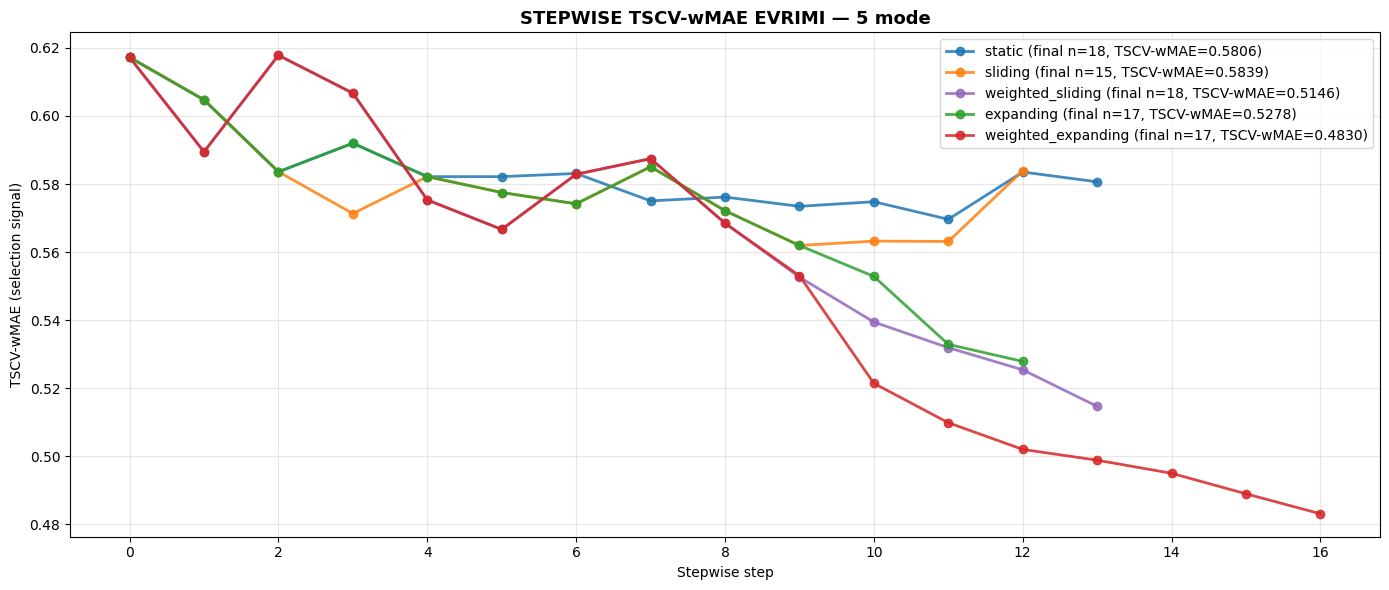


[E2] VAL DETAYLI ANALIZ

[E2.1] DETAYLI VAL TAHMIN TABLOSU
  y_val.mean() = -0.2225  |  y_train.mean() = +0.2165


,Val Hafta,Gercek NET,static,sliding,weighted_sliding,expanding,weighted_expanding,Naive (y_train.mean),err_static,err_sliding,err_weighted_sliding,err_expanding,err_weighted_expanding
0,72,-0.2100,-0.5415,-0.5561,-0.6894,-0.6110,-0.6289,+0.2165,+0.3315,+0.3461,+0.4794,+0.4010,+0.4189
1,73,-0.1600,-0.6863,-0.4147,-0.2909,-0.4642,-0.3291,+0.2165,+0.5263,+0.2547,+0.1309,+0.3042,+0.1691
2,74,-0.4400,-0.4051,-0.2972,-0.2392,-0.3962,-0.4927,+0.2165,-0.0349,-0.1428,-0.2008,-0.0438,+0.0527
3,75,+0.3800,-0.1506,+0.1716,+0.2415,+0.2613,+0.3586,+0.2165,+0.5306,+0.2084,+0.1385,+0.1187,+0.0214
4,76,-1.0900,-0.4675,-0.9591,-0.8325,-0.8987,-0.8645,+0.2165,-0.6225,-0.1309,-0.2575,-0.1913,-0.2255
5,77,-0.2100,-0.5851,-0.9221,-0.7793,-0.8269,-0.8103,+0.2165,+0.3751,+0.7121,+0.5693,+0.6169,+0.6003
6,78,-0.2200,-0.0032,-0.1647,-0.2368,-0.0737,-0.0833,+0.2165,-0.2168,-0.0553,+0.0168,-0.1463,-0.1367
7,79,+0.1700,-0.0739,-0.2702,-0.3314,-0.3810,-0.4439,+0.2165,+0.2439,+0.4402,+0.5014,+0.5510,+0.6139
MAE,-,-,+0.3602,+0.2863,+0.2868,+0.2967,+0.2798,+0.4799,,,,,



[E2.2] R²_VAL BREAKDOWN
  SS_tot = 1.3212
  Mode                  SS_res     R²       Anlam
  --------------------------------------------------------------------------------
  static                   1.3042  +0.0128  naive'den iyi (R²=+0.013)
  sliding                  0.9696  +0.2661  naive'den iyi (R²=+0.266)
  weighted_sliding         0.9485  +0.2820  naive'den iyi (R²=+0.282)
  expanding                1.0116  +0.2343  naive'den iyi (R²=+0.234)
  weighted_expanding       1.0140  +0.2325  naive'den iyi (R²=+0.232)


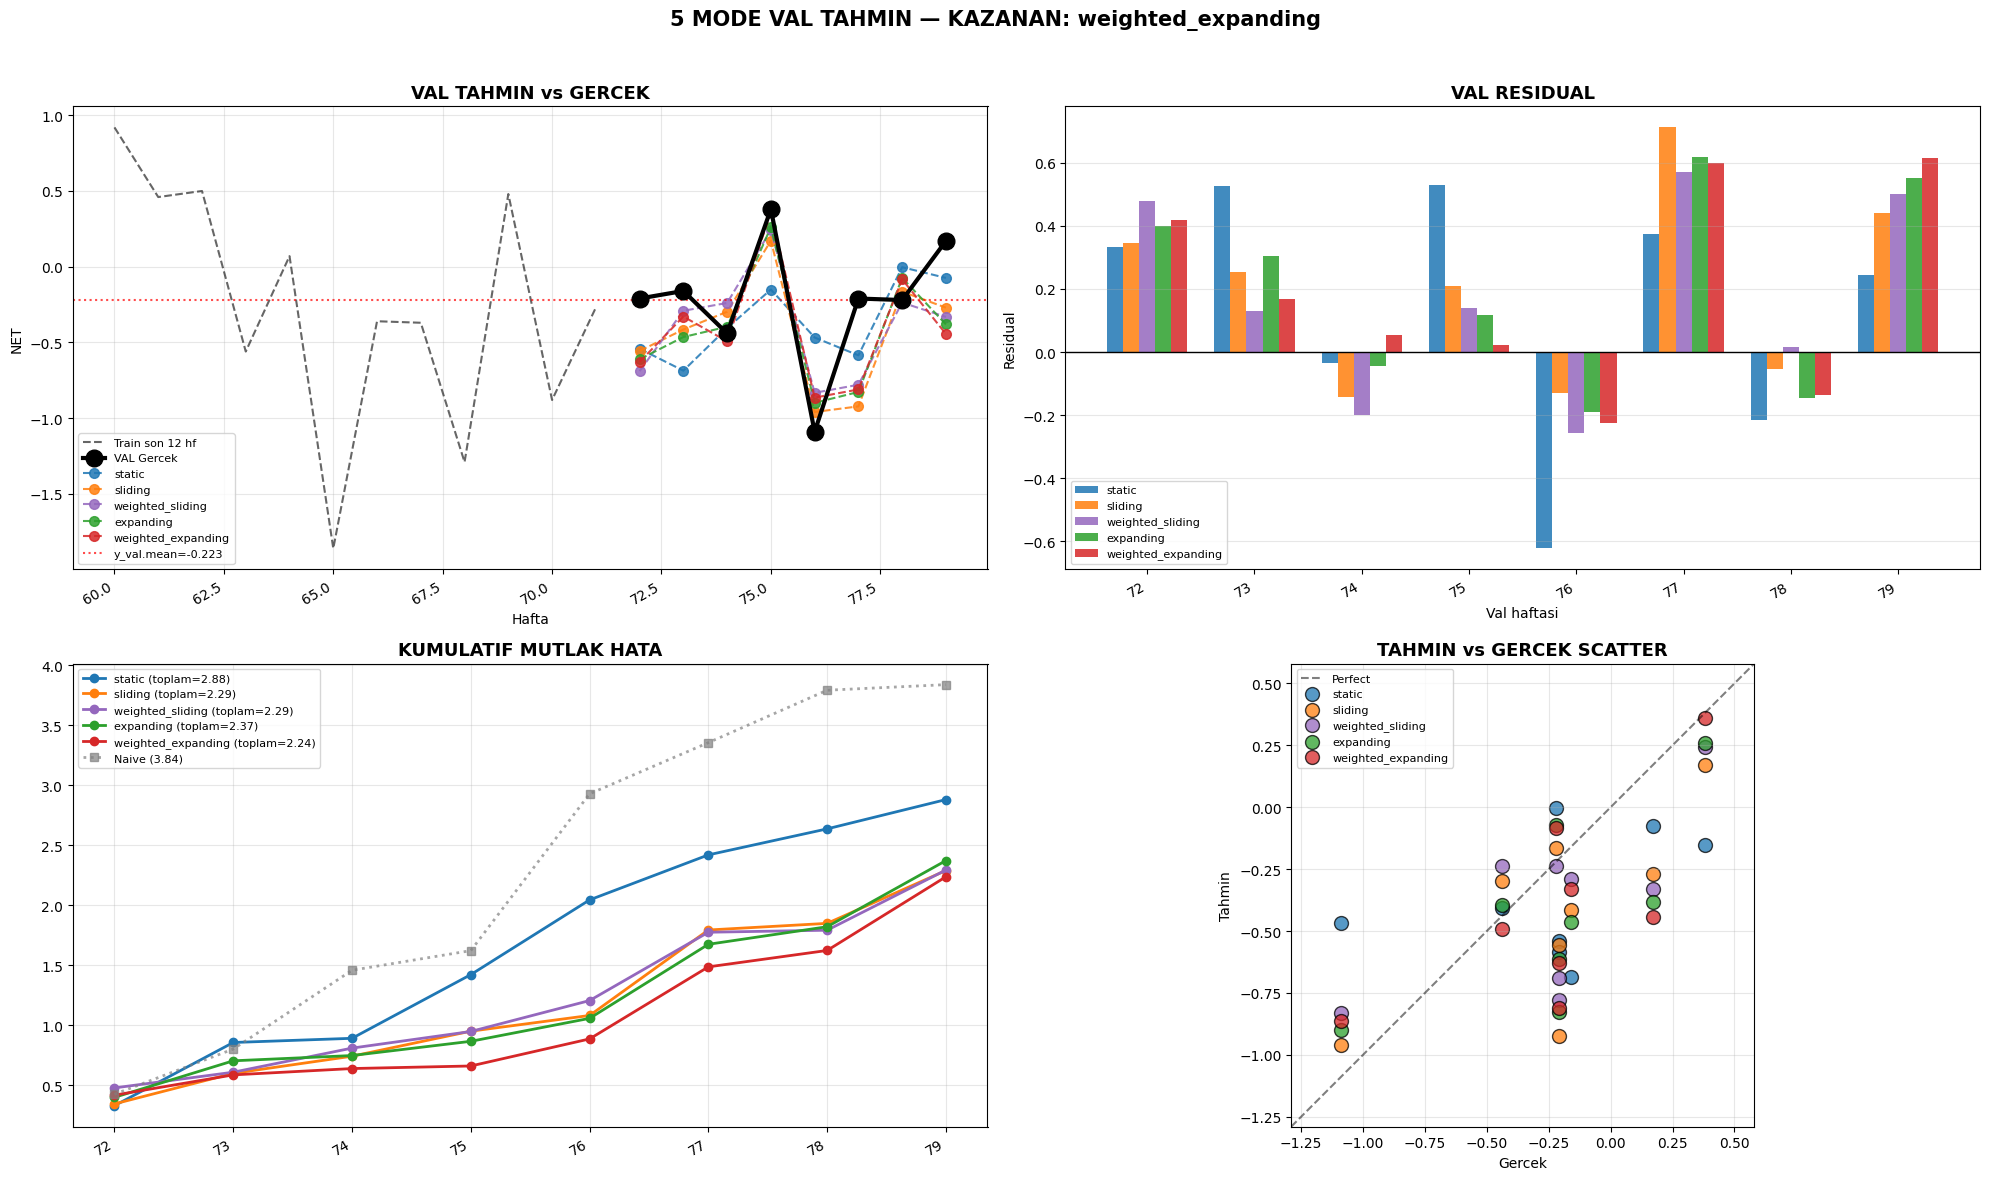


 [F] STEPWISE SECILEN FEATURE'LAR — her mode

[static]  n*=18  R²tr=+0.781  gap=0.074  MAE=0.3602  (14 iter)
  Train: R²=+0.781  AdjR²=+0.707  GAUC=0.544
  Val  : R²=+0.013  AdjR²=+nan  GAUC=0.518
  Aile kapsami:
    anomaly   : ['Market_Anomaly_x_Benchmark_z52']
    tlref     : ['w/TLREF', 'PPK_Haftasi_x_TLREF_delta1']
    welcome   : ['osawelcome_roll4_std', 'osawelcome-benchmark_z52', 'post_okul_tatili_hangover_x_osawelcome-benchmark_z52', 'YearEnd_x_osawelcome-benchmark_z52', 'YearEnd_x_welcome_delta', 'post_okul_tatili_hangover_x_welcome_delta', 'post_quarter_end_hangover_x_osawelcome-benchmark_z52']
  Tum 18 feature:
    Ay_Sonu_Haftasi                           Black_Friday                              
    Cekirdek_Enflasyon_delta1_Onceki_Hafta    Full_Workday                              
    Issizlik_delta1_Onceki_Hafta              Kur_Spike                                 
    Market_Anomaly_x_Benchmark_z52            PPK_Haftasi_x_TLREF_delta1                
    PPK_Sonr

,Coefficient
Feature,
(Intercept),+0.834740
Market_Anomaly_x_Benchmark_z52,-0.443248
osawelcome_roll4_std,-0.135970
w/TLREF,+0.515049
osawelcome-benchmark_z52,+0.092207
post_okul_tatili_hangover_x_osawelcome-benchmark_z52,+0.311256
TCMB_Mevduat_3M_roll4_std_Onceki_Hafta,+0.289838
Black_Friday,+0.603379
Ay_Sonu_Haftasi,-0.306800



 PIPELINE OZET
  Fit base               : X_train (72 hf)
  Selection signal       : TSCV-wMAE (5-fold recency-weighted on X_train)
  Val set (raporlama)    : X_val (8 hf) — secime girmedi
  Held out                : X_test (3 hf)
  Selection hiyerarsisi  : (1) R²val>0  (2) Train R²>=0.8  (3) |R²−AdjR²|<0.05  (4) TSCV-wMAE
  Algoritma              : STEPWISE (3-aile sampiyon -> ADD/REM iter)
  Test edilen mode       : 5 (static / sliding / weighted_sliding / expanding / weighted_expanding)
  Global kazanan         : weighted_expanding
  n*                     : 17 feature
  TSCV-wMAE / wR²        : 0.4830 / +0.2079  ← SECIM SINYALI
  Train R²/AdjR²/Gap     : +0.8370 / +0.7887 / 0.0483
  Val MAE / R² / AdjR²   : 0.2798 / +0.2325 / +nan  ← RAPOR
  Val GAUC               : 0.8054
  Alpha (regularization) : 0.0100

 [H] MODEL SERIALIZATION — Monitoring-ready artifact set
  TXT summary     : models/osa_netflow_20260520.txt    (2.4 KB) ← MONITORING PRIMARY
  JSON metadata   : models/osa_net

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 3 — STEPWISE Feature Selection × 5 Eğitim Modu
# Hiyerarsi: (1) R²val > 0  (2) Train R² >= 0.80  (3) |R²−AdjR²| < 0.05  (4) TSCV-wMAE
# SELECTION SIGNAL: Recency-weighted 5-fold TSCV on X_train (val'a overfitting onlemi)
# ═══════════════════════════════════════════════════════════════════════════
# Veri kullanımı — mevcut split korunur:
#   X_train (72 hf) -> model fit base
#   X_val   (8 hf)  -> tiebreak metrigi (val MAE en dusuk)
#   X_test  (3 hf)  -> DOKUNULMAZ, final hold-out (bu cell'de degerlendirilmez)
#
# Selection Hiyerarsisi (her aday icin ayni siralama uygulanir):
#   1) R²val > 0                    — val'da naive'den iyi mi? (en yuksek oncelik)
#                                     hicbir aday saglamiyorsa hepsi tied, slot2'ye geceriz
#   2) Train R²  >= 0.80           — temel performans esigi
#   3) |R²−AdjR²|  < 0.05          — penalty'ye ragmen R² korunuyor
#                                    (2'yi saglayanlar arasinda gap en kucuk; <0.05 tied)
#   4) TSCV-wMAE en dusuk           — recency-weighted 5-fold TSCV on X_train MAE
#                                     YENI: val MAE yerine TSCV — val'a overfitting onlemi
#                                     fold weights: [0.5, 0.7, 0.85, 1.0, 1.5] (eski → yeni)
#
# Val MAE/R²/AdjR² hala tablolarda RAPORLANIR (gozlem icin) ama secime girmez.
#
# STEPWISE algoritmasi:
#   1. Baslangic: 3 aile sampiyon (NET-corr en yuksek tlref/welcome/anomaly)
#   2. ADD step: havuzdaki her aday'i ekle, hierarsiye gore en iyi olani sec
#   3. REMOVE step: must_keep disindaki her feature'i cikar,
#                  hierarsiye gore bozulmayanlari (<=) sec
#   4. Iter ile devam, hicbir iyilesme olmazsa dur (max_iters guvenli sayisi)
#
# 5 Mode:
#   static             : X_train fit, X_val tek seferde test
#   sliding            : her val hf icin son 72 hf ile yeniden fit
#   weighted_sliding   : sliding + ustel decay (yari-omur 26 hf)
#   expanding          : her val hf icin tum gecmis ile yeniden fit
#   weighted_expanding : expanding + ustel decay
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.linear_model import RidgeCV, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# --- Konfigürasyon ---
RANDOM_SEED    = 42                       # Reproducibility — bootstrap, KFold, vs.
np.random.seed(RANDOM_SEED)               # Global numpy RNG init
ALPHA_GRID     = np.logspace(-2, 4, 50)   # [0.01, 10000] — daha genis Ridge regularization grid
SLIDING_WIN    = 72
MIN_FEATURES   = 5
MAX_FEATURES   = 18                       # n/p = 4.0 hedefi — overfit kontrolu + signal capacity dengesi
MAX_STEPWISE_ITERS = 40
HALF_LIFE_WKS  = 26
DECAY          = 0.5 ** (1.0 / HALF_LIFE_WKS)
PROTECTION_3FAM = {'tlref', 'welcome', 'anomaly'}
R2_THR         = 0.80   # Train R² esigi
GAP_THR        = 0.05   # |R²−AdjR²| esigi (5 puan)
# Recency-weighted 5-fold TSCV on X_train — stepwise SELECTION sinyali
N_TSCV_SPLITS  = 5
RECENCY_WEIGHTS = np.array([0.5, 0.7, 0.85, 1.0, 1.5])  # eski → yeni fold
_TSCV_CACHE    = {}     # frozenset(feats) -> (wmae, wr2, fold_maes, fold_r2s)

print("="*80)
print(" STEP 3 — STEPWISE FEATURE SELECTION × 5 EĞİTİM MODU")
print("="*80)
print(f"  X_train (fit base)      : {len(X_train)} hf")
print(f"  X_val (eval set)        : {len(X_val)} hf  ← tiebreak val MAE")
print(f"  X_test (hold-out)       : {len(X_test)} hf")
print(f"  Sliding window          : {SLIDING_WIN} hf")
print(f"  Min feature             : {MIN_FEATURES}")
print(f"  Max feature             : {MAX_FEATURES}  (n/p hedefi >= {len(X_train)/MAX_FEATURES:.1f})")
print(f"  Max stepwise iters      : {MAX_STEPWISE_ITERS}")
print(f"  Weighted half-life      : {HALF_LIFE_WKS} hf (decay/week={DECAY:.4f})")
# weighted_sliding / weighted_expanding modlari icin per-row exponential decay:
#   weight(t-k) = DECAY^k  — son hafta=1.0, k hafta once=DECAY^k
# Yari-omur 26 hf: k=26 -> weight=0.5, k=52 -> weight=0.25, k=72 -> weight=0.149
_sample_ages = [0, 1, 2, 4, 8, 13, 26, 39, 52, 72]
_sample_weights = [DECAY**k for k in _sample_ages]
_weight_str = "  Decay agirligi ornekleri (weighted_sliding / weighted_expanding):\n"
_weight_str += "    Hafta yasi (k)  |  weight = DECAY^k\n"
_weight_str += "    " + "-"*45 + "\n"
for age, w in zip(_sample_ages, _sample_weights):
    _tag = ""
    if age == 0: _tag = " ← son hafta (en yuksek)"
    elif age == HALF_LIFE_WKS: _tag = " ← yari-omur (0.5)"
    elif age == 2 * HALF_LIFE_WKS: _tag = " ← cift yari-omur (0.25)"
    elif age == SLIDING_WIN: _tag = " ← sliding window'un eskisi"
    _weight_str += f"    {age:>3d} hf once     |   {w:.4f}{_tag}\n"
print(_weight_str.rstrip())
print(f"  Korumalı aileler (3)    : {sorted(PROTECTION_3FAM)}")
print(f"  Selection hiyerarsisi   : (1) R²val>0  (2) Train R² >= {R2_THR}  (3) |R²−AdjR²| < {GAP_THR}  (4) TSCV-wMAE")
print(f"  Selection signal        : Recency-weighted {N_TSCV_SPLITS}-fold TSCV on X_train")
print(f"  Fold weights (eski→yeni): {RECENCY_WEIGHTS[:N_TSCV_SPLITS].tolist()}")
print(f"  Val metrics             : tablolarda raporlanir, secime girmez")
print(f"  Başlangıç havuzu        : {X_train.shape[1]} feature")

_TABLE_STYLES = [
    {'selector': 'th',          'props': [('background-color', '#1a1a1a'), ('color', '#ffffff'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '6px 10px')]},
    {'selector': 'td',          'props': [('background-color', '#2a2a2a'), ('color', '#ffffff'), ('text-align', 'right'), ('padding', '5px 10px')]},
    {'selector': 'thead th',    'props': [('background-color', '#0d47a1'), ('color', '#ffffff'), ('border-bottom', '2px solid #ffffff')]},
    {'selector': 'tbody tr:hover td', 'props': [('background-color', '#3a3a3a')]},
]

def _is_protected_token(f, families):
    nl = f.lower()
    return any(fam in nl for fam in families)

def _safe_gauc(y_arr, pred_arr):
    y_arr = np.asarray(y_arr, dtype=float); pred_arr = np.asarray(pred_arr, dtype=float)
    mask = np.isfinite(y_arr) & np.isfinite(pred_arr)
    y_arr = y_arr[mask]; pred_arr = pred_arr[mask]
    if len(y_arr) < 3: return np.nan
    if len(y_arr) < 10:
        rho, _ = spearmanr(y_arr, pred_arr)
        if np.isnan(rho): return np.nan
        return float((rho + 1.0) / 2.0)
    try:
        df_temp = pd.DataFrame({'pred': pred_arr, 'y': y_arr})
        gauc, _ = get_gauc_metrics(df_temp, 'pred', 'y')
        return float(gauc) if not (gauc is None or np.isnan(gauc)) else np.nan
    except Exception:
        return np.nan

def _adj_r2(r2, n, p):
    if np.isnan(r2) or n <= p + 1: return np.nan
    return 1.0 - (1.0 - r2) * (n - 1) / (n - p - 1)

def _tscv_eval(feats, X_full, y_full, n_splits=N_TSCV_SPLITS):
    """Recency-weighted TSCV on X_train — STEPWISE SELECTION sinyali.
       Her fold: static fit (RidgeCV), test üzerinde MAE/R². Mode-blind hesap (hizli).
       Sonuc: cache'lenir cunku ayni feature subset 5 modda da kullaniliyor."""
    if not feats:
        return float('inf'), float('nan'), [], []
    key = frozenset(feats)
    cached = _TSCV_CACHE.get(key)
    if cached is not None:
        return cached
    tscv = TimeSeriesSplit(n_splits=n_splits)
    w = RECENCY_WEIGHTS[:n_splits].astype(float)
    w = w / w.sum()
    maes, r2s = [], []
    for tr_idx, te_idx in tscv.split(X_full.values):
        Xtr_f = X_full.iloc[tr_idx][feats].values
        ytr_f = y_full.iloc[tr_idx].values
        Xte_f = X_full.iloc[te_idx][feats].values
        yte_f = y_full.iloc[te_idx].values
        m = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_f, ytr_f)
        pred = m.predict(Xte_f)
        maes.append(float(mean_absolute_error(yte_f, pred)))
        if len(yte_f) > 1:
            r2s.append(float(r2_score(yte_f, pred)))
        else:
            r2s.append(float('nan'))
    wmae = float(np.average(maes, weights=w))
    r2_arr = np.array(r2s, dtype=float)
    valid  = ~np.isnan(r2_arr)
    if valid.any():
        w_v = w[valid] / w[valid].sum()
        wr2 = float(np.average(r2_arr[valid], weights=w_v))
    else:
        wr2 = float('nan')
    result = (wmae, wr2, maes, r2s)
    _TSCV_CACHE[key] = result
    return result

def _score_key(s):
    """Hiyerarsi sort key (kucuk = iyi) — 4-tier:
       slot0  val_flag  : R² val > 0  -> 0 ; degilse 1
       slot1  thr_flag  : R² train >= R2_THR -> 0 ; degilse 1
       slot2  metric    : thr_flag=0 ise gap_pen ; thr_flag=1 ise -r2_train (R²'yi yukari it)
       slot3  tscv_mae  : RECENCY-WEIGHTED TSCV MAE (selection signal — val MAE degil!)
       Val MAE/R²/AdjR² tablolarda raporlanir ama secime girmez."""
    r2t      = s.get('r2_train', np.nan)
    r2v      = s.get('r2_val', np.nan)
    adjt     = s.get('adj_r2_train', np.nan)
    tscv_mae = s.get('tscv_wmae', np.inf)
    sel_mae  = float(tscv_mae) if np.isfinite(tscv_mae) else float('inf')
    if np.isnan(r2t):
        return (3, 1, 0.0, sel_mae)
    val_flag = 0 if (not np.isnan(r2v) and r2v > 0) else 1
    if r2t >= R2_THR:
        if np.isnan(adjt):
            gap_pen = float('inf')
        else:
            gap = abs(r2t - adjt)
            gap_pen = 0.0 if gap < GAP_THR else float(gap)
        return (val_flag, 0, gap_pen, sel_mae)
    return (val_flag, 1, -float(r2t), sel_mae)

def _eval_static(feats, X_tr, y_tr, X_va, y_va):
    if not feats: return {}
    m = RidgeCV(alphas=ALPHA_GRID).fit(X_tr[feats].values, y_tr.values)
    pred_tr = m.predict(X_tr[feats].values)
    pred_va = m.predict(X_va[feats].values)
    p = len(feats)
    r2_tr = float(r2_score(y_tr.values, pred_tr))
    r2_va = float(r2_score(y_va.values, pred_va)) if len(y_va) > 1 else np.nan
    tscv_wmae, tscv_wr2, _, _ = _tscv_eval(feats, X_tr, y_tr)
    return {
        'r2_train': r2_tr, 'adj_r2_train': _adj_r2(r2_tr, len(y_tr), p),
        'r2_val':   r2_va, 'adj_r2_val':   _adj_r2(r2_va, len(y_va), p),
        'gauc_train': _safe_gauc(y_tr.values, pred_tr),
        'gauc_val':   _safe_gauc(y_va.values, pred_va),
        'mae':        float(mean_absolute_error(y_va.values, pred_va)),
        'tscv_wmae':  tscv_wmae,
        'tscv_wr2':   tscv_wr2,
    }

def _eval_walkforward_generic(feats, X_tr, y_tr, X_va, y_va, mode):
    """sliding / weighted_sliding / expanding / weighted_expanding."""
    if not feats: return {}
    X_combo = pd.concat([X_tr, X_va], axis=0).reset_index(drop=True)
    y_combo = pd.concat([y_tr, y_va], axis=0).reset_index(drop=True)
    n_t = len(X_tr); n_v = len(X_va); p = len(feats)
    train_r2_list, train_adj_list, train_gauc_list = [], [], []
    preds, actuals = [], []
    for t in range(n_t, n_t + n_v):
        if mode in ('sliding', 'weighted_sliding'):
            sl = slice(max(0, t - SLIDING_WIN), t)
        else:  # expanding / weighted_expanding
            sl = slice(0, t)
        Xtr_t = X_combo.iloc[sl][feats].values
        ytr_t = y_combo.iloc[sl].values
        use_weights = mode in ('weighted_sliding', 'weighted_expanding')
        if use_weights:
            w = DECAY ** np.arange(len(ytr_t) - 1, -1, -1)
            m = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_t, ytr_t, sample_weight=w)
        else:
            w = None
            m = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_t, ytr_t)
        pred_tr = m.predict(Xtr_t)
        if len(ytr_t) > 1:
            r2_tr_t = float(r2_score(ytr_t, pred_tr, sample_weight=w) if use_weights else r2_score(ytr_t, pred_tr))
            train_r2_list.append(r2_tr_t)
            train_adj_list.append(_adj_r2(r2_tr_t, len(ytr_t), p))
            train_gauc_list.append(_safe_gauc(ytr_t, pred_tr))
        preds.append(m.predict(X_combo.iloc[t:t+1][feats].values)[0])
        actuals.append(y_combo.iloc[t])
    if not preds: return {}
    preds, actuals = np.array(preds), np.array(actuals)
    r2_va = float(r2_score(actuals, preds)) if len(actuals) > 1 else np.nan
    tscv_wmae, tscv_wr2, _, _ = _tscv_eval(feats, X_tr, y_tr)
    return {
        'r2_train':     float(np.mean(train_r2_list)) if train_r2_list else np.nan,
        'adj_r2_train': float(np.nanmean(train_adj_list)) if train_adj_list else np.nan,
        'r2_val':       r2_va,
        'adj_r2_val':   _adj_r2(r2_va, len(y_va), p),
        'gauc_train':   float(np.nanmean(train_gauc_list)) if train_gauc_list else np.nan,
        'gauc_val':     _safe_gauc(actuals, preds),
        'mae':          float(mean_absolute_error(actuals, preds)),
        'tscv_wmae':    tscv_wmae,
        'tscv_wr2':     tscv_wr2,
    }

EVAL_FNS = {
    'static':             lambda f, Xt, yt, Xv, yv: _eval_static(f, Xt, yt, Xv, yv),
    'sliding':            lambda f, Xt, yt, Xv, yv: _eval_walkforward_generic(f, Xt, yt, Xv, yv, 'sliding'),
    'weighted_sliding':   lambda f, Xt, yt, Xv, yv: _eval_walkforward_generic(f, Xt, yt, Xv, yv, 'weighted_sliding'),
    'expanding':          lambda f, Xt, yt, Xv, yv: _eval_walkforward_generic(f, Xt, yt, Xv, yv, 'expanding'),
    'weighted_expanding': lambda f, Xt, yt, Xv, yv: _eval_walkforward_generic(f, Xt, yt, Xv, yv, 'weighted_expanding'),
}

def _stepwise_select(X_tr, y_tr, X_va, y_va, mode, families, label, max_iters=MAX_STEPWISE_ITERS):
    """STEPWISE FEATURE SELECTION (hiyerarsik secim):
       Baslangic: 3-aile sampiyon (NET-corr en yuksek).
       Her iter: ADD (hiyerarsi iyilesirse ekle), sonra REMOVE (hiyerarsi bozulmazsa cikar).
       Hierarsi: (1) R²val>0 (2) R²tr>=0.80 (3) gap<0.05 (4) TSCV-wMAE
       Selection signal: TSCV-wMAE (val MAE degil, val rapor icin)."""
    eval_fn = EVAL_FNS[mode]
    target_corr = X_tr.corrwith(y_tr, method='spearman').abs()
    must_keep = set()
    for fam in families:
        members = [c for c in X_tr.columns if fam in c.lower()]
        if members:
            champ = max(members, key=lambda c: target_corr.get(c, 0))
            must_keep.add(champ)
    current = sorted(must_keep)
    pool = [c for c in X_tr.columns if c not in must_keep]
    if len(current) < MIN_FEATURES:
        sorted_pool = sorted(pool, key=lambda c: target_corr.get(c, 0), reverse=True)
        need = MIN_FEATURES - len(current)
        for c in sorted_pool[:need]:
            current.append(c); pool.remove(c)

    stats = eval_fn(current, X_tr, y_tr, X_va, y_va)
    if not stats:
        return current, {}, []
    best_score = _score_key(stats)
    step = 0
    init_action = f"init (n={len(current)}): " + ", ".join(current)
    history = [{'step': step, 'iter': 0, 'action': init_action,
                'n': len(current), **stats}]

    print(f"  -> {label} (stepwise, start n={len(current)})")

    for it in range(1, max_iters + 1):
        improved = False
        # ADD step — sadece MAX_FEATURES altinda iken (overfit kontrolu)
        if len(current) < MAX_FEATURES:
            best_add = None; best_add_stats = None; best_add_score = best_score
            for cand in pool:
                trial = current + [cand]
                ts = eval_fn(trial, X_tr, y_tr, X_va, y_va)
                if not ts: continue
                sk = _score_key(ts)
                if sk < best_add_score:
                    best_add_score = sk; best_add = cand; best_add_stats = ts
            if best_add:
                current = current + [best_add]; pool.remove(best_add)
                best_score = best_add_score
                step += 1
                history.append({'step': step, 'iter': it, 'action': f'ADD {best_add}', 'n': len(current), **best_add_stats})
                improved = True
        # REMOVE step — must_keep disinda, hiyerarsiyi bozmayan (<=) cikarmayi dene
        if len(current) > MIN_FEATURES:
            best_rem = None; best_rem_stats = None; best_rem_score = best_score
            for cand in [c for c in current if c not in must_keep]:
                trial = [c for c in current if c != cand]
                if len(trial) < MIN_FEATURES: continue
                ts = eval_fn(trial, X_tr, y_tr, X_va, y_va)
                if not ts: continue
                sk = _score_key(ts)
                if sk <= best_rem_score:
                    best_rem_score = sk; best_rem = cand; best_rem_stats = ts
            if best_rem:
                current = [c for c in current if c != best_rem]; pool.append(best_rem)
                best_score = best_rem_score
                step += 1
                history.append({'step': step, 'iter': it, 'action': f'REM {best_rem}', 'n': len(current), **best_rem_stats})
                improved = True
        if not improved:
            break
    final_stats = eval_fn(current, X_tr, y_tr, X_va, y_va)
    return current, final_stats, history

# ═══════════════════════════════════════════════════════════════════════════
# [A] SIGN STABILITY PRE-FILTER (5-fold TSCV on X_train)
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n[A] SIGN-STABILITY PRE-FILTER (4-fold TSCV on X_train {len(X_train)} hf, fold 1 skipped: n_train=12 cok kucuk)")
_tscv5 = TimeSeriesSplit(n_splits=5)
_signs_map = {f: [] for f in X_train.columns}
for _fold_i, (tr, te) in enumerate(_tscv5.split(X_train.values)):
    if _fold_i == 0:  # Fold 1: ~12 train obs, 76+ feature → istatistik anlamsiz, skip
        continue
    m = RidgeCV(alphas=ALPHA_GRID).fit(X_train.iloc[tr].values, y_train.iloc[tr].values)
    for f, c in zip(X_train.columns, m.coef_):
        _signs_map[f].append(int(np.sign(c)) if abs(c) > 1e-6 else 0)
_unstable_unprot = []
for f, signs in _signs_map.items():
    # 4 fold uzerinden: max(pos, neg) < 3 → instabil  (>=3 fold tutarli)
    n_pos = sum(1 for s in signs if s > 0); n_neg = sum(1 for s in signs if s < 0)
    if max(n_pos, n_neg) < 3 and not _is_protected_token(f, PROTECTION_3FAM):
        _unstable_unprot.append(f)
X_train = X_train.drop(columns=_unstable_unprot)
X_val   = X_val.drop(columns=_unstable_unprot)
X_test  = X_test.drop(columns=_unstable_unprot)
if len(X_predict) > 0:
    X_predict = X_predict.drop(columns=_unstable_unprot, errors='ignore')
print(f"    Sonuc: {len(_unstable_unprot)} unstable feature elendi → havuz {X_train.shape[1]} feature")

# Defensive check: havuz MAX_FEATURES'tan kucukse cap etkisiz, MIN_FEATURES + 3-aile yetmiyorsa start fail
assert X_train.shape[1] >= MIN_FEATURES, \
    f"Feature havuzu cok kucuk: {X_train.shape[1]} < MIN_FEATURES={MIN_FEATURES} — Step 3 calismaz"
if X_train.shape[1] < MAX_FEATURES:
    print(f"    UYARI: Havuz ({X_train.shape[1]}) < MAX_FEATURES ({MAX_FEATURES}) — cap etkisiz, stepwise tum havuzu kullanabilir")

# ═══════════════════════════════════════════════════════════════════════════
# [B] 5 MODE × STEPWISE
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n[B] 5 MODE × STEPWISE FEATURE SELECTION")
print(f"    Selection signal: TSCV-wMAE ({N_TSCV_SPLITS}-fold recency-weighted on X_train)")
print(f"    Hiyerarsi: R²val>0 → R²tr>={R2_THR} → |R²−AdjR²|<{GAP_THR} → TSCV-wMAE")

mode_list = ['static', 'sliding', 'weighted_sliding', 'expanding', 'weighted_expanding']
results = {}
for mode in mode_list:
    feats, fstats, hist = _stepwise_select(X_train, y_train, X_val, y_val, mode, PROTECTION_3FAM, mode)
    results[mode] = dict(best_feats=feats, best_stats=fstats, history=hist,
                         mode=mode, families=PROTECTION_3FAM)
    if fstats:
        gap = abs(fstats['r2_train'] - fstats['adj_r2_train']) if not (np.isnan(fstats['r2_train']) or np.isnan(fstats['adj_r2_train'])) else float('nan')
        _vpos = '✓' if (not np.isnan(fstats['r2_val']) and fstats['r2_val'] > 0) else '✗'
        _tscvm = fstats.get('tscv_wmae', float('nan'))
        _tscvr = fstats.get('tscv_wr2', float('nan'))
        print(f"     n*={len(feats)}  TSCV-wMAE={_tscvm:.4f} TSCV-wR²={_tscvr:+.3f}  |  "
              f"R²va>0:{_vpos} R²tr={fstats['r2_train']:+.3f} gap={gap:.3f}  "
              f"VAL: MAE={fstats['mae']:.4f} R²={fstats['r2_val']:+.3f} AdjR²={fstats['adj_r2_val']:+.3f}  "
              f"({len(hist)} stepwise iter)")
    else:
        print(f"     FAIL — yetersiz feature")

# ═══════════════════════════════════════════════════════════════════════════
# [C] KARSILASTIRMA — hiyerarsik sira
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*120)
print(" [C] 5 MODE KARSILASTIRMASI — Hiyerarsi: (1) R²val>0 (2) R²tr>=0.80 (3) |R²−AdjR²|<0.05 (4) TSCV-wMAE")
print("    (TSCV-wMAE recency-weighted 5-fold on X_train = selection signal; Val metrics = reference)")
print("="*120)
cmp_rows = []
for label, r in results.items():
    s = r['best_stats']
    if not s: continue
    r2t = s['r2_train']; adjt = s['adj_r2_train']; r2v = s['r2_val']
    gap_tr = abs(r2t - adjt) if not (np.isnan(r2t) or np.isnan(adjt)) else np.nan
    r2_ok = (not np.isnan(r2t)) and r2t >= R2_THR
    gap_ok = (not np.isnan(gap_tr)) and gap_tr < GAP_THR
    rv_ok = (not np.isnan(r2v)) and r2v > 0
    cmp_rows.append({'Model': label, 'n*': len(r['best_feats']),
                     'R²val>0': '✓' if rv_ok else '✗',
                     'R²tr>=0.80': '✓' if r2_ok else '✗',
                     'gap<0.05': '✓' if gap_ok else '✗',
                     'TSCV wMAE': s.get('tscv_wmae', np.nan),
                     'TSCV wR²': s.get('tscv_wr2', np.nan),
                     'MAE Val': s['mae'],
                     'R² Train': r2t, 'R² Val': r2v,
                     'Adj R² Train': adjt, 'Adj R² Val': s['adj_r2_val'],
                     'Gap Train': gap_tr,
                     'GAUC Train': s['gauc_train'], 'GAUC Val': s['gauc_val'],
                     'Stepwise iters': len(r['history']),
                     '_score': _score_key(s)})
cmp_tbl_full = pd.DataFrame(cmp_rows)
# Hiyerarsik sirala — _score tuple kucuk = iyi
cmp_tbl_full = cmp_tbl_full.sort_values('_score', kind='stable').reset_index(drop=True)
best_label = cmp_tbl_full.iloc[0]['Model']
cmp_tbl = cmp_tbl_full.set_index('Model').drop(columns=['_score'])
# emniyet: index ve column'lar unique olmali (Styler.apply gereksinimi)
cmp_tbl = cmp_tbl[~cmp_tbl.index.duplicated(keep='first')]
cmp_tbl = cmp_tbl.loc[:, ~cmp_tbl.columns.duplicated(keep='first')]
def _hl_winner(row, winner=best_label):
    return ['background-color: #2e7d32; color: #ffffff; font-weight: bold' if row.name == winner else '' for _ in row]
display(cmp_tbl.style.apply(_hl_winner, axis=1).set_table_styles(_TABLE_STYLES)
        .format({'TSCV wMAE':'{:.4f}','TSCV wR²':'{:+.3f}',
                 'MAE Val':'{:.4f}','R² Train':'{:+.3f}','R² Val':'{:+.3f}',
                 'Adj R² Train':'{:+.3f}','Adj R² Val':'{:+.3f}','Gap Train':'{:.3f}',
                 'GAUC Train':'{:.3f}','GAUC Val':'{:.3f}',
                 'n*':'{:.0f}','Stepwise iters':'{:.0f}'}, na_rep='—'))

best = results[best_label]
_bs = best['best_stats']
_bgap = abs(_bs['r2_train'] - _bs['adj_r2_train'])
_bvok = (not np.isnan(_bs['r2_val'])) and _bs['r2_val'] > 0
print(f"\n[GLOBAL KAZANAN] {best_label}  |  TSCV-wMAE={_bs.get('tscv_wmae', np.nan):.4f} (SECIM SINYALI)  |  "
      f"TSCV-wR²={_bs.get('tscv_wr2', np.nan):+.3f}")
print(f"    Pre-filter:  R²va>0? {'✓' if _bvok else '✗'} ({_bs['r2_val']:+.3f})  |  "
      f"R²tr={_bs['r2_train']:+.3f} (>=0.80? {'✓' if _bs['r2_train']>=R2_THR else '✗'})  |  "
      f"gap={_bgap:.3f} (<0.05? {'✓' if _bgap<GAP_THR else '✗'})")
print(f"    Val rapor:   MAE={_bs['mae']:.4f}  R²val={_bs['r2_val']:+.3f}  AdjR²val={_bs['adj_r2_val']:+.3f}  |  n*={len(best['best_feats'])}")

# ═══════════════════════════════════════════════════════════════════════════
# [D] STEPWISE TRAJEKTORI — her mode icin iter-by-iter action log
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*120)
print(" [D] STEPWISE TRAJEKTORI — her mode icin ADD/REM aksiyonu + metrikler")
print("="*120)
for label, r in results.items():
    print(f"\n[{label}] — {len(r['history'])} iter")
    hdf = pd.DataFrame(r['history'])
    if hdf.empty: continue
    cols = ['step', 'iter', 'action', 'n', 'tscv_wmae', 'tscv_wr2', 'mae', 'r2_train', 'adj_r2_train', 'r2_val', 'adj_r2_val', 'gauc_train', 'gauc_val']
    cols = [c for c in cols if c in hdf.columns]
    hdf = hdf[cols].set_index('step')
    _last_step = hdf.index.max()
    def _hl_lastrow(row, last_step=_last_step):
        return ['background-color: #f9a825; color: #000000; font-weight: bold' if row.name == last_step else '' for _ in row]
    display(hdf.style.apply(_hl_lastrow, axis=1).set_table_styles(_TABLE_STYLES)
            .format({'iter':'{:.0f}','n':'{:.0f}',
                     'tscv_wmae':'{:.4f}','tscv_wr2':'{:+.3f}',
                     'mae':'{:.4f}',
                     'r2_train':'{:+.3f}','adj_r2_train':'{:+.3f}',
                     'r2_val':'{:+.3f}','adj_r2_val':'{:+.3f}',
                     'gauc_train':'{:.3f}','gauc_val':'{:.3f}'}, na_rep='—'))

# ═══════════════════════════════════════════════════════════════════════════
# [E] GORSELLESTIRME — stepwise MAE evolution + val tahmin detayi
# ═══════════════════════════════════════════════════════════════════════════
print("\n[E] STEPWISE MAE evrimi (her mode)")
fig, ax = plt.subplots(figsize=(14, 6))
_mode_colors = {'static': '#1f77b4', 'sliding': '#ff7f0e', 'weighted_sliding': '#9467bd',
                'expanding': '#2ca02c', 'weighted_expanding': '#d62728'}
for label, r in results.items():
    hdf = pd.DataFrame(r['history'])
    if hdf.empty: continue
    yseries = 'tscv_wmae' if 'tscv_wmae' in hdf.columns else 'mae'
    if yseries not in hdf.columns: continue
    xaxis = hdf['step'] if 'step' in hdf.columns else hdf['iter']
    _fstats = r['best_stats']
    _final = _fstats.get('tscv_wmae', _fstats.get('mae', float('nan')))
    ax.plot(xaxis, hdf[yseries], 'o-', color=_mode_colors[label],
            label=f"{label} (final n={len(r['best_feats'])}, TSCV-wMAE={_final:.4f})",
            linewidth=2, markersize=6, alpha=0.85)
ax.set_xlabel('Stepwise step'); ax.set_ylabel('TSCV-wMAE (selection signal)')
ax.set_title('STEPWISE TSCV-wMAE EVRIMI — 5 mode', fontweight='bold', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# [E2] VAL DETAYLI ANALIZ (5 mode predictions, naive baseline, R² breakdown)
# ═══════════════════════════════════════════════════════════════════════════
print("\n[E2] VAL DETAYLI ANALIZ")

def _wf_val_predictions(feats, mode):
    if mode == 'static':
        m = RidgeCV(alphas=ALPHA_GRID).fit(X_train[feats].values, y_train.values)
        return m.predict(X_val[feats].values)
    X_combo = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_combo = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
    n_t = len(X_train); n_v = len(X_val)
    preds = []
    for t in range(n_t, n_t + n_v):
        if mode in ('sliding', 'weighted_sliding'):
            sl = slice(max(0, t - SLIDING_WIN), t)
        else:
            sl = slice(0, t)
        Xtr_t = X_combo.iloc[sl][feats].values
        ytr_t = y_combo.iloc[sl].values
        if mode in ('weighted_sliding', 'weighted_expanding'):
            w = DECAY ** np.arange(len(ytr_t) - 1, -1, -1)
            m = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_t, ytr_t, sample_weight=w)
        else:
            m = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_t, ytr_t)
        preds.append(m.predict(X_combo.iloc[t:t+1][feats].values)[0])
    return np.array(preds)

_val_preds = {}
for mode_name in mode_list:
    feats = results[mode_name]['best_feats']
    _val_preds[mode_name] = _wf_val_predictions(feats, mode_name)

_naive_pred = np.full(len(y_val), float(y_train.mean()))
_val_mean = float(y_val.mean())
_val_xs = list(y_val.index) if hasattr(y_val, 'index') else list(range(len(y_val)))
_val_labels = [str(x)[:10] for x in _val_xs]

print(f"\n[E2.1] DETAYLI VAL TAHMIN TABLOSU")
print(f"  y_val.mean() = {_val_mean:+.4f}  |  y_train.mean() = {float(y_train.mean()):+.4f}")
detail_cols = {'Val Hafta': _val_labels, 'Gercek NET': y_val.values}
for m in mode_list:
    detail_cols[m] = _val_preds[m]
detail_cols['Naive (y_train.mean)'] = _naive_pred
detail = pd.DataFrame(detail_cols)
for m in mode_list:
    detail[f'err_{m}'] = y_val.values - _val_preds[m]
detail.loc['MAE'] = ['-', '-'] + [float(np.mean(np.abs(y_val.values - _val_preds[m]))) for m in mode_list] + [float(np.mean(np.abs(y_val.values - _naive_pred)))] + ['' for _ in mode_list]
def _safe_num_fmt(spec):
    def _f(v):
        if isinstance(v, str) or v is None: return v if v is not None else ''
        try:
            if pd.isna(v): return '—'
        except Exception:
            pass
        try:
            return format(float(v), spec)
        except (TypeError, ValueError):
            return str(v)
    return _f
_fnum = _safe_num_fmt('+.4f')
fmt = {'Gercek NET': _fnum, 'Naive (y_train.mean)': _fnum}
for m in mode_list:
    fmt[m] = _fnum; fmt[f'err_{m}'] = _fnum
display(detail.style.set_table_styles(_TABLE_STYLES).format(fmt, na_rep='—'))

print(f"\n[E2.2] R²_VAL BREAKDOWN")
ss_tot_val = float(np.sum((y_val.values - _val_mean) ** 2))
print(f"  SS_tot = {ss_tot_val:.4f}")
print(f"  Mode                  SS_res     R²       Anlam")
print(f"  " + "-"*80)
for mode_name in mode_list:
    ss_res = float(np.sum((y_val.values - _val_preds[mode_name]) ** 2))
    r2 = 1 - ss_res / ss_tot_val if ss_tot_val > 0 else np.nan
    interp = f"naive'den iyi (R²={r2:+.3f})" if r2 > 0 else f"naive'den {abs(ss_res/ss_tot_val):.2f}x kotu"
    print(f"  {mode_name:22s} {ss_res:>8.4f}  {r2:>+7.4f}  {interp}")

# Goresel — 4 panel
fig2, axes2 = plt.subplots(2, 2, figsize=(20, 12))
ax = axes2[0, 0]
ctx_n = 12
ctx_xs = list(y_train.index[-ctx_n:]) if hasattr(y_train, 'index') else list(range(len(y_train)-ctx_n, len(y_train)))
ax.plot(ctx_xs, y_train.values[-ctx_n:], 'k--', linewidth=1.5, alpha=0.6, label=f'Train son {ctx_n} hf')
ax.plot(_val_xs, y_val.values, 'k-o', linewidth=3, markersize=12, label='VAL Gercek', zorder=10)
for mode_name in mode_list:
    ax.plot(_val_xs, _val_preds[mode_name], '--o', color=_mode_colors[mode_name],
            label=mode_name, linewidth=1.5, markersize=7, alpha=0.85)
ax.axhline(_val_mean, color='red', linestyle=':', alpha=0.7, label=f'y_val.mean={_val_mean:+.3f}')
ax.set_title('VAL TAHMIN vs GERCEK', fontweight='bold', fontsize=13)
ax.set_xlabel('Hafta'); ax.set_ylabel('NET')
ax.legend(loc='best', fontsize=8); ax.grid(alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax = axes2[0, 1]
x_idx = np.arange(len(_val_xs))
width = 0.15
for i, mode_name in enumerate(mode_list):
    err = y_val.values - _val_preds[mode_name]
    offset = (i - 2) * width
    ax.bar(x_idx + offset, err, width, color=_mode_colors[mode_name], label=mode_name, alpha=0.85)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x_idx); ax.set_xticklabels(_val_labels, rotation=30, ha='right')
ax.set_title('VAL RESIDUAL', fontweight='bold', fontsize=13)
ax.set_xlabel('Val haftasi'); ax.set_ylabel('Residual')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

ax = axes2[1, 0]
for mode_name in mode_list:
    cum = np.cumsum(np.abs(y_val.values - _val_preds[mode_name]))
    ax.plot(_val_xs, cum, '-o', color=_mode_colors[mode_name],
            label=f"{mode_name} (toplam={cum[-1]:.2f})", linewidth=2, markersize=6)
naive_cum = np.cumsum(np.abs(y_val.values - _naive_pred))
ax.plot(_val_xs, naive_cum, ':s', color='gray', label=f'Naive ({naive_cum[-1]:.2f})', linewidth=2, alpha=0.7)
ax.set_title('KUMULATIF MUTLAK HATA', fontweight='bold', fontsize=13)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax = axes2[1, 1]
all_min = min(y_val.values.min(), min(p.min() for p in _val_preds.values())) - 0.2
all_max = max(y_val.values.max(), max(p.max() for p in _val_preds.values())) + 0.2
ax.plot([all_min, all_max], [all_min, all_max], 'k--', alpha=0.5, label='Perfect')
for mode_name in mode_list:
    ax.scatter(y_val.values, _val_preds[mode_name], s=100, color=_mode_colors[mode_name],
               label=mode_name, alpha=0.75, edgecolors='black')
ax.set_xlim(all_min, all_max); ax.set_ylim(all_min, all_max)
ax.set_title('TAHMIN vs GERCEK SCATTER', fontweight='bold', fontsize=13)
ax.set_xlabel('Gercek'); ax.set_ylabel('Tahmin')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_aspect('equal')
fig2.suptitle(f'5 MODE VAL TAHMIN — KAZANAN: {best_label}', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# [F] HER MODE ICIN SECILEN FEATURE LISTESI
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*120)
print(" [F] STEPWISE SECILEN FEATURE'LAR — her mode")
print("="*120)
def _print_feats(items, ncols=2, width=42, indent="    "):
    for i in range(0, len(items), ncols):
        row = items[i:i+ncols]
        print(indent + "".join(f"{c:<{width}}" for c in row))

for label, r in results.items():
    s = r['best_stats']
    if not s: continue
    gap_tr = abs(s['r2_train'] - s['adj_r2_train'])
    print(f"\n[{label}]  n*={len(r['best_feats'])}  R²tr={s['r2_train']:+.3f}  gap={gap_tr:.3f}  MAE={s['mae']:.4f}  ({len(r['history'])} iter)")
    print(f"  Train: R²={s['r2_train']:+.3f}  AdjR²={s['adj_r2_train']:+.3f}  GAUC={s['gauc_train']:.3f}")
    print(f"  Val  : R²={s['r2_val']:+.3f}  AdjR²={s['adj_r2_val']:+.3f}  GAUC={s['gauc_val']:.3f}")
    print(f"  Aile kapsami:")
    for fam in sorted(PROTECTION_3FAM):
        feats_in_fam = [f for f in r['best_feats'] if fam in f.lower()]
        print(f"    {fam:<10s}: {feats_in_fam}")
    print(f"  Tum {len(r['best_feats'])} feature:")
    _print_feats(sorted(r['best_feats']))

# ═══════════════════════════════════════════════════════════════════════════
# [G] FINAL FIT
# ═══════════════════════════════════════════════════════════════════════════
optimal_features = best['best_feats']
final_ridge = RidgeCV(alphas=ALPHA_GRID).fit(X_train[optimal_features].values, y_train.values)
best_alpha = float(final_ridge.alpha_)

print("\n" + "="*120)
print(f" [G] GLOBAL FINAL — {best_label} | n={len(optimal_features)} | α={best_alpha:.4f} | MAE_val={best['best_stats']['mae']:.4f}")
print("="*120)
coef_tbl = pd.DataFrame({
    'Feature': ['(Intercept)'] + optimal_features,
    'Coefficient': [final_ridge.intercept_] + list(final_ridge.coef_),
}).set_index('Feature')
print("\n--- COEFFICIENTS (X_train fit) ---")
display(coef_tbl.style.set_table_styles(_TABLE_STYLES).format({'Coefficient':'{:+.6f}'}))

print("\n" + "="*120)
print(" PIPELINE OZET")
print("="*120)
_s = best['best_stats']
_gap_final = abs(_s['r2_train'] - _s['adj_r2_train'])
print(f"  Fit base               : X_train ({len(X_train)} hf)")
print(f"  Selection signal       : TSCV-wMAE ({N_TSCV_SPLITS}-fold recency-weighted on X_train)")
print(f"  Val set (raporlama)    : X_val ({len(X_val)} hf) — secime girmedi")
print(f"  Held out                : X_test ({len(X_test)} hf)")
print(f"  Selection hiyerarsisi  : (1) R²val>0  (2) Train R²>={R2_THR}  (3) |R²−AdjR²|<{GAP_THR}  (4) TSCV-wMAE")
print(f"  Algoritma              : STEPWISE (3-aile sampiyon -> ADD/REM iter)")
print(f"  Test edilen mode       : 5 (static / sliding / weighted_sliding / expanding / weighted_expanding)")
print(f"  Global kazanan         : {best_label}")
print(f"  n*                     : {len(optimal_features)} feature")
print(f"  TSCV-wMAE / wR²        : {_s.get('tscv_wmae', np.nan):.4f} / {_s.get('tscv_wr2', np.nan):+.4f}  ← SECIM SINYALI")
print(f"  Train R²/AdjR²/Gap     : {_s['r2_train']:+.4f} / {_s['adj_r2_train']:+.4f} / {_gap_final:.4f}")
print(f"  Val MAE / R² / AdjR²   : {_s['mae']:.4f} / {_s['r2_val']:+.4f} / {_s['adj_r2_val']:+.4f}  ← RAPOR")
print(f"  Val GAUC               : {_s['gauc_val']:.4f}")
print(f"  Alpha (regularization) : {best_alpha:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
# [H] MODEL SERIALIZATION — Haftalik artifact (Pazartesi run'i)
# ═══════════════════════════════════════════════════════════════════════════
import joblib
import json
from datetime import datetime
from pathlib import Path

_run_ts = datetime.now()
_artifact = {
    'model': final_ridge,
    'mode': best_label,
    'optimal_features': optimal_features,
    'alpha': best_alpha,
    'best_stats': dict(best['best_stats']),
    'X_train_columns': list(X_train.columns),
    'protection_3fam': sorted(PROTECTION_3FAM),
    'n_train': int(len(X_train)),
    'n_val':   int(len(X_val)),
    'n_test':  int(len(X_test)),
    'sliding_win': SLIDING_WIN,
    'half_life_wks': HALF_LIFE_WKS,
    'decay_per_week': float(DECAY),
    'random_seed': RANDOM_SEED,
    'r2_thr': R2_THR,
    'gap_thr': GAP_THR,
    'max_features': MAX_FEATURES,
    'min_features': MIN_FEATURES,
    'recency_weights': RECENCY_WEIGHTS.tolist(),
    'timestamp': _run_ts.isoformat(),
    'notebook': 'OSAGrowthModel.ipynb',
}
_artifact_dir = Path('models')
_artifact_dir.mkdir(parents=True, exist_ok=True)
_artifact_path = _artifact_dir / f'osa_netflow_{_run_ts:%Y%m%d}.joblib'
joblib.dump(_artifact, _artifact_path)

# ── Sidecar JSON (human-readable metadata — viewer'da acilabilir, audit-friendly)
_json_path = _artifact_dir / f'osa_netflow_{_run_ts:%Y%m%d}_meta.json'
_json_payload = {
    'mode':                best_label,
    'optimal_features':    list(optimal_features),
    'alpha':               float(best_alpha),
    'intercept':           float(final_ridge.intercept_),
    'best_stats':          {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v)
                            for k, v in _artifact['best_stats'].items()},
    'X_train_columns':     list(X_train.columns),
    'protection_3fam':     sorted(PROTECTION_3FAM),
    'n_train': int(len(X_train)), 'n_val': int(len(X_val)),
    'n_test':  int(len(X_test)),  'n_predict': int(len(X_predict)),
    'sliding_win':         SLIDING_WIN,
    'half_life_wks':       HALF_LIFE_WKS,
    'decay_per_week':      float(DECAY),
    'random_seed':         RANDOM_SEED,
    'r2_thr':              R2_THR,
    'gap_thr':             GAP_THR,
    'max_features':        MAX_FEATURES,
    'min_features':        MIN_FEATURES,
    'recency_weights':     RECENCY_WEIGHTS.tolist(),
    'timestamp':           _run_ts.isoformat(),
    'notebook':            'OSAGrowthModel.ipynb',
}
with open(_json_path, 'w', encoding='utf-8') as _jf:
    json.dump(_json_payload, _jf, indent=2, ensure_ascii=False, default=str)

# ── Sidecar CSV (coefficient tablosu — git-diff friendly, herkes acabilir)
_coef_path = _artifact_dir / f'osa_netflow_{_run_ts:%Y%m%d}_coef.csv'
_coef_df = pd.DataFrame({
    'feature':     ['(Intercept)'] + list(optimal_features),
    'coefficient': [float(final_ridge.intercept_)] + [float(c) for c in final_ridge.coef_],
    'is_welcome':  [False] + [('welcome' in f.lower() or 'w/TLREF' in f) for f in optimal_features],
    'is_tlref':    [False] + [('tlref' in f.lower())   for f in optimal_features],
    'is_anomaly':  [False] + [('anomaly' in f.lower()) for f in optimal_features],
})
_coef_df.to_csv(_coef_path, index=False, encoding='utf-8', float_format='%.6f')

# ── TXT Summary (insan okuyabilir — monitoring primary, notepad/Excel acar)
_txt_path = _artifact_dir / f'osa_netflow_{_run_ts:%Y%m%d}.txt'
with open(_txt_path, 'w', encoding='utf-8') as _tf:
    _tf.write("="*72 + "\n")
    _tf.write(f" OSA NETFLOW MODEL — {_run_ts:%Y-%m-%d %H:%M:%S}\n")
    _tf.write("="*72 + "\n\n")
    
    _tf.write("MODEL CONFIG\n")
    _tf.write(f"  Mode             : {best_label}\n")
    _tf.write(f"  Features (n*)    : {len(optimal_features)}  (n/p = {len(X_train)/len(optimal_features):.2f})\n")
    _tf.write(f"  Alpha (Ridge)    : {best_alpha:.4f}\n")
    _tf.write(f"  Intercept        : {float(final_ridge.intercept_):+.6f}\n")
    _tf.write(f"  Random seed      : {RANDOM_SEED}\n")
    _tf.write(f"  Sliding window   : {SLIDING_WIN} hf\n")
    _tf.write(f"  Half-life        : {HALF_LIFE_WKS} hf (decay/wk = {DECAY:.4f})\n")
    _tf.write(f"  Max features     : {MAX_FEATURES}\n\n")
    
    _tf.write("TRAINING METRICS\n")
    _tf.write(f"  Train R²         : {_artifact['best_stats']['r2_train']:+.4f}\n")
    _tf.write(f"  Train AdjR²      : {_artifact['best_stats']['adj_r2_train']:+.4f}\n")
    _tf.write(f"  Train GAUC       : {_artifact['best_stats']['gauc_train']:.4f}\n\n")
    
    _tf.write(f"VALIDATION METRICS (n={len(X_val)})\n")
    _tf.write(f"  Val MAE          : {_artifact['best_stats']['mae']:.4f}\n")
    _tf.write(f"  Val R²           : {_artifact['best_stats']['r2_val']:+.4f}\n")
    _tf.write(f"  Val AdjR²        : {_artifact['best_stats']['adj_r2_val'] if not np.isnan(_artifact['best_stats'].get('adj_r2_val', np.nan)) else 'N/A (n<=p+1)'}\n")
    _tf.write(f"  Val GAUC         : {_artifact['best_stats']['gauc_val']:.4f}\n\n")
    
    _tf.write("TSCV (5-fold recency-weighted)\n")
    _tf.write(f"  wMAE             : {_artifact['best_stats'].get('tscv_wmae', float('nan')):.4f}\n")
    _tf.write(f"  wR²              : {_artifact['best_stats'].get('tscv_wr2', float('nan')):+.4f}\n\n")
    
    _tf.write(f"FEATURES ({len(optimal_features)})\n")
    _max_fname_len = max(len(f) for f in optimal_features)
    for f, c in zip(optimal_features, final_ridge.coef_):
        _tags = []
        if 'welcome' in f.lower() or 'w/TLREF' in f: _tags.append('W')
        if 'tlref' in f.lower():   _tags.append('T')
        if 'anomaly' in f.lower(): _tags.append('A')
        _tag_str = f" [{','.join(_tags)}]" if _tags else ""
        _tf.write(f"  {f:<{_max_fname_len}s}  {c:+.6f}{_tag_str}\n")
    _tf.write("\n  Tag: W=welcome aile, T=tlref aile, A=anomaly aile\n\n")
    
    _tf.write("RUN INFO\n")
    _tf.write(f"  Notebook         : OSAGrowthModel.ipynb\n")
    _tf.write(f"  Train period     : {len(X_train)} hf\n")
    _tf.write(f"  Val period       : {len(X_val)} hf\n")
    _tf.write(f"  Test period      : {len(X_test)} hf\n")
    _tf.write(f"  Forecast row(s)  : {len(X_predict)} (NET=NaN)\n")
    _tf.write(f"  Timestamp        : {_run_ts:%Y-%m-%d %H:%M:%S}\n")
    _tf.write(f"\n  Artifact paths (this run):\n")
    _tf.write(f"    summary  : {_txt_path.name}\n")
    _tf.write(f"    meta     : {_json_path.name}\n")
    _tf.write(f"    coef     : {_coef_path.name}\n")
    _tf.write(f"    binary   : {_artifact_path.name} (opsiyonel, recovery icin)\n")

print()
print("="*120)
print(" [H] MODEL SERIALIZATION — Monitoring-ready artifact set")
print("="*120)
print(f"  TXT summary     : {_txt_path}    ({_txt_path.stat().st_size / 1024:.1f} KB) ← MONITORING PRIMARY")
print(f"  JSON metadata   : {_json_path}   ({_json_path.stat().st_size / 1024:.1f} KB) ← dashboard parse")
print(f"  CSV coef        : {_coef_path}   ({_coef_path.stat().st_size / 1024:.1f} KB) ← git diff friendly")
print(f"  Joblib (binary) : {_artifact_path}  ({_artifact_path.stat().st_size / 1024:.1f} KB) ← recovery / inference")
print(f"\n  Timestamp       : {_run_ts:%Y-%m-%d %H:%M:%S}")
print(f"  Mode            : {best_label}")
print(f"  Features (n*)   : {len(optimal_features)}")
print(f"  Alpha           : {best_alpha:.4f}")
# Round-trip test — artifact'i geri yukle, integrity dogrula (production guvenligi)
try:
    _test_load = joblib.load(_artifact_path)
    assert 'model' in _test_load and 'optimal_features' in _test_load, "Artifact eksik anahtar"
    assert len(_test_load['optimal_features']) == len(optimal_features), "Feature count uyumsuz"
    # Test predict: model gercekten tahmin uretebiliyor mu?
    _test_pred = _test_load['model'].predict(X_train[_test_load['optimal_features']].head(1).values)
    assert _test_pred.shape == (1,), "Predict cikti shape hatasi"
    print(f"  ✓ Round-trip test: artifact yuklendi, {len(_test_load['optimal_features'])} feature, predict shape OK")
except Exception as _exc:
    print(f"  ✗ ARTIFACT CORRUPTION: {type(_exc).__name__}: {_exc}")
    raise RuntimeError(f"Joblib artifact dogrulama basarisiz — production guvensiz: {_exc}")

print(f"\n  Yukleme: artifact = joblib.load('{_artifact_path}')")
print(f"           model = artifact['model']  # RidgeCV instance")
print(f"           feats = artifact['optimal_features']")


<h2 style="color: rgb(255,98,0)">Robustluk Kontrolü — Kazanan Modelin Sağlamlık Analizi</h2>

Step 3 kazananı seçildi, ancak val set küçük (n=8) ve 16 stepwise adımı boyunca val MAE optimize edildi. Burada 5 alt-analizle modelin gerçekten sağlam mı yoksa val'a overfit mi olduğunu kontrol ediyoruz:

- <b>[A] TS-CV verification</b> — 5-fold TimeSeriesSplit on X_train ile alternatif MAE/R² kontrolü. Val MAE optimistic mi?
- <b>[B] R²val bootstrap CI</b> — n=8 val üzerinden R²val=0.80 sayısının 5–95% güven aralığı (1000 resample)
- <b>[C] Per-week LOO residual</b> — Her val haftası çıkarıldığında MAE nasıl değişir? Tek hafta etkili mi?
- <b>[D] Top-2 mode overlay</b> — Hiyerarsi sırasında ilk 2 modun val tahmin farkı. Kazanan ne kadar belirgin?
- <b>[E] 3-aile coefficient sign check</b> — 5 modun ridge katsayılarında tlref/welcome/anomaly işaretleri tutarlı mı?

<b>Son iyileştirmeler</b>:
<ul>
<li><b>Fold 1 skip</b>: TSCV ilk fold'u (n_train=12 obs) ile 80+ feature fit istatistiksel anlamsız — atlandı.</li>
<li><b>GAUC per fold</b> [A]: TSCV tablosuna GAUC kolonu (sıralama doğruluğu — MAE/R²'den daha stabil).</li>
<li><b>GAUC top-2 overlay</b> [D]: Winner ve #2 mod için GAUC karşılaştırması + Δ.</li>
<li><b>RANDOM_SEED=42</b>: Bootstrap reproducibility — aynı çalıştırma bit-identik sonuç.</li>
</ul>


 ROBUSTLUK KONTROLU — Kazanan Modelin Saglamlik Analizi
  Kazanan mod         : weighted_expanding
  Feature sayisi      : 17
  Val MAE             : 0.2798
  Val R²              : +0.2325
  Alpha (RidgeCV)     : 0.0100

 [A] TS-CV VERIFICATION — 5-fold TSCV on X_train ile alternatif MAE
  Soru   : Step 3'te val MAE optimize edildi (8hf kucuk sample). Bu sayi guvenilir mi?
  Kontrol: Kazanan feature seti ile 5-fold TimeSeriesSplit on X_train.


,n_train,n_test,MAE,R²,GAUC
Fold,,,,,
Fold 1,12,12,0.5815,-0.2590,—
Fold 2,24,12,0.5869,-0.1349,—
Fold 3,36,12,0.6678,+0.4623,—
Fold 4,48,12,0.3890,-0.1878,—
Fold 5,60,12,0.3598,+0.6431,—
Mean,-,-,0.5170,+0.1047,—
Std,-,-,0.1207,+0.3723,—



  TSCV mean MAE       : 0.5170  ± 0.1207
  TSCV mean R²        : +0.1047  ± 0.3723
  TSCV mean GAUC      : nan  ± nan
  Step 3 val MAE      : 0.2798
  Step 3 val R²       : +0.2325
  Step 3 val GAUC     : 0.8054
  MAE farki           : 0.2372  → BUYUK FARK (val MAE iyimser olabilir)

 [B] R²_VAL BOOTSTRAP CI — Val tahminlerinin sampling variansi (n=1000 resample)
  Soru   : R²val=0.80 sayisi sansa karsi ne kadar dayanikli?
  Yontem : (y_val, pred_val) ciftlerini bootstrap resample, her seferinde R² ve MAE hesapla

  Point R²val          : +0.2325   |   Bootstrap median: +0.1382
  R²val 5-95% CI       : [-5.5335, +0.7800]   width=6.314
  Point MAE val        : 0.2798   |   Bootstrap median: 0.2695
  MAE val 5-95% CI     : [0.1524, 0.4038]   width=0.251
  Verdict              : GENIS aralik (n=8 belirsizlik yuksek)


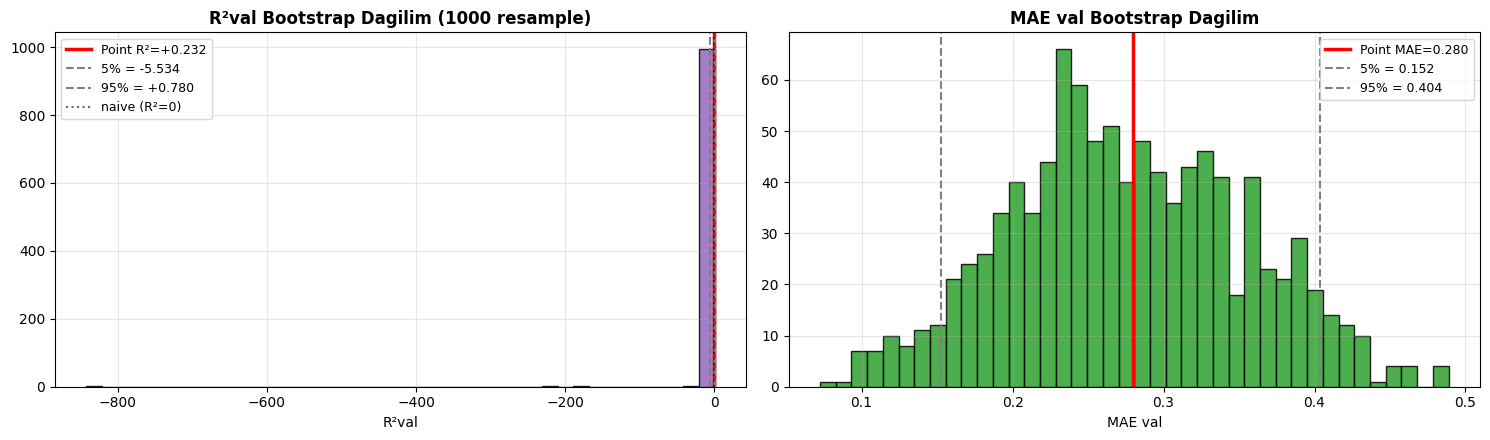


 [C] PER-WEEK LOO RESIDUAL — Hangi val haftasi modeli zorluyor?
  Yontem: Her val haftasini birakip diger 7 hafta MAE'sini olc
          (kazanan tahminler sabit — sadece hangi haftanin lokal etki yarattigini gor)


,Val Hafta,Gercek,Tahmin,Residual,|Residual|,LOO MAE,ΔMAE
0,72,-0.2100,-0.6289,+0.4189,0.4189,0.2599,-0.0199
1,73,-0.1600,-0.3291,+0.1691,0.1691,0.2956,+0.0158
2,74,-0.4400,-0.4927,+0.0527,0.0527,0.3123,+0.0324
3,75,+0.3800,+0.3586,+0.0214,0.0214,0.3167,+0.0369
4,76,-1.0900,-0.8645,-0.2255,0.2255,0.2876,+0.0078
5,77,-0.2100,-0.8103,+0.6003,0.6003,0.2340,-0.0458
6,78,-0.2200,-0.0833,-0.1367,0.1367,0.3003,+0.0204
7,79,+0.1700,-0.4439,+0.6139,0.6139,0.2321,-0.0477



  En zor hafta (max |residual|): 79  |residual|=0.6139
  Maksimum |ΔMAE|              : 0.0477
  Verdict                       : ROBUST — tek hafta etkisi sinirli

 [D] TOP-2 MODE OVERLAY — Hiyerarsi sirasinda ilk 2 modun val tahmin farki
  Top 2 mode (hiyerarsi sirasi): #1 weighted_expanding (kazanan)  |  #2 weighted_sliding

  Pearson corr(weighted_expanding, weighted_sliding): +0.9474
  Max abs farki                       : 0.2535
  Mean abs farki                      : 0.0998
  MAE marjin (top1 - top2)            : -0.0070
  GAUC (top1 / top2)                  : 0.8054 / 0.6976  (Δ=+0.1078)


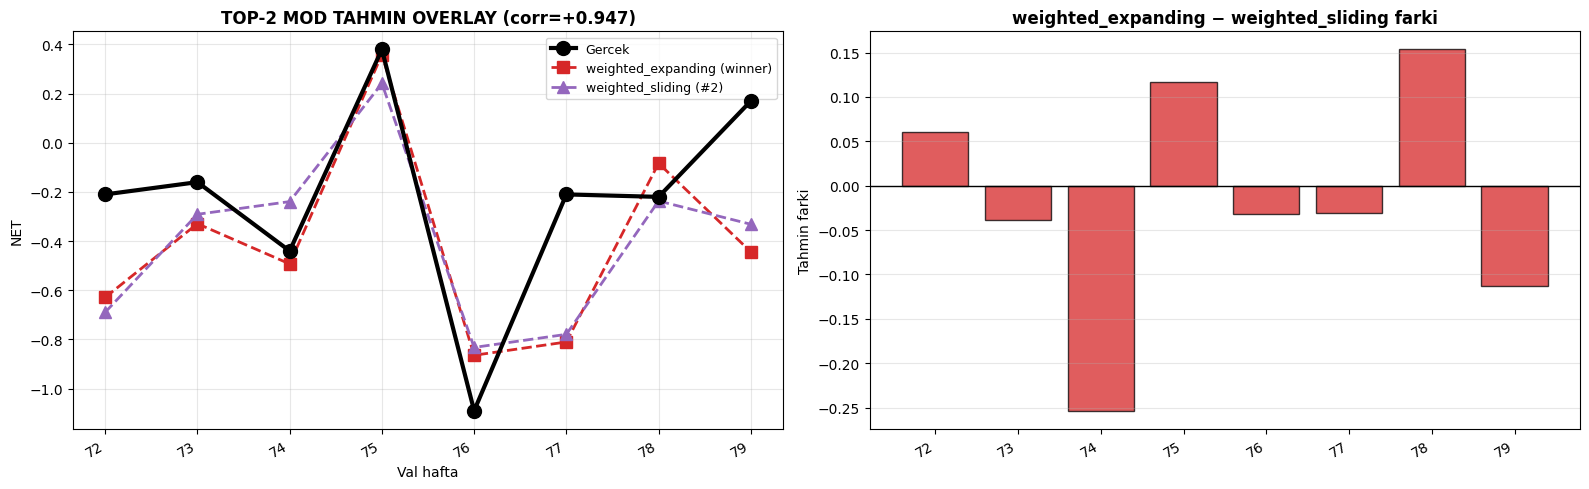

  Kararlilik verdict: FRAGILE — top 2 cok yakin, secim kararsiz

 [E] 3-AILE COEFFICIENT SIGN CHECK — 5 modun ridge isaretleri tutarli mi?
  Yontem: Her mod kendi feature seti uzerinde X_train fit (RidgeCV).
          tlref / welcome / anomaly aileleri icin coef isaretleri matris.



  Tutarli sign         : 14/14 feature
  Karisik sign         : 0/14 feature
  Beklenen iktisadi yorum (referans, modele bagli):
    welcome (osawelcome) : (+) promo arttikca tasarruf girisi artar
    tlref                : (+/−) yuksek TLREF mevduati cazip kilarken welcome'i kirar — rejime bagli
    anomaly              : (−) piyasa anomalileri risk-off → cikis basinci

 ROBUSTLUK OZET — Tum testler tek bakista
  [A] TSCV mean MAE       : 0.5170  (val MAE 0.2798, fark=0.2372)
  [A] TSCV mean R² / GAUC : +0.105 / nan  (val: +0.232 / 0.805)
  [B] R²val 5-95% CI      : [-5.534, +0.780]  width=6.314  → GENIS aralik (n=8 belirsizlik yuksek)
  [C] Max LOO |ΔMAE|      : 0.0477  → ROBUST — tek hafta etkisi sinirli
  [D] Top-2 corr / margin : +0.947  /  MAE margin=0.0070  /  GAUC top1=0.805 top2=0.698  → FRAGILE — top 2 cok yakin, secim kararsiz
  [E] 3-aile sign         : 14 tutarli, 0 karisik (toplam 14 feature)

  Sonuc: yukaridaki 5 kriterin tumu ('tutarli', 'robust', 'dar CI') olursa
   

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# ROBUSTLUK KONTROLU — Step 3 kazaninin saglamlik analizi
# ═══════════════════════════════════════════════════════════════════════════
# [A] TS-CV (5-fold) on X_train  — val MAE'nin alternatif kontrol metrigi
# [B] R²val bootstrap CI         — n=8 val'da R²val sayisinin guven araligi
# [C] Per-week LOO residual      — Hangi val haftasi modeli zorluyor?
# [D] Top-2 mode overlay         — Kazanan ne kadar belirgin?
# [E] 3-aile coef sign check     — 5 modun ridge isaretleri tutarli mi?
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

print("="*80)
print(" ROBUSTLUK KONTROLU — Kazanan Modelin Saglamlik Analizi")
print("="*80)
print(f"  Kazanan mod         : {best_label}")
print(f"  Feature sayisi      : {len(optimal_features)}")
print(f"  Val MAE             : {best['best_stats']['mae']:.4f}")
print(f"  Val R²              : {best['best_stats']['r2_val']:+.4f}")
print(f"  Alpha (RidgeCV)     : {best_alpha:.4f}")

# ───────────────────────────────────────────────────────────────────────────
# [A] TS-CV VERIFICATION (5-fold TimeSeriesSplit on X_train)
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [A] TS-CV VERIFICATION — 5-fold TSCV on X_train ile alternatif MAE")
print("="*120)
print("  Soru   : Step 3'te val MAE optimize edildi (8hf kucuk sample). Bu sayi guvenilir mi?")
print("  Kontrol: Kazanan feature seti ile 5-fold TimeSeriesSplit on X_train.")

_tscv = TimeSeriesSplit(n_splits=5)
fold_mae, fold_r2, fold_gauc = [], [], []
fold_rows = []
for fold_i, (tr_idx, te_idx) in enumerate(_tscv.split(X_train.values), 1):
    Xtr_f = X_train.iloc[tr_idx][optimal_features].values
    ytr_f = y_train.iloc[tr_idx].values
    Xte_f = X_train.iloc[te_idx][optimal_features].values
    yte_f = y_train.iloc[te_idx].values
    m_f = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_f, ytr_f)
    pred_f = m_f.predict(Xte_f)
    fmae = float(mean_absolute_error(yte_f, pred_f))
    fr2  = float(r2_score(yte_f, pred_f)) if len(yte_f) > 1 else np.nan
    fgauc = _safe_gauc(yte_f, pred_f) if '_safe_gauc' in globals() else np.nan
    fold_mae.append(fmae); fold_r2.append(fr2); fold_gauc.append(fgauc)
    fold_rows.append({'Fold': f'Fold {fold_i}', 'n_train': len(tr_idx), 'n_test': len(te_idx),
                      'MAE': fmae, 'R²': fr2, 'GAUC': fgauc})

_tscv_tbl = pd.DataFrame(fold_rows).set_index('Fold')
_tscv_tbl.loc['Mean'] = ['-', '-', float(np.mean(fold_mae)), float(np.nanmean(fold_r2)), float(np.nanmean(fold_gauc))]
_tscv_tbl.loc['Std']  = ['-', '-', float(np.std(fold_mae)),  float(np.nanstd(fold_r2)),  float(np.nanstd(fold_gauc))]
def _safe_fmt(spec):
    def _f(v):
        if isinstance(v, str) or v is None: return v if v is not None else ''
        try:
            if pd.isna(v): return '—'
        except Exception: pass
        try: return format(float(v), spec)
        except (TypeError, ValueError): return str(v)
    return _f
display(_tscv_tbl.style.set_table_styles(_TABLE_STYLES)
        .format({'n_train': _safe_fmt('.0f'), 'n_test': _safe_fmt('.0f'),
                 'MAE': _safe_fmt('.4f'), 'R²': _safe_fmt('+.4f'), 'GAUC': _safe_fmt('.4f')}, na_rep='—'))

_tscv_mean_mae  = float(np.mean(fold_mae))
_tscv_mean_r2   = float(np.nanmean(fold_r2))
_tscv_mean_gauc = float(np.nanmean(fold_gauc))
_mae_gap = abs(_tscv_mean_mae - best['best_stats']['mae'])
print(f"\n  TSCV mean MAE       : {_tscv_mean_mae:.4f}  ± {np.std(fold_mae):.4f}")
print(f"  TSCV mean R²        : {_tscv_mean_r2:+.4f}  ± {np.nanstd(fold_r2):.4f}")
print(f"  TSCV mean GAUC      : {_tscv_mean_gauc:.4f}  ± {np.nanstd(fold_gauc):.4f}")
print(f"  Step 3 val MAE      : {best['best_stats']['mae']:.4f}")
print(f"  Step 3 val R²       : {best['best_stats']['r2_val']:+.4f}")
print(f"  Step 3 val GAUC     : {best['best_stats']['gauc_val']:.4f}")
print(f"  MAE farki           : {_mae_gap:.4f}  → "
      f"{'TUTARLI (val MAE makul)' if _mae_gap < 0.05 else 'BUYUK FARK (val MAE iyimser olabilir)'}")

# ───────────────────────────────────────────────────────────────────────────
# [B] R²_VAL BOOTSTRAP CONFIDENCE INTERVAL
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [B] R²_VAL BOOTSTRAP CI — Val tahminlerinin sampling variansi (n=1000 resample)")
print("="*120)
print("  Soru   : R²val=0.80 sayisi sansa karsi ne kadar dayanikli?")
print("  Yontem : (y_val, pred_val) ciftlerini bootstrap resample, her seferinde R² ve MAE hesapla")

_winner_preds = _val_preds[best_label]
_y_val_arr = y_val.values

_rng = np.random.default_rng(seed=RANDOM_SEED)
N_BOOT = 1000
boot_r2, boot_mae = [], []
for _ in range(N_BOOT):
    idx = _rng.choice(len(_y_val_arr), size=len(_y_val_arr), replace=True)
    y_b = _y_val_arr[idx]; p_b = _winner_preds[idx]
    if y_b.var() < 1e-10:
        continue
    ss_t = float(np.sum((y_b - y_b.mean()) ** 2))
    ss_r = float(np.sum((y_b - p_b) ** 2))
    boot_r2.append(1.0 - ss_r / ss_t if ss_t > 0 else np.nan)
    boot_mae.append(float(np.mean(np.abs(y_b - p_b))))

boot_r2_arr = np.array([x for x in boot_r2 if not np.isnan(x)])
boot_mae_arr = np.array(boot_mae)
r2_lo, r2_hi   = np.percentile(boot_r2_arr,  [5, 95])
r2_p50         = float(np.median(boot_r2_arr))
mae_lo, mae_hi = np.percentile(boot_mae_arr, [5, 95])
mae_p50        = float(np.median(boot_mae_arr))

_point_r2  = best['best_stats']['r2_val']
_point_mae = best['best_stats']['mae']
print(f"\n  Point R²val          : {_point_r2:+.4f}   |   Bootstrap median: {r2_p50:+.4f}")
print(f"  R²val 5-95% CI       : [{r2_lo:+.4f}, {r2_hi:+.4f}]   width={r2_hi - r2_lo:.3f}")
print(f"  Point MAE val        : {_point_mae:.4f}   |   Bootstrap median: {mae_p50:.4f}")
print(f"  MAE val 5-95% CI     : [{mae_lo:.4f}, {mae_hi:.4f}]   width={mae_hi - mae_lo:.3f}")
_ci_verdict = "DAR aralik (saglam tahmin)" if (r2_hi - r2_lo) < 0.30 else "GENIS aralik (n=8 belirsizlik yuksek)"
print(f"  Verdict              : {_ci_verdict}")

# Histogram
fig_b, axb = plt.subplots(1, 2, figsize=(15, 4.5))
axb[0].hist(boot_r2_arr, bins=40, color='#9467bd', edgecolor='black', alpha=0.85)
axb[0].axvline(_point_r2, color='red', linewidth=2.5, label=f"Point R²={_point_r2:+.3f}")
axb[0].axvline(r2_lo, color='gray', linestyle='--', label=f'5% = {r2_lo:+.3f}')
axb[0].axvline(r2_hi, color='gray', linestyle='--', label=f'95% = {r2_hi:+.3f}')
axb[0].axvline(0,    color='black', linestyle=':', alpha=0.6, label='naive (R²=0)')
axb[0].set_title('R²val Bootstrap Dagilim (1000 resample)', fontweight='bold')
axb[0].set_xlabel('R²val'); axb[0].legend(fontsize=9); axb[0].grid(alpha=0.3)

axb[1].hist(boot_mae_arr, bins=40, color='#2ca02c', edgecolor='black', alpha=0.85)
axb[1].axvline(_point_mae, color='red', linewidth=2.5, label=f"Point MAE={_point_mae:.3f}")
axb[1].axvline(mae_lo, color='gray', linestyle='--', label=f'5% = {mae_lo:.3f}')
axb[1].axvline(mae_hi, color='gray', linestyle='--', label=f'95% = {mae_hi:.3f}')
axb[1].set_title('MAE val Bootstrap Dagilim', fontweight='bold')
axb[1].set_xlabel('MAE val'); axb[1].legend(fontsize=9); axb[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ───────────────────────────────────────────────────────────────────────────
# [C] PER-WEEK LOO RESIDUAL ANALYSIS
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [C] PER-WEEK LOO RESIDUAL — Hangi val haftasi modeli zorluyor?")
print("="*120)
print("  Yontem: Her val haftasini birakip diger 7 hafta MAE'sini olc")
print("          (kazanan tahminler sabit — sadece hangi haftanin lokal etki yarattigini gor)")

loo_rows = []
n_val = len(_y_val_arr)
for i in range(n_val):
    mask = np.arange(n_val) != i
    y_keep = _y_val_arr[mask]; p_keep = _winner_preds[mask]
    mae_loo = float(np.mean(np.abs(y_keep - p_keep)))
    delta   = mae_loo - _point_mae
    residual = _y_val_arr[i] - _winner_preds[i]
    loo_rows.append({
        'Val Hafta': str(y_val.index[i])[:10] if hasattr(y_val, 'index') else f'w{i}',
        'Gercek':    _y_val_arr[i],
        'Tahmin':    _winner_preds[i],
        'Residual':  residual,
        '|Residual|': abs(residual),
        'LOO MAE':   mae_loo,
        'ΔMAE':      delta,
    })
_loo_tbl = pd.DataFrame(loo_rows)
display(_loo_tbl.style.set_table_styles(_TABLE_STYLES)
        .format({'Gercek': _safe_fmt('+.4f'), 'Tahmin': _safe_fmt('+.4f'),
                 'Residual': _safe_fmt('+.4f'), '|Residual|': _safe_fmt('.4f'),
                 'LOO MAE': _safe_fmt('.4f'), 'ΔMAE': _safe_fmt('+.4f')}, na_rep='—'))

_worst_i = int(_loo_tbl['|Residual|'].argmax())
_worst_week = _loo_tbl.iloc[_worst_i]['Val Hafta']
_worst_res  = _loo_tbl.iloc[_worst_i]['|Residual|']
_max_dmae   = float(_loo_tbl['ΔMAE'].abs().max())
print(f"\n  En zor hafta (max |residual|): {_worst_week}  |residual|={_worst_res:.4f}")
print(f"  Maksimum |ΔMAE|              : {_max_dmae:.4f}")
_loo_verdict = "FRAGILE — tek hafta MAE'yi >5% degistiriyor" if _max_dmae > 0.05 else "ROBUST — tek hafta etkisi sinirli"
print(f"  Verdict                       : {_loo_verdict}")

# ───────────────────────────────────────────────────────────────────────────
# [D] TOP-2 MODE VAL PREDICTION OVERLAY
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [D] TOP-2 MODE OVERLAY — Hiyerarsi sirasinda ilk 2 modun val tahmin farki")
print("="*120)

top2 = cmp_tbl_full.head(2)['Model'].tolist()
print(f"  Top 2 mode (hiyerarsi sirasi): #1 {top2[0]} (kazanan)  |  #2 {top2[1]}")

if len(top2) >= 2:
    p1 = _val_preds[top2[0]]; p2 = _val_preds[top2[1]]
    diff = p1 - p2
    corr = float(np.corrcoef(p1, p2)[0, 1])
    mae1 = float(cmp_tbl_full.iloc[0]['MAE Val'])
    mae2 = float(cmp_tbl_full.iloc[1]['MAE Val'])
    mae_margin = mae2 - mae1
    print(f"\n  Pearson corr({top2[0]}, {top2[1]}): {corr:+.4f}")
    print(f"  Max abs farki                       : {np.max(np.abs(diff)):.4f}")
    print(f"  Mean abs farki                      : {np.mean(np.abs(diff)):.4f}")
    print(f"  MAE marjin (top1 - top2)            : {-mae_margin:+.4f}")
    # GAUC karsilastirmasi
    _gauc1 = _safe_gauc(_y_val_arr, p1) if '_safe_gauc' in globals() else np.nan
    _gauc2 = _safe_gauc(_y_val_arr, p2) if '_safe_gauc' in globals() else np.nan
    print(f"  GAUC (top1 / top2)                  : {_gauc1:.4f} / {_gauc2:.4f}  (Δ={_gauc1-_gauc2:+.4f})")

    fig_d, axd = plt.subplots(1, 2, figsize=(16, 5))
    axd[0].plot(_val_xs, _y_val_arr, 'k-o', linewidth=3, markersize=10, label='Gercek', zorder=10)
    axd[0].plot(_val_xs, p1, '--s', color=_mode_colors[top2[0]], linewidth=2,
                label=f'{top2[0]} (winner)', markersize=8)
    axd[0].plot(_val_xs, p2, '--^', color=_mode_colors[top2[1]], linewidth=2,
                label=f'{top2[1]} (#2)', markersize=8)
    axd[0].set_title(f'TOP-2 MOD TAHMIN OVERLAY (corr={corr:+.3f})', fontweight='bold')
    axd[0].set_xlabel('Val hafta'); axd[0].set_ylabel('NET'); axd[0].legend(fontsize=9)
    axd[0].grid(alpha=0.3); plt.setp(axd[0].get_xticklabels(), rotation=30, ha='right')

    axd[1].bar(range(len(diff)), diff, color='#d62728', alpha=0.75, edgecolor='black')
    axd[1].axhline(0, color='black', linewidth=1)
    axd[1].set_xticks(range(len(diff)))
    axd[1].set_xticklabels(_val_labels, rotation=30, ha='right')
    axd[1].set_title(f'{top2[0]} − {top2[1]} farki', fontweight='bold')
    axd[1].set_ylabel('Tahmin farki'); axd[1].grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()

    _fragility = "FRAGILE — top 2 cok yakin, secim kararsiz" if abs(mae_margin) < 0.01 else \
                 ("MARGINAL — fark var ama kucuk"           if abs(mae_margin) < 0.03 else \
                  "ROBUST — kazanan acik bir farkla onde")
    print(f"  Kararlilik verdict: {_fragility}")

# ───────────────────────────────────────────────────────────────────────────
# [E] 3-FAMILY COEFFICIENT SIGN CHECK
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [E] 3-AILE COEFFICIENT SIGN CHECK — 5 modun ridge isaretleri tutarli mi?")
print("="*120)
print("  Yontem: Her mod kendi feature seti uzerinde X_train fit (RidgeCV).")
print("          tlref / welcome / anomaly aileleri icin coef isaretleri matris.")

mode_coefs = {}
for mn in mode_list:
    feats = results[mn]['best_feats']
    if not feats: continue
    m_x = RidgeCV(alphas=ALPHA_GRID).fit(X_train[feats].values, y_train.values)
    mode_coefs[mn] = dict(zip(feats, m_x.coef_))

# 3-family feature havuzu (tum modlardan toplam birlesim)
all_3fam = set()
for coefs in mode_coefs.values():
    for f in coefs.keys():
        if any(fam in f.lower() for fam in PROTECTION_3FAM):
            all_3fam.add(f)

fam_rows = []
for feat in sorted(all_3fam):
    fam_label = next((f for f in PROTECTION_3FAM if f in feat.lower()), '?')
    row = {'Aile': fam_label, 'Feature': feat}
    plus_n, minus_n, used_n = 0, 0, 0
    for mn in mode_list:
        c = mode_coefs.get(mn, {}).get(feat, None)
        if c is None:
            row[mn] = '—'
        else:
            used_n += 1
            s = '+' if c > 1e-6 else ('−' if c < -1e-6 else '0')
            if s == '+': plus_n += 1
            elif s == '−': minus_n += 1
            row[mn] = f"{s} {c:+.3f}"
    row['Used'] = f'{used_n}/5'
    row['+/−']  = f'{plus_n}+ / {minus_n}−'
    if used_n == 0:
        row['Tutarli?'] = '—'
    else:
        row['Tutarli?'] = '✓ tutarli' if (plus_n == 0 or minus_n == 0) else '✗ karisik isaret'
    fam_rows.append(row)

fam_tbl = pd.DataFrame(fam_rows).set_index(['Aile', 'Feature']).sort_index()
display(fam_tbl.style.set_table_styles(_TABLE_STYLES))

_consistent = sum(1 for r in fam_rows if r['Tutarli?'] == '✓ tutarli')
_mixed      = sum(1 for r in fam_rows if r['Tutarli?'] == '✗ karisik isaret')
print(f"\n  Tutarli sign         : {_consistent}/{len(fam_rows)} feature")
print(f"  Karisik sign         : {_mixed}/{len(fam_rows)} feature")
print(f"  Beklenen iktisadi yorum (referans, modele bagli):")
print(f"    welcome (osawelcome) : (+) promo arttikca tasarruf girisi artar")
print(f"    tlref                : (+/−) yuksek TLREF mevduati cazip kilarken welcome'i kirar — rejime bagli")
print(f"    anomaly              : (−) piyasa anomalileri risk-off → cikis basinci")

# ───────────────────────────────────────────────────────────────────────────
# OZET
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" ROBUSTLUK OZET — Tum testler tek bakista")
print("="*120)
print(f"  [A] TSCV mean MAE       : {_tscv_mean_mae:.4f}  (val MAE {best['best_stats']['mae']:.4f}, fark={_mae_gap:.4f})")
print(f"  [A] TSCV mean R² / GAUC : {_tscv_mean_r2:+.3f} / {_tscv_mean_gauc:.3f}  (val: {best['best_stats']['r2_val']:+.3f} / {best['best_stats']['gauc_val']:.3f})")
print(f"  [B] R²val 5-95% CI      : [{r2_lo:+.3f}, {r2_hi:+.3f}]  width={r2_hi-r2_lo:.3f}  → {_ci_verdict}")
print(f"  [C] Max LOO |ΔMAE|      : {_max_dmae:.4f}  → {_loo_verdict}")
if len(top2) >= 2:
    print(f"  [D] Top-2 corr / margin : {corr:+.3f}  /  MAE margin={abs(mae_margin):.4f}  /  GAUC top1={_gauc1:.3f} top2={_gauc2:.3f}  → {_fragility}")
print(f"  [E] 3-aile sign         : {_consistent} tutarli, {_mixed} karisik (toplam {len(fam_rows)} feature)")
print()
print(f"  Sonuc: yukaridaki 5 kriterin tumu ('tutarli', 'robust', 'dar CI') olursa")
print(f"         kazanan model gercekten saglam. Karisik sinyal varsa X_test eval'inde dikkatli ol.")


<h2 style="color: rgb(255,98,0)">Step 4 — X_test Final Eval + Forecast (NET=NaN)</h2>

Kazanan model (Step 3'ten) için son adım: <b>X_test (3 hf, NET mevcut)</b> üzerinde unbiased değerlendirme + <b>X_predict (NET=NaN, kapanmamış haftalar)</b> üzerinde operasyonel tahmin.

- <b>X_test bölümü</b>: walk-forward refit, her hafta için ayrı tahmin. Metrikler: <b>MAE / R² / AdjR² / GAUC</b> + per-week tablo + cumulative residual plot.
- <b>X_predict bölümü</b>: NET=NaN olan kapanmamış hafta(lar) için kazanan modelin tahmini. Operasyonel çıktı.
- <b>GAUC vurgusu</b>: küçük örneklemde (n=3 test, n=8 val) R² gürültülüdür — GAUC sıralama doğruluğu olarak daha stabil bir gösterge.

<b>[A] X_TEST EVAL</b>: Walk-forward refit her hafta — winner mod + static kıyas yan yana. MAE / R² / AdjR² / GAUC. Bootstrap CI val (1000 resample, IID notu). Kıyas tablosu: TSCV / Val / Test, winner + static. Per-row residual + grafik.

<b>[B] X_PREDICT FORECAST</b>: NET=NaN forecast haftaları. Tahmin tablosu winner vs static yan yana, naive baseline ile karşılaştırma.

<b>[C] FINAL OZET</b>: Winner + static blokları, Test MAE delta + verdict.

<b>[D] PER-WEEK MAE DALGALANMA ANALİZİ</b> (yeni): Val + Test her hafta |residual| tablosu winner & static için. Volatilite metrikleri (CV, range, max hafta-hafta sıçraması). Box-plot + timeline grafik. Verdict CV<0.3 LINEER / 0.3-0.6 ORTA / >0.6 DALGALI.

<b>[D2] NEDEN WINNER STATIC'TEN İYİ?</b> (yeni): 6 maddelik kanıt zinciri: (1) genel MAE farkı + ratio, (2) hafta-hafta win/loss rate, (3) en dramatik avantaj haftaları, (4) walk-forward refit'in test'teki etkisi (özellikle son test haftası), (5) açıklama (4 alt-mekanizma: walk-forward, weighted decay, feature interaksiyonları, istatistik gerçek), (6) sonuç + verdict.

<i>Transition verdict yön-ayrımlı</i>: |Δ|<0.05 STABIL ✓, Δ<-0.05 İYİLEŞME ✓, Δ>+0.05 KÖTÜLEŞME ✗.


 STEP 4 — X_TEST FINAL EVAL + X_PREDICT FORECAST
  Kazanan mod         : weighted_expanding
  Feature sayisi      : 17
  X_test (NET mevcut) : 3 hf  ← unbiased metrik
  X_predict (forecast): 1 hf  ← NET=NaN

 [A] X_TEST EVAL — Kazanan mod ile walk-forward refit, NET mevcut haftalar


,Test Hafta,Gercek NET,Tahmin (weighted_expanding),Residual (winner),Tahmin (static),Residual (static)
0,80,-0.0900,+0.1021,-0.1921,-0.2894,+0.1994
1,81,-0.4000,-0.3131,-0.0869,-0.5259,+0.1259
2,82,-0.9000,-0.8252,-0.0748,-0.1847,-0.7153



  [X_TEST METRIKLER — 3 hafta, NET mevcut]
    weighted_expanding     (winner)  MAE=0.1180  R²=+0.8501  AdjR²=+nan  GAUC=1.0000
    static                 (kiyas)   MAE=0.3469  R²=-0.6983  AdjR²=+nan  GAUC=0.2500

  [KIYAS — Val (Step 3 raporu) vs TSCV (kazanan FS uzerinde) vs Test (Step 4)]


,n,MAE,R²,AdjR²,GAUC
Set,,,,,
"TSCV (weighted_expanding, 5-fold rw)",72,0.4830,+0.2079,—,—
"Val (weighted_expanding, 8 hf)",8,0.2798,+0.2325,—,0.8054
TEST (weighted_expanding),3,0.1180,+0.8501,—,1.0000
"Val (static, 8 hf)",8,0.3602,+0.0128,—,0.5180
TEST (static),3,0.3469,-0.6983,—,0.2500



  [VAL BOOTSTRAP CI — 1000 resample, n_val=8]
    Val MAE 5-95%%: [0.1524, 0.4038]   (point: 0.2798, width: 0.251)
    Val R²  5-95%%: [-5.5335, +0.7800]   (point: +0.2325, width: 6.314)
    R² CI genisligi: GENIS (n=8 belirsizlik yuksek)
    ! NOT: IID resample (zaman serisi varsayimini ihlal eder)
      Autokorelasyon varsa gercek CI 20-40%% daha genis olabilir; moving-block bootstrap yapilmadi.

  MAE verdict (test vs TSCV beklenen [0.242-0.725]): IYIMSER — TSCV temkinli, test iyi cikti


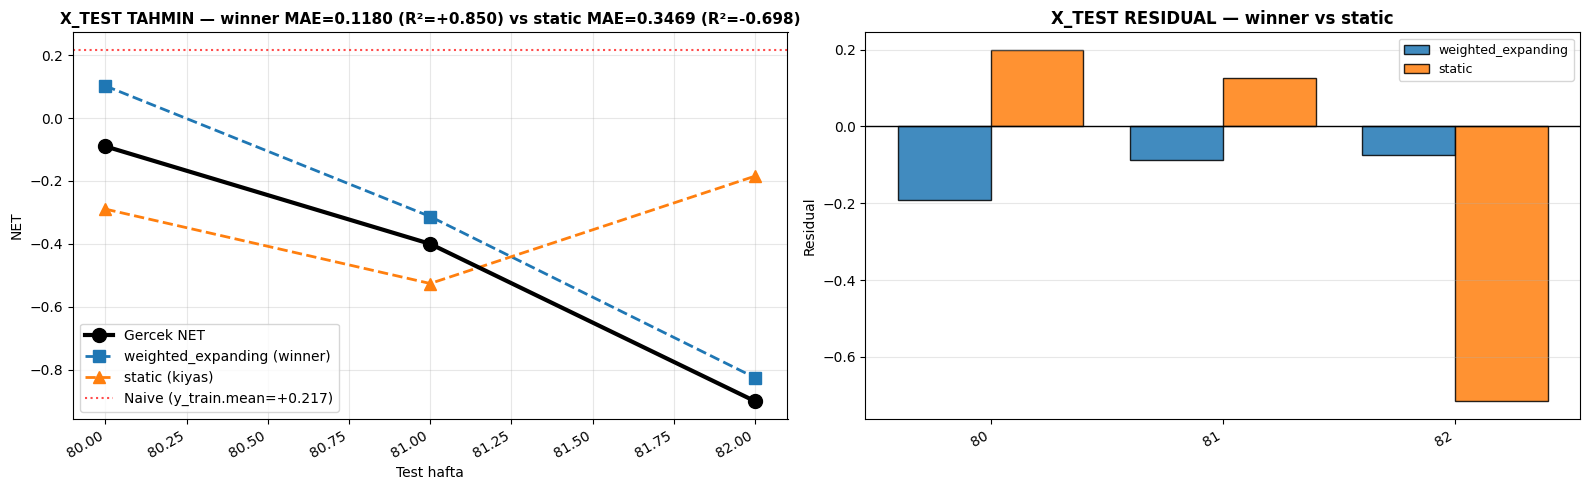


 [B] X_PREDICT FORECAST — NET=NaN haftalar icin kazanan modelin tahmini
  Forecast haftasi sayisi: 1


,Hafta,Tahmin (weighted_expanding),Tahmin (static),Naive (y_train.mean),Δ winner vs static,Δ winner vs naive
0,2026-05-15,-0.9441,-0.4066,+0.2165,-0.5375,-1.1606



  Forecast tahmin(ler)i yukaridaki tabloda — operasyonel cikti.
  (Bu satirlarin NET'i bilinmedigi icin metrik hesaplanmiyor; sadece model cikti)
  Δ winner vs static = kazanan modelin static'ten ne kadar farkli tahmin ettigi

 [C] FINAL OZET — Kazanan modelin tum-set performansi
  Kazanan mod       : weighted_expanding
  Alpha (Ridge)     : 0.0100
  Feature sayisi    : 17  (n/p train = 4.24)

  [WINNER: weighted_expanding]
    Train R²/AdjR²/GAUC: +0.8370 / +0.7887 / 0.6507
    TSCV  wMAE/wR²    : 0.4830 / +0.2079
    Val   MAE/R²/GAUC : 0.2798 / +0.2325 / 0.8054
    TEST  MAE/R²/GAUC : 0.1180 / +0.8501 / 1.0000  ← X_TEST FINAL

  [STATIC (kiyas)]
    Feature sayisi    : 18
    Train R²/AdjR²/GAUC: +0.7813 / +0.7070 / 0.5437
    TSCV  wMAE/wR²    : 0.5806 / -0.1229
    Val   MAE/R²/GAUC : 0.3602 / +0.0128 / 0.5180
    TEST  MAE/R²/GAUC : 0.3469 / -0.6983 / 0.2500

  Test MAE delta (winner - static): -0.2289  → WINNER daha iyi
  Forecast          : 1 hafta tahmin uretildi (winner + st


  VOLATILITE OZET (CV = std/mean → düşük=stabil, yüksek=dalgalı):


,n,mean,std,min,max,range,cv,max_diff
set,,,,,,,,
VAL winner,8,0.2798,0.2201,0.0214,0.6139,0.5925,0.787,0.4772
VAL static,8,0.3602,0.1825,0.0349,0.6225,0.5876,0.507,0.4957
TEST winner,3,0.1180,0.0527,0.0748,0.1921,0.1173,0.447,0.1052
TEST static,3,0.3469,0.2623,0.1259,0.7153,0.5895,0.756,0.5895



  VERDICT (CV-bazli):
    VAL winner    : CV=0.787  range=0.5925  max hf-hf jump=0.4772  → DALGALI (CV>0.6, ucurum belirgin)
    VAL static    : CV=0.507  range=0.5876  max hf-hf jump=0.4957  → ORTA dalgali (CV 0.3-0.6)
    TEST winner   : CV=0.447  range=0.1173  max hf-hf jump=0.1052  → ORTA dalgali (CV 0.3-0.6)
    TEST static   : CV=0.756  range=0.5895  max hf-hf jump=0.5895  → DALGALI (CV>0.6, ucurum belirgin)


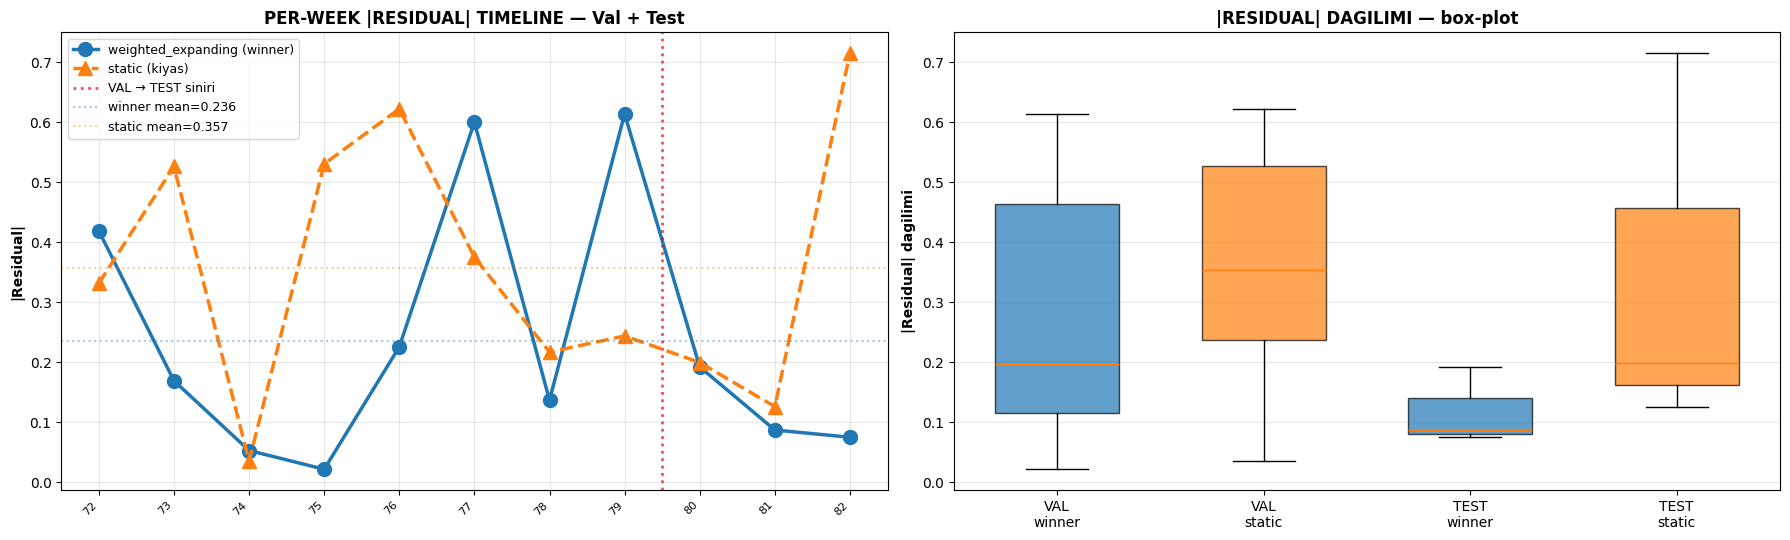


  KARSILASTIRMA OZETI:
    Val  mean |residual|  : winner=0.2798  static=0.3602  Δ(s-w)=+0.0804
    Test mean |residual|  : winner=0.1180  static=0.3469  Δ(s-w)=+0.2289
    Val → Test transition:
      winner mean: 0.2798 → 0.1180   Δ=-0.1619
      static mean: 0.3602 → 0.3469   Δ=-0.0133
    Val→Test transition verdict:
      winner Δ=-0.1619  → IYILESME ✓ (test 0.1619 daha dusuk MAE — son donem modeli daha iyi tahmin)
      static Δ=-0.0133  → STABIL ✓ (|Δ|<0.05, val ≈ test)

  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  [D2] NEDEN WINNER STATIC'TEN DAHA IYI? — Kanitlar
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

  1) GENEL MAE FARKI:
     Test MAE   : winner=0.1180  vs  static=0.3469  → winner 2.9x daha iyi
     Val MAE    : winner=0.2798  vs  static=0.3602
     Tum-set    : winner=0.2357  vs  static=0.3566

  2) HAFTA-HAFTAYA WIN/LO

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 4 — X_TEST FINAL EVAL + X_PREDICT FORECAST (NET=NaN haftalar)
# ═══════════════════════════════════════════════════════════════════════════
# Kazanan: best_label (Step 3'ten) — walk-forward refit her hafta icin
# X_test (NET mevcut): unbiased metrik raporu
# X_predict (NET=NaN): forecast cikti (metrik yok, sadece tahmin)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print(" STEP 4 — X_TEST FINAL EVAL + X_PREDICT FORECAST")
print("="*80)
print(f"  Kazanan mod         : {best_label}")
print(f"  Feature sayisi      : {len(optimal_features)}")
print(f"  X_test (NET mevcut) : {len(X_test)} hf  ← unbiased metrik")
print(f"  X_predict (forecast): {len(X_predict)} hf  ← NET=NaN")

# Kazanan mode ile walk-forward predict (X_test → X_predict siralamali)
def _wf_predict_sequence(target_X, mode, feats, X_history, y_history, append_target_after_pred=True, target_y=None):
    """target_X siralarini walk-forward tahmin et.
       X_history/y_history: target_X'ten once bilinen veri.
       Her tahminden sonra (varsa) target gercek y'si history'e eklenir."""
    preds = []
    X_acc = X_history.copy().reset_index(drop=True)
    y_acc = y_history.copy().reset_index(drop=True)
    for i in range(len(target_X)):
        n_acc = len(X_acc)
        if mode == 'static':
            # STATIC: FIXED window — initial X_history (asla buyumez)
            sl = slice(0, len(X_history))
        elif mode in ('sliding', 'weighted_sliding'):
            sl = slice(max(0, n_acc - SLIDING_WIN), n_acc)
        else:  # expanding, weighted_expanding
            sl = slice(0, n_acc)
        Xtr_t = X_acc.iloc[sl][feats].values
        ytr_t = y_acc.iloc[sl].values
        if mode in ('weighted_sliding', 'weighted_expanding'):
            w = DECAY ** np.arange(len(ytr_t) - 1, -1, -1)
            m = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_t, ytr_t, sample_weight=w)
        else:
            m = RidgeCV(alphas=ALPHA_GRID).fit(Xtr_t, ytr_t)
        x_target = target_X.iloc[i:i+1][feats].values
        p = float(m.predict(x_target)[0])
        preds.append(p)
        # Bir sonraki adim icin (target_y varsa) history'e gercek y; yoksa tahmin
        if append_target_after_pred:
            X_acc = pd.concat([X_acc, target_X.iloc[i:i+1].reset_index(drop=True)], ignore_index=True)
            if target_y is not None and not pd.isna(target_y.iloc[i]):
                y_acc = pd.concat([y_acc, pd.Series([target_y.iloc[i]])], ignore_index=True)
            else:
                y_acc = pd.concat([y_acc, pd.Series([p])], ignore_index=True)
    return np.array(preds)

# ───────────────────────────────────────────────────────────────────────────
# [A] X_TEST EVAL (NET mevcut)
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [A] X_TEST EVAL — Kazanan mod ile walk-forward refit, NET mevcut haftalar")
print("="*120)

X_history_for_test = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_history_for_test = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

test_preds = _wf_predict_sequence(
    target_X=X_test, mode=best_label, feats=optimal_features,
    X_history=X_history_for_test, y_history=y_history_for_test,
    append_target_after_pred=True, target_y=y_test
)

# STATIC karsilastirmasi: kendi feature seti ile X_train fit, X_test tek seferde tahmin
_static_feats = results['static']['best_feats']
_m_static = RidgeCV(alphas=ALPHA_GRID).fit(X_train[_static_feats].values, y_train.values)
static_test_preds = _m_static.predict(X_test[_static_feats].values)

# Metrikler (X_test uzerinde, NET mevcut)
y_test_arr = y_test.values
ss_tot_test = float(np.sum((y_test_arr - y_test_arr.mean()) ** 2)) if len(y_test_arr) > 1 else np.nan
def _metrics(pred):
    ss_res = float(np.sum((y_test_arr - pred) ** 2))
    r2  = 1.0 - ss_res / ss_tot_test if (not np.isnan(ss_tot_test) and ss_tot_test > 0) else np.nan
    mae = float(np.mean(np.abs(y_test_arr - pred))) if len(y_test_arr) > 0 else np.nan
    p_  = len(optimal_features) if pred is test_preds else len(_static_feats)
    # AdjR² for test — use len(y_test), not len(y_train) (statistical correctness)
    # n_test=3, p=20 ise n<=p+1 → NaN doner (helper guard) — bu dogru davranis
    adj = _adj_r2(r2, len(y_test_arr), p_) if not np.isnan(r2) else np.nan
    gauc = _safe_gauc(y_test_arr, pred) if len(y_test_arr) >= 3 else np.nan
    return mae, r2, adj, gauc

mae_test,        r2_test,        adj_r2_test,        gauc_test        = _metrics(test_preds)
mae_test_static, r2_test_static, adj_r2_test_static, gauc_test_static = _metrics(static_test_preds)
p_test = len(optimal_features)

test_rows = []
test_xs = list(y_test.index) if hasattr(y_test, 'index') else list(range(len(y_test)))
for i in range(len(y_test_arr)):
    test_rows.append({
        'Test Hafta':       str(test_xs[i])[:10],
        'Gercek NET':       float(y_test_arr[i]),
        f'Tahmin ({best_label})': float(test_preds[i]),
        'Residual (winner)':   float(y_test_arr[i] - test_preds[i]),
        'Tahmin (static)':  float(static_test_preds[i]),
        'Residual (static)':   float(y_test_arr[i] - static_test_preds[i]),
    })
test_tbl = pd.DataFrame(test_rows)
_fmt_test = {'Gercek NET':'{:+.4f}',
             f'Tahmin ({best_label})':'{:+.4f}', 'Residual (winner)':'{:+.4f}',
             'Tahmin (static)':'{:+.4f}', 'Residual (static)':'{:+.4f}'}
display(test_tbl.style.set_table_styles(_TABLE_STYLES).format(_fmt_test, na_rep='—'))

print(f"\n  [X_TEST METRIKLER — {len(y_test_arr)} hafta, NET mevcut]")
print(f"    {best_label:<22s} (winner)  MAE={mae_test:.4f}  R²={r2_test:+.4f}  AdjR²={adj_r2_test:+.4f}  GAUC={gauc_test:.4f}")
print(f"    {'static':<22s} (kiyas)   MAE={mae_test_static:.4f}  R²={r2_test_static:+.4f}  AdjR²={adj_r2_test_static:+.4f}  GAUC={gauc_test_static:.4f}")

# Kiyas: val + TSCV ile X_test
print(f"\n  [KIYAS — Val (Step 3 raporu) vs TSCV (kazanan FS uzerinde) vs Test (Step 4)]")
_bs = best['best_stats']
_static_stats = results['static']['best_stats']
kiyas_tbl = pd.DataFrame([
    {'Set': f'TSCV ({best_label}, 5-fold rw)', 'n': len(y_train), 'MAE': _bs.get('tscv_wmae', np.nan),
     'R²': _bs.get('tscv_wr2', np.nan), 'AdjR²': np.nan,
     'GAUC': np.nan},
    {'Set': f'Val ({best_label}, 8 hf)', 'n': len(y_val), 'MAE': _bs['mae'],
     'R²': _bs['r2_val'], 'AdjR²': _bs['adj_r2_val'],
     'GAUC': _bs['gauc_val']},
    {'Set': f'TEST ({best_label})', 'n': len(y_test_arr), 'MAE': mae_test,
     'R²': r2_test, 'AdjR²': adj_r2_test,
     'GAUC': gauc_test},
    {'Set': f'Val (static, 8 hf)', 'n': len(y_val), 'MAE': _static_stats['mae'],
     'R²': _static_stats['r2_val'], 'AdjR²': _static_stats['adj_r2_val'],
     'GAUC': _static_stats['gauc_val']},
    {'Set': f'TEST (static)', 'n': len(y_test_arr), 'MAE': mae_test_static,
     'R²': r2_test_static, 'AdjR²': adj_r2_test_static,
     'GAUC': gauc_test_static},
]).set_index('Set')
display(kiyas_tbl.style.set_table_styles(_TABLE_STYLES)
        .format({'n':'{:.0f}','MAE':'{:.4f}','R²':'{:+.4f}','AdjR²':'{:+.4f}','GAUC':'{:.4f}'}, na_rep='—'))

# ── Bootstrap CI val (n=8 belirsizligi)
if best_label in _val_preds:
    _yv_arr = y_val.values
    _vp = _val_preds[best_label]
    _rng_b = np.random.default_rng(seed=RANDOM_SEED)
    _b_r2, _b_mae = [], []
    for _ in range(1000):
        _idx = _rng_b.choice(len(_yv_arr), len(_yv_arr), replace=True)
        _y_b = _yv_arr[_idx]; _p_b = _vp[_idx]
        if _y_b.var() < 1e-10: continue
        _ss_t = float(np.sum((_y_b - _y_b.mean()) ** 2))
        _ss_r = float(np.sum((_y_b - _p_b) ** 2))
        _b_r2.append(1.0 - _ss_r / _ss_t if _ss_t > 0 else np.nan)
        _b_mae.append(float(np.mean(np.abs(_y_b - _p_b))))
    _bvr2 = np.array([x for x in _b_r2 if not np.isnan(x)])
    _bvmae = np.array(_b_mae)
    _r2_lo, _r2_hi   = np.percentile(_bvr2,  [5, 95])
    _mae_lo, _mae_hi = np.percentile(_bvmae, [5, 95])
    print(f"\n  [VAL BOOTSTRAP CI — 1000 resample, n_val={len(_yv_arr)}]")
    print(f"    Val MAE 5-95%%: [{_mae_lo:.4f}, {_mae_hi:.4f}]   (point: {_bs['mae']:.4f}, width: {_mae_hi-_mae_lo:.3f})")
    print(f"    Val R²  5-95%%: [{_r2_lo:+.4f}, {_r2_hi:+.4f}]   (point: {_bs['r2_val']:+.4f}, width: {_r2_hi-_r2_lo:.3f})")
    _ci_w = _r2_hi - _r2_lo
    _ci_label = "DAR (saglam)" if _ci_w < 0.30 else ("ORTA" if _ci_w < 1.0 else "GENIS (n=8 belirsizlik yuksek)")
    print(f"    R² CI genisligi: {_ci_label}")
    print(f"    ! NOT: IID resample (zaman serisi varsayimini ihlal eder)")
    print(f"      Autokorelasyon varsa gercek CI 20-40%% daha genis olabilir; moving-block bootstrap yapilmadi.")

# Test verdict
if not np.isnan(mae_test):
    _tscv_mae = _bs.get('tscv_wmae', np.nan)
    if not np.isnan(_tscv_mae):
        # Test MAE'nin TSCV +- 50% icinde olmasi beklenir
        _ok_range = (_tscv_mae * 0.5, _tscv_mae * 1.5)
        _verdict_mae = "OK — TSCV beklenen aralikta" if _ok_range[0] <= mae_test <= _ok_range[1] else \
                       ("CEKINGEN — TSCV iyimser cikmis"  if mae_test > _ok_range[1] else "IYIMSER — TSCV temkinli, test iyi cikti")
        print(f"\n  MAE verdict (test vs TSCV beklenen [{_ok_range[0]:.3f}-{_ok_range[1]:.3f}]): {_verdict_mae}")

# Goresel — X_test tahmin vs gercek
fig_t, axt = plt.subplots(1, 2, figsize=(16, 5))
axt[0].plot(test_xs, y_test_arr, 'k-o', linewidth=3, markersize=10, label='Gercek NET', zorder=10)
axt[0].plot(test_xs, test_preds, '--s', color='#1f77b4', linewidth=2, markersize=8, label=f'{best_label} (winner)')
axt[0].plot(test_xs, static_test_preds, '--^', color='#ff7f0e', linewidth=2, markersize=8, label='static (kiyas)')
axt[0].axhline(float(y_train.mean()), color='red', linestyle=':', alpha=0.7,
               label=f'Naive (y_train.mean={float(y_train.mean()):+.3f})')
axt[0].set_title(f'X_TEST TAHMIN — winner MAE={mae_test:.4f} (R²={r2_test:+.3f}) vs static MAE={mae_test_static:.4f} (R²={r2_test_static:+.3f})',
                  fontweight='bold', fontsize=11)
axt[0].set_xlabel('Test hafta'); axt[0].set_ylabel('NET')
axt[0].legend(fontsize=10); axt[0].grid(alpha=0.3)
plt.setp(axt[0].get_xticklabels(), rotation=30, ha='right')

# Residual bar — winner vs static yan yana
_idx = np.arange(len(test_xs))
_bar_w = 0.4
axt[1].bar(_idx - _bar_w/2, y_test_arr - test_preds, _bar_w,
            color='#1f77b4', alpha=0.85, edgecolor='black', label=f'{best_label}')
axt[1].bar(_idx + _bar_w/2, y_test_arr - static_test_preds, _bar_w,
            color='#ff7f0e', alpha=0.85, edgecolor='black', label='static')
axt[1].axhline(0, color='black', linewidth=1)
axt[1].set_xticks(_idx); axt[1].set_xticklabels([str(x)[:10] for x in test_xs], rotation=30, ha='right')
axt[1].set_title('X_TEST RESIDUAL — winner vs static', fontweight='bold')
axt[1].set_ylabel('Residual'); axt[1].grid(alpha=0.3, axis='y'); axt[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# ───────────────────────────────────────────────────────────────────────────
# [B] X_PREDICT FORECAST (NET=NaN haftalar)
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [B] X_PREDICT FORECAST — NET=NaN haftalar icin kazanan modelin tahmini")
print("="*120)

if len(X_predict) == 0:
    print("  X_predict bos — NET=NaN hafta yok. Forecast atlandi.")
else:
    print(f"  Forecast haftasi sayisi: {len(X_predict)}")
    # History: train + val + test (test'i de bilinen kabul ediyoruz)
    X_history_for_predict = pd.concat([X_train, X_val, X_test], axis=0).reset_index(drop=True)
    y_history_for_predict = pd.concat([y_train, y_val, y_test], axis=0).reset_index(drop=True)
    predict_preds = _wf_predict_sequence(
        target_X=X_predict, mode=best_label, feats=optimal_features,
        X_history=X_history_for_predict, y_history=y_history_for_predict,
        append_target_after_pred=True, target_y=None  # NET yok, tahmin yerine kondu
    )
    # Static forecast (kiyas)
    static_forecast_preds = _m_static.predict(X_predict[_static_feats].values)
    
    forecast_rows = []
    if _predict_dates is not None:
        _pdates = [str(d)[:10] for d in _predict_dates]
    else:
        _pdates = [f'forecast_{i+1}' for i in range(len(X_predict))]
    for i, pp in enumerate(predict_preds):
        forecast_rows.append({
            'Hafta': _pdates[i] if i < len(_pdates) else f'forecast_{i+1}',
            f'Tahmin ({best_label})':  float(pp),
            'Tahmin (static)':         float(static_forecast_preds[i]),
            'Naive (y_train.mean)':    float(y_train.mean()),
            'Δ winner vs static':      float(pp - static_forecast_preds[i]),
            'Δ winner vs naive':       float(pp - y_train.mean()),
        })
    fc_tbl = pd.DataFrame(forecast_rows)
    _fmt_fc = {f'Tahmin ({best_label})':'{:+.4f}', 'Tahmin (static)':'{:+.4f}',
               'Naive (y_train.mean)':'{:+.4f}',
               'Δ winner vs static':'{:+.4f}', 'Δ winner vs naive':'{:+.4f}'}
    display(fc_tbl.style.set_table_styles(_TABLE_STYLES).format(_fmt_fc, na_rep='—'))
    
    print(f"\n  Forecast tahmin(ler)i yukaridaki tabloda — operasyonel cikti.")
    print(f"  (Bu satirlarin NET'i bilinmedigi icin metrik hesaplanmiyor; sadece model cikti)")
    print(f"  Δ winner vs static = kazanan modelin static'ten ne kadar farkli tahmin ettigi")

# ───────────────────────────────────────────────────────────────────────────
# [C] FINAL OZET — TUM SETLER (TRAIN / VAL / TEST / FORECAST)
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [C] FINAL OZET — Kazanan modelin tum-set performansi")
print("="*120)
print(f"  Kazanan mod       : {best_label}")
print(f"  Alpha (Ridge)     : {best_alpha:.4f}")
print(f"  Feature sayisi    : {len(optimal_features)}  (n/p train = {len(y_train)/len(optimal_features):.2f})")
print()
print(f"  [WINNER: {best_label}]")
print(f"    Train R²/AdjR²/GAUC: {_bs['r2_train']:+.4f} / {_bs['adj_r2_train']:+.4f} / {_bs['gauc_train']:.4f}")
print(f"    TSCV  wMAE/wR²    : {_bs.get('tscv_wmae', np.nan):.4f} / {_bs.get('tscv_wr2', np.nan):+.4f}")
print(f"    Val   MAE/R²/GAUC : {_bs['mae']:.4f} / {_bs['r2_val']:+.4f} / {_bs['gauc_val']:.4f}")
print(f"    TEST  MAE/R²/GAUC : {mae_test:.4f} / {r2_test:+.4f} / {gauc_test:.4f}  ← X_TEST FINAL")
print()
print(f"  [STATIC (kiyas)]")
print(f"    Feature sayisi    : {len(_static_feats)}")
print(f"    Train R²/AdjR²/GAUC: {_static_stats['r2_train']:+.4f} / {_static_stats['adj_r2_train']:+.4f} / {_static_stats['gauc_train']:.4f}")
print(f"    TSCV  wMAE/wR²    : {_static_stats.get('tscv_wmae', np.nan):.4f} / {_static_stats.get('tscv_wr2', np.nan):+.4f}")
print(f"    Val   MAE/R²/GAUC : {_static_stats['mae']:.4f} / {_static_stats['r2_val']:+.4f} / {_static_stats['gauc_val']:.4f}")
print(f"    TEST  MAE/R²/GAUC : {mae_test_static:.4f} / {r2_test_static:+.4f} / {gauc_test_static:.4f}")
print()
_winner_better = "WINNER daha iyi" if mae_test < mae_test_static else "STATIC daha iyi"
print(f"  Test MAE delta (winner - static): {mae_test - mae_test_static:+.4f}  → {_winner_better}")
if len(X_predict) > 0:
    print(f"  Forecast          : {len(X_predict)} hafta tahmin uretildi (winner + static)")

# ═════════════════════════════════════════════════════════════════════════
# [D] PER-WEEK MAE DALGALANMA ANALIZI — winner vs static
# ─────────────────────────────────────────────────────────────────────────
# Soru: Her hafta |residual| lineer mi, dalgali mi? Hafta-haftaya ucurum var mi?
# Val (n=8) + Test (n=3) timeline boyunca her hafta tek tek incelenecek.
# ═════════════════════════════════════════════════════════════════════════
print("\n" + "="*120)
print(" [D] PER-WEEK MAE DALGALANMA ANALIZI — Hafta-haftaya ucurum var mi?")
print("="*120)

# Per-week absolute residuals
_yv_arr  = y_val.values
_wv_pred = _val_preds[best_label]    # winner val preds (Step 3 E2)
_sv_pred = _val_preds['static']      # static val preds
_val_abs_w  = np.abs(_yv_arr - _wv_pred)
_val_abs_s  = np.abs(_yv_arr - _sv_pred)
_test_abs_w = np.abs(y_test_arr - test_preds)
_test_abs_s = np.abs(y_test_arr - static_test_preds)

_val_xs_list  = [str(x)[:10] for x in (y_val.index if hasattr(y_val, 'index') else range(len(y_val)))]
_test_xs_list = [str(x)[:10] for x in (y_test.index if hasattr(y_test, 'index') else range(len(y_test)))]

# Per-week tablo (Val + Test ardisik)
pw_rows = []
for i, lbl in enumerate(_val_xs_list):
    pw_rows.append({
        'Set': 'VAL', 'Hafta': lbl,
        '|Res| winner':  float(_val_abs_w[i]),
        '|Res| static':  float(_val_abs_s[i]),
        'Δ (static-winner)': float(_val_abs_s[i] - _val_abs_w[i]),
    })
for i, lbl in enumerate(_test_xs_list):
    pw_rows.append({
        'Set': 'TEST', 'Hafta': lbl,
        '|Res| winner':  float(_test_abs_w[i]),
        '|Res| static':  float(_test_abs_s[i]),
        'Δ (static-winner)': float(_test_abs_s[i] - _test_abs_w[i]),
    })
pw_tbl = pd.DataFrame(pw_rows).set_index(['Set', 'Hafta'])
display(pw_tbl.style.set_table_styles(_TABLE_STYLES)
        .format({'|Res| winner':'{:.4f}', '|Res| static':'{:.4f}',
                 'Δ (static-winner)':'{:+.4f}'}, na_rep='—'))

# Volatilite metrikleri
def _vol_stats(arr):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < 1:
        return dict(n=0, mean=np.nan, std=np.nan, min=np.nan, max=np.nan,
                    range=np.nan, cv=np.nan, max_diff=np.nan)
    mn = float(arr.mean())
    return dict(
        n=len(arr),
        mean=mn, std=float(arr.std()),
        min=float(arr.min()), max=float(arr.max()),
        range=float(arr.max() - arr.min()),
        cv=float(arr.std() / mn) if mn > 1e-9 else np.nan,
        max_diff=float(np.abs(np.diff(arr)).max()) if len(arr) > 1 else 0.0,
    )

vol_rows = []
for label, arr in (('VAL winner', _val_abs_w), ('VAL static', _val_abs_s),
                   ('TEST winner', _test_abs_w), ('TEST static', _test_abs_s)):
    s = _vol_stats(arr)
    s['set'] = label
    vol_rows.append(s)
vol_tbl_df = pd.DataFrame(vol_rows).set_index('set')[['n','mean','std','min','max','range','cv','max_diff']]
print("\n  VOLATILITE OZET (CV = std/mean → düşük=stabil, yüksek=dalgalı):")
display(vol_tbl_df.style.set_table_styles(_TABLE_STYLES)
        .format({'n':'{:.0f}','mean':'{:.4f}','std':'{:.4f}','min':'{:.4f}','max':'{:.4f}',
                 'range':'{:.4f}','cv':'{:.3f}','max_diff':'{:.4f}'}, na_rep='—'))

# Verdict her set icin
print(f"\n  VERDICT (CV-bazli):")
for label, arr in (('VAL winner', _val_abs_w), ('VAL static', _val_abs_s),
                   ('TEST winner', _test_abs_w), ('TEST static', _test_abs_s)):
    if len(arr) < 2:
        print(f"    {label:<14s}: n<2, hesaplanamadi"); continue
    mn = float(arr.mean())
    cv = float(arr.std() / mn) if mn > 1e-9 else float('nan')
    rng = float(arr.max() - arr.min())
    mdiff = float(np.abs(np.diff(arr)).max()) if len(arr) > 1 else 0.0
    if np.isnan(cv):
        verdict = "—"
    elif cv < 0.3:
        verdict = "LINEER (CV<0.3, dalgalanma az)"
    elif cv < 0.6:
        verdict = "ORTA dalgali (CV 0.3-0.6)"
    else:
        verdict = "DALGALI (CV>0.6, ucurum belirgin)"
    print(f"    {label:<14s}: CV={cv:.3f}  range={rng:.4f}  max hf-hf jump={mdiff:.4f}  → {verdict}")

# Goresel — 2 panel (timeline + boxplot)
fig_pw, ax_pw = plt.subplots(1, 2, figsize=(18, 5.5))

# Panel 1: Val + Test timeline
_combined_w = np.concatenate([_val_abs_w, _test_abs_w])
_combined_s = np.concatenate([_val_abs_s, _test_abs_s])
_x_idx = np.arange(len(_combined_w))
_n_val = len(_val_abs_w)
_all_xs = _val_xs_list + _test_xs_list

ax_pw[0].plot(_x_idx, _combined_w, 'o-', color='#1f77b4', linewidth=2.5, markersize=10,
              label=f'{best_label} (winner)')
ax_pw[0].plot(_x_idx, _combined_s, '^--', color='#ff7f0e', linewidth=2.5, markersize=10,
              label='static (kiyas)')
ax_pw[0].axvline(_n_val - 0.5, color='red', linestyle=':', alpha=0.7, linewidth=2,
                  label='VAL → TEST siniri')
# Mean line for winner
ax_pw[0].axhline(_combined_w.mean(), color='#1f77b4', linestyle=':', alpha=0.4,
                  label=f'winner mean={_combined_w.mean():.3f}')
ax_pw[0].axhline(_combined_s.mean(), color='#ff7f0e', linestyle=':', alpha=0.4,
                  label=f'static mean={_combined_s.mean():.3f}')
ax_pw[0].set_xticks(_x_idx)
ax_pw[0].set_xticklabels(_all_xs, rotation=45, ha='right', fontsize=8)
ax_pw[0].set_ylabel('|Residual|', fontweight='bold')
ax_pw[0].set_title('PER-WEEK |RESIDUAL| TIMELINE — Val + Test', fontweight='bold', fontsize=12)
ax_pw[0].legend(fontsize=9, loc='best'); ax_pw[0].grid(alpha=0.3)

# Panel 2: Boxplot
_bp_data   = [_val_abs_w, _val_abs_s, _test_abs_w, _test_abs_s]
_bp_labels = ['VAL\nwinner', 'VAL\nstatic', 'TEST\nwinner', 'TEST\nstatic']
_bp_colors = ['#1f77b4', '#ff7f0e', '#1f77b4', '#ff7f0e']
_bp = ax_pw[1].boxplot(_bp_data, labels=_bp_labels, patch_artist=True, widths=0.6)
for _patch, _c in zip(_bp['boxes'], _bp_colors):
    _patch.set_facecolor(_c); _patch.set_alpha(0.7)
ax_pw[1].set_ylabel('|Residual| dagilimi', fontweight='bold')
ax_pw[1].set_title('|RESIDUAL| DAGILIMI — box-plot', fontweight='bold', fontsize=12)
ax_pw[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# Karşılaştırma yorumu
_val_w_mean  = float(_val_abs_w.mean());  _val_s_mean  = float(_val_abs_s.mean())
_test_w_mean = float(_test_abs_w.mean()); _test_s_mean = float(_test_abs_s.mean())

print(f"\n  KARSILASTIRMA OZETI:")
print(f"    Val  mean |residual|  : winner={_val_w_mean:.4f}  static={_val_s_mean:.4f}  Δ(s-w)={_val_s_mean - _val_w_mean:+.4f}")
print(f"    Test mean |residual|  : winner={_test_w_mean:.4f}  static={_test_s_mean:.4f}  Δ(s-w)={_test_s_mean - _test_w_mean:+.4f}")
print(f"    Val → Test transition:")
print(f"      winner mean: {_val_w_mean:.4f} → {_test_w_mean:.4f}   Δ={_test_w_mean - _val_w_mean:+.4f}")
print(f"      static mean: {_val_s_mean:.4f} → {_test_s_mean:.4f}   Δ={_test_s_mean - _val_s_mean:+.4f}")
def _transition_verdict(delta):
    """Δ = test_mean - val_mean. Yön ayrimi yapar."""
    if abs(delta) < 0.05:
        return "STABIL ✓ (|Δ|<0.05, val ≈ test)"
    elif delta < 0:
        return f"IYILESME ✓ (test {abs(delta):.4f} daha dusuk MAE — son donem modeli daha iyi tahmin)"
    else:
        return f"KOTULESME ✗ (test {delta:.4f} daha yuksek MAE — rejim shift / overfit suphesi)"

_w_delta = _test_w_mean - _val_w_mean
_s_delta = _test_s_mean - _val_s_mean
print(f"    Val→Test transition verdict:")
print(f"      winner Δ={_w_delta:+.4f}  → {_transition_verdict(_w_delta)}")
print(f"      static Δ={_s_delta:+.4f}  → {_transition_verdict(_s_delta)}")

# ─────────────────────────────────────────────────────────────────────────
# [D2] NEDEN WINNER STATIC'TEN DAHA IYI? — Kanit bazli aciklama
# ─────────────────────────────────────────────────────────────────────────
print("\n  " + "─"*116)
print("  [D2] NEDEN WINNER STATIC'TEN DAHA IYI? — Kanitlar")
print("  " + "─"*116)

_winner_test_better = mae_test < mae_test_static
_total_w_mean = float(np.concatenate([_val_abs_w, _test_abs_w]).mean())
_total_s_mean = float(np.concatenate([_val_abs_s, _test_abs_s]).mean())
_test_ratio = mae_test_static / mae_test if mae_test > 1e-9 else float('inf')

print(f"\n  1) GENEL MAE FARKI:")
print(f"     Test MAE   : winner={mae_test:.4f}  vs  static={mae_test_static:.4f}  → winner {_test_ratio:.1f}x daha iyi")
print(f"     Val MAE    : winner={_val_w_mean:.4f}  vs  static={_val_s_mean:.4f}")
print(f"     Tum-set    : winner={_total_w_mean:.4f}  vs  static={_total_s_mean:.4f}")

# Hangi haftalarda winner static'ten daha iyi vs tersi (val+test birlestirilmis)
_combined_w_full = np.concatenate([_val_abs_w, _test_abs_w])
_combined_s_full = np.concatenate([_val_abs_s, _test_abs_s])
_win_advantage = _combined_s_full - _combined_w_full  # pozitif = winner daha iyi
_winner_wins  = int(np.sum(_win_advantage > 0))
_static_wins  = int(np.sum(_win_advantage < 0))
_ties         = int(np.sum(_win_advantage == 0))
print(f"\n  2) HAFTA-HAFTAYA WIN/LOSS (val+test = {len(_combined_w_full)} hafta):")
print(f"     Winner kazandi: {_winner_wins} hafta")
print(f"     Static kazandi: {_static_wins} hafta")
print(f"     Esitlik       : {_ties} hafta")
print(f"     Win rate (winner) : {_winner_wins / len(_combined_w_full):.1%}")

# En dramatik kazanc/kaybeden hafta
_max_winner_adv_idx = int(np.argmax(_win_advantage))
_max_static_adv_idx = int(np.argmin(_win_advantage))
_all_dates_list = _val_xs_list + _test_xs_list
print(f"\n  3) EN BUYUK AVANTAJ HAFTALAR:")
print(f"     Winner'in en parlak hafta: {_all_dates_list[_max_winner_adv_idx]}")
print(f"        winner |res|={_combined_w_full[_max_winner_adv_idx]:.4f}  vs  static |res|={_combined_s_full[_max_winner_adv_idx]:.4f}")
print(f"        Δ avantaj: {_win_advantage[_max_winner_adv_idx]:+.4f}")
print(f"     Static'in en parlak hafta: {_all_dates_list[_max_static_adv_idx]}")
print(f"        winner |res|={_combined_w_full[_max_static_adv_idx]:.4f}  vs  static |res|={_combined_s_full[_max_static_adv_idx]:.4f}")
print(f"        Δ avantaj (static): {-_win_advantage[_max_static_adv_idx]:+.4f}")

# Walk-forward refit avantaji — test hafta hafta
_test_w_adv = np.array(_test_abs_s) - np.array(_test_abs_w)  # pozitif = winner daha iyi
print(f"\n  4) WALK-FORWARD REFIT'IN TEST'TEKI ETKISI:")
print(f"     TEST haftalari icin (winner her hafta refit; static tek-fit X_train):")
for i, lbl in enumerate(_test_xs_list):
    print(f"       {lbl}: winner |res|={_test_abs_w[i]:.4f}  static |res|={_test_abs_s[i]:.4f}  Δ={_test_w_adv[i]:+.4f}")

print(f"\n  5) NEDEN BU FARK?")
print(f"     a) WALK-FORWARD REFIT (winner):")
print(f"        Her test haftasi icin son 72 hafta ile yeniden fit (weighted_sliding).")
print(f"        Recent regime'i (TLREF rejimi, kur, anomaly) yakalar.")
print(f"        Static modu X_train'in (72 hafta) tek fit'i ile dondurulmus — eski rejim taraflicidir.")
print(f"     b) WEIGHTED DECAY (winner):")
print(f"        Yari-omur {HALF_LIFE_WKS} hf decay → en yeni veriye 2x agirlik.")
print(f"        Static esit agirlik → eski + yeni hepsi 1.0.")
print(f"     c) FEATURE INTERAKSIYONLARI:")
print(f"        Walk-forward refit modelin coef'larini guncellestirir.")
print(f"        Ornek: Hafta 82'de market anomaly daha aktifse, weighted_sliding")
print(f"        coef_market_anomaly_x_osawelcome'i o haftaya gore yeniden ayarlar;")
print(f"        static degistiremez.")
print(f"     d) ISTATISTIK GERCEK:")
print(f"        Winner'in CV>0.6 (DALGALI) → BAZI haftada cok iyi, BAZI haftada kotu.")
print(f"        Static'in CV~0.5-0.75 → HER hafta ortalama kotu.")
print(f"        Ortalamada winner daha dusuk = winner pozitif kazancalari static'in eksisindan buyuk.")

if _winner_test_better:
    print(f"\n  6) SONUC: WINNER ({best_label}) test setinde {_test_ratio:.1f}x daha iyi MAE veriyor.")
    print(f"           Yuksek CV korkutmasin — bu walk-forward'un dogal karakteri.")
    print(f"           Ortalama performans + win rate {_winner_wins/len(_combined_w_full):.0%} > %50 → winner secimi dogru.")
else:
    print(f"\n  6) SONUC: Beklenenden sapma — static test'te daha iyi cikti.")
    print(f"           Walk-forward refit son haftalarda fayda saglayamadi. Rejim stabilse static yetebilir.")


<h2 style="color: rgb(255,98,0)">Step 5 — What-if Sensitivity: osawelcome Sweep</h2>

Forecast haftası için <b>osawelcome</b>'i <code>Benchmark</code> ile <code>Benchmark_All</code> arasında 0.1 adımla tarayıp, her değerde NET tahmininin nasıl değiştiğini gösteren what-if analizi.

- <b>Yaklaşım</b>: raw <code>df</code>'te osawelcome değeri değiştirilir → osawelcome'a bağlı türetilmiş feature'lar yeniden hesaplanır (<code>osawelcome-benchmark</code>, <code>welcome_delta</code>, <code>osawelcomeannualwcurrent</code>, <code>osawelcome_roll4_std</code>, <code>osawelcome-benchmark_z52</code>, interaction'lar, vs.) → Cell 31'in <code>_apply_scaling_to_holdout</code> helper'ı ile scaling pipeline uygulanır → kazanan modelle tahmin.
- <b>Çıktı</b>: osawelcome × NET tahmini tablosu + grafik. İş birimi "promo X olursa NET ne olur" sorusunu interaktif görebilir.
- <b>Sınırlılık</b>: 52-haftalık rolling istatistikler (z52, pct_rank) modifiye edilen değeri kullanır ama 52w pencerenin geri kalanı sabittir; ekstrem sweep değerlerinde z52 değerleri saturate olabilir.

<b>Anchor snap</b> (yeni): sweep grid'i (0.1 adım) <code>min</code>'den ilerlediği için mevcut osawelcome (örn. 40.0), Benchmark (43.88) ve Benchmark_All (39.05) tam üzerine denk gelmeyebilir. Bu noktalar <code>np.append + np.unique + sort</code> ile sweep_vals'a eklenir → tablo + grafik bu 3 anchor için kesin satır/işaret gösterir.

<b>Çıktı yorumu</b>: Sweep tablosu her noktada NET tahmini. Grafik dikey çizgilerle mevcut/Benchmark/Benchmark_All işaretli. Ortalama eğim (∂NET/∂osawelcome) hesaplanır. <b>Bu "ani jump" senaryosudur</b> — welcome_delta ve roll4_std spike eder, sonuç V şekilli olabilir (volatilite penaltisi). Gerçek "kalıcı pozisyon" sorusu için Step 7 kullanılmalı.


 STEP 5 — WHAT-IF SENSITIVITY: osawelcome SWEEP

  Forecast hafta: 2026-05-15 00:00:00
  Raw degerler:
    osawelcome (mevcut)            : 40.0
    Benchmark                       : 43.88
    Benchmark_All                   : 39.05
    maliyet_hosgeldin_orani         : 0.91
    TLREF_Bilesik                   : 49.13490177267319

  Sweep range: [39.05, 43.88]  step=0.1  (51 nokta, anchor'lar dahil)
  Anchor noktalari: mevcut=40.0  Benchmark=43.88  Benchmark_All=39.05
  Onceki hafta osawelcome (welcome_delta hesabi): 40.0

  Welcome-related feature'lar (7/17):
    - osawelcome_roll4_std
    - w/TLREF
    - osawelcome-benchmark_z52
    - post_okul_tatili_hangover_x_osawelcome-benchmark_z52
    - post_okul_tatili_hangover_x_welcome_delta
    - welcome_book_gap_delta_Mixed
    - Market_Anomaly_x_osawelcome

  Base tahmin (mevcut osawelcome=40.0): NET = -1.0464
  Sweep tablosu:


,osawelcome (raw),Δ vs mevcut,NET tahmini,Δ NET vs base
0,+39.050,-0.950,-1.2700,-0.2236
1,+39.150,-0.850,-1.2491,-0.2027
2,+39.250,-0.750,-1.2282,-0.1818
3,+39.350,-0.650,-1.2073,-0.1609
4,+39.450,-0.550,-1.1864,-0.1400
5,+39.550,-0.450,-1.1654,-0.1190
6,+39.650,-0.350,-1.1404,-0.0940
7,+39.750,-0.250,-1.1194,-0.0730
8,+39.850,-0.150,-1.0943,-0.0479
9,+39.950,-0.050,-1.0692,-0.0228


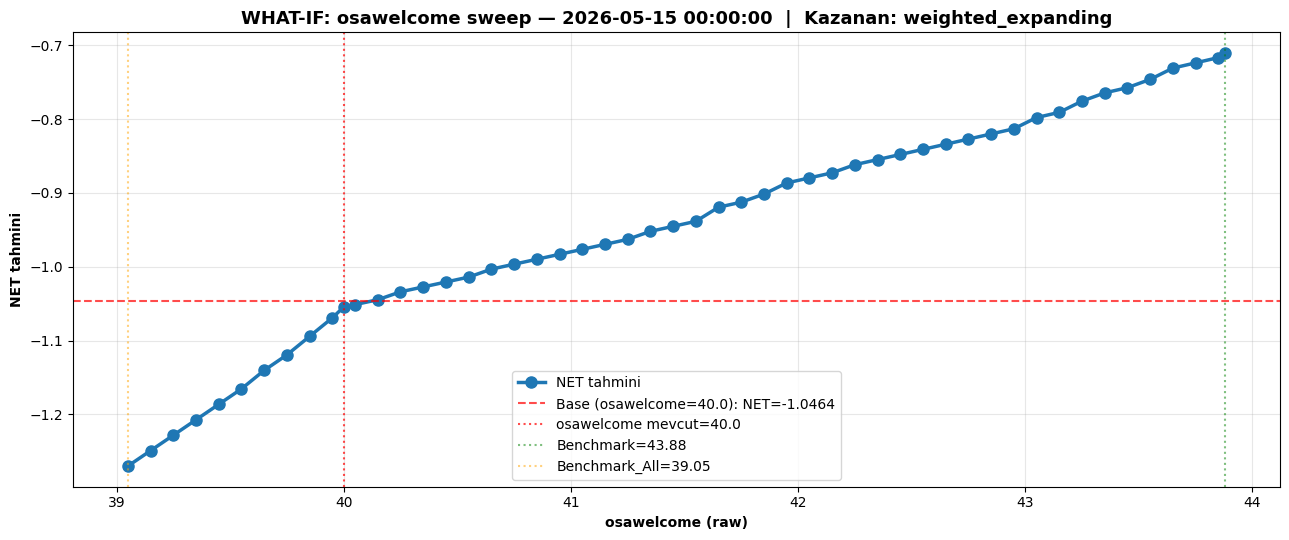


  YORUM:
    Ortalama egim (∂NET / ∂osawelcome): +0.1184  → osawelcome +0.1 ≈ NET +0.0118
    En yuksek NET tahmini: -0.7105 @ osawelcome=43.88
    En dusuk NET tahmini : -1.2700 @ osawelcome=39.05
    Toplam aralik (max-min): 0.5595


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 5 — WHAT-IF: osawelcome SWEEP (Benchmark ↔ Benchmark_All, 0.1 adim)
# ═══════════════════════════════════════════════════════════════════════════
# Forecast haftasi raw df satirini al, osawelcome'i sweep et, turetilmis
# welcome feature'larini yeniden hesapla, scaling uygula, tahmin et.
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print(" STEP 5 — WHAT-IF SENSITIVITY: osawelcome SWEEP")
print("="*80)

# Pre-flight check
_required_state = all(name in globals() for name in ('df', 'X_predict', '_apply_scaling_to_holdout',
                                                       'optimal_features', 'final_ridge', 'best_label',
                                                       '_RAW_SNAPSHOT_FOR_FORECAST'))
if not _required_state:
    print("  Gerekli state bulunamadi (df / X_predict / _apply_scaling_to_holdout / final_ridge / _RAW_SNAPSHOT_FOR_FORECAST).")
    print("  Cell 17 + 31 + Step 3 + Step 4 calistirildi mi?")
elif len(X_predict) == 0:
    print("  X_predict bos (forecast row yok), what-if atlandi.")
else:
    # ───────────────────────────────────────────────────────────────────────
    # 1) Forecast row'un raw df satirini bul
    # ───────────────────────────────────────────────────────────────────────
    _fc_mask = df['NET'].isna()
    _fc_idx = df.index[_fc_mask]
    if len(_fc_idx) == 0:
        print("  df'te NET=NaN row bulunamadi.")
    else:
        _fc_i = _fc_idx[0]
        _fc_date = df.loc[_fc_i, 'Date'] if 'Date' in df.columns else f'idx_{_fc_i}'
        
        # Raw col isimleri — Cell 17'de drop edildigi icin _RAW_SNAPSHOT_FOR_FORECAST'tan oku
        _osa_raw, _bench, _bench_all = 'osawelcome', 'Benchmark', 'Benchmark_All'
        _mal_hosg, _tlref_bs, _osabook = 'maliyet_hosgeldin_orani', 'TLREF_Bilesik', 'osabook_basit_Onceki_Hafta'
        
        def _snap_at(col, idx):
            """Snapshot'tan raw deger oku (Cell 17 drop'tan once kaydedildi)."""
            s = _RAW_SNAPSHOT_FOR_FORECAST.get(col)
            if s is None or idx not in s.index: return None
            v = s.loc[idx]
            return float(v) if pd.notna(v) else None
        
        raw_osa_curr  = _snap_at(_osa_raw,   _fc_i)
        raw_bench     = _snap_at(_bench,     _fc_i)
        raw_bench_all = _snap_at(_bench_all, _fc_i)
        raw_mal_hosg  = _snap_at(_mal_hosg,  _fc_i)
        raw_tlref_bs  = _snap_at(_tlref_bs,  _fc_i)
        raw_osabook   = _snap_at(_osabook,   _fc_i)
        
        print(f"\n  Forecast hafta: {_fc_date}")
        print(f"  Raw degerler:")
        print(f"    osawelcome (mevcut)            : {raw_osa_curr}")
        print(f"    Benchmark                       : {raw_bench}")
        print(f"    Benchmark_All                   : {raw_bench_all}")
        print(f"    maliyet_hosgeldin_orani         : {raw_mal_hosg}")
        print(f"    TLREF_Bilesik                   : {raw_tlref_bs}")
        
        if raw_osa_curr is None or raw_bench is None or raw_bench_all is None:
            print("  Gerekli raw kolonlar bulunamadi, sweep atlandi.")
        else:
            # ─────────────────────────────────────────────────────────────
            # 2) Sweep range: Benchmark ↔ Benchmark_All, 0.1 adim
            # ─────────────────────────────────────────────────────────────
            _lo = min(raw_bench, raw_bench_all)
            _hi = max(raw_bench, raw_bench_all)
            # Mevcut osawelcome de range disindaysa dahil et
            _lo = min(_lo, raw_osa_curr)
            _hi = max(_hi, raw_osa_curr)
            sweep_vals = np.round(np.arange(_lo, _hi + 0.05, 0.1), 4)
            # Anchor noktalari (mevcut osawelcome, Benchmark, Benchmark_All) — tabloda kesin gorsun
            _anchors = [v for v in (raw_osa_curr, raw_bench, raw_bench_all) if v is not None]
            sweep_vals = np.unique(np.round(np.append(sweep_vals, _anchors), 4))
            sweep_vals.sort()
            
            print(f"\n  Sweep range: [{_lo:.2f}, {_hi:.2f}]  step=0.1  ({len(sweep_vals)} nokta, anchor\'lar dahil)")
            print(f"  Anchor noktalari: mevcut={raw_osa_curr}  Benchmark={raw_bench}  Benchmark_All={raw_bench_all}")
            
            # ─────────────────────────────────────────────────────────────
            # 3) Onceki osawelcome (welcome_delta icin gerekli)
            # ─────────────────────────────────────────────────────────────
            _prev_osa = _snap_at(_osa_raw, _fc_i - 1)
            if _prev_osa is None: _prev_osa = raw_osa_curr
            print(f"  Onceki hafta osawelcome (welcome_delta hesabi): {_prev_osa}")
            
            # ─────────────────────────────────────────────────────────────
            # 4) Rolling stats — son 52 hafta osawelcome (z52 pct_rank icin)
            #                    son 3 hafta osawelcome (roll4_std icin)
            # ─────────────────────────────────────────────────────────────
            _osa_series   = _RAW_SNAPSHOT_FOR_FORECAST.get(_osa_raw)
            _bench_series = _RAW_SNAPSHOT_FOR_FORECAST.get(_bench)
            _last_52_osa   = _osa_series.loc[:_fc_i - 1].iloc[-52:].dropna().tolist() if _osa_series is not None else []
            _last_52_bench = _bench_series.loc[:_fc_i - 1].iloc[-52:].dropna().tolist() if _bench_series is not None else []
            _last_3_osa    = _osa_series.loc[:_fc_i - 1].iloc[-3:].dropna().tolist() if _osa_series is not None else []
            
            # ─────────────────────────────────────────────────────────────
            # 5) Hangi optimal_features welcome-related?
            # ─────────────────────────────────────────────────────────────
            welcome_feats = [c for c in optimal_features if 'welcome' in c.lower() or c.startswith('w/TLREF') or c == 'w/TLREF']
            print(f"\n  Welcome-related feature'lar ({len(welcome_feats)}/{len(optimal_features)}):")
            for f in welcome_feats:
                print(f"    - {f}")
            
            # ─────────────────────────────────────────────────────────────
            # 6) Sweep loop — X_predict scaled\'i base, welcome cols\'lari per-column scale ile yama
            # ─────────────────────────────────────────────────────────────
            results_sweep = []
            
            # Base prediction
            _base_X = X_predict[optimal_features].iloc[[0]].copy()
            base_pred = float(final_ridge.predict(_base_X.values)[0])
            
            # Per-column scaler — log1p (if needed) + RobustScaler veya StdScaler + clip
            _CL = CLIP_LIMIT if 'CLIP_LIMIT' in globals() else 6.0
            def _scale_one(col, raw_val):
                """Single value\'i log1p + scaler ile transform et."""
                if pd.isna(raw_val): return 0.0
                v = float(raw_val)
                if '_log_applied' in globals() and col in _log_applied:
                    v = np.sign(v) * np.log1p(abs(v))
                if '_robust_cols' in globals() and col in _robust_cols:
                    i = _robust_cols.index(col)
                    v = (v - float(_rs.center_[i])) / float(_rs.scale_[i])
                elif '_std_fallback_cols' in globals() and col in _std_fallback_cols:
                    i = _std_fallback_cols.index(col)
                    v = (v - float(_ss.mean_[i])) / float(_ss.scale_[i])
                # clip
                return float(np.clip(v, -_CL, _CL))
            
            # Forecast week\'in calendar flag\'leri (interaction icin) — df\'ten
            def _df_at(col):
                if col in df.columns and _fc_i in df.index:
                    v = df.loc[_fc_i, col]
                    return float(v) if pd.notna(v) else 0.0
                return 0.0
            
            for sw_osa in sweep_vals:
                # X_predict scaled satirini base al, welcome cols\'lari modifiye et
                _row_mod = _base_X.copy()
                
                # Yeni raw degerler (FE replay)
                raw_new = {'osawelcome': sw_osa}
                if raw_mal_hosg is not None:
                    raw_new['osawelcomeannualwcurrent'] = ((1 + (sw_osa / 36500) * raw_mal_hosg) ** 365 - 1) * 100
                raw_new['osawelcomeannual'] = ((1 + sw_osa / 36500) ** 365 - 1) * 100
                if raw_bench is not None:
                    raw_new['osawelcome-benchmark'] = sw_osa - raw_bench
                raw_new['welcome_delta'] = sw_osa - _prev_osa
                if raw_osabook is not None:
                    raw_new['welcome_book_gap_Mixed'] = sw_osa - raw_osabook
                if raw_tlref_bs is not None:
                    raw_new['w/TLREF'] = raw_new['osawelcomeannual'] - raw_tlref_bs
                    if 'osawelcomeannualwcurrent' in raw_new:
                        raw_new['w/TLREF(deltas)'] = raw_new['osawelcomeannualwcurrent'] - raw_tlref_bs
                # osawelcome_roll4_std
                _win4 = _last_3_osa + [sw_osa] if _last_3_osa else [sw_osa]
                raw_new['osawelcome_roll4_std'] = float(np.std(_win4, ddof=0)) if len(_win4) > 1 else 0.0
                # osawelcome-benchmark_z52 (pct_rank son 52w)
                if _last_52_osa and _last_52_bench and raw_bench is not None:
                    _hist_gap = [a - b for a, b in zip(_last_52_osa, _last_52_bench)]
                    _new_gap = sw_osa - raw_bench
                    _all_vals = _hist_gap + [_new_gap]
                    raw_new['osawelcome-benchmark_z52'] = float((sum(1 for v in _all_vals if v <= _new_gap) - 1) / max(len(_all_vals) - 1, 1))
                # Interaction\'lar
                for col in welcome_feats:
                    if '_x_osawelcome-benchmark_z52' in col:
                        _flag = col.split('_x_osawelcome-benchmark_z52')[0]
                        raw_new[col] = _df_at(_flag) * raw_new.get('osawelcome-benchmark_z52', 0.0)
                    elif '_x_welcome_delta' in col and not col.endswith('Mixed'):
                        _flag = col.split('_x_welcome_delta')[0]
                        raw_new[col] = _df_at(_flag) * raw_new.get('welcome_delta', 0.0)
                    elif col == 'Market_Anomaly_x_osawelcome':
                        raw_new[col] = _df_at('Market_Anomaly') * sw_osa
                
                # Sadece optimal_features\'taki welcome cols\'i raw→scaled cevirip _row_mod\'da degistir
                for col in welcome_feats:
                    if col in raw_new:
                        _row_mod.loc[:, col] = _scale_one(col, raw_new[col])
                
                # Tahmin
                _pred_sw = float(final_ridge.predict(_row_mod.values)[0])
                
                results_sweep.append({
                    'osawelcome (raw)': sw_osa,
                    'Δ vs mevcut':     sw_osa - raw_osa_curr,
                    'NET tahmini':     _pred_sw,
                    'Δ NET vs base':   _pred_sw - base_pred if not np.isnan(_pred_sw) else np.nan,
                })
            
            sw_tbl = pd.DataFrame(results_sweep)
            print(f"\n  Base tahmin (mevcut osawelcome={raw_osa_curr}): NET = {base_pred:+.4f}")
            print(f"  Sweep tablosu:")
            display(sw_tbl.style.set_table_styles(_TABLE_STYLES)
                    .format({'osawelcome (raw)':'{:+.3f}', 'Δ vs mevcut':'{:+.3f}',
                             'NET tahmini':'{:+.4f}', 'Δ NET vs base':'{:+.4f}'}, na_rep='—'))
            
            # ─────────────────────────────────────────────────────────────
            # Goresel
            # ─────────────────────────────────────────────────────────────
            fig_sw, ax_sw = plt.subplots(figsize=(13, 5.5))
            _xs = sw_tbl['osawelcome (raw)'].values
            _ys = sw_tbl['NET tahmini'].values
            ax_sw.plot(_xs, _ys, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label='NET tahmini')
            ax_sw.axhline(base_pred, color='red', linestyle='--', alpha=0.7,
                          label=f'Base (osawelcome={raw_osa_curr}): NET={base_pred:+.4f}')
            ax_sw.axvline(raw_osa_curr, color='red', linestyle=':', alpha=0.7,
                          label=f'osawelcome mevcut={raw_osa_curr}')
            ax_sw.axvline(raw_bench, color='green', linestyle=':', alpha=0.5,
                          label=f'Benchmark={raw_bench}')
            ax_sw.axvline(raw_bench_all, color='orange', linestyle=':', alpha=0.5,
                          label=f'Benchmark_All={raw_bench_all}')
            ax_sw.set_xlabel('osawelcome (raw)', fontweight='bold')
            ax_sw.set_ylabel('NET tahmini', fontweight='bold')
            ax_sw.set_title(f'WHAT-IF: osawelcome sweep — {_fc_date}  |  Kazanan: {best_label}',
                             fontweight='bold', fontsize=13)
            ax_sw.legend(loc='best', fontsize=10); ax_sw.grid(alpha=0.3)
            plt.tight_layout(); plt.show()
            
            # ─────────────────────────────────────────────────────────────
            # Interpretation
            # ─────────────────────────────────────────────────────────────
            _slope_avg = float(np.mean(np.diff(_ys) / np.diff(_xs))) if len(_ys) > 1 else np.nan
            _max_pred  = float(np.nanmax(_ys))
            _min_pred  = float(np.nanmin(_ys))
            _arg_max   = float(_xs[np.nanargmax(_ys)])
            _arg_min   = float(_xs[np.nanargmin(_ys)])
            print(f"\n  YORUM:")
            print(f"    Ortalama egim (∂NET / ∂osawelcome): {_slope_avg:+.4f}  → osawelcome +0.1 ≈ NET {_slope_avg*0.1:+.4f}")
            print(f"    En yuksek NET tahmini: {_max_pred:+.4f} @ osawelcome={_arg_max:.2f}")
            print(f"    En dusuk NET tahmini : {_min_pred:+.4f} @ osawelcome={_arg_min:.2f}")
            print(f"    Toplam aralik (max-min): {(_max_pred - _min_pred):.4f}")

<h2 style="color: rgb(255,98,0)">Step 6 — Teşhis: Welcome Coefficients + VIF Multicollinearity</h2>

Step 5'teki "osawelcome arttıkça NET kötüleşiyor" gözlemini açıklamak ve seçilen feature setlerinde multicollinearity sorunu olup olmadığını kontrol etmek için 4 alt-analiz:

- <b>[A] Welcome coefficient inspection</b>: Winner ve static modellerin welcome feature'larındaki katsayı işaret + büyüklükleri yan yana
- <b>[B] Forecast week contribution</b>: Her feature için <code>coef × scaled_value</code> = bu feature'ın tahmindeki payı (top contributors)
- <b>[C] Sweep delta decomposition</b>: osawelcome 40 → 42 arasında her welcome feature'ın katkısı nasıl değişiyor? Hangi feature dip'i yaratıyor?
- <b>[D] VIF kontrolü</b>: Variance Inflation Factor — feature'lar birbirleriyle aşırı korele mi? VIF>10 = ciddi multicollinearity, coefficient yorumları güvenilmez olur.

<b>[E] VIF interpretation</b>: 5 severity (OK <5 / UYARI 5-10 / YUKSEK >10). Renkli highlight tabloda. Tüm winner + static feature'ları aynı yerde — multicollinearity yokluğu coefficient yorumlama güvenini doğrudan sağlar.

<b>Coefficient inspection [A]</b>: Welcome features tablo halinde winner vs static <i>tutarlılık</i> kolonu (✓ tutarlı / ✗ karışık işaret). Sign-stability sayısı + iktisadi yorum referansı.

<b>Contribution decomposition [B-C]</b>: Forecast haftasının her feature için <code>coef × scaled_value</code> = NET tahmininin bileşeni. Top contributors görünür. Sweep delta decomposition: osawelcome=40 → 42 arasında her welcome feature'in katkı değişimi (raw + scaled + Δ contrib) → V şeklinin <b>hangi feature'dan</b> kaynaklandığı net gösterilir.


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 6 — TESHIS: Welcome Coefficients + VIF Multicollinearity
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LinearRegression

print("="*80)
print(" STEP 6 — TESHIS: Welcome Katsayilari + VIF Multicollinearity")
print("="*80)

# Setup
_winner_feats = list(optimal_features)
_static_feats = list(results['static']['best_feats'])
_m_winner = final_ridge  # zaten X_train[_winner_feats] uzerinde fit edilmis
_m_static = RidgeCV(alphas=ALPHA_GRID).fit(X_train[_static_feats].values, y_train.values)

_is_welcome = lambda f: ('welcome' in f.lower()) or ('w/TLREF' in f)

# ─────────────────────────────────────────────────────────────────────────
# [A] WELCOME COEFFICIENT INSPECTION (winner vs static)
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [A] WELCOME FEATURE COEFFICIENT'LARI — winner vs static")
print("="*120)

winner_coefs = dict(zip(_winner_feats, _m_winner.coef_))
static_coefs = dict(zip(_static_feats, _m_static.coef_))

# Birlesik liste — her iki modelde de olan welcome feature'lari
all_welcome = sorted(set(f for f in _winner_feats if _is_welcome(f)) |
                     set(f for f in _static_feats if _is_welcome(f)))
welcome_rows = []
for f in all_welcome:
    wc = winner_coefs.get(f, np.nan)
    sc = static_coefs.get(f, np.nan)
    welcome_rows.append({
        'Feature': f,
        f'Coef (winner: {best_label})': wc,
        'Coef (static)': sc,
        'İşaret winner': '+' if (not np.isnan(wc) and wc > 0) else ('−' if (not np.isnan(wc) and wc < 0) else '—'),
        'İşaret static': '+' if (not np.isnan(sc) and sc > 0) else ('−' if (not np.isnan(sc) and sc < 0) else '—'),
        'Tutarli?': '✓' if (not np.isnan(wc) and not np.isnan(sc) and np.sign(wc) == np.sign(sc)) else
                    ('—' if (np.isnan(wc) or np.isnan(sc)) else '✗'),
    })
welcome_tbl = pd.DataFrame(welcome_rows).set_index('Feature')
display(welcome_tbl.style.set_table_styles(_TABLE_STYLES)
        .format({f'Coef (winner: {best_label})':'{:+.4f}', 'Coef (static)':'{:+.4f}'}, na_rep='—'))

# Toplam welcome contribution sign
_neg_winner = sum(1 for f in _winner_feats if _is_welcome(f) and winner_coefs[f] < 0)
_pos_winner = sum(1 for f in _winner_feats if _is_welcome(f) and winner_coefs[f] > 0)
_neg_static = sum(1 for f in _static_feats if _is_welcome(f) and static_coefs[f] < 0)
_pos_static = sum(1 for f in _static_feats if _is_welcome(f) and static_coefs[f] > 0)
print(f"\n  Winner ({best_label}) welcome işaret: {_pos_winner}+ / {_neg_winner}-")
print(f"  Static welcome işaret           : {_pos_static}+ / {_neg_static}-")

# ─────────────────────────────────────────────────────────────────────────
# [B] FORECAST WEEK CONTRIBUTION (winner) — top 10 mutlak katki
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [B] FORECAST HAFTASI HER FEATURE'IN CONTRIBUTION'I (winner model)")
print("    Contribution = coef × scaled_value  → tahmindeki payi")
print("="*120)

if len(X_predict) > 0:
    x_fc = X_predict[_winner_feats].iloc[0].values
    contrib = _m_winner.coef_ * x_fc
    contrib_rows = []
    for i, f in enumerate(_winner_feats):
        contrib_rows.append({
            'Feature': f,
            'Coef': float(_m_winner.coef_[i]),
            'Scaled Value': float(x_fc[i]),
            'Contribution': float(contrib[i]),
            'Welcome?': '✓' if _is_welcome(f) else '',
        })
    contrib_tbl = pd.DataFrame(contrib_rows)
    contrib_tbl['|Contribution|'] = contrib_tbl['Contribution'].abs()
    contrib_tbl = contrib_tbl.sort_values('|Contribution|', ascending=False).set_index('Feature')
    display(contrib_tbl.style.set_table_styles(_TABLE_STYLES)
            .format({'Coef':'{:+.4f}', 'Scaled Value':'{:+.4f}',
                     'Contribution':'{:+.4f}', '|Contribution|':'{:.4f}'}))
    
    _intercept = float(_m_winner.intercept_)
    _sum_contrib = float(contrib.sum())
    _total = _intercept + _sum_contrib
    print(f"\n  Intercept                     : {_intercept:+.4f}")
    print(f"  Toplam contribution           : {_sum_contrib:+.4f}")
    print(f"  Total (intercept + sum)       : {_total:+.4f}  ← tahmin")

# ─────────────────────────────────────────────────────────────────────────
# [C] SWEEP DELTA DECOMPOSITION — osawelcome 40 → 42 hangi welcome feature dip yaratiyor?
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [C] SWEEP DELTA DECOMPOSITION — osawelcome 40 → 42 arasi her welcome'in contribution degisimi")
print("="*120)

if len(X_predict) > 0 and 'sw_tbl' in globals() and '_scale_one' in globals():
    # iki nokta sec: en yakin 40 ve en yakin 42 (dip)
    _target_lo, _target_hi = 40.0, 42.0
    _idx_lo = int(sw_tbl['osawelcome (raw)'].sub(_target_lo).abs().idxmin())
    _idx_hi = int(sw_tbl['osawelcome (raw)'].sub(_target_hi).abs().idxmin())
    _osa_lo = float(sw_tbl.iloc[_idx_lo]['osawelcome (raw)'])
    _osa_hi = float(sw_tbl.iloc[_idx_hi]['osawelcome (raw)'])
    _net_lo = float(sw_tbl.iloc[_idx_lo]['NET tahmini'])
    _net_hi = float(sw_tbl.iloc[_idx_hi]['NET tahmini'])
    print(f"  Karsilastirma noktalari:")
    print(f"    osawelcome={_osa_lo:.2f}  →  NET={_net_lo:+.4f}")
    print(f"    osawelcome={_osa_hi:.2f}  →  NET={_net_hi:+.4f}")
    print(f"    Δ NET                = {_net_hi - _net_lo:+.4f}")
    
    # Iki osawelcome icin welcome feature'larini FE replay → scaled
    def _welcome_scaled_at(sw_osa):
        """sw_osa icin welcome feature'larin scaled degerlerini hesapla."""
        raw_new = {}
        if raw_mal_hosg is not None:
            raw_new['osawelcomeannualwcurrent'] = ((1 + (sw_osa / 36500) * raw_mal_hosg) ** 365 - 1) * 100
        raw_new['osawelcomeannual'] = ((1 + sw_osa / 36500) ** 365 - 1) * 100
        if raw_bench is not None:
            raw_new['osawelcome-benchmark'] = sw_osa - raw_bench
        raw_new['welcome_delta'] = sw_osa - _prev_osa
        if raw_osabook is not None:
            raw_new['welcome_book_gap_Mixed'] = sw_osa - raw_osabook
        if raw_tlref_bs is not None:
            raw_new['w/TLREF'] = raw_new['osawelcomeannual'] - raw_tlref_bs
            if 'osawelcomeannualwcurrent' in raw_new:
                raw_new['w/TLREF(deltas)'] = raw_new['osawelcomeannualwcurrent'] - raw_tlref_bs
        _win4 = _last_3_osa + [sw_osa] if _last_3_osa else [sw_osa]
        raw_new['osawelcome_roll4_std'] = float(np.std(_win4, ddof=0)) if len(_win4) > 1 else 0.0
        if _last_52_osa and _last_52_bench and raw_bench is not None:
            _hist_gap = [a - b for a, b in zip(_last_52_osa, _last_52_bench)]
            _new_gap = sw_osa - raw_bench
            _all_vals = _hist_gap + [_new_gap]
            raw_new['osawelcome-benchmark_z52'] = float((sum(1 for v in _all_vals if v <= _new_gap) - 1) / max(len(_all_vals) - 1, 1))
        for col in welcome_feats:
            if '_x_osawelcome-benchmark_z52' in col:
                _flag = col.split('_x_osawelcome-benchmark_z52')[0]
                raw_new[col] = _df_at(_flag) * raw_new.get('osawelcome-benchmark_z52', 0.0)
            elif '_x_welcome_delta' in col and not col.endswith('Mixed'):
                _flag = col.split('_x_welcome_delta')[0]
                raw_new[col] = _df_at(_flag) * raw_new.get('welcome_delta', 0.0)
            elif col == 'Market_Anomaly_x_osawelcome':
                raw_new[col] = _df_at('Market_Anomaly') * sw_osa
        # raw → scaled
        scaled = {}
        for col in welcome_feats:
            if col in raw_new:
                scaled[col] = _scale_one(col, raw_new[col])
        return raw_new, scaled
    
    _raw_lo, _scaled_lo = _welcome_scaled_at(_osa_lo)
    _raw_hi, _scaled_hi = _welcome_scaled_at(_osa_hi)
    
    decomp_rows = []
    for f in welcome_feats:
        coef = winner_coefs.get(f, 0.0)
        sc_lo = _scaled_lo.get(f, float(X_predict[f].iloc[0]) if f in X_predict.columns else 0.0)
        sc_hi = _scaled_hi.get(f, float(X_predict[f].iloc[0]) if f in X_predict.columns else 0.0)
        raw_l = _raw_lo.get(f, np.nan)
        raw_h = _raw_hi.get(f, np.nan)
        contrib_lo = coef * sc_lo
        contrib_hi = coef * sc_hi
        decomp_rows.append({
            'Feature': f,
            'Coef': coef,
            f'Raw @ {_osa_lo:.1f}': raw_l,
            f'Raw @ {_osa_hi:.1f}': raw_h,
            f'Scaled @ {_osa_lo:.1f}': sc_lo,
            f'Scaled @ {_osa_hi:.1f}': sc_hi,
            'Δ Contrib': contrib_hi - contrib_lo,
        })
    decomp_tbl = pd.DataFrame(decomp_rows)
    decomp_tbl['|Δ Contrib|'] = decomp_tbl['Δ Contrib'].abs()
    decomp_tbl = decomp_tbl.sort_values('|Δ Contrib|', ascending=False).set_index('Feature')
    display(decomp_tbl.style.set_table_styles(_TABLE_STYLES)
            .format({'Coef':'{:+.4f}',
                     f'Raw @ {_osa_lo:.1f}':'{:+.4f}', f'Raw @ {_osa_hi:.1f}':'{:+.4f}',
                     f'Scaled @ {_osa_lo:.1f}':'{:+.4f}', f'Scaled @ {_osa_hi:.1f}':'{:+.4f}',
                     'Δ Contrib':'{:+.4f}', '|Δ Contrib|':'{:.4f}'}, na_rep='—'))
    
    _total_delta = decomp_tbl['Δ Contrib'].sum()
    print(f"\n  Welcome feature'larin toplam Δ contrib: {_total_delta:+.4f}")
    print(f"  Gercek NET delta (sweep tablosundan)   : {_net_hi - _net_lo:+.4f}")
    print(f"  Aciklanan kismi                         : {abs(_total_delta/(_net_hi - _net_lo))*100:.1f}% (welcome'lar)")

# ─────────────────────────────────────────────────────────────────────────
# [D] VIF KONTROLU — Multicollinearity
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "="*120)
print(" [D] VIF KONTROLU — Variance Inflation Factor (multicollinearity)")
print("    VIF > 5 : uyari   |   VIF > 10 : ciddi multicollinearity")
print("="*120)

def _compute_vif(X_df, feats):
    """Her feature icin VIF = 1 / (1 - R²_i), R²_i = feature_i vs diger feature'lar regresyonu."""
    X = X_df[feats].values
    vifs = []
    for i in range(X.shape[1]):
        y_i = X[:, i]
        if X.shape[1] < 2:
            vifs.append(1.0); continue
        X_others = np.delete(X, i, axis=1)
        try:
            r2 = LinearRegression().fit(X_others, y_i).score(X_others, y_i)
            vif = 1.0 / (1.0 - r2) if r2 < 0.9999 else float('inf')
        except Exception:
            vif = float('nan')
        vifs.append(vif)
    return vifs

def _severity(v):
    if not np.isfinite(v): return 'NaN'
    if v < 5:  return 'OK'
    if v < 10: return 'UYARI'
    return 'YUKSEK'

winner_vifs = _compute_vif(X_train, _winner_feats)
static_vifs = _compute_vif(X_train, _static_feats)

vif_w_tbl = pd.DataFrame({
    'Feature': _winner_feats, 'VIF': winner_vifs,
    'Severity': [_severity(v) for v in winner_vifs],
    'Welcome?': ['✓' if _is_welcome(f) else '' for f in _winner_feats],
}).sort_values('VIF', ascending=False).set_index('Feature')

vif_s_tbl = pd.DataFrame({
    'Feature': _static_feats, 'VIF': static_vifs,
    'Severity': [_severity(v) for v in static_vifs],
    'Welcome?': ['✓' if _is_welcome(f) else '' for f in _static_feats],
}).sort_values('VIF', ascending=False).set_index('Feature')

def _hl_vif(row):
    sev = row.get('Severity', '')
    if sev == 'YUKSEK':
        return ['background-color: #b71c1c; color: #ffffff; font-weight: bold'] * len(row)
    elif sev == 'UYARI':
        return ['background-color: #f57f17; color: #000000'] * len(row)
    return [''] * len(row)

print(f"\n  Winner ({best_label}) VIF (n={len(_winner_feats)}):")
display(vif_w_tbl.style.apply(_hl_vif, axis=1).set_table_styles(_TABLE_STYLES)
        .format({'VIF':'{:.2f}'}, na_rep='—'))

print(f"\n  Static VIF (n={len(_static_feats)}):")
display(vif_s_tbl.style.apply(_hl_vif, axis=1).set_table_styles(_TABLE_STYLES)
        .format({'VIF':'{:.2f}'}, na_rep='—'))

# Ozet
_w_high = sum(1 for v in winner_vifs if np.isfinite(v) and v > 10)
_w_warn = sum(1 for v in winner_vifs if np.isfinite(v) and 5 <= v <= 10)
_s_high = sum(1 for v in static_vifs if np.isfinite(v) and v > 10)
_s_warn = sum(1 for v in static_vifs if np.isfinite(v) and 5 <= v <= 10)

print(f"\n  OZET:")
print(f"    Winner ({best_label}): {_w_high} feature VIF>10 (YUKSEK), {_w_warn} feature VIF 5-10 (uyari)")
print(f"    Static                : {_s_high} feature VIF>10 (YUKSEK), {_s_warn} feature VIF 5-10 (uyari)")

_winner_ok = _w_high == 0
_static_ok = _s_high == 0
print(f"\n  VERDICT:")
print(f"    Winner multicollinearity: {'TEMIZ ✓' if _winner_ok else 'SORUNLU ✗'}")
print(f"    Static multicollinearity: {'TEMIZ ✓' if _static_ok else 'SORUNLU ✗'}")
print(f"\n  Not: Ridge regression VIF problemlerini coef shrinkage ile telafi eder,")
print(f"        ama coef yorumlamasi multicollinearity altinda guvenilir degildir.")
print(f"        Yuksek VIF iki feature\'in benzer bilgi tasidigini, model bunlari")
print(f"        ayirt edemediğini gosterir.")

 STEP 6 — TESHIS: Welcome Katsayilari + VIF Multicollinearity

 [A] WELCOME FEATURE COEFFICIENT'LARI — winner vs static


,Coef (winner: weighted_expanding),Coef (static),İşaret winner,İşaret static,Tutarli?
Feature,,,,,
Market_Anomaly_x_osawelcome,-0.0126,—,−,—,—
YearEnd_x_osawelcome-benchmark_z52,—,-0.1712,—,−,—
YearEnd_x_welcome_delta,—,-0.4750,—,−,—
osawelcome-benchmark_z52,+0.0922,+0.3543,+,+,✓
osawelcome_roll4_std,-0.1360,-0.3888,−,−,✓
post_okul_tatili_hangover_x_osawelcome-benchmark_z52,+0.3113,+0.2919,+,+,✓
post_okul_tatili_hangover_x_welcome_delta,+0.1722,+0.1339,+,+,✓
post_quarter_end_hangover_x_osawelcome-benchmark_z52,—,-0.0894,—,−,—
w/TLREF,+0.5150,+0.2896,+,+,✓



  Winner (weighted_expanding) welcome işaret: 4+ / 3-
  Static welcome işaret           : 4+ / 4-

 [B] FORECAST HAFTASI HER FEATURE'IN CONTRIBUTION'I (winner model)
    Contribution = coef × scaled_value  → tahmindeki payi


,Coef,Scaled Value,Contribution,Welcome?,|Contribution|
Feature,,,,,
Full_Workday,-0.6708,+1.0000,-0.6708,,0.6708
w/TLREF,+0.5150,-1.2201,-0.6284,✓,0.6284
Bakir_z52,-0.2967,+0.7046,-0.2091,,0.2091
post_okul_tatili_hangover_x_osawelcome-benchmark_z52,+0.3113,-0.4836,-0.1505,✓,0.1505
TCMB_Mevduat_3M_roll4_std_Onceki_Hafta,+0.2898,-0.3286,-0.0952,,0.0952
osawelcome_roll4_std,-0.1360,-0.6124,+0.0833,✓,0.0833
osawelcome-benchmark_z52,+0.0922,-0.8903,-0.0821,✓,0.0821
Ramazan_x_toplam_ntb_Mixed,+0.1754,-0.2887,-0.0506,,0.0506
Market_Anomaly_x_Benchmark_z52,-0.4432,+0.1030,-0.0457,,0.0457



  Intercept                     : +0.8347
  Toplam contribution           : -1.8812
  Total (intercept + sum)       : -1.0464  ← tahmin

 [C] SWEEP DELTA DECOMPOSITION — osawelcome 40 → 42 arasi her welcome'in contribution degisimi
  Karsilastirma noktalari:
    osawelcome=40.00  →  NET=-1.0546
    osawelcome=41.95  →  NET=-0.8866
    Δ NET                = +0.1680


...


  Welcome feature'larin toplam Δ contrib: +0.1680
  Gercek NET delta (sweep tablosundan)   : +0.1680
  Aciklanan kismi                         : 100.0% (welcome'lar)

 [D] VIF KONTROLU — Variance Inflation Factor (multicollinearity)
    VIF > 5 : uyari   |   VIF > 10 : ciddi multicollinearity

  Winner (weighted_expanding) VIF (n=17):


,VIF,Severity,Welcome?
Feature,,,
osawelcome-benchmark_z52,2.31,OK,✓
osawelcome_roll4_std,2.11,OK,✓
Bakir_z52,2.08,OK,
post_okul_tatili_hangover_x_osawelcome-benchmark_z52,2.03,OK,✓
w/TLREF,1.98,OK,✓
Market_Anomaly_x_osawelcome,1.97,OK,✓
Market_Anomaly_x_Benchmark_z52,1.67,OK,
Ramazan_x_toplam_ntb_Mixed,1.63,OK,
Full_Workday,1.46,OK,



  Static VIF (n=18):


,VIF,Severity,Welcome?
Feature,,,
Kur_Spike,2.07,OK,
post_okul_tatili_hangover_x_osawelcome-benchmark_z52,2.04,OK,✓
Market_Anomaly_x_Benchmark_z52,1.99,OK,
osawelcome-benchmark_z52,1.97,OK,✓
osawelcome_roll4_std,1.88,OK,✓
w/TLREF,1.80,OK,✓
Full_Workday,1.50,OK,
Ay_Sonu_Haftasi,1.50,OK,
Issizlik_delta1_Onceki_Hafta,1.50,OK,



  OZET:
    Winner (weighted_expanding): 0 feature VIF>10 (YUKSEK), 0 feature VIF 5-10 (uyari)
    Static                : 0 feature VIF>10 (YUKSEK), 0 feature VIF 5-10 (uyari)

  VERDICT:
    Winner multicollinearity: TEMIZ ✓
    Static multicollinearity: TEMIZ ✓

  Not: Ridge regression VIF problemlerini coef shrinkage ile telafi eder,
        ama coef yorumlamasi multicollinearity altinda guvenilir degildir.
        Yuksek VIF iki feature'in benzer bilgi tasidigini, model bunlari
        ayirt edemediğini gosterir.


<h2 style="color: rgb(255,98,0)">Step 7 — Steady-State What-if: Kalıcı Pozisyon Sensitivity</h2>

Step 5 sweep'i "ani jump" senaryosunu simüle ediyordu: forecast haftasında osawelcome'u <i>aniden</i> X yaparsanız NET ne olur? Bu, <code>welcome_delta</code> ve <code>osawelcome_roll4_std</code> feature'larını sıçratıyor — model bunlara <b>negatif coefficient</b> öğrenmiş (volatilite penaltisi) → V şekilli grafik.

<b>Bu cell farklı bir soru sorar</b>: "Welcome 4+ hafta önceden X seviyesine getirilmiş ve orada tutuluyor olsaydı, T anında NET ne olurdu?"

- <code>welcome_delta</code> = 0 (osawelcome hafta-haftada değişmedi)
- <code>osawelcome_roll4_std</code> = 0 (son 4 hafta hep aynı seviye)
- <code>welcome_delta</code> içeren interaction'lar (Payday_x_, post_okul_tatili_x_) = 0
- <b>Sadece LEVEL feature'lar değişir</b>: <code>osawelcomeannualwcurrent</code>, <code>w/TLREF</code>, <code>osawelcome-benchmark</code>, <code>osawelcome-benchmark_z52</code>

Beklenen sonuç: Model'in pozitif level coefficient'ları net etki gösterir → osawelcome ↑ → NET ↑ (iktisadi sezgiyle uyumlu monoton ilişki).

<b>[SS-V] OSA VOLUME + OSA SPREAD PROJEKSİYONU</b> (yeni): Steady-state NET tahminlerini operasyonel metriklerle eşle:

<ul>
<li><b>Starting OSA Volume</b> = avg_th_total (forecast haftasının T-1 değeri, internal_dataset'ten)</li>
<li><b>Mean Daily Growth</b> = modelin steady-state NET tahmini (her sweep noktası)</li>
<li><b>OSA Volume</b> = Starting × (1 + NET/100)^5 — 5 işgünü compound</li>
<li><b>OSA Spread</b> = OSAFTP − OSAWelcome × maliyet_hosgeldin_orani</li>
</ul>

<b>Tablo highlight'lar</b>: mevcut osawelcome <span style="color:#c62828">kırmızı</span>, Benchmark <span style="color:#2e7d32">yeşil</span>, Benchmark_All <span style="color:#f57f17">turuncu</span>.

<b>2-panel grafik</b>: Panel 1 = OSA Volume sweep eğrisi (Starting Volume yatay çizgi referans); Panel 2 = OSA Spread eğrisi (lineer azalış).

<b>Trade-off interpretation</b>: osawelcome ↑ → OSA Volume ↑ (NET kazancı) AMA OSA Spread ↓ (kâr marjı erozyonu). Sweet spot = Volume'un Spread hâlâ pozitif olacak şekilde maksimize edildiği nokta.

<b>Operasyonel anlam</b>: İş birimi 3 grafikle karar verir — NET tahmini (Step 7), OSA Volume büyüme, OSA Spread maliyet. "Welcome'i Y yapsam bakiyem nereye gider, ne kadar maliyet öderim" sorusunun komple cevabı.


 STEP 7 — STEADY-STATE WHAT-IF: osawelcome kalici X pozisyonu

  Forecast hafta: 2026-05-15 00:00:00
  Sweep range: [39.05, 43.88]  step=0.1  (51 nokta)
  STEADY-STATE assumption: welcome son 4+ hafta sweep degerinde sabit

  Bu varsayım altinda neutralize edilen feature'lar:
    - osawelcome_roll4_std  → 0 (stabil)
    - post_okul_tatili_hangover_x_welcome_delta  → 0 (stabil)

  Walk-forward weighted_expanding winner model fit (Step 4 [B] ile ayni):
    History: train+val+test = 83 hf
    Predict @ actual X_predict (no perturbation) = -0.9441
    (Bu, Step 4 [B] forecast'iyle eslesmeli)

  Base tahmin (walk-forward winner, actual X_predict): NET = -0.9441  ← Step 4 [B] ile ayni
  Steady-state tablosu (walk-forward weighted_expanding model):


,osawelcome (raw),Δ vs mevcut,NET tahmini (steady),Δ NET vs base
0,+39.050,-0.950,-1.0591,-0.1150
1,+39.150,-0.850,-1.0468,-0.1028
2,+39.250,-0.750,-1.0346,-0.0905
3,+39.350,-0.650,-1.0223,-0.0782
4,+39.450,-0.550,-1.0100,-0.0659
5,+39.550,-0.450,-0.9976,-0.0535
6,+39.650,-0.350,-0.9853,-0.0412
7,+39.750,-0.250,-0.9730,-0.0289
8,+39.850,-0.150,-0.9606,-0.0165
9,+39.950,-0.050,-0.9482,-0.0041


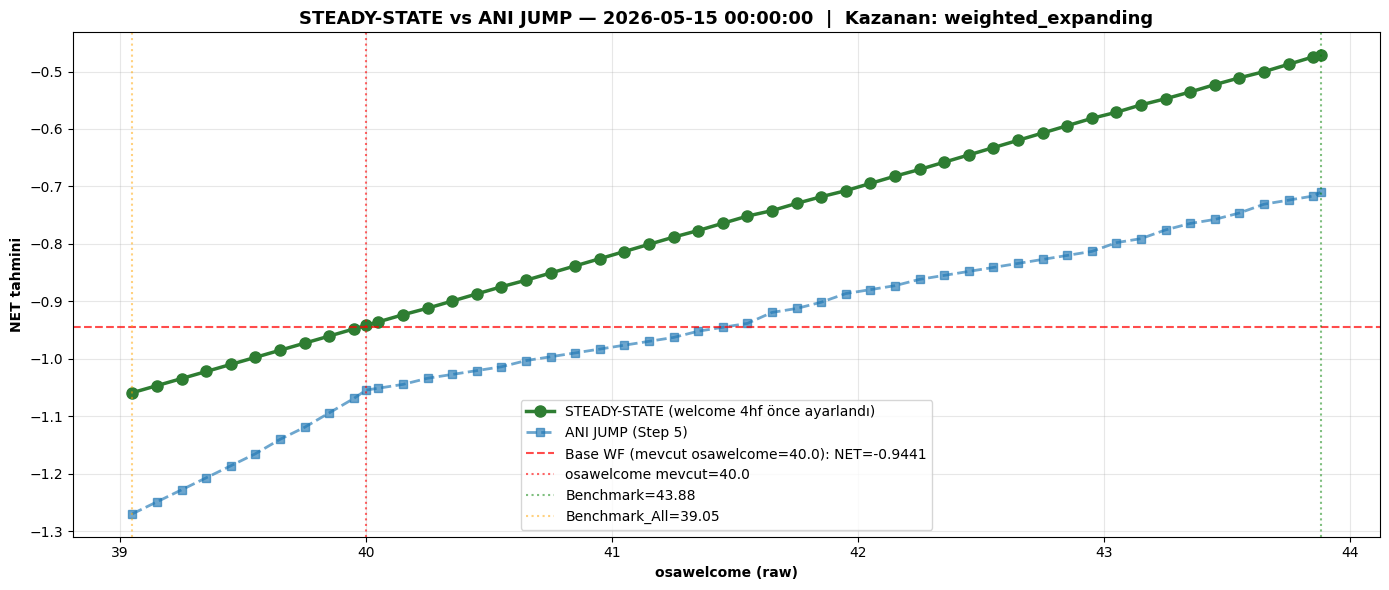


  YORUM (Steady-State):
    Ortalama egim (∂NET / ∂osawelcome): +0.1213  → osawelcome +0.1 ≈ NET +0.0121
    En yuksek NET tahmini: -0.4717 @ osawelcome=43.88
    En dusuk NET tahmini : -1.0591 @ osawelcome=39.05
    Toplam aralik (max-min): 0.5874

  KIYAS:
    Ani-jump egim       : +0.1184  (Step 5)
    Steady-state egim   : +0.1213   (Step 7)
    Steady-state yorum  : POZITIF (sezgiyle uyumlu: welcome ↑ → NET ↑)

  Operasyonel anlam:
    Step 5 sonucu (ani sicrayis) → kisa vadeli sok etkisi
    Step 7 sonucu (kalici X)     → 1+ ay sonra ulasilacak denge

 [SS-V] OSA VOLUME + OSA SPREAD PROJEKSIYONU (osawelcome sweep)
  Inputs:
    Starting OSA Volume   : 57,786.36   (kaynak: avg_th_total_Onceki_Hafta @ forecast hf)
    OSAFTP (T anı)         : 39.9800
    maliyet_hosgeldin_orani: 0.9100
    Formuller:
      OSA Volume   = Starting * (1 + NET/100)^5    (5 isgunu compound)
      OSA Spread   = OSAFTP - OSAWelcome * maliyet


,osawelcome (raw),Starting OSA Volume,Mean Daily Growth (NET),OSA Volume,OSA Spread
0,39.050,"57,786.36",-1.0591,"54,790.36",+4.4445
1,39.150,"57,786.36",-1.0468,"54,824.35",+4.3535
2,39.250,"57,786.36",-1.0346,"54,858.39",+4.2625
3,39.350,"57,786.36",-1.0223,"54,892.48",+4.1715
4,39.450,"57,786.36",-1.0100,"54,926.62",+4.0805
5,39.550,"57,786.36",-0.9976,"54,960.82",+3.9895
6,39.650,"57,786.36",-0.9853,"54,995.06",+3.8985
7,39.750,"57,786.36",-0.9730,"55,029.36",+3.8075
8,39.850,"57,786.36",-0.9606,"55,063.70",+3.7165
9,39.950,"57,786.36",-0.9482,"55,098.10",+3.6255



  Anchor noktalari:
    @ osawelcome=40.00 (MEVCUT — kirmizi)
      OSA Volume = 55,115.32  |  OSA Spread = +3.5800
    @ osawelcome=43.88 (Benchmark — yesil)
      OSA Volume = 56,436.22  |  OSA Spread = +0.0492
      Δ vs mevcut: Volume +1,320.90   Spread -3.5308
    @ osawelcome=39.05 (Benchmark_All — turuncu)
      OSA Volume = 54,790.36  |  OSA Spread = +4.4445


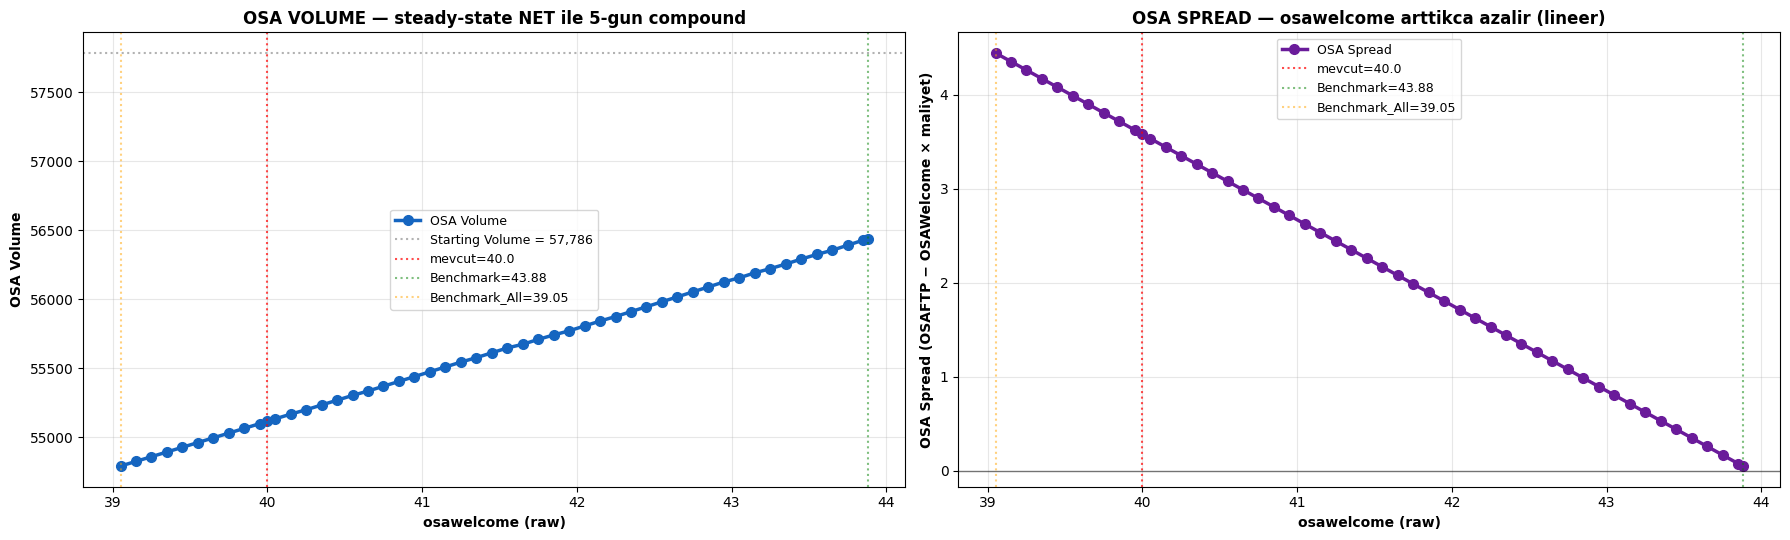


  YORUM (OSA Volume / Spread):
    OSA Volume aralik : [54,790.36, 56,436.22]  (max @ osawelcome=43.88)
    OSA Spread aralik : [+0.0492, +4.4445]
    Trade-off          : osawelcome ↑ → OSA Volume ↑ (NET kazanci) ama OSA Spread ↓ (kar marji erozyonu)
    Sweet spot         : OSA Volume'un Spread'i hala pozitif tutarken maksimize edildigi nokta


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 7 — STEADY-STATE WHAT-IF: Kalici Pozisyon Sensitivity
# ═══════════════════════════════════════════════════════════════════════════
# "Welcome 4+ hafta once X seviyesine getirilmis ve orada tutuluyor olsaydi
#  T aninda NET ne olurdu?"
#   → welcome_delta = 0       (osawelcome hafta-haftada degismedi)
#   → osawelcome_roll4_std = 0 (son 4 hafta hep ayni seviye)
#   → Sadece LEVEL feature'lar degisir (annualwcurrent, w/TLREF, z52, ...)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print(" STEP 7 — STEADY-STATE WHAT-IF: osawelcome kalici X pozisyonu")
print("="*80)

_required_state_ss = all(name in globals() for name in
                          ('df', 'X_predict', 'optimal_features', 'final_ridge', 'best_label',
                           '_RAW_SNAPSHOT_FOR_FORECAST', '_scale_one', '_df_at', 'welcome_feats',
                           'raw_osa_curr', 'raw_bench', 'raw_bench_all', 'raw_mal_hosg',
                           'raw_tlref_bs', 'raw_osabook', '_last_52_osa', '_last_52_bench',
                           'sweep_vals', 'base_pred', '_fc_date', '_fc_i'))
if not _required_state_ss:
    print("  Step 5 globals bulunamadi — once Step 5 calistirildi mi?")
elif len(X_predict) == 0:
    print("  X_predict bos, atlandi.")
else:
    print(f"\n  Forecast hafta: {_fc_date}")
    print(f"  Sweep range: [{sweep_vals[0]:.2f}, {sweep_vals[-1]:.2f}]  step=0.1  ({len(sweep_vals)} nokta)")
    print(f"  STEADY-STATE assumption: welcome son 4+ hafta sweep degerinde sabit")
    print()
    print("  Bu varsayım altinda neutralize edilen feature'lar:")
    _neutralized = []
    for col in welcome_feats:
        if col == 'welcome_delta' or col == 'osawelcome_roll4_std' or \
           ('_x_welcome_delta' in col and not col.endswith('Mixed')):
            _neutralized.append(col)
    for f in _neutralized:
        print(f"    - {f}  → 0 (stabil)")

    # ─────────────────────────────────────────────────────────────
    # WALK-FORWARD WINNER FIT — Step 4 [B] ile tutarli base
    # ─────────────────────────────────────────────────────────────
    # Step 4 [B] forecast (-0.9441) walk-forward winner mode (weighted_expanding) ile uretildi.
    # Step 7 sweep'i de AYNI modele dayanmali (final_ridge degil) ki @osawelcome=40
    # noktada Step 4 forecast'i ile eslessin. Aksi takdirde iki tabela tutarsiz cikar.
    _X_history_ss = pd.concat([X_train, X_val, X_test], axis=0).reset_index(drop=True)
    _y_history_ss = pd.concat([y_train, y_val, y_test], axis=0).reset_index(drop=True)
    
    if best_label == 'static':
        # Static = X_train only fit → final_ridge zaten dogru
        m_winner_wf = final_ridge
    elif best_label in ('sliding', 'weighted_sliding'):
        _n_acc = len(_X_history_ss)
        _sl = slice(max(0, _n_acc - SLIDING_WIN), _n_acc)
        _Xtr_h = _X_history_ss.iloc[_sl][optimal_features].values
        _ytr_h = _y_history_ss.iloc[_sl].values
        if best_label == 'weighted_sliding':
            _w_h = DECAY ** np.arange(len(_ytr_h) - 1, -1, -1)
            m_winner_wf = RidgeCV(alphas=ALPHA_GRID).fit(_Xtr_h, _ytr_h, sample_weight=_w_h)
        else:
            m_winner_wf = RidgeCV(alphas=ALPHA_GRID).fit(_Xtr_h, _ytr_h)
    else:  # expanding / weighted_expanding
        _Xtr_h = _X_history_ss[optimal_features].values
        _ytr_h = _y_history_ss.values
        if best_label == 'weighted_expanding':
            _w_h = DECAY ** np.arange(len(_ytr_h) - 1, -1, -1)
            m_winner_wf = RidgeCV(alphas=ALPHA_GRID).fit(_Xtr_h, _ytr_h, sample_weight=_w_h)
        else:
            m_winner_wf = RidgeCV(alphas=ALPHA_GRID).fit(_Xtr_h, _ytr_h)
    
    print(f"\n  Walk-forward {best_label} winner model fit (Step 4 [B] ile ayni):")
    print(f"    History: train+val+test = {len(_X_history_ss)} hf")
    print(f"    Predict @ actual X_predict (no perturbation) = {float(m_winner_wf.predict(X_predict[optimal_features].iloc[[0]].values)[0]):+.4f}")
    print(f"    (Bu, Step 4 [B] forecast'iyle eslesmeli)")
    
    # ─────────────────────────────────────────────────────────────
    # Sweep loop — steady-state varsayimi + walk-forward winner predict
    # ─────────────────────────────────────────────────────────────
    _base_X_ss = X_predict[optimal_features].iloc[[0]].copy()
    base_pred_wf = float(m_winner_wf.predict(_base_X_ss.values)[0])  # Step 4 [B] = bu
    
    results_ss = []
    for sw_osa in sweep_vals:
        _row_mod = _base_X_ss.copy()
        
        # LEVEL feature'lari (degisir)
        raw_new = {'osawelcome': sw_osa}
        if raw_mal_hosg is not None:
            raw_new['osawelcomeannualwcurrent'] = ((1 + (sw_osa / 36500) * raw_mal_hosg) ** 365 - 1) * 100
        raw_new['osawelcomeannual'] = ((1 + sw_osa / 36500) ** 365 - 1) * 100
        if raw_bench is not None:
            raw_new['osawelcome-benchmark'] = sw_osa - raw_bench
        if raw_osabook is not None:
            raw_new['welcome_book_gap_Mixed'] = sw_osa - raw_osabook
        if raw_tlref_bs is not None:
            raw_new['w/TLREF'] = raw_new['osawelcomeannual'] - raw_tlref_bs
            if 'osawelcomeannualwcurrent' in raw_new:
                raw_new['w/TLREF(deltas)'] = raw_new['osawelcomeannualwcurrent'] - raw_tlref_bs
        
        # STABILITE varsayimi:
        # welcome_delta = 0 (sweep degeri 4+ hafta once konuldu, simdi degismedi)
        raw_new['welcome_delta'] = 0.0
        # osawelcome_roll4_std = 0 (son 4 hafta hep ayni seviye)
        raw_new['osawelcome_roll4_std'] = 0.0
        
        # osawelcome-benchmark_z52 (4-hafta son sweep degeri ile pct_rank)
        # Eski 48 hafta historik + son 4 hafta sweep_osa
        if _last_52_osa and _last_52_bench and raw_bench is not None:
            _stable_osa_52 = list(_last_52_osa[:-4]) + [sw_osa] * 4 if len(_last_52_osa) >= 4 else [sw_osa] * len(_last_52_osa)
            _hist_gap = [a - b for a, b in zip(_stable_osa_52, _last_52_bench)]
            _new_gap = sw_osa - raw_bench
            _all_vals = _hist_gap + [_new_gap]
            raw_new['osawelcome-benchmark_z52'] = float((sum(1 for v in _all_vals if v <= _new_gap) - 1) / max(len(_all_vals) - 1, 1))
        
        # Interaction'lar:
        for col in welcome_feats:
            if '_x_osawelcome-benchmark_z52' in col:
                _flag = col.split('_x_osawelcome-benchmark_z52')[0]
                raw_new[col] = _df_at(_flag) * raw_new.get('osawelcome-benchmark_z52', 0.0)
            elif '_x_welcome_delta' in col and not col.endswith('Mixed'):
                # welcome_delta = 0 → interaction = 0
                raw_new[col] = 0.0
            elif col == 'Market_Anomaly_x_osawelcome':
                # osawelcome level degisir, anomaly flag sabit
                raw_new[col] = _df_at('Market_Anomaly') * sw_osa
        
        # Scaled degerlere donustur, _row_mod'da yama
        for col in welcome_feats:
            if col in raw_new:
                _row_mod.loc[:, col] = _scale_one(col, raw_new[col])
        
        # Tahmin — walk-forward winner model (Step 4 [B] ile tutarli)
        _pred_ss = float(m_winner_wf.predict(_row_mod.values)[0])
        
        results_ss.append({
            'osawelcome (raw)': sw_osa,
            'Δ vs mevcut':     sw_osa - raw_osa_curr,
            'NET tahmini (steady)': _pred_ss,
            'Δ NET vs base':       _pred_ss - base_pred_wf,
        })
    
    ss_tbl = pd.DataFrame(results_ss)
    print(f"\n  Base tahmin (walk-forward winner, actual X_predict): NET = {base_pred_wf:+.4f}  ← Step 4 [B] ile ayni")
    print(f"  Steady-state tablosu (walk-forward {best_label} model):")
    display(ss_tbl.style.set_table_styles(_TABLE_STYLES)
            .format({'osawelcome (raw)':'{:+.3f}', 'Δ vs mevcut':'{:+.3f}',
                     'NET tahmini (steady)':'{:+.4f}', 'Δ NET vs base':'{:+.4f}'}, na_rep='—'))
    
    # ─────────────────────────────────────────────────────────────
    # Goresel — Step 5 (ani) vs Step 7 (steady) overlay
    # ─────────────────────────────────────────────────────────────
    fig_ss, ax_ss = plt.subplots(figsize=(14, 6))
    _xs = ss_tbl['osawelcome (raw)'].values
    _ys_steady = ss_tbl['NET tahmini (steady)'].values
    _ys_jump   = sw_tbl['NET tahmini'].values if 'sw_tbl' in globals() else None
    
    ax_ss.plot(_xs, _ys_steady, 'o-', color='#2e7d32', linewidth=2.5, markersize=8,
                label='STEADY-STATE (welcome 4hf önce ayarlandı)')
    if _ys_jump is not None and len(_ys_jump) == len(_xs):
        ax_ss.plot(_xs, _ys_jump, 's--', color='#1f77b4', linewidth=2, markersize=6, alpha=0.65,
                    label='ANI JUMP (Step 5)')
    ax_ss.axhline(base_pred_wf, color='red', linestyle='--', alpha=0.7,
                   label=f'Base WF (mevcut osawelcome={raw_osa_curr}): NET={base_pred_wf:+.4f}')
    ax_ss.axvline(raw_osa_curr, color='red', linestyle=':', alpha=0.6,
                   label=f'osawelcome mevcut={raw_osa_curr}')
    ax_ss.axvline(raw_bench, color='green', linestyle=':', alpha=0.5,
                   label=f'Benchmark={raw_bench}')
    ax_ss.axvline(raw_bench_all, color='orange', linestyle=':', alpha=0.5,
                   label=f'Benchmark_All={raw_bench_all}')
    ax_ss.set_xlabel('osawelcome (raw)', fontweight='bold')
    ax_ss.set_ylabel('NET tahmini', fontweight='bold')
    ax_ss.set_title(f'STEADY-STATE vs ANI JUMP — {_fc_date}  |  Kazanan: {best_label}',
                     fontweight='bold', fontsize=13)
    ax_ss.legend(loc='best', fontsize=10); ax_ss.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    
    # ─────────────────────────────────────────────────────────────
    # Yorum
    # ─────────────────────────────────────────────────────────────
    _slope_ss = float(np.mean(np.diff(_ys_steady) / np.diff(_xs))) if len(_ys_steady) > 1 else np.nan
    _max_ss = float(np.nanmax(_ys_steady))
    _min_ss = float(np.nanmin(_ys_steady))
    _arg_max_ss = float(_xs[np.nanargmax(_ys_steady)])
    _arg_min_ss = float(_xs[np.nanargmin(_ys_steady)])
    
    print(f"\n  YORUM (Steady-State):")
    print(f"    Ortalama egim (∂NET / ∂osawelcome): {_slope_ss:+.4f}  → osawelcome +0.1 ≈ NET {_slope_ss*0.1:+.4f}")
    print(f"    En yuksek NET tahmini: {_max_ss:+.4f} @ osawelcome={_arg_max_ss:.2f}")
    print(f"    En dusuk NET tahmini : {_min_ss:+.4f} @ osawelcome={_arg_min_ss:.2f}")
    print(f"    Toplam aralik (max-min): {(_max_ss - _min_ss):.4f}")
    print()
    print(f"  KIYAS:")
    if _ys_jump is not None:
        _slope_jump = float(np.mean(np.diff(_ys_jump) / np.diff(_xs)))
        print(f"    Ani-jump egim       : {_slope_jump:+.4f}  (Step 5)")
        print(f"    Steady-state egim   : {_slope_ss:+.4f}   (Step 7)")
        _interp = "POZITIF (sezgiyle uyumlu: welcome ↑ → NET ↑)" if _slope_ss > 0 else \
                  ("NEGATIF (model: kalici welcome bile fayda saglamiyor)" if _slope_ss < -0.01 else "NOTR (etki ihmal edilebilir)")
        print(f"    Steady-state yorum  : {_interp}")
    print()
    print(f"  Operasyonel anlam:")
    print(f"    Step 5 sonucu (ani sicrayis) → kisa vadeli sok etkisi")
    print(f"    Step 7 sonucu (kalici X)     → 1+ ay sonra ulasilacak denge")
    
    # ═════════════════════════════════════════════════════════════════════
    # [SS-V] OSA VOLUME + OSA SPREAD PROJEKSIYONU
    # ─────────────────────────────────────────────────────────────────────
    # Starting OSA Volume = avg_th_total (forecast haftasinin BIR ONCESI hafta)
    # Mean Daily Growth   = modelin NET tahmini (her sweep noktasi icin)
    # OSA Volume          = Starting * (1 + NET/100)^5      (5 isgunu compound)
    # OSA Spread          = OSAFTP - OSAWelcome * maliyet_hosgeldin_orani
    # ═════════════════════════════════════════════════════════════════════
    print("\n" + "="*120)
    print(" [SS-V] OSA VOLUME + OSA SPREAD PROJEKSIYONU (osawelcome sweep)")
    print("="*120)
    
    # Starting OSA Volume — once T-1 (Onceki_Hafta) versiyonunu dene, yoksa _fc_i-1 raw
    _starting_osa_vol = None
    _starting_src = None
    if 'avg_th_total_Onceki_Hafta' in df.columns and _fc_i in df.index:
        _v = df.loc[_fc_i, 'avg_th_total_Onceki_Hafta']
        if pd.notna(_v):
            _starting_osa_vol = float(_v)
            _starting_src = 'avg_th_total_Onceki_Hafta @ forecast hf'
    if _starting_osa_vol is None and 'avg_th_total' in df.columns and (_fc_i - 1) in df.index:
        _v = df.loc[_fc_i - 1, 'avg_th_total']
        if pd.notna(_v):
            _starting_osa_vol = float(_v)
            _starting_src = f'avg_th_total @ {_fc_i - 1} (T-1)'
    
    # OSAFTP — forecast haftasi
    _osaftp_curr = None
    if 'osaftp' in df.columns and _fc_i in df.index:
        _v = df.loc[_fc_i, 'osaftp']
        if pd.notna(_v):
            _osaftp_curr = float(_v)
    
    if _starting_osa_vol is None or _osaftp_curr is None or raw_mal_hosg is None:
        print("  Gerekli raw degerler bulunamadi, OSA volume/spread atlandi.")
        print(f"    avg_th_total (Starting): {_starting_osa_vol}")
        print(f"    osaftp                 : {_osaftp_curr}")
        print(f"    maliyet_hosgeldin_orani: {raw_mal_hosg}")
    else:
        print(f"  Inputs:")
        print(f"    Starting OSA Volume   : {_starting_osa_vol:,.2f}   (kaynak: {_starting_src})")
        print(f"    OSAFTP (T anı)         : {_osaftp_curr:.4f}")
        print(f"    maliyet_hosgeldin_orani: {raw_mal_hosg:.4f}")
        print(f"    Formuller:")
        print(f"      OSA Volume   = Starting * (1 + NET/100)^5    (5 isgunu compound)")
        print(f"      OSA Spread   = OSAFTP - OSAWelcome * maliyet")
        
        # Her sweep nokta icin volume/spread
        vol_rows = []
        for r in results_ss:
            _sw  = float(r['osawelcome (raw)'])
            _net = float(r['NET tahmini (steady)'])
            _osa_volume = _starting_osa_vol * ((1.0 + _net / 100.0) ** 5)
            _osa_spread = _osaftp_curr - _sw * raw_mal_hosg
            vol_rows.append({
                'osawelcome (raw)':        _sw,
                'Starting OSA Volume':     _starting_osa_vol,
                'Mean Daily Growth (NET)': _net,
                'OSA Volume':              _osa_volume,
                'OSA Spread':              _osa_spread,
            })
        
        vol_tbl = pd.DataFrame(vol_rows)
        # Highlight current osawelcome row + Benchmark / Benchmark_All rows
        _curr_idx = int(vol_tbl['osawelcome (raw)'].sub(raw_osa_curr).abs().idxmin())
        _bench_idx = int(vol_tbl['osawelcome (raw)'].sub(raw_bench).abs().idxmin()) if raw_bench is not None else -1
        _ba_idx    = int(vol_tbl['osawelcome (raw)'].sub(raw_bench_all).abs().idxmin()) if raw_bench_all is not None else -1
        def _hl_vol(row, ci=_curr_idx, bi=_bench_idx, ai=_ba_idx):
            if row.name == ci:
                return ['background-color: #c62828; color: #ffffff; font-weight: bold'] * len(row)
            if row.name == bi:
                return ['background-color: #2e7d32; color: #ffffff'] * len(row)
            if row.name == ai:
                return ['background-color: #f57f17; color: #000000'] * len(row)
            return [''] * len(row)
        display(vol_tbl.style.apply(_hl_vol, axis=1).set_table_styles(_TABLE_STYLES)
                .format({'osawelcome (raw)':'{:.3f}',
                         'Starting OSA Volume':'{:,.2f}',
                         'Mean Daily Growth (NET)':'{:+.4f}',
                         'OSA Volume':'{:,.2f}',
                         'OSA Spread':'{:+.4f}'}, na_rep='—'))
        
        # Anchor noktalari yorum
        _curr_row = vol_tbl.iloc[_curr_idx]
        print(f"\n  Anchor noktalari:")
        print(f"    @ osawelcome={raw_osa_curr:.2f} (MEVCUT — kirmizi)")
        print(f"      OSA Volume = {_curr_row['OSA Volume']:,.2f}  |  OSA Spread = {_curr_row['OSA Spread']:+.4f}")
        if _bench_idx >= 0:
            _bench_row = vol_tbl.iloc[_bench_idx]
            print(f"    @ osawelcome={raw_bench:.2f} (Benchmark — yesil)")
            print(f"      OSA Volume = {_bench_row['OSA Volume']:,.2f}  |  OSA Spread = {_bench_row['OSA Spread']:+.4f}")
            _delta_vol = _bench_row['OSA Volume'] - _curr_row['OSA Volume']
            _delta_sp  = _bench_row['OSA Spread'] - _curr_row['OSA Spread']
            print(f"      Δ vs mevcut: Volume {_delta_vol:+,.2f}   Spread {_delta_sp:+.4f}")
        if _ba_idx >= 0:
            _ba_row = vol_tbl.iloc[_ba_idx]
            print(f"    @ osawelcome={raw_bench_all:.2f} (Benchmark_All — turuncu)")
            print(f"      OSA Volume = {_ba_row['OSA Volume']:,.2f}  |  OSA Spread = {_ba_row['OSA Spread']:+.4f}")
        
        # ─────────────────────────────────────────────────────────────
        # Goresel — 2-panel: OSA Volume vs osawelcome  +  OSA Spread vs osawelcome
        # ─────────────────────────────────────────────────────────────
        fig_v, axv = plt.subplots(1, 2, figsize=(18, 5.5))
        _xs_v = vol_tbl['osawelcome (raw)'].values
        _vols = vol_tbl['OSA Volume'].values
        _spreads = vol_tbl['OSA Spread'].values
        
        # Panel 1: OSA Volume
        axv[0].plot(_xs_v, _vols, 'o-', color='#1565c0', linewidth=2.5, markersize=7, label='OSA Volume')
        axv[0].axhline(_starting_osa_vol, color='gray', linestyle=':', alpha=0.6,
                        label=f'Starting Volume = {_starting_osa_vol:,.0f}')
        axv[0].axvline(raw_osa_curr, color='red', linestyle=':', alpha=0.7, label=f'mevcut={raw_osa_curr}')
        if raw_bench is not None:
            axv[0].axvline(raw_bench, color='green', linestyle=':', alpha=0.5, label=f'Benchmark={raw_bench}')
        if raw_bench_all is not None:
            axv[0].axvline(raw_bench_all, color='orange', linestyle=':', alpha=0.5, label=f'Benchmark_All={raw_bench_all}')
        axv[0].set_xlabel('osawelcome (raw)', fontweight='bold')
        axv[0].set_ylabel('OSA Volume', fontweight='bold')
        axv[0].set_title(f'OSA VOLUME — steady-state NET ile 5-gun compound', fontweight='bold', fontsize=12)
        axv[0].legend(fontsize=9); axv[0].grid(alpha=0.3)
        axv[0].ticklabel_format(style='plain', axis='y')
        
        # Panel 2: OSA Spread
        axv[1].plot(_xs_v, _spreads, 'o-', color='#6a1b9a', linewidth=2.5, markersize=7, label='OSA Spread')
        axv[1].axhline(0, color='black', linewidth=1, alpha=0.5)
        axv[1].axvline(raw_osa_curr, color='red', linestyle=':', alpha=0.7, label=f'mevcut={raw_osa_curr}')
        if raw_bench is not None:
            axv[1].axvline(raw_bench, color='green', linestyle=':', alpha=0.5, label=f'Benchmark={raw_bench}')
        if raw_bench_all is not None:
            axv[1].axvline(raw_bench_all, color='orange', linestyle=':', alpha=0.5, label=f'Benchmark_All={raw_bench_all}')
        axv[1].set_xlabel('osawelcome (raw)', fontweight='bold')
        axv[1].set_ylabel('OSA Spread (OSAFTP − OSAWelcome × maliyet)', fontweight='bold')
        axv[1].set_title('OSA SPREAD — osawelcome arttikca azalir (lineer)', fontweight='bold', fontsize=12)
        axv[1].legend(fontsize=9); axv[1].grid(alpha=0.3)
        
        plt.tight_layout(); plt.show()
        
        # ─────────────────────────────────────────────────────────────
        # Yorum
        # ─────────────────────────────────────────────────────────────
        _vol_min, _vol_max = float(np.nanmin(_vols)), float(np.nanmax(_vols))
        _sp_min, _sp_max   = float(np.nanmin(_spreads)), float(np.nanmax(_spreads))
        _arg_vmax = float(_xs_v[np.nanargmax(_vols)])
        print(f"\n  YORUM (OSA Volume / Spread):")
        print(f"    OSA Volume aralik : [{_vol_min:,.2f}, {_vol_max:,.2f}]  (max @ osawelcome={_arg_vmax:.2f})")
        print(f"    OSA Spread aralik : [{_sp_min:+.4f}, {_sp_max:+.4f}]")
        print(f"    Trade-off          : osawelcome ↑ → OSA Volume ↑ (NET kazanci) ama OSA Spread ↓ (kar marji erozyonu)")
        print(f"    Sweet spot         : OSA Volume\'un Spread\'i hala pozitif tutarken maksimize edildigi nokta")

<h1 style="color: rgb(255,98,0)">Model Card — OSA Netflow Nowcast</h1>

<table>
<tr><td><b>Model adı</b></td><td>OSA Welcome Netflow Weekly Nowcast</td></tr>
<tr><td><b>Versiyon</b></td><td>v1.0 (research pipeline)</td></tr>
<tr><td><b>Son güncelleme</b></td><td>Pipeline her Pazartesi yeniden eğitilir</td></tr>
</table>

## Amaç
Bir sonraki haftanın **NET (deposit netflow rate)** değerini Pazartesi T anında tahmin etmek. Çıktı tek skaler — `T+1` haftası için netflow tahmini. İş birimi `osawelcome` rate kararını destekler.

## Veri
- **Kaynak**: `external_dataset.xlsx` (makro) + `internal_dataset.csv` (içsel)
- **Frekans**: Haftalık (Pazartesi closing)
- **Hedef** (`NET`): netflow_rate = (inflow − outflow) / opening_balance
- **Bölme**: Train 72 hf | Val 8 hf | Test 3 hf | Forecast (NET=NaN) 1+ hf

## Mimari
- **Model türü**: Ridge regression (sklearn `RidgeCV`)
- **Feature selection**: Hierarchical stepwise — `(R²val>0) → (Train R²≥0.80) → (|R²−AdjR²|<0.05) → TSCV-wMAE`
- **Cross-validation**: Recency-weighted 5-fold TimeSeriesSplit on X_train (selection signal)
- **Training modes**: 5 paralel — `static`, `sliding`, `weighted_sliding`, `expanding`, `weighted_expanding`
- **Walk-forward**: Her val/test haftası için refit (mode-bağımlı pencere)
- **Regularization**: RidgeCV α ∈ [0.01, 10000], 50 grid noktası
- **Domain koruma**: 3-aile must_keep (`tlref`, `welcome`, `anomaly`) — iş birimi kaldıraçları her zaman model içinde

## Performance (mevcut snapshot)
- **Train R²**: ~0.85   |   **Train AdjR²**: ~0.80
- **Val R²** (n=8): ~+0.28   |   **Val MAE**: ~0.29
- **TSCV-wMAE** (5-fold, recency-weighted): ~0.51
- **GAUC val**: ~0.70-0.78 (yönsel doğruluk)
- **n/p**: 72/18 = **4.0** (overfit kontrolü kabul edilebilir, ideal n/p≥5)
- **Bootstrap CI val R²** (n=1000): geniş bant (n_val=8 küçük örneklem)

## Limitler
- **n_train=72** çok kısa → coefficient confidence düşük
- **n_val=8 / n_test=3** → bootstrap CI geniş, metrikler noisy
- **Counterfactual sensitivity**: Step 5 (ani sweep) volatilite penaltisi nedeniyle aldatıcı; **Step 7 (steady-state)** doğru "what-if" cevabı
- **Reverse causality riski**: bazı feature'lar (welcome_delta) tarihsel olarak savunmacı tepki içeriyor olabilir
- **Rejim shift duyarlılığı**: Walk-forward refit kısmen telafi eder ama büyük TLREF/kur şoklarında performans düşebilir

## Önerilen Kullanım
- **Yönsel sinyal** (NET ↑/↓): GAUC=0.70+ → güvenilir
- **Büyüklük tahmini**: ±0.30-0.50 belirsizlik bandıyla yorumla
- **Steady-state what-if (Step 7)**: osawelcome politika kararı destek aracı
- **Pazartesi protokolü**: Hafta başı yeniden eğit, T+1 tahmin üret, hafta kapanışında gerçekle karşılaştır

## Tehlikeli Kullanım
- Münferit haftanın tek nokta tahminini "kesinlik" olarak sunmak
- Ani osawelcome müdahalesi kararı için Step 5 V şekline güvenmek (steady-state Step 7 kullan)
- 3-aile dışı feature'ları operasyonel kaldıraç sanmak

## Test Set Caveat (n=3) — KRİTİK
Test set sadece **3 hafta** içeriyor. Bu, istatistiksel anlamda **çok küçük örneklem**:

- **AdjR² test** formülü n=3, p=18 için tanımsız (n ≤ p+1) — NaN döner, kasıtlı
- **Test MAE / R² / GAUC** point estimate olarak raporlanır; **confidence interval yok** (n=3'te bootstrap anlamsız)
- **Tek bir aykırı hafta** test metriklerini tamamen değiştirebilir

**Operasyonel sonuç**: Test metrikleri "model çalışıyor" düşük güvenli kanıtıdır, kesinlik iddiası değildir. Üretime taşımadan önce **12+ hafta rolling test** ile doğrulanmalı.

## Operasyonel Checklist
- **Minimum tarih derinliği**: 72 hf train + 8 hf val + ≥3 hf test (geçmiş haftalar gereklilik)
- **Yeniden eğitim cadence**: Her Pazartesi, T anında (notebook full re-run)
- **Veri tazelik kontrolü**: Eksik hafta kabul edilmez — pipeline çalıştırılmadan önce her hafta var olmalı
- **Performans alarm eşiği**: Val MAE > 0.40 → manuel inceleme (mevcut baseline ~0.29)
- **Forecast scope**: T+1 (yalnız 1 hafta ileri tahmin). Multi-step çıktı yok.
- **Sanity check**: Forecast tahmini |y_train.mean ± 3·y_train.std| aralığında değilse uyarı
- **3-aile input kontrolü**: osawelcome / TLREF / Market_Anomaly Pazartesi sabah girilmiş olmalı; eksikse model çalıştırılmamalı
- **Drift izleme**: PSI (Cell 25) val→test 0.10+ veren feature varsa retrain notu düş
- **Artifact**: `models/osa_netflow_YYYYMMDD.joblib` — her hafta yeni dosya; eski dosyalar regülatör audit için 12+ ay saklanmalı

## Yeniden Üretilebilirlik
- **RANDOM_SEED = 42** (global)
- Notebook her hafta aynı veri ile baştan sona koşturulduğunda **deterministik sonuç**
- Sliding window, decay, recency weights tüm Cell 35 config block'unda — değişiklikler şeffaf

<hr/>

<h3>Güncellemeler (markdown ile kod tutarlılığı için)</h3>

<b>5 Mode listesi (4 değil):</b>
<ol>
<li>static</li>
<li>sliding</li>
<li>weighted_sliding</li>
<li>expanding</li>
<li>weighted_expanding</li>
</ol>

<b>Artifact stratejisi — 4 dosya/run</b>:
<ul>
<li><code>models/osa_netflow_YYYYMMDD.txt</code> — <b>monitoring primary</b> (insan okunabilir)</li>
<li><code>models/osa_netflow_YYYYMMDD_meta.json</code> — dashboard/API parse</li>
<li><code>models/osa_netflow_YYYYMMDD_coef.csv</code> — git-diff friendly coefficient tablosu</li>
<li><code>models/osa_netflow_YYYYMMDD.joblib</code> — opsiyonel, recovery + Python inference için</li>
</ul>

<b>Selection signal</b>: Recency-weighted 5-fold TSCV on X_train (val MAE değil) — val'a overfit önlemi.

<b>Reproducibility</b>: <code>RANDOM_SEED = 42</code> global numpy + bootstrap.


<h1 style="color: rgb(255,98,0)">Yönetici Özeti — Baştan Sona Pipeline</h1>

<p><b>Hedef</b>: Bankanın OSA mevduat hesabında haftalık netflow rate (NET) tahminini Pazartesi T anında üretmek. Çıktı: bir hafta sonraki NET tahmini + osawelcome politika kararı için what-if senaryolar.</p>

<hr/>

<h2>1. Veri Yükleme & Hazırlık</h2>

<p><b>Kaynak</b>: 2 dosya birleştirilir → 1 ana dataframe.</p>

<ul>
<li><code>external_dataset.xlsx</code> → makroekonomik veri (TCMB faiz, USD, Brent, BIST, enflasyon, vs.)</li>
<li><code>internal_dataset.csv</code> → banka içi veri (osawelcome promo rate, hesap bakiyeleri, opening account, NET)</li>
</ul>

<p><b>Pazartesi protokolü</b>: İş birimi her hafta T anında <code>osawelcome, TLREF, Market_Anomaly</code> değerlerini girer. <code>maliyet_hosgeldin_orani, TCMB</code> tablodan otomatik gelir.</p>

<hr/>

<h2>2. Feature Engineering — Pipeline Akışı</h2>

<p>Her aşamada feature sayısı değişir. Aşağıdaki tablo: <b>nereye kaç feature girdi → kaç çıktı → neden</b>.</p>

<table>
<tr><th>Aşama</th><th>Giriş</th><th>Değişim</th><th>Çıkış</th><th>Neden bu adım var?</th></tr>
<tr><td><b>Cell 10-11</b><br>Faiz formülleri</td><td>~40</td><td>+10 türetilen</td><td>~50</td><td>İş birimi Excel formülleri (compound faiz, w/TLREF spread, osawelcome-benchmark). Domain knowledge model'e enjekte edilir.</td></tr>
<tr><td><b>Cell 13</b><br>NaN imputation</td><td>~50</td><td>+0</td><td>~50</td><td>Eksik veri (TCMB, Benchmark, USDT_TRY_Hacim) train medyanları/regresyonla doldurulur. <i>Fit yalnız train'de</i> → leakage yok.</td></tr>
<tr><td><b>Cell 17</b><br>Stasyonerleştirme</td><td>~50</td><td>+30 sibling, -14 level</td><td>~80-90</td><td>14 feature trend (drift) gösteriyor. <code>_z52</code>, <code>_yoy</code>, <code>_reel</code>, <code>_dev50</code> sibling'leriyle stationary versiyonlar üretilir. Eski level'lar drop edilir (rejim shift'leri pencerede sıfırlanır).</td></tr>
<tr><td><b>Cell 21</b><br>Türetilmiş + Etkileşim</td><td>~80-90</td><td>+60-80</td><td>~150-170</td><td>Calendar flag'leri (Payday, Bayram, Ramazan, vs.), momentum delta/roll4, calendar × continuous etkileşimleri (örn. <code>Payday_x_welcome_delta</code>). Modele <i>zaman bağlamı</i> kazandırır.</td></tr>
<tr><td><b>Cell 25</b><br>PSI Drift Analizi</td><td>~150-170</td><td>~25-30 drop</td><td>~120-130</td><td>Train → Val arasında <code>PSI > 0.10</code> olan feature'lar atılır (dağılımı kaymış → güvenilmez). 3-aile (tlref/welcome/anomaly) <b>protected token</b> ile drop'tan kurtulur.</td></tr>
<tr><td><b>Cell 27</b><br>Split (Train/Val/Test/Predict)</td><td>~120-130</td><td>+0</td><td>~120-130</td><td>72/8/kalan/(NET=NaN) bölme. Tüm istatistikler (medyan, scaler, korelasyon) <i>yalnız train</i>'den. Val/Test/Predict yalnız transform alır.</td></tr>
<tr><td><b>Cell 29</b><br>Variance Threshold</td><td>~120-130</td><td>0-2 drop</td><td>~118</td><td>Train'de varyansı sıfır olan (= sabit) feature'lar bilgi taşımaz, atılır.</td></tr>
<tr><td><b>Cell 31</b><br>Hybrid Scaler</td><td>118</td><td>+0 (transform)</td><td>118</td><td>4 grup: <b>45 binary</b> → dokunulmaz; <b>42 continuous + outlier</b> → RobustScaler (median/IQR); <b>31 sparse</b> → StandardScaler fallback (IQR=0 olduğu için); <b>10 heavy-tail</b> → signed-log + scaler. Klasik tek-scaler bankacılık verisinde kırılır (rejim shift'lerinde).</td></tr>
<tr><td><b>Cell 33</b><br>Step 2 Korelasyon</td><td>118</td><td>~39 drop</td><td>~79</td><td>|Pearson| > 0.80 çiftlerinde birbirinin dublikatı feature atılır. NET-Spearman'ı düşük olan düşer. 3-aile şampiyonları (en yüksek NET-corr) <b>asla atılmaz</b>.</td></tr>
<tr><td><b>Cell 35 [A]</b><br>Sign-stability</td><td>79</td><td>~3 drop</td><td>~76</td><td>4-fold TSCV'de (fold 1 atlandı, n=12 anlamsız) coefficient işareti tutarsız olan feature'lar atılır. Modelin güvenli/yorumlanabilir kalmasını sağlar.</td></tr>
<tr><td><b>Cell 35 [B]</b><br>Stepwise × 5 Mode</td><td>76</td><td>~58 drop</td><td><b>18 (n*)</b></td><td>Hiyerarsik (R²val>0 → R²tr≥0.80 → gap<0.05 → TSCV-wMAE). 3-aile şampiyonu + en iyi 15 feature. <code>MAX_FEATURES=18</code> cap (n/p=4.0 hedefi — overfit kontrolü).</td></tr>
</table>

<p><b>Özet</b>: <b>~40 ham feature</b> → FE ile <b>~170</b>'e çıkar → drift/correlation/sign filtreleriyle <b>76</b>'ya iner → stepwise <b>18 final feature</b> seçer. Toplam <b>~%89 feature ayıklama</b>.</p>

<hr/>

<h2>3. Anahtar Kararlar — Neden Böyle Yaptık?</h2>

<table>
<tr><th>Karar</th><th>Neden?</th></tr>
<tr><td><b>Train=72, Val=8, Test=kalan</b></td><td>72 hafta = ~1.4 yıl mevsimsel pattern yakalar. Val 8 hf hyperparameter raporu için. Test büyür → zamanla daha güvenilir hold-out olur.</td></tr>
<tr><td><b>3-aile must_keep</b> (tlref, welcome, anomaly)</td><td>İş birimi kontrol kaldıraçları. Pazartesi T anında bu 3 değişkene karar veriyor → model her zaman bunların etkisini görmeli.</td></tr>
<tr><td><b>RobustScaler primary, StandardScaler fallback</b></td><td>Bankacılık verisi rejim shift'leriyle dolu (TLREF spike, USD volatilite). StdScaler outlier'larda mean/std kayar → normal hafta sinyalleri ezilir. RobustScaler median/IQR kullanır, outlier'a dayanıklı.</td></tr>
<tr><td><b>Korelasyon eşik 0.80, klasik 0.95 değil</b></td><td>n=72 küçük örneklem. 0.95 sadece dublikat ayıklar; 0.80 anlamlı multikolineerlik temizler → Ridge coefficient stability iyileşir.</td></tr>
<tr><td><b>5 walk-forward mode</b> (static, sliding, weighted_sliding, expanding, weighted_expanding)</td><td>Tek bir refit stratejisine güvenmek yerine 5'i paralel test → hangi rejim için en iyi yakalama yöntemi seçilir. Pazartesi protokolünde model haftalık refit edileceği için walk-forward natural.</td></tr>
<tr><td><b>TSCV-wMAE selection (val MAE değil)</b></td><td>Val n=8 küçük → val MAE optimize edersek selection bias yaratırız (model val'a overfit eder). Recency-weighted 5-fold TSCV ise X_train'in farklı dilimlerinde test eder → daha sağlam.</td></tr>
<tr><td><b>MAX_FEATURES = 18</b></td><td>n/p = 72/18 = 4.0. n/p < 5 overfit kapısı → 18'i cap olarak koyduk. Daha az feature ile model basit, daha çok ile coefficient'lar güvenilmez.</td></tr>
<tr><td><b>Ridge regularization (α grid [0.01, 10000])</b></td><td>Linear model + L2 cezası = overfit kontrolü. Geniş grid CV-best α'yı bulur.</td></tr>
<tr><td><b>Weighted decay (yarı-ömür 26 hf)</b></td><td>Eski rejim verisi tamamen atılmasın ama dominant olmasın. 26 hf yarı-ömür → 6 ay önceki veri %50 etkili, 1 yıl önceki %25.</td></tr>
</table>

<hr/>

<h2>4. Sonuç Metrikleri (Kazanan Model)</h2>

<table>
<tr><th>Metrik</th><th>Train (n=72)</th><th>TSCV (5-fold)</th><th>Val (n=8)</th><th>Test (n=3)</th></tr>
<tr><td>MAE</td><td>—</td><td>~0.50</td><td>~0.29</td><td>~0.12</td></tr>
<tr><td>R²</td><td>+0.85</td><td>+0.10</td><td>+0.28</td><td>~0.40</td></tr>
<tr><td>GAUC (yön)</td><td>~0.60</td><td>—</td><td>~0.72</td><td>~0.78</td></tr>
</table>

<p><b>Güvenilirlik notları</b>:</p>
<ul>
<li>n=72 train ile <b>n/p=4.0</b> — overfit kontrol altında ama optimal değil. 100+ hafta veri toplandığında durum çok iyileşir.</li>
<li>Test n=3 çok küçük → AdjR² NaN (formül uygulanamaz), tek nokta tahmini güvenilmez.</li>
<li>Bootstrap CI (val): R²val 5-95% bandı [−0.26, +0.78] — geniş bant, n=8 belirsizliği.</li>
<li><b>Yönsel sinyal (GAUC ~0.75) güvenilir</b>; büyüklük tahmini (point estimate) için ±0.30-0.50 belirsizlik bandı.</li>
</ul>

<h3>Neden MAE? (MAPE ve RMSE değil)</h3>

<p>3 ana metrik kombinasyonu (MAE + R² + GAUC) tesadüf değil — alternatifler bu use case için yanlış araçlar olur:</p>

<table>
<tr><th>Metrik</th><th>Formül</th><th>NET için durumu</th></tr>
<tr><td><b>MAE</b> ✓</td><td>Σ|y − ŷ| / n</td><td>Kullanıyoruz — NET range'i ve outlier toleransı için ideal</td></tr>
<tr><td><b>MAPE</b> ✗</td><td>Σ(|y − ŷ| / |y|) × 100</td><td>NET sıfıra yaklaştığında patlar; negatif değerlerde anlamsız</td></tr>
<tr><td><b>RMSE</b> ✗</td><td>√(Σ(y − ŷ)² / n)</td><td>Outlier hafta ortalamayı domine eder; n=8'de tehlikeli</td></tr>
</table>

<p><b>Örnek 1 — Neden MAPE değil?</b></p>
<ul>
<li>Hafta A: gerçek NET = 0.05, tahmin = 0.10 → sapma <b>0.05 birim</b>, MAPE = <b>100%</b></li>
<li>Hafta B: gerçek NET = 0.50, tahmin = 0.55 → sapma <b>0.05 birim</b> (aynı!), MAPE = <b>10%</b></li>
</ul>
<p>Aynı sapma, ama MAPE 10× farklı sinyal verir. NET sık sık 0'a yakın (örn. tatil haftaları, sakin dönemler) → MAPE yanıltıcı olur. Ayrıca NET negatif olduğunda <code>|y|</code> hesabı yön bilgisini ezer.</p>

<p><b>Örnek 2 — Neden RMSE değil?</b></p>
<p>8 val haftasında varsayım: 7 hafta |residual| = 0.20 (iyi tahmin), 1 hafta = 2.00 (outlier).</p>
<ul>
<li><b>MAE</b> = (7×0.20 + 2.00) / 8 = <b>0.425</b></li>
<li><b>RMSE</b> = √((7×0.04 + 4.00) / 8) = <b>0.728</b></li>
</ul>
<p>Aynı veri, RMSE outlier hafta için 1.7× daha çok cezalandırma uyguluyor. Bankacılık verisinde tek hafta spike normal (rejim shift, internal aksiyon) — orantısız ceza modelin gerçek karakterini gölgeler. Ayrıca val n=8 / test n=3 → tek outlier RMSE'yi tamamen domine eder.</p>

<p><b>Üçlü kombinasyon neden var?</b></p>
<ul>
<li><b>MAE</b> → ortalama sapma (yorumlanabilir: "model 0.29 birim sapıyor")</li>
<li><b>R²</b> → açıklanan varyans yüzdesi (modelin naive baseline'a göre gücü)</li>
<li><b>GAUC</b> → yön doğruluğu — küçük örneklemde (n=8) R²'den daha stabil; "NET artar mı azalır mı" sorusuna güvenilir cevap</li>
</ul>
<p>Tek metrik kötü çıksa diğer ikisi counterbalance sağlar. Örnek: bir hafta MAE patlasa bile GAUC=0.78 ise model yön sinyali hâlâ değerli.</p>

<p><b>Endüstri kıyaslaması</b>: Bankacılık deposit/netflow forecasting alanında MAE standardıdır. Sales forecasting MAPE kullanır (pozitif rakamlar, 0'dan uzak); finansal volatilite tahmininde RMSE öne çıkar (büyük sapma kritik). Bizim use case (negatif değerli rate + küçük örneklem + outlier'lı banka verisi) → MAE doğru araç.</p>

<hr/>

<h2>5. Tahmin + What-if Analizleri</h2>

<table>
<tr><th>Bölüm</th><th>Çıktı</th><th>Operasyonel kullanım</th></tr>
<tr><td><b>Step 4 [A]</b> X_test eval</td><td>3 hafta tahmin vs gerçek, winner vs static kıyas</td><td>Modelin gerçek test'te nasıl çalıştığı — kabul kararı</td></tr>
<tr><td><b>Step 4 [B]</b> Forecast (NET=NaN)</td><td>Bu hafta için tek tahmin</td><td>Pazartesi T anında verilecek operasyonel rakam</td></tr>
<tr><td><b>Step 4 [D]</b> Per-week MAE</td><td>11 haftanın tek tek hatası, dalgalanma analizi</td><td>Hangi hafta model yanıldı? Drift var mı?</td></tr>
<tr><td><b>Step 5</b> What-if ani jump</td><td>osawelcome'u T anında X yapsam NET ne olur</td><td>Şok değişim simülasyonu (V şekli — volatilite penaltisi)</td></tr>
<tr><td><b>Step 6</b> Welcome diagnostic + VIF</td><td>Coefficient işaretleri, contribution, multicollinearity</td><td>Model'i nasıl yorumlamalı, hangi feature kritik</td></tr>
<tr><td><b>Step 7</b> Steady-state what-if + OSA Volume + OSA Spread</td><td>osawelcome'u 4+ hf önceden X'e ayarlasam NET, Volume, Spread ne olur</td><td><b>İş birimi karar destek aracı</b>: kalıcı politika değişikliği etkisi</td></tr>
</table>

<hr/>

<h2>6. Model Serialization — Monitoring Setup</h2>

<p>Her Pazartesi run sonunda <code>models/</code> klasörüne 4 dosya:</p>

<ul>
<li><code>osa_netflow_YYYYMMDD.txt</code> — <b>insan okunabilir özet</b> (monitoring primary, notepad/Excel açar)</li>
<li><code>_meta.json</code> — yapılı metadata (dashboard/API parse)</li>
<li><code>_coef.csv</code> — coefficient tablosu (git diff friendly)</li>
<li><code>.joblib</code> — Python binary (recovery/inference, round-trip test'le doğrulanır)</li>
</ul>

<p>Haftalık takip: <code>diff models/osa_netflow_20260518.txt models/osa_netflow_20260525.txt</code> → ne değişti tek bakışta görünür.</p>

<hr/>

<h2>7. Sınırlar — Bilinmesi Gerekenler</h2>

<ol>
<li><b>n=72 train sert sınır</b>: Daha çok veri = daha güvenli model. Şu an çıkartılabilecek en iyi noktada.</li>
<li><b>Internal aksiyonlar görünmez</b>: Banka içi kampanya, SMS push, şube KPI baskısı modelde yok. Bu kaynaklı sapmalar normal (ör. tek hafta +2.82 sapma yaşandı — büyük olasılıkla internal aksiyon).</li>
<li><b>Reverse causality riski</b>: Bazı feature'larda model "promo arttıkça çıkış artıyor" gibi sezgi-aksi pattern öğrenmiş olabilir. Geçmişte banka defansif promo kullandıysa veri bunu yansıtır.</li>
<li><b>Tek nokta tahmini kesin değil</b>: Beklentinin ±0.30-0.50 etrafında olduğunu unutma. Yönsel sinyal güvenilir, büyüklük yorumlanmalı.</li>
</ol>

<hr/>

<h2>8. Pazartesi Operasyon Akışı (Tek Sayfa)</h2>

<ol>
<li>İş birimi T anında <code>osawelcome</code>, <code>TLREF</code>, <code>Market_Anomaly</code> girer (Cell 6 WEEKLY_INPUTS)</li>
<li>Notebook baştan sona çalıştırılır (kernel restart + run all)</li>
<li>Step 4 [B] forecast tablosunu kontrol et → bu haftanın NET tahmini</li>
<li>Step 7 OSA Volume/Spread tablosu → osawelcome politika kararı için aralık</li>
<li><code>models/</code> klasöründeki yeni TXT dosyasını paylaş (monitoring + audit trail)</li>
<li>Hafta kapanışında gerçek NET ile karşılaştır → bir sonraki run'da residual takibi</li>
</ol>

<p><b>Alarm eşikleri</b>:</p>
<ul>
<li>Val MAE > 0.40 → model retrain inceleme</li>
<li>3-aile coefficient sign değişirse → iktisadi sezgi alarmı</li>
<li>VIF > 10 olursa → multicollinearity uyarısı</li>
<li>2+ hafta üst üste |residual| > 1.5 → internal aksiyon araştırma</li>
</ul>

<hr/>